# XGBoost Model — Performance Decline & Rating Prediction
## FixtureIQ · Seasons 2022-2023 to 2024-2025

**Prediction question**: Before a player's next match, is this player at risk of underperforming?

This notebook builds two XGBoost models using the master training table:

| Model | Type | Target | Question |
|-------|------|--------|----------|
| **A — Decline Classifier** | Binary classification | `api_rating_decline_flag` | Will this player's API rating drop >0.5 in their next match? |
| **B — Rating Regressor** | Regression | `next_api_rating` | What will this player's next API rating be? |

**Dataset**: `Fixture_IQ_Data_Seasons_2022-2025.csv` — 68,722 rows × 105 columns
**Input**: one row = one player-match squad entry; rows with minutes_played = 0 are unused substitutes / listed players , all competitions, all 20 PL teams.

**Why `api_rating_decline_flag` instead of `rating_decline_flag`?**
- `rating_decline_flag` (old): SofaScore-based legacy target. `next_sofascore_rating` has only **18.1% coverage**, and the decline flag has only **2.4% positives** because non-matched/non-PL rows effectively become negatives.
- `api_rating_decline_flag` (new): API-based, all competitions, **minutes-guarded**. It is positive only when the player's next valid API rating drops by >0.5 and both current and next appearances have ≥45 minutes. Across all rows it has **9.8% positives** and `scale_pos_weight ≈ 9.2`. In the filtered scorable subset, the positive rate is expected to be higher.
---

**Pipeline**:
1. Load master table
2. Define features, drop bad columns
3. Temporal train / val / test split — **no random shuffle, split by season**
4. Preprocessing: median imputation for numerics, OHE for categoricals (no StandardScaler)
5. XGBoost training with early stopping on validation PR-AUC
6. Evaluation: AUC-ROC, AUC-PR, confusion matrix
7. Threshold optimisation for risk-alert system
8. SHAP: global feature importance + individual player explanation
9. Model B: regression on `next_api_rating` (all competitions — 67.3% fill)
10. Save all artefacts

In [84]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import json
import pickle
from pathlib import Path


import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    mean_absolute_error, mean_squared_error,
)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path('../..')
MASTER_PATH   = BASE_DIR / 'Data' / 'Fixture_IQ_Data_Seasons_2022-2025.csv'
ARTIFACTS_DIR = BASE_DIR / 'models' /  'XgBoost' / 'artifacts'
FIGURES_DIR   = ARTIFACTS_DIR / 'figures'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Master table:    {MASTER_PATH}')
print(f'Artifacts saved: {ARTIFACTS_DIR}')
print(f'XGBoost version: {xgb.__version__}')

Master table:    ../../Data/Fixture_IQ_Data_Seasons_2022-2025.csv
Artifacts saved: ../../models/XgBoost/artifacts
XGBoost version: 3.2.0


## Section 1 — Load Master Table

In [85]:
df = pd.read_csv(MASTER_PATH)
df["date"] = pd.to_datetime(df["date"])

print(f"Shape:   {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

print("\nCompetition breakdown:")
print(df["competition"].value_counts().to_string())

print(f"\n{'─' * 60}")
print("TARGET VARIABLE OVERVIEW")
print(f"{'─' * 60}")

# Primary target: api_rating_decline_flag
n_pos_all = int(df["api_rating_decline_flag"].sum())
n_neg_all = int((df["api_rating_decline_flag"] == 0).sum())
n_all = len(df)

print(f"\napi_rating_decline_flag  (all {n_all:,} rows):")
print(f"  Decline   (1): {n_pos_all:6,}  ({n_pos_all / n_all * 100:.2f}%)")
print(f"  No decline(0): {n_neg_all:6,}  ({n_neg_all / n_all * 100:.2f}%)")

# Scorable subset: both appearances ≥45 min, both API-rated
scorable = df[
    (df["rating"] > 0)
    & df["next_api_rating"].notna()
    & (df["minutes_played"] >= 45)
    & (df["next_minutes_played"].fillna(0) >= 45)
].copy()

n_pos_s = int(scorable["api_rating_decline_flag"].sum())
n_neg_s = int((scorable["api_rating_decline_flag"] == 0).sum())
n_s = len(scorable)
spw_s = round(n_neg_s / n_pos_s, 1) if n_pos_s > 0 else np.nan

print("\napi_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):")
print(f"  Rows: {n_s:,}")
print(f"  Decline   (1): {n_pos_s:6,}  ({n_pos_s / n_s * 100:.2f}%)")
print(f"  No decline(0): {n_neg_s:6,}  ({n_neg_s / n_s * 100:.2f}%)")
print(f"  scale_pos_weight: {spw_s}")

print("\nTarget rate by season (scorable subset):")
for s in sorted(scorable["season"].unique()):
    sub = scorable[scorable["season"] == s]
    cnt = int(sub["api_rating_decline_flag"].sum())
    rate = sub["api_rating_decline_flag"].mean() * 100
    print(f"  {s}: {rate:.2f}%  ({cnt:,} positives / {len(sub):,} rows)")

print("\nLegacy target (reference only):")
n_old = int(df["rating_decline_flag"].sum())
print(
    f"  rating_decline_flag: {n_old:,} positives "
    f"({n_old / len(df) * 100:.2f}%) — SofaScore-based, PL only"
)

Shape:   68,722 rows x 105 columns
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Date range: 2022-07-30 to 2025-05-25

Competition breakdown:
competition
Premier League      45552
League Cup          10997
FA Cup               6972
Champions League     5081
Community Shield      120

────────────────────────────────────────────────────────────
TARGET VARIABLE OVERVIEW
────────────────────────────────────────────────────────────

api_rating_decline_flag  (all 68,722 rows):
  Decline   (1):  6,753  (9.83%)
  No decline(0): 61,969  (90.17%)

api_rating_decline_flag  (scorable subset — both matches ≥45 min, rated):
  Rows: 27,283
  Decline   (1):  6,753  (24.75%)
  No decline(0): 20,530  (75.25%)
  scale_pos_weight: 3.0

Target rate by season (scorable subset):
  2022: 24.56%  (2,294 positives / 9,340 rows)
  2023: 24.71%  (2,269 positives / 9,183 rows)
  2024: 25.00%  (2,190 positives / 8,760 rows)

Legacy target (reference only):
  rating_decline_flag: 1,659 positives (2.41%)

## Section 2 — Feature Matrix

This section defines the feature matrix used for the XGBoost models.

The dataset contains one row per player-match squad entry. Some rows have `minutes_played = 0`, meaning the player was listed in the match squad but did not actually play. Before model training, columns that could cause leakage, act as identifiers, contain excessive missingness, or duplicate information were removed from the feature matrix.

---

## Columns Dropped Before Model Training

| Column / Column Group                      | Reason                                                                                                        |
| ------------------------------------------ | ------------------------------------------------------------------------------------------------------------- |
| `fixture_id`                               | Match identifier, not a generalisable predictive feature                                                      |
| `date`                                     | Raw date identifier; temporal information is handled through season-based splitting and derived time features |
| `round`                                    | Fixture identifier / schedule proxy with potential leakage                                                    |
| `player_id`                                | Not reliable because unresolved players can share the same ID value                                           |
| `player_name`                              | Player identifier, not suitable for generalisable modelling                                                   |
| `player_number`                            | Player identifier / proxy for identity                                                                        |
| `_player_team_key`                         | Helper key created during target engineering; not a modelling feature                                         |
| `next_api_rating`                          | Future rating information. Used as the target for Model B, but leakage for Model A                            |
| `api_rating_decline_flag`                  | Target variable for Model A, therefore excluded from the feature matrix                                       |
| `api_rating_decline_flag_before_min_guard` | Diagnostic version of the target before the minutes guard; not a modelling feature                            |
| `next_is_substitute`                       | Temporal leakage because it describes the player’s next match                                                 |
| `next_minutes_played`                      | Temporal leakage because it describes the player’s next match                                                 |
| `next_sofascore_rating`                    | Future rating information and highly incomplete legacy SofaScore variable                                     |
| `rating_decline_flag`                      | Old SofaScore-based decline target, not used for the final classifier                                         |
| `sofascore_rating`                         | Highly incomplete SofaScore variable with mostly Premier League-only coverage                                 |
| `ss_minutes`                               | Sparse SofaScore minutes variable; `minutes_played` and `minutes_workload` provide better coverage            |
| `sofascore_*` workload columns             | Sparse SofaScore-derived workload variables; replaced by recomputed full-coverage workload features           |
| `opp_shots_on_goal`                        | Empty opponent-stat column                                                                                    |
| `opp_total_shots`                          | Empty opponent-stat column                                                                                    |
| `opp_possession`                           | Empty opponent-stat column                                                                                    |
| `opp_expected_goals`                       | Empty opponent-stat column                                                                                    |
| `fb_*` columns                             | FBRef-derived columns with very high missingness and limited team coverage                                    |
| `fbref_position_raw`                       | Sparse raw FBRef position field                                                                               |
| `days_since_last_injury`                   | Very high missingness; not used in the main XGBoost feature matrix                                            |
| `last_injury_type`                         | Very sparse text feature                                                                                      |
| `season_main_reason`                       | Very sparse text feature                                                                                      |
| `season_main_injury_category`              | Very sparse text feature                                                                                      |

---

## Leakage Logic

The most important exclusion principle was to remove any variable that directly described the next match.

For Model A, the prediction is made **before the player's next appearance**. Therefore, variables such as:

```text
next_api_rating
next_minutes_played
next_is_substitute
next_sofascore_rating
```

cannot be used as input features.

These variables are future information and would not be available at prediction time.

The same principle applies to target and diagnostic columns:

```text
api_rating_decline_flag
api_rating_decline_flag_before_min_guard
rating_decline_flag
```

These columns either define the prediction target directly or encode a legacy version of the target.

---

## Model A Filter: Scorable Subset

Model A was trained on the scorable subset.

A row was included if it satisfied the following conditions:

```text
api_rating_clean.notna()
next_api_rating.notna()
minutes_played >= 45
next_minutes_played >= 45
```

These filters ensured that both the current and next appearances represented meaningful, rated performances.

---

## Why the Scorable Subset Was Used

The decline target compares the player’s current API rating with their next API rating.

To make this comparison meaningful, both appearances needed to have enough playing time. The scorable subset therefore removes unused substitutes, very short appearances, late substitutions, and observations where the next rating was unavailable.

This produced a cleaner modelling population for the binary decline classifier:

```text
Scorable subset: 27,283 rows
Positive class rate: 24.75%
scale_pos_weight ≈ 3.0
```

This is substantially more balanced than using all 68,722 rows, where many rows are 0-minute or unrated squad entries.

---

## Model A Target

The target for Model A was:

```text
api_rating_decline_flag
```

This target indicates whether the player’s next API rating dropped by more than 0.5 compared with the current match.

The target was API-based, minutes-guarded, and available across all competitions.

The minutes guard means that the decline flag only fires when:

```text
current minutes_played >= 45
next_minutes_played >= 45
next_api_rating < api_rating_clean - 0.5
```

This prevents role-change artefacts, such as a starter becoming a substitute, from being mislabeled as pure performance decline.

---

## Model B Target

Model B used a regression target:

```text
next_api_rating
```

Unlike Model A, Model B directly predicts the player’s next API rating as a continuous value.

For this reason, `next_api_rating` is excluded as a feature for Model A but retained as the target variable for Model B.

Rows were included in Model B when the target was available:

```text
api_rating_clean.notna()
next_api_rating.notna()
```

---

## Kept Feature Types

After removing leakage, identifier, redundant, and highly incomplete variables, the feature matrix retained variables from the following groups:

| Feature Group             | Examples / Description                                                                                                         |
| ------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| Match context             | Season, competition, home/away status, team result context                                                                     |
| Player role and position  | Position, substitute status, captain status, minutes played                                                                    |
| Team performance context  | Goals for/against, result, points, team shots, possession, fouls, corners, expected goals where available                      |
| Workload and fatigue      | `minutes_workload`, `rest_days`, `min_last_7d`, `min_last_28d`, `acwr_ratio`, `high_congestion_flag`, `consecutive_away_games` |
| Squad injury context      | Injured player counts, soft-tissue injury pressure, squad-level availability                                                   |
| Lag injury features       | Recent missed fixtures, returning-from-injury flag, player-season injury burden                                                |
| Competition context       | Competition indicators and season labels                                                                                       |
| Current match performance | Current API performance variables available in the row, such as shots, passes, duels, cards, and `api_rating_clean`            |

---

## Final Feature-Matrix Principle

The final feature matrix was designed to answer the real deployment question:

> Before the next match, using only information already available, is this player at risk of underperforming?

Therefore, the feature set intentionally excluded future information from the next match while retaining current-row context, workload, role, injury, competition, and performance information.

This made the modelling setup more realistic for a dashboard-based risk-alert system.



In [86]:
TARGET = "api_rating_decline_flag"

# ── Columns to drop from feature matrix ────────────────────────────────────────
DROP_COLS = [
    # Identifiers / high-cardinality / non-generalizable
    "fixture_id",
    "date",
    "round",
    "player_id",
    "player_name",
    "player_number",

    # Helper keys
    "_player_team_key",
    "player_team_key",
    "player_name_key",

    # Model A target / diagnostics
    "api_rating_decline_flag",
    "api_rating_decline_flag_before_min_guard",

    # Model A leakage — temporal next-match columns
    "next_api_rating",
    "next_is_substitute",
    "next_minutes_played",

    # Legacy targets / future target columns
    "next_sofascore_rating",
    "rating_decline_flag",

    # SofaScore columns — sparse / PL-only
    "sofascore_rating",
    "ss_minutes",
    "sofascore_rest_days",
    "sofascore_high_congestion_flag",
    "sofascore_min_last_7d",
    "sofascore_min_last_28d",
    "sofascore_acwr_ratio",
    "sofascore_consecutive_away_games",

    # Empty / unusable opponent stats
    "opp_shots_on_goal",
    "opp_total_shots",
    "opp_possession",
    "opp_expected_goals",

    # FBRef columns — high missingness and team/competition bias
    "fb_min",
    "fb_goals",
    "fb_assists",
    "fb_shots",
    "fb_sot",
    "fb_tackles_won",
    "fb_crosses",
    "fb_interceptions",
    "fb_fouls",
    "fb_fouled",
    "fb_offsides",
    "fbref_position_raw",

    # Sparse injury fields
    "days_since_last_injury",
    "last_injury_type",
    "season_main_reason",
    "season_main_injury_category",

    # Rating leakage / duplicate rating columns.
    # api_rating_clean is used to define the target:
    # api_rating_decline_flag = 1 if next_api_rating drops > 0.5 vs api_rating_clean.
    # Therefore it must be removed from X.
    "rating",
    "api_rating_clean",
]

# ── Scorable subset: both current AND next appearance are meaningful rated performances ──
df_a = df[
    df["api_rating_clean"].notna()
    & df["next_api_rating"].notna()
    & (df["minutes_played"] >= 45)
    & (df["next_minutes_played"].fillna(0) >= 45)
].copy()

# ── Feature matrix & target vector ─────────────────────────────────────────────
cols_to_drop = [c for c in DROP_COLS if c in df_a.columns]

X = df_a.drop(columns=cols_to_drop)
y = df_a[TARGET].astype(int)

# ── Drop columns that are still fully empty in the scorable subset ─────────────
all_null_cols = X.columns[X.isna().all()].tolist()

if all_null_cols:
    print("Dropping all-null columns from feature matrix:")
    for c in all_null_cols:
        print(f"  - {c}")

X = X.drop(columns=all_null_cols)

# ── Convert boolean columns to integers ────────────────────────────────────────
BOOL_COLS = X.select_dtypes(include=["bool"]).columns.tolist()

if BOOL_COLS:
    X[BOOL_COLS] = X[BOOL_COLS].astype(int)

# ── Identify categorical / numeric / other columns ─────────────────────────────
CAT_COLS = X.select_dtypes(include=["object", "category"]).columns.tolist()
NUM_COLS = X.select_dtypes(include=["number"]).columns.tolist()
OTHER_COLS = [c for c in X.columns if c not in CAT_COLS + NUM_COLS]

# ── Identify injury-derived features kept in the model ─────────────────────────
INJURY_FEATURES_IN_X = [
    c for c in X.columns
    if (
        "injury" in c
        or "injured" in c
        or "soft_tissue" in c
        or "days_out" in c
        or "absence" in c
        or "absences" in c
        or "matches_missed" in c
        or "players_missing" in c
        or "squad_" in c
        or "returning_from_injury" in c
    )
]

# ── Reporting ─────────────────────────────────────────────────────────────────
print(f"df_a (scorable subset): {len(df_a):,} rows")
print(
    f"Positives: {int(y.sum()):,}  ({y.mean() * 100:.2f}%)  |  "
    f"Negatives: {int((y == 0).sum()):,}  ({(y == 0).mean() * 100:.2f}%)"
)
print(f"scale_pos_weight (neg/pos): {(y == 0).sum() / y.sum():.2f}")

print(f"\nFeature matrix: {X.shape[1]} columns")
print(f"  Categorical: {len(CAT_COLS):2d}  → {CAT_COLS}")
print(f"  Numeric:     {len(NUM_COLS):2d}")
print(f"  Boolean converted: {len(BOOL_COLS):2d}  → {BOOL_COLS}")
print(f"  Other:       {len(OTHER_COLS):2d}  → {OTHER_COLS}")

print("\nSeason distribution:")
print(df_a["season"].value_counts().sort_index().to_string())

print("\nNull counts in feature matrix (top 15):")
print(X.isnull().sum().sort_values(ascending=False).head(15).to_string())

print(f"\nInjury-derived features included in X: {len(INJURY_FEATURES_IN_X)}")
for c in INJURY_FEATURES_IN_X:
    print(f"  - {c}")

if INJURY_FEATURES_IN_X:
    print("\nInjury-derived feature means in X:")
    print(
        X[INJURY_FEATURES_IN_X]
        .mean(numeric_only=True)
        .sort_values(ascending=False)
        .head(30)
        .to_string()
    )

df_a (scorable subset): 27,283 rows
Positives: 6,753  (24.75%)  |  Negatives: 20,530  (75.25%)
scale_pos_weight (neg/pos): 3.04

Feature matrix: 61 columns
  Categorical:  8  → ['competition', 'home_team', 'away_team', 'player_team', 'player_position', 'season_key', 'opponent_team', 'result']
  Numeric:     53
  Boolean converted:  3  → ['is_captain', 'is_substitute', 'is_home']
  Other:        0  → []

Season distribution:
season
2022    9340
2023    9183
2024    8760

Null counts in feature matrix (top 15):
team_expected_goals               15553
squad_injured_count                6805
squad_non_injury_missing_count     6805
squad_missing_total                6805
squad_soft_tissue_count            6805
squad_max_days_out                 6805
squad_avg_days_out                 6805
team_gk_saves                      6726
team_corner_kicks                  6686
team_total_shots                   6671
team_possession                    6671
team_shots_on_goal                 6671
team_

## Section 3 — Class Balance

The scorable subset used for Model A has a much healthier class balance than the legacy SofaScore-based target.

The scorable subset includes only observations where both the current and next appearances were API-rated and both involved at least 45 minutes played.

---

## Class Balance Comparison

| Dataset | Positive Cases | Positive Rate | `scale_pos_weight` |
| ------- | -------------: | ------------: | -----------------: |
| Legacy `rating_decline_flag` across all rows | 1,659 | 2.41% | ≈ 40.4 |
| `api_rating_decline_flag` across all rows | 6,753 | 9.83% | ≈ 9.18 |
| **`api_rating_decline_flag` in scorable subset** | **6,753** | **24.75%** | **3.04** |

---

## Scorable Subset Class Balance

The final Model A training subset contained:

| Class | Rows | Percentage |
| ----- | ---: | ---------: |
| Decline | 6,753 | 24.75% |
| No decline | 20,530 | 75.25% |
| Total | 27,283 | 100.00% |

The resulting class-weight ratio was:

```text
scale_pos_weight = n_negative / n_positive = 20,530 / 6,753 = 3.04

Scorable subset: 27,283 rows  (both appearances ≥45 min, both API-rated)
Positive (decline):      6,753  (24.75%)
Negative (no decline):  20,530  (75.25%)
scale_pos_weight:       3.04


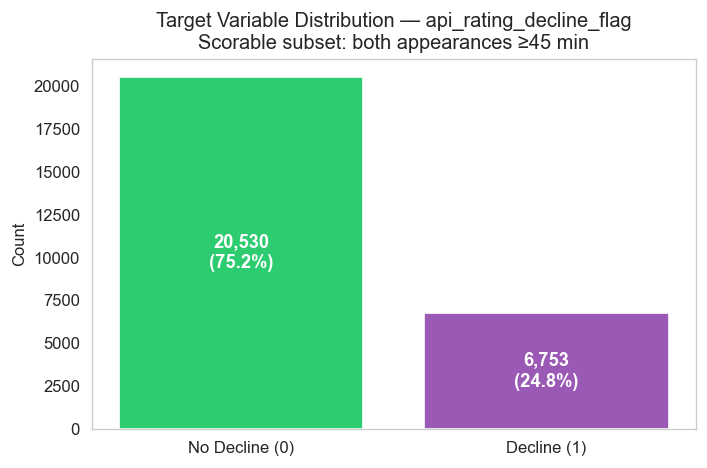

In [87]:
n_pos = int(y.sum())
n_neg = int((y == 0).sum())
spw = round(n_neg / n_pos, 2)

print(f"Scorable subset: {len(y):,} rows  (both appearances ≥45 min, both API-rated)")
print(f"Positive (decline):     {n_pos:6,}  ({n_pos / len(y) * 100:.2f}%)")
print(f"Negative (no decline):  {n_neg:6,}  ({n_neg / len(y) * 100:.2f}%)")
print(f"scale_pos_weight:       {spw}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ["No Decline (0)", "Decline (1)"],
    [n_neg, n_pos],
    color=["#2ECC71", "#9B59B6"],  # green + purple
)

ax.set_ylabel("Count")
ax.set_title(
    "Target Variable Distribution — api_rating_decline_flag\n"
    "Scorable subset: both appearances ≥45 min"
)

# Remove grid
ax.grid(False)

# Put labels in the middle of each bar
for bar, v in zip(bars, [n_neg, n_pos]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{v:,}\n({v / len(y) * 100:.1f}%)",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

## Section 4 — Temporal Train / Val / Test Split

Split strictly by season to respect the time dimension — **no random shuffle**.

| Split | Season | Rows in scorable subset |
|-------|--------|-------------------------|
| Train | 2022-2023 | 9,340 |
| Val   | 2023-2024 | 9,183 |
| Test  | 2024-2025 | 8,760 |

**Important**: masks are computed on `df_a` (the filtered scorable subset), not on the full `df`, so `X` and `y` indices align correctly.


In [88]:
# ── Masks on df_a (the filtered training subset) ───────────────────────────────
train_mask = df_a['season'] == 2022
val_mask   = df_a['season'] == 2023
test_mask  = df_a['season'] == 2024

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

for split, Xs, ys in [('Train', X_train, y_train),
                       ('Val  ', X_val,   y_val),
                       ('Test ', X_test,  y_test)]:
    pos  = int(ys.sum())
    neg  = int((ys == 0).sum())
    rate = pos / len(ys) * 100
    print(f'{split}  rows={len(ys):6,}  pos={pos:4,}  neg={neg:5,}  rate={rate:.1f}%')

Train  rows= 9,340  pos=2,294  neg=7,046  rate=24.6%
Val    rows= 9,183  pos=2,269  neg=6,914  rate=24.7%
Test   rows= 8,760  pos=2,190  neg=6,570  rate=25.0%


## Section 5 — Preprocessing Pipeline

A `ColumnTransformer` with two branches:

| Branch | Applied to | Steps |
|--------|-----------|-------|
| `num` | All numeric columns | `SimpleImputer(strategy='median')` |
| `cat` | Categorical columns | `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')` |

Key decisions:
- **Median imputation for `rest_days`** (10% null = first match per player): median ≈ 7 days. Setting to 0 would incorrectly flag every debut as maximum congestion.
- **`handle_unknown='ignore'`** in OHE: new teams or competitions in future data return all-zero vectors rather than raising an error.
- **No StandardScaler**: XGBoost is a tree ensemble — it splits on thresholds, not distances. Scaling changes nothing about splits. Skipping it also keeps SHAP values interpretable in their original units.

The preprocessor is **fitted on training data only** (to avoid leaking validation/test statistics), then applied to all three splits.

In [89]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS),
    ],
    remainder='drop',
)

# ── Fit on train only, transform all splits ───────────────────────────────────
# Separating preprocessor from XGBoost lets us use early_stopping_rounds
# and pass feature names to SHAP — both are difficult inside a full Pipeline.
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

# ── Recover feature names after OHE expansion ────────────────────────────────
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']['onehot']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
FEATURE_NAMES = NUM_COLS + cat_feature_names

# Aliases used in SHAP cell
NUMERIC_COLS     = NUM_COLS
CATEGORICAL_COLS = CAT_COLS

print(f'Feature matrix after preprocessing:')
print(f'  Train:    {X_train_t.shape}')
print(f'  Val:      {X_val_t.shape}')
print(f'  Test:     {X_test_t.shape}')
print(f'  Total features after OHE expansion: {len(FEATURE_NAMES)}')

# Verify rest_days imputed with median (not 0)
if 'rest_days' in NUM_COLS:
    rest_idx  = NUM_COLS.index('rest_days')
    rest_med  = preprocessor.named_transformers_['num']['imputer'].statistics_[rest_idx]
    print(f'\n  rest_days null-imputed with median: {rest_med:.1f} days')

if 'squad_injured_count' in NUM_COLS:
    squad_idx = NUM_COLS.index('squad_injured_count')
    squad_med = preprocessor.named_transformers_['num']['imputer'].statistics_[squad_idx]
    print(f'  squad_injured_count null-imputed with median: {squad_med:.1f} players')

Feature matrix after preprocessing:
  Train:    (9340, 503)
  Val:      (9183, 503)
  Test:     (8760, 503)
  Total features after OHE expansion: 503

  rest_days null-imputed with median: 6.0 days
  squad_injured_count null-imputed with median: 3.0 players


## Section 6 — Model A: XGBoost Classifier (Decline Flag)

**Target**: `api_rating_decline_flag`  
**Positive class**: API rating drops > 0.5 points in the next match (both appearances ≥ 45 min)

**Key parameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `scale_pos_weight` | **computed** (`n_neg / n_pos`) | Compensates for class imbalance; ~3.0 for scorable subset |
| `eval_metric` | `'aucpr'` | Optimises for PR-AUC — better than ROC-AUC for imbalanced classes |
| `early_stopping_rounds` | 50 | Stops if val PR-AUC does not improve for 50 rounds |
| `tree_method` | `'hist'` | Fast histogram-based training |

**Why PR-AUC over ROC-AUC?**  
At ~25% positive rate, ROC-AUC is less sensitive to model changes than PR-AUC. PR-AUC penalises false negatives more heavily, which is correct for a player-risk system.

In [90]:
SPW = round(n_neg / n_pos, 1)  # scale_pos_weight

model_a = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=SPW,
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0,
)

model_a.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)

best_iter = model_a.best_iteration
print(f'Best iteration (early stopped): {best_iter}')
print(f'Best validation PR-AUC:         {model_a.best_score:.4f}')
print(f'scale_pos_weight applied:        {SPW}')

Best iteration (early stopped): 421
Best validation PR-AUC:         0.5869
scale_pos_weight applied:        3.0


In [91]:


import joblib
import json
from pathlib import Path

ARTIFACTS_DIR = Path("../../models/XgBoost/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Save trained model
# ------------------------------------------------------------------------------

model_a_path = ARTIFACTS_DIR / "xgboost_model_a.pkl"
joblib.dump(model_a, model_a_path)

# ------------------------------------------------------------------------------
# 2. Save preprocessing transformer
# ------------------------------------------------------------------------------

preprocessor_a_path = ARTIFACTS_DIR / "xgboost_model_a_preprocessor.pkl"
joblib.dump(preprocessor, preprocessor_a_path)

# ------------------------------------------------------------------------------
# 3. Save feature lists
# ------------------------------------------------------------------------------

feature_names_a_path = ARTIFACTS_DIR / "xgboost_model_a_feature_names.pkl"
numeric_cols_a_path = ARTIFACTS_DIR / "xgboost_model_a_numeric_cols.pkl"
categorical_cols_a_path = ARTIFACTS_DIR / "xgboost_model_a_categorical_cols.pkl"

joblib.dump(FEATURE_NAMES, feature_names_a_path)
joblib.dump(NUM_COLS, numeric_cols_a_path)
joblib.dump(CAT_COLS, categorical_cols_a_path)

# ------------------------------------------------------------------------------
# 4. Save model metadata
# ------------------------------------------------------------------------------

metadata_a = {
    "model_name": "XGBoost Model A",
    "target": "api_rating_decline_flag",
    "purpose": "Predict whether a player's next meaningful rated appearance declines by more than 0.5 API-rating points.",
    "framing": "post-current-match / pre-next-appearance performance decline model",
    "objective": "binary:logistic",
    "scale_pos_weight": float(SPW),
    "best_iteration": int(model_a.best_iteration),
    "best_validation_pr_auc": float(model_a.best_score),
    "n_train": int(len(y_train)),
    "n_val": int(len(y_val)),
    "n_test": int(len(y_test)),
    "n_raw_numeric_features": int(len(NUM_COLS)),
    "n_raw_categorical_features": int(len(CAT_COLS)),
    "n_transformed_features": int(len(FEATURE_NAMES)),
    "n_estimators": 1000,
    "max_depth": 4,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "eval_metric": "aucpr",
    "random_state": 42,
    "notes": [
        "api_rating_clean is removed from X because it is used to define the target.",
        "next_* columns are removed to prevent temporal leakage.",
        "preprocessor is fitted only on the 2022 training split.",
    ],
}

metadata_a_path = ARTIFACTS_DIR / "xgboost_model_a_metadata.json"

with open(metadata_a_path, "w") as f:
    json.dump(metadata_a, f, indent=4)

# ------------------------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------------------------

print("✓ XGBoost Model A artifacts saved")
print(f"  Model:            {model_a_path}")
print(f"  Preprocessor:     {preprocessor_a_path}")
print(f"  Feature names:    {feature_names_a_path}")
print(f"  Numeric columns:  {numeric_cols_a_path}")
print(f"  Categorical cols: {categorical_cols_a_path}")
print(f"  Metadata:         {metadata_a_path}")



✓ XGBoost Model A artifacts saved
  Model:            ../../models/XgBoost/artifacts/xgboost_model_a.pkl
  Preprocessor:     ../../models/XgBoost/artifacts/xgboost_model_a_preprocessor.pkl
  Feature names:    ../../models/XgBoost/artifacts/xgboost_model_a_feature_names.pkl
  Numeric columns:  ../../models/XgBoost/artifacts/xgboost_model_a_numeric_cols.pkl
  Categorical cols: ../../models/XgBoost/artifacts/xgboost_model_a_categorical_cols.pkl
  Metadata:         ../../models/XgBoost/artifacts/xgboost_model_a_metadata.json


## Section 7 — Model A Evaluation

Two key metrics:
- **AUC-ROC**: area under the ROC curve. Useful context but can look good even on bad imbalanced models.
- **AUC-PR** (average precision): area under the Precision-Recall curve. The primary metric here. A random classifier has AUC-PR equal to the positive rate (0.023). A lift of e.g. 5x means AUC-PR ~0.12.

The **confusion matrix at threshold 0.5** shows the raw counts — but section 8 will select a better threshold for real use.

────────────────────────────────────────────────────────────
  AUC-ROC:         0.7934
  AUC-PR:          0.6005  (baseline: 0.2500)
  PR-AUC lift:     2.4x over random
────────────────────────────────────────────────────────────

Classification report at threshold = 0.5:
              precision    recall  f1-score   support

  No Decline       0.87      0.76      0.81      6570
     Decline       0.48      0.66      0.55      2190

    accuracy                           0.73      8760
   macro avg       0.67      0.71      0.68      8760
weighted avg       0.77      0.73      0.75      8760



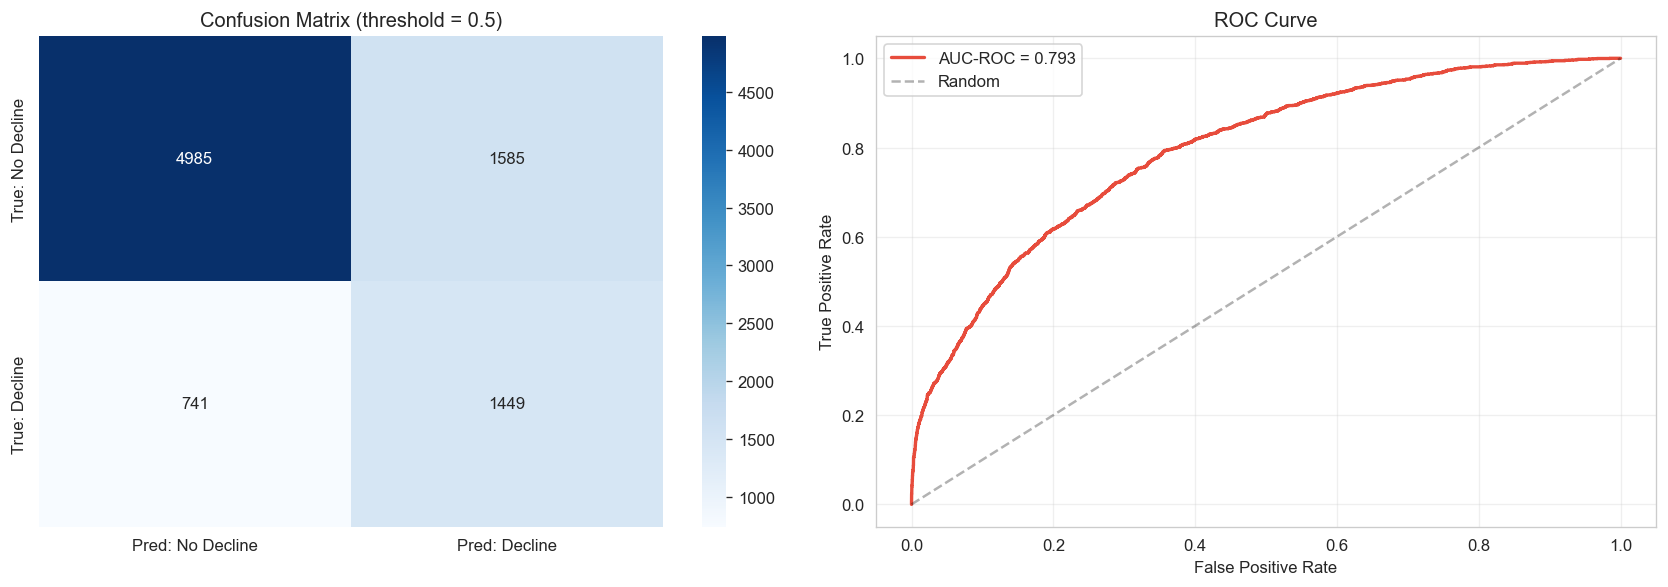

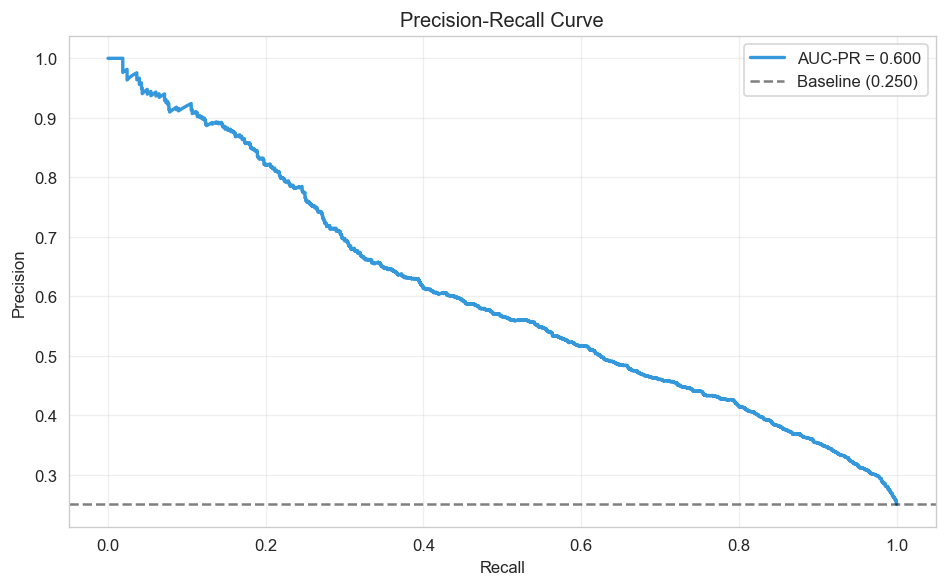

In [92]:
y_proba = model_a.predict_proba(X_test_t)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

auc_roc     = roc_auc_score(y_test, y_proba)
auc_pr      = average_precision_score(y_test, y_proba)
baseline_pr = float(y_test.mean())

print(f'{"─"*60}')
print(f'  AUC-ROC:         {auc_roc:.4f}')
print(f'  AUC-PR:          {auc_pr:.4f}  (baseline: {baseline_pr:.4f})')
print(f'  PR-AUC lift:     {auc_pr / baseline_pr:.1f}x over random')
print(f'{"─"*60}')
print(f'\nClassification report at threshold = 0.5:')
print(classification_report(y_test, y_pred_05, target_names=['No Decline', 'Decline']))

# ── Confusion matrix + ROC ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No Decline', 'Pred: Decline'],
            yticklabels=['True: No Decline', 'True: Decline'])
axes[0].set_title('Confusion Matrix (threshold = 0.5)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='#E74C3C', label=f'AUC-ROC = {auc_roc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_roc.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Precision-Recall curve ─────────────────────────────────────────────────────
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_curve, prec_curve, lw=2, color='#3498DB', label=f'AUC-PR = {auc_pr:.3f}')
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline ({baseline_pr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_a_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 7 — Model A Test-Set Evaluation

Model A was evaluated on the held-out 2024 test season after removing direct rating leakage from the feature matrix.

Specifically, `api_rating_clean` was excluded from the model inputs because the target `api_rating_decline_flag` is defined relative to the current API rating. Keeping it as a feature would make the model partially learn the target definition rather than genuine predictive risk patterns.

The model produced the following test-set ranking metrics:

| Metric                  |  Value |
| ----------------------- | -----: |
| AUC-ROC                 | 0.7934 |
| AUC-PR                  | 0.6005 |
| Baseline PR-AUC         | 0.2500 |
| PR-AUC lift over random |   2.4× |

The baseline PR-AUC corresponds to the positive-class prevalence in the test set. Since the decline class represents **25.00%** of the test set, a random classifier would obtain a PR-AUC of approximately **0.2500**.

The model achieved a PR-AUC of **0.6005**, corresponding to a **2.4× improvement over random ranking**.

---

## Classification Performance at Threshold 0.5

Using the default decision threshold of 0.5, the test-set classification report was:

| Class            | Precision | Recall | F1-score | Support |
| ---------------- | --------: | -----: | -------: | ------: |
| No Decline       |      0.87 |   0.76 |     0.81 |   6,570 |
| Decline          |      0.48 |   0.66 |     0.55 |   2,190 |
| Accuracy         |           |        |     0.73 |   8,760 |
| Macro average    |      0.67 |   0.71 |     0.68 |   8,760 |
| Weighted average |      0.77 |   0.73 |     0.75 |   8,760 |

---

## Interpretation

After removing `api_rating_clean`, the model still shows good discrimination on the held-out 2024 test season, with an AUC-ROC of **0.7934**.

More importantly for this task, the PR-AUC is **0.6005**, substantially above the random baseline of **0.2500**. This indicates that the model remains effective at ranking players by future decline risk even without direct current-rating information.

At the default threshold of 0.5, the model identifies **66% of true decline cases** while maintaining a decline precision of **48%**.

In practical terms, this means that when the model flags a player as at risk of decline, nearly one in two flagged cases corresponds to a true decline case. This is a meaningful improvement over the baseline decline prevalence of 25%.

The result is suitable for a monitoring dashboard, where the predicted probability should be interpreted as a risk score rather than as an automatic decision rule.

---


## Section 8 — Threshold Selection for Risk-Alert System

The default threshold of 0.5 may not be optimal. With ~25% positives in the scorable subset, 0.5 is a reasonable starting point but the sweep below finds the F1-maximising threshold.

Risk tier definitions used in this system:

| Risk Level | Threshold | Action |
|------------|-----------|--------|
| **Very High** | > 0.60 | Strongly recommend rest |
| **High** | 0.40 – 0.60 | Reduced minutes / monitor |
| **Moderate** | 0.20 – 0.40 | Standard rotation |
| **Low** | < 0.20 | No action needed |

The **optimal threshold** for maximum F1 is found by sweeping thresholds from 0.05 to 0.80.

Best threshold (max F1): 0.54
  Precision:  0.514
  Recall:     0.609
  F1:         0.558
  Alerts issued (test set): 2594

Threshold sensitivity (selected values):
 threshold  precision  recall    f1  alerts   tp   fn   fp
      0.20      0.300   0.974 0.459    7106 2132   58 4974
      0.30      0.348   0.907 0.503    5699 1986  204 3713
      0.40      0.411   0.808 0.545    4303 1769  421 2534
      0.50      0.478   0.662 0.555    3034 1449  741 1585
      0.54      0.514   0.609 0.558    2594 1334  856 1260
      0.60      0.559   0.522 0.540    2044 1143 1047  901
      0.70      0.646   0.358 0.460    1213  783 1407  430


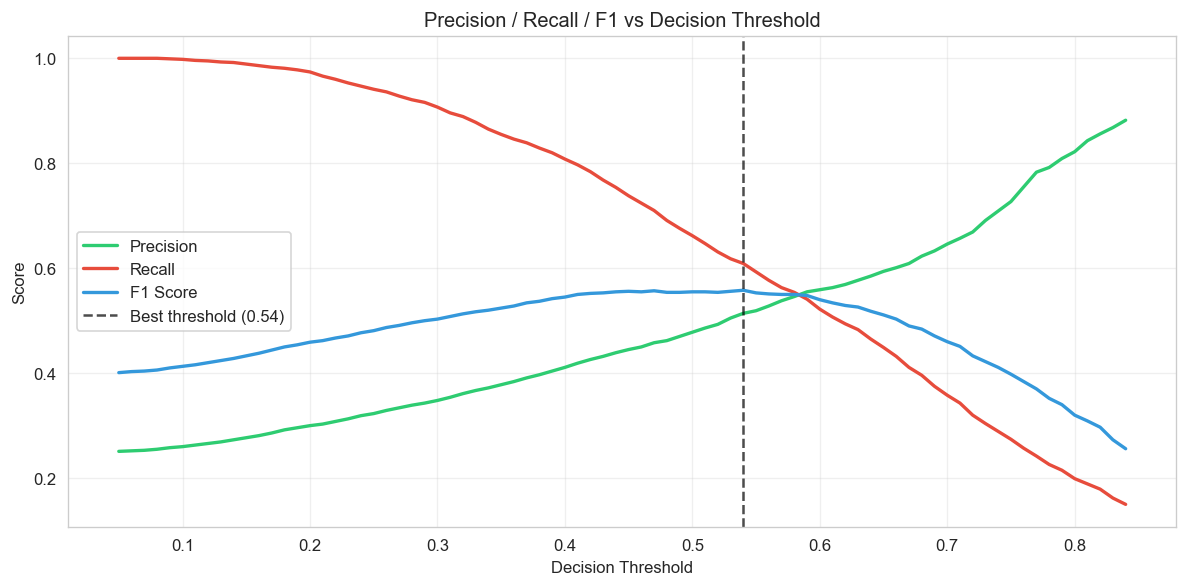


Risk tier distribution in test set:
risk_tier
Moderate     2803
High         2259
Very High    2044
Low          1654

Top 15 highest-risk appearances:
         player_name       player_team      competition  decline_proba risk_tier  actual_decline  rest_days  acwr_ratio  minutes_played
         Thomas Ince           Watford       League Cup       0.993098 Very High               1        NaN       0.000              90
        Bryan Mbeumo         Brentford   Premier League       0.987711 Very High               1        7.0       1.333              90
  Matthew Pennington         Blackpool       League Cup       0.985940 Very High               1       21.0       0.000              90
  Alejandro Garnacho Manchester United       League Cup       0.985067 Very High               1        3.0       0.613              84
        Ismaïla Sarr    Crystal Palace   Premier League       0.984468 Very High               1        8.0       0.000              89
         Bukayo Saka           

In [93]:
thresholds = np.arange(0.05, 0.85, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-10)
    results.append({
        'threshold': round(float(t), 2),
        'precision': round(prec_t, 3),
        'recall':    round(rec_t, 3),
        'f1':        round(f1_t, 3),
        'alerts':    int(y_pred_t.sum()),
        'tp': int(tp), 'fn': int(fn), 'fp': int(fp),
    })

df_thresh = pd.DataFrame(results)
best_row   = df_thresh.loc[df_thresh['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

print(f'Best threshold (max F1): {BEST_THRESHOLD:.2f}')
print(f'  Precision:  {best_row["precision"]:.3f}')
print(f'  Recall:     {best_row["recall"]:.3f}')
print(f'  F1:         {best_row["f1"]:.3f}')
print(f'  Alerts issued (test set): {int(best_row["alerts"])}')

print(f'\nThreshold sensitivity (selected values):')
show_thresh = [0.20, 0.30, 0.40, BEST_THRESHOLD, 0.50, 0.60, 0.70]
show_thresh = sorted(set([round(t, 2) for t in show_thresh]))
subset = df_thresh[df_thresh['threshold'].isin(show_thresh)]
print(subset.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', lw=2, color='#2ECC71')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    lw=2, color='#E74C3C')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        label='F1 Score',  lw=2, color='#3498DB')
ax.axvline(BEST_THRESHOLD, color='k', linestyle='--', alpha=0.7,
           label=f'Best threshold ({BEST_THRESHOLD:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Apply risk tiers to test set ──────────────────────────────────────────────
def risk_tier(p):
    if p >= 0.60: return 'Very High'
    if p >= 0.40: return 'High'
    if p >= 0.20: return 'Moderate'
    return 'Low'

# Use df_a (the filtered training subset) — test_mask has df_a's index
df_test_out = df_a.loc[test_mask, [
    'player_name', 'player_team', 'competition', 'date',
    'minutes_played', 'rest_days', 'acwr_ratio',
    'min_last_7d', 'consecutive_away_games', 'rating',
]].copy().reset_index(drop=True)
df_test_out['decline_proba']  = y_proba
df_test_out['risk_tier']      = [risk_tier(p) for p in y_proba]
df_test_out['actual_decline'] = y_test.values

print(f'\nRisk tier distribution in test set:')
print(df_test_out['risk_tier'].value_counts().to_string())

print(f'\nTop 15 highest-risk appearances:')
top15 = df_test_out.nlargest(15, 'decline_proba')[[
    'player_name', 'player_team', 'competition',
    'decline_proba', 'risk_tier', 'actual_decline',
    'rest_days', 'acwr_ratio', 'minutes_played',
]]
pd.set_option('display.max_colwidth', 22)
print(top15.to_string(index=False))

## Section 9 — SHAP: Why Is This Player Flagged?

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions — answering "what drove this player's risk score?"

Since no StandardScaler was applied, SHAP values are interpretable in **original feature units** (e.g. `rest_days = 3 days`, `acwr_ratio = 1.8`). Positive SHAP = pushes prediction toward decline (1). Negative SHAP = pushes toward no decline (0).

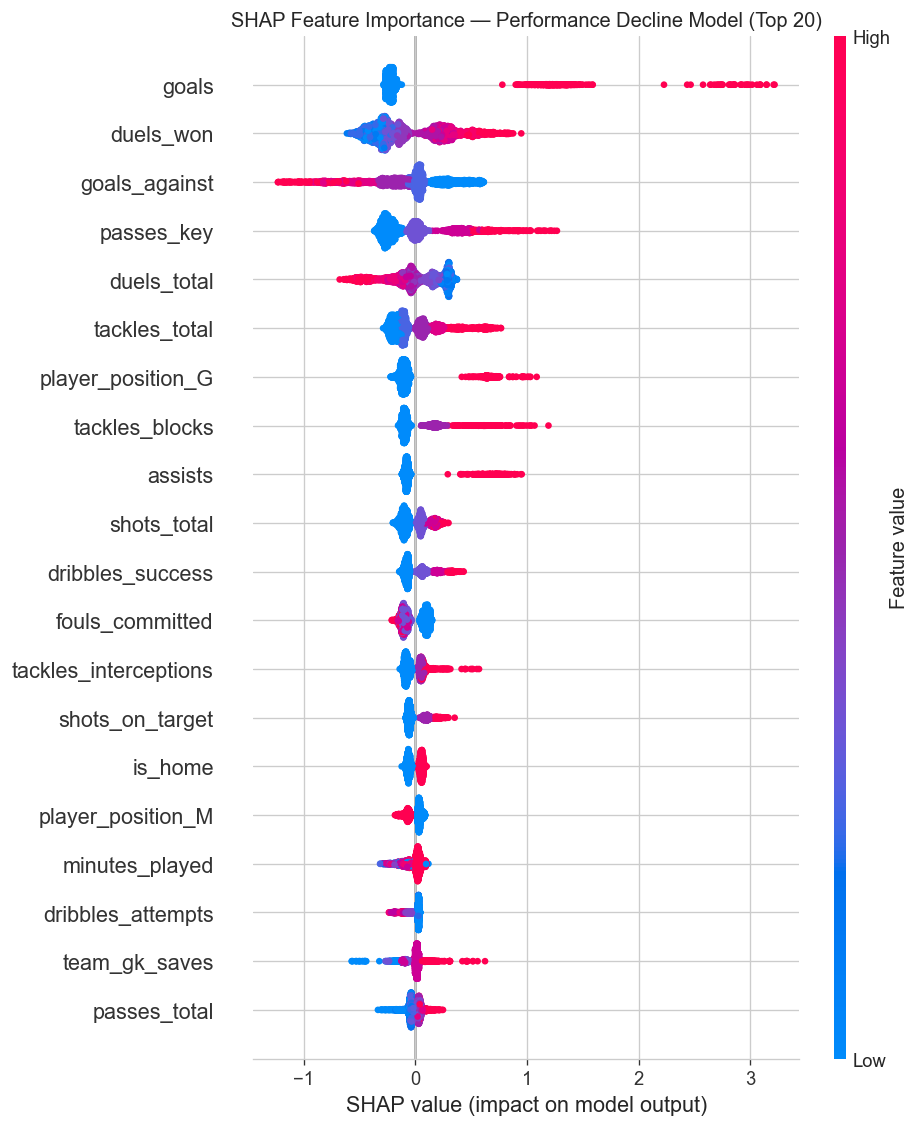


Top 20 features by mean |SHAP| value:
goals                    0.36285
duels_won                0.29709
goals_against            0.25378
passes_key               0.23933
duels_total              0.19023
tackles_total            0.17296
player_position_G        0.15915
tackles_blocks           0.13892
assists                  0.12923
shots_total              0.10144
dribbles_success         0.09908
fouls_committed          0.09839
tackles_interceptions    0.07607
shots_on_target          0.07449
is_home                  0.05853
player_position_M        0.05615
minutes_played           0.05458
dribbles_attempts        0.05028
team_gk_saves            0.04722
passes_total             0.04543


In [94]:
import builtins
import shap.explainers._tree as _shap_tree

# ── Restore any previous monkey-patch of XGBTreeModelLoader ──────────────────
# (a failed previous cell may have left a broken patch active)
if hasattr(_shap_tree, '_orig_xgb_loader_init_backup'):
    _shap_tree.XGBTreeModelLoader.__init__ = _shap_tree._orig_xgb_loader_init_backup
else:
    _shap_tree._orig_xgb_loader_init_backup = _shap_tree.XGBTreeModelLoader.__init__

# ── Patch for SHAP 0.49.x + XGBoost 3.x incompatibility ──────────────────────
# XGBoost 3.x encodes base_score as '[4.9381858E-1]' in UBJ.
# SHAP calls float(base_score) which fails on the brackets.
# Fix: temporarily override builtins.float to strip brackets, scoped to TreeExplainer init.
_orig_float = builtins.float

def _bracket_safe_float(x):
    if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
        return _orig_float(x[1:-1])
    return _orig_float(x)

# ── Use a sample of 3,000 test rows ───────────────────────────────────────────
np.random.seed(42)
shap_n   = min(3000, X_test_t.shape[0])
shap_idx = np.random.choice(X_test_t.shape[0], size=shap_n, replace=False)
X_shap   = X_test_t[shap_idx]

builtins.float = _bracket_safe_float
try:
    explainer = shap.TreeExplainer(model_a.get_booster())
finally:
    builtins.float = _orig_float  # always restore

shap_values = explainer.shap_values(X_shap)

# ── Global summary (beeswarm) ─────────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
)
plt.title('SHAP Feature Importance — Performance Decline Model (Top 20)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top features by mean |SHAP| ───────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print('\nTop 20 features by mean |SHAP| value:')
print(mean_abs_shap.head(20).round(5).to_string())

# Model A — XGBoost Performance-Decline Classifier

---

## 1. Problem Statement

**Question:** Given everything we know about a player's last meaningful match appearance, can we predict whether their API performance rating will decline in their next match?

This is framed as a **binary classification** problem.

For each player-match observation, the model outputs a probability between 0 and 1 representing the risk that the player's next API rating will be more than 0.5 points lower than their current API rating.

The model is intended as a **post-match / between-match performance-decline monitoring model**. Its output can be used by coaches, trainers, analysts, or dashboard users to identify players who may be at elevated risk of underperforming in their next appearance.

The model was trained on three seasons of FixtureIQ data covering the 2022, 2023, and 2024 seasons, across the following competitions:

| Competition      |   Rows |
| ---------------- | -----: |
| Premier League   | 45,552 |
| League Cup       | 10,997 |
| FA Cup           |  6,972 |
| Champions League |  5,081 |
| Community Shield |    120 |

The final master table contains:

```text
68,722 rows × 105 columns
```

One row represents one player-match squad entry. Rows with `minutes_played = 0` correspond to listed squad or bench players who did not actually play.

---

## 2. Target Variable — `api_rating_decline_flag`

The target variable is:

```text
api_rating_decline_flag
```

It is defined as:

```text
api_rating_decline_flag = 1  if  next_api_rating < api_rating_clean - 0.5
api_rating_decline_flag = 0  otherwise
```

The positive class represents a player whose API rating drops by more than 0.5 points in the next valid appearance.

Importantly, `api_rating_clean` is used to define the target, but it is **not included as a model feature**. It was removed from the feature matrix to avoid leakage.

---

## 3. Why Use `api_rating_decline_flag`?

The previous target, `rating_decline_flag`, was based on SofaScore ratings. That target was not suitable as the main modelling target because SofaScore coverage was largely restricted to Premier League matches and had very high missingness.

The API-based target is preferred because it provides broader competition coverage and produces a healthier class balance.

| Target                                       | Positive Cases | Positive Rate | Main Issue                                                |
| -------------------------------------------- | -------------: | ------------: | --------------------------------------------------------- |
| Legacy `rating_decline_flag`                 |          1,659 |         2.41% | SofaScore-based, Premier League-biased, highly imbalanced |
| `api_rating_decline_flag` across all rows    |          6,753 |         9.83% | Better coverage, but includes non-comparable appearances  |
| `api_rating_decline_flag` in scorable subset |          6,753 |        24.75% | Final target used for Model A                             |

The API-based target gives a more realistic and stable classification problem.

---

## 4. Scorable Subset Filter

Not every row in the master table is suitable for training the classifier. The model is restricted to a **scorable subset** where both the current and next appearances are comparable.

A row is included in the scorable subset if all four conditions are met:

| Condition                   | Purpose                                                     |
| --------------------------- | ----------------------------------------------------------- |
| `api_rating_clean.notna()`  | The player received a valid API rating in the current match |
| `next_api_rating.notna()`   | The next-match rating exists, so the target can be computed |
| `minutes_played >= 45`      | The current appearance was substantial                      |
| `next_minutes_played >= 45` | The next appearance was also substantial                    |

The filter used was:

```text
api_rating_clean.notna()
next_api_rating.notna()
minutes_played >= 45
next_minutes_played >= 45
```

After applying this filter, the final Model A scorable subset contained:

```text
27,283 rows
```

---

## 5. Why Use a 45-Minute Filter?

Short substitute appearances are not directly comparable to starter-level performances.

For example, a player who plays 10 minutes and scores can receive an unusually high rating, while another player who plays 90 minutes has a much broader performance profile. Including these cases would make the model learn substitute-related artefacts instead of genuine performance-decline patterns.

The 45-minute filter ensures that the model compares meaningful rated appearances.

---

## 6. Feature Matrix and Leakage Removal

The final Model A feature matrix was built from the scorable subset.

The target and all future-match variables were removed before modelling. Direct rating leakage was also removed.

The most important leakage-removal decision was excluding:

```text
api_rating_clean
```

This is necessary because the target is defined relative to `api_rating_clean`. If this feature were included, the model could partially learn the target definition directly, especially through regression-to-the-mean effects.

The model also drops the raw `rating` column for the same reason.

---

## 7. Columns Removed Before Modelling

The following groups of columns were removed from the feature matrix:

| Column / Group                                                                 | Reason                                                     |
| ------------------------------------------------------------------------------ | ---------------------------------------------------------- |
| `fixture_id`, `date`, `round`                                                  | Identifiers or fixture-specific fields                     |
| `player_id`, `player_name`, `player_number`                                    | Player identity fields; removed to avoid memorisation      |
| `_player_team_key`, `player_team_key`, `player_name_key`                       | Temporary helper or merge keys                             |
| `api_rating_decline_flag`                                                      | Target variable                                            |
| `api_rating_decline_flag_before_min_guard`                                     | Diagnostic target column                                   |
| `next_api_rating`                                                              | Direct future leakage; used to compute the target          |
| `next_is_substitute`, `next_minutes_played`                                    | Future-match information unavailable at prediction time    |
| `next_sofascore_rating`                                                        | Future rating and legacy SofaScore field                   |
| `rating_decline_flag`                                                          | Old SofaScore-based target                                 |
| `rating`, `api_rating_clean`                                                   | Current rating information removed to avoid direct leakage |
| `sofascore_rating`, `ss_minutes`, `sofascore_*`                                | Sparse / Premier League-biased SofaScore variables         |
| `opp_shots_on_goal`, `opp_total_shots`, `opp_possession`, `opp_expected_goals` | Empty or unusable opponent-stat columns                    |
| `fb_*`, `fbref_position_raw`                                                   | High missingness and limited FBRef coverage                |
| `days_since_last_injury`, `last_injury_type`                                   | Very sparse injury fields                                  |
| `season_main_reason`, `season_main_injury_category`                            | Sparse categorical injury fields                           |

This final version therefore excludes both direct future leakage and direct current-rating leakage.

---

## 8. Feature Groups Kept in the Model

After leakage removal, the model still uses current-match context and performance variables.

This means Model A should be interpreted as a **post-current-match monitoring model**, not a pure pre-match model.

The retained feature groups include:

### Match context

```text
season
competition
home_team
away_team
player_team
opponent_team
is_home
player_position
```

### Current match performance and involvement

```text
minutes_played
goals
assists
shots_total
shots_on_target
passes_total
passes_key
passes_accuracy
dribbles_attempts
dribbles_success
tackles_total
tackles_blocks
tackles_interceptions
duels_total
duels_won
fouls_drawn
fouls_committed
cards_yellow
cards_red
```

### Team match context

```text
goals_for
goals_against
points
team_shots_on_goal
team_total_shots
team_possession
team_corner_kicks
team_fouls
team_gk_saves
team_expected_goals
```

### Workload and recovery

```text
rest_days
minutes_workload
min_last_7d
min_last_28d
acwr_ratio
high_congestion_flag
consecutive_away_games
```

### Injury context

```text
squad_missing_total
squad_injured_count
squad_non_injury_missing_count
squad_soft_tissue_count
squad_max_days_out
squad_avg_days_out
fixtures_missed_last_30d
fixtures_missed_last_90d
returning_from_injury
season_matches_missed_total
season_matches_missed_injury
season_max_reported_days_out
has_player_season_injury_record
```

The model is therefore best described as:

```text
an injury-aware post-match performance-decline risk model
```

It combines current-match performance, role, match context, workload, recovery, and injury-context information.

---

## 9. Temporal Train / Validation / Test Split

The data was split temporally by season.

| Split      | Season |  Rows | Positives | Positive Rate |
| ---------- | ------ | ----: | --------: | ------------: |
| Train      | 2022   | 9,340 |     2,294 |        24.56% |
| Validation | 2023   | 9,183 |     2,269 |        24.71% |
| Test       | 2024   | 8,760 |     2,190 |        25.00% |

The positive rate is very stable across seasons, ranging from approximately 24.5% to 25.0%.

This stability suggests that the API-based decline target is not strongly affected by seasonal drift.

---

## 10. Why Use a Temporal Split?

The model is intended for future prediction. Therefore, it should be evaluated in a way that mimics deployment.

A random split would allow information from future seasons to appear in the training set, causing temporal leakage.

The temporal split follows the realistic workflow:

```text
Train on past data → validate on the next season → test on the most recent season
```

---

## 11. Class Balance

The scorable subset has a much healthier class balance than the legacy SofaScore-based target.

| Dataset                                      | Positive Cases | Positive Rate | `scale_pos_weight` |
| -------------------------------------------- | -------------: | ------------: | -----------------: |
| Legacy `rating_decline_flag` across all rows |          1,659 |         2.41% |             ≈ 40.4 |
| `api_rating_decline_flag` across all rows    |          6,753 |         9.83% |             ≈ 9.18 |
| `api_rating_decline_flag` in scorable subset |          6,753 |        24.75% |               3.04 |

The final scorable subset contained:

| Class      |   Rows | Percentage |
| ---------- | -----: | ---------: |
| No decline | 20,530 |     75.25% |
| Decline    |  6,753 |     24.75% |
| Total      | 27,283 |    100.00% |

The class-weighting parameter was computed as:

```text
scale_pos_weight = n_negative / n_positive
scale_pos_weight = 20,530 / 6,753
scale_pos_weight = 3.04
```

This value was used to compensate for class imbalance during XGBoost training.

---

## 12. Preprocessing Pipeline

The preprocessing pipeline used a `ColumnTransformer` with separate branches for numeric and categorical features.

| Branch | Applied to          | Steps                                                                                |
| ------ | ------------------- | ------------------------------------------------------------------------------------ |
| `num`  | Numeric columns     | `SimpleImputer(strategy="median")`                                                   |
| `cat`  | Categorical columns | `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore")` |

Numeric variables were imputed with the median. This is robust to skewed distributions and avoids unrealistic values.

For example, missing `rest_days` usually corresponds to a player's first recorded appearance. Filling this with zero would incorrectly represent maximum fixture congestion. Median imputation gives these cases a typical rest value instead.

Categorical variables were imputed with the most frequent category and then one-hot encoded. The encoder used:

```text
handle_unknown="ignore"
```

This prevents unseen teams, competitions, positions, or categories from breaking the pipeline during validation, testing, or dashboard deployment.

No `StandardScaler` was used because XGBoost is a tree-based model. It learns threshold-based splits, so feature scaling is unnecessary.

The preprocessor was fitted only on the training split and then applied to validation and test data. This prevents leakage of validation or test-set statistics into the model training process.

---

## 13. Preprocessing Output

After removing direct rating leakage, the feature matrix is expected to contain one fewer numeric feature than the previous rating-including version.

The leakage-clean preprocessing output should be approximately:

| Split      |  Rows | Features After Preprocessing |
| ---------- | ----: | ---------------------------: |
| Train      | 9,340 |                          503 |
| Validation | 9,183 |                          503 |
| Test       | 8,760 |                          503 |

The training-set median used for `rest_days` imputation was:

```text
6.0 days
```

The training-set median used for `squad_injured_count` imputation was:

```text
3.0 players
```

These values confirm that the preprocessing pipeline was fitted only on the training split.

---

## 14. Model A — XGBoost Classifier

Model A was trained as an XGBoost binary classifier.

| Item              | Value                            |
| ----------------- | -------------------------------- |
| Algorithm         | XGBoost Gradient Boosted Trees   |
| Objective         | `binary:logistic`                |
| Target            | `api_rating_decline_flag`        |
| Positive class    | Next-match API rating drop > 0.5 |
| Evaluation metric | `aucpr`                          |

---

## 15. Key Hyperparameters

| Hyperparameter          | Value   | Rationale                                                       |
| ----------------------- | ------- | --------------------------------------------------------------- |
| `n_estimators`          | 1,000   | Upper bound; actual stopping controlled by early stopping       |
| `max_depth`             | 4       | Shallow trees reduce overfitting                                |
| `learning_rate`         | 0.03    | Slow learning improves generalisation                           |
| `subsample`             | 0.8     | Row subsampling reduces variance                                |
| `colsample_bytree`      | 0.8     | Feature subsampling reduces reliance on single variables        |
| `reg_alpha`             | 0.1     | L1 regularisation                                               |
| `reg_lambda`            | 1.0     | L2 regularisation                                               |
| `eval_metric`           | `aucpr` | PR-AUC is appropriate for imbalanced alert-style classification |
| `early_stopping_rounds` | 50      | Stops training if validation PR-AUC stops improving             |
| `scale_pos_weight`      | 3.0     | Rounded class imbalance correction                              |

---

## 16. Test-Set Evaluation

Model A was evaluated on the held-out 2024 test season after removing direct rating leakage from the feature matrix.

Specifically, `api_rating_clean` was excluded from the model inputs because the target `api_rating_decline_flag` is defined relative to the current API rating. Keeping it as a feature would make the model partially learn the target definition rather than genuine predictive risk patterns.

The model produced the following test-set ranking metrics:

| Metric                  |  Value |
| ----------------------- | -----: |
| AUC-ROC                 | 0.7934 |
| AUC-PR                  | 0.6005 |
| Baseline PR-AUC         | 0.2500 |
| PR-AUC lift over random |   2.4× |

The baseline PR-AUC corresponds to the positive-class prevalence in the test set. Since the decline class represents 25.00% of the test set, a random classifier would obtain a PR-AUC of approximately 0.2500.

The model achieved a PR-AUC of 0.6005, corresponding to a 2.4× improvement over random ranking.

---

## 17. Classification Performance at Threshold 0.5

Using the default decision threshold of 0.5, the test-set classification report was:

| Class            | Precision | Recall | F1-score | Support |
| ---------------- | --------: | -----: | -------: | ------: |
| No Decline       |      0.87 |   0.76 |     0.81 |   6,570 |
| Decline          |      0.48 |   0.66 |     0.55 |   2,190 |
| Accuracy         |           |        |     0.73 |   8,760 |
| Macro average    |      0.67 |   0.71 |     0.68 |   8,760 |
| Weighted average |      0.77 |   0.73 |     0.75 |   8,760 |

At the default threshold of 0.50, the model identifies approximately 66% of true decline cases while maintaining a decline precision of 48%.

This is useful for a monitoring system because the model substantially improves over the baseline decline prevalence of 25%.

---

## 18. Threshold Selection and Risk Tiers

The XGBoost classifier outputs a probability of future rating decline.

To convert this probability into binary alerts, thresholds from 0.05 to 0.85 were evaluated.

For each threshold, precision, recall, F1-score, and alert volume were computed on the test set.

---

## 19. Best Threshold by F1-Score

The F1-maximising threshold was:

```text
0.54
```

At this threshold, the model achieved:

| Metric        | Value |
| ------------- | ----: |
| Precision     | 0.514 |
| Recall        | 0.609 |
| F1-score      | 0.558 |
| Alerts issued | 2,594 |

This means that at threshold 0.54, the model captures 60.9% of true decline cases, while 51.4% of flagged appearances are true declines.

At this threshold:

```text
True positives: 1,334
False negatives: 856
False positives: 1,260
```

---

## 20. Threshold Sensitivity

| Threshold | Precision | Recall | F1-score | Alerts |    TP |    FN |    FP |
| --------: | --------: | -----: | -------: | -----: | ----: | ----: | ----: |
|      0.20 |     0.300 |  0.974 |    0.459 |  7,106 | 2,132 |    58 | 4,974 |
|      0.30 |     0.348 |  0.907 |    0.503 |  5,699 | 1,986 |   204 | 3,713 |
|      0.40 |     0.411 |  0.808 |    0.545 |  4,303 | 1,769 |   421 | 2,534 |
|      0.50 |     0.478 |  0.662 |    0.555 |  3,034 | 1,449 |   741 | 1,585 |
|      0.54 |     0.514 |  0.609 |    0.558 |  2,594 | 1,334 |   856 | 1,260 |
|      0.60 |     0.559 |  0.522 |    0.540 |  2,044 | 1,143 | 1,047 |   901 |
|      0.70 |     0.646 |  0.358 |    0.460 |  1,213 |   783 | 1,407 |   430 |

Lower thresholds increase recall but generate more alerts. Higher thresholds improve precision but miss more true decline cases.

The threshold of 0.54 provides the best F1-score balance for the leakage-clean model.

However, the improvement over the default 0.50 threshold is modest:

```text
F1 at 0.50 = 0.555
F1 at 0.54 = 0.558
```

Therefore, for dashboard deployment, the exact threshold can be adjusted depending on whether the user wants more recall or fewer alerts.

---

## 21. Risk Tiers

To make model outputs more interpretable in a dashboard, the predicted probability can be converted into risk tiers:

| Probability Range | Risk Tier | Suggested Interpretation                                 |
| ----------------: | --------- | -------------------------------------------------------- |
|        `p < 0.20` | Low       | No specific action needed                                |
| `0.20 ≤ p < 0.40` | Moderate  | Standard rotation consideration                          |
| `0.40 ≤ p < 0.60` | High      | Monitor closely / consider reduced minutes               |
|        `p ≥ 0.60` | Very High | Strong monitoring / possible rest or minutes restriction |

The probability should be interpreted as a **risk score**, not as an automatic decision rule.

For deployment, the dashboard should allow users to rank players by predicted risk rather than relying only on a fixed hard threshold.

---

## 22. SHAP Feature Importance Analysis

SHAP was used to interpret the fitted XGBoost classifier.

The SHAP analysis was computed on a sample of 3,000 test rows.

After removing `api_rating_clean`, the model was no longer dominated by direct current-rating information. Instead, the top SHAP features were current-match performance, physical involvement, match context, and role variables.

---

## 23. Top 20 Features by Mean Absolute SHAP Value

| Rank | Feature | Mean \|SHAP\| | Interpretation |
| ---: | --- | ---: | --- |
| 1 | `goals` | 0.36285 | Standout current performance |
| 2 | `duels_won` | 0.29709 | Physical contest load |
| 3 | `goals_against` | 0.25378 | Match context / defensive pressure |
| 4 | `passes_key` | 0.23933 | Creative output |
| 5 | `duels_total` | 0.19023 | Physical involvement |
| 6 | `tackles_total` | 0.17296 | Defensive workload |
| 7 | `player_position_G` | 0.15915 | Position context |
| 8 | `tackles_blocks` | 0.13892 | Defensive effort |
| 9 | `assists` | 0.12923 | Standout current performance |
| 10 | `shots_total` | 0.10144 | Attacking involvement |
| 11 | `dribbles_success` | 0.09908 | Attacking involvement |
| 12 | `fouls_committed` | 0.09839 | Physical/aggressive load |
| 13 | `tackles_interceptions` | 0.07607 | Defensive workload |
| 14 | `shots_on_target` | 0.07449 | Attacking threat |
| 15 | `is_home` | 0.05853 | Match context |
| 16 | `player_position_M` | 0.05615 | Position context |
| 17 | `minutes_played` | 0.05458 | Match exposure |
| 18 | `dribbles_attempts` | 0.05028 | Attacking involvement |
| 19 | `team_gk_saves` | 0.04722 | Defensive pressure |
| 20 | `passes_total` | 0.04543 | Involvement volume |


## 24. SHAP Interpretation

The SHAP results show that the model is mainly driven by **current-match performance statistics**.

The strongest drivers include:

```text
goals
duels_won
goals_against
passes_key
duels_total
tackles_total
assists
shots_total
dribbles_success
```

This indicates that Model A is learning a strong **regression-to-the-mean** pattern.

If a player produces an exceptional current match, such as scoring, assisting, creating key passes, winning many duels, or generating many shots, the next match is statistically more likely to be lower-rated because the original performance was difficult to repeat.

This does not necessarily mean the player is fatigued or performing poorly. It means the current match was unusually strong relative to the expected baseline.

---

## 25. Injury Feature Contribution

The model includes injury-aware features, but the latest SHAP ranking shows that injury variables are not the dominant signal.

The top 20 SHAP features are mainly current-match performance, physical involvement, role, and match-context variables.

Therefore, the model should not be described as a pure fatigue or injury model.

A more accurate description is:

```text
an injury-aware performance-decline risk model combining current-match performance, workload, role, match context, competition context, and injury-context features
```

Injury features are included as supporting contextual information rather than as the primary driver of the prediction.

---

## 26. Key Findings

### 1. Regression to the mean is the dominant signal

A player who had an exceptional current match, for example through goals, key passes, assists, shots, successful dribbles, or many duels won, is more likely to record a lower rating in the next match.

This does not necessarily mean the player is injured or fatigued. Instead, it reflects the fact that peak performances are rare and difficult to repeat.

### 2. Physical load matters

High values for duel involvement, duels won, tackles, blocks, interceptions, and fouls committed are meaningful signals of physical match load.

These features suggest that players involved in intense physical contests may be more likely to experience a rating decline in their next appearance.

### 3. Team-level match context contributes to individual risk

Features such as `goals_against` and `team_gk_saves` indicate how much pressure the player's team faced during the match.

A player on a team under heavy defensive pressure may face elevated decline risk, even if their individual contribution was not poor.

### 4. Current-match performance dominates over longer-term fatigue

Features such as `min_last_7d`, `min_last_28d`, `acwr_ratio`, and `consecutive_away_games` are included in the model, but they rank below direct current-match performance variables.

This suggests that, in the current model structure, prediction is driven more by immediate post-peak regression than by chronic fatigue alone.

### 5. Injury context contributes, but it is not the dominant signal

External injury-context variables are included in the model, especially squad-level injury pressure and player injury-history indicators.

However, SHAP results show that injury variables are secondary compared with current-match performance and physical involvement features.

---

## 27. Limitations

| Limitation                                                             | Impact                                                                                                                                               |
| ---------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| The model uses current-match statistics to predict next-match decline  | The model is best interpreted as a post-match or between-match monitoring tool, not a pure pre-match model before any recent performance is observed |
| Current-performance features dominate SHAP importance                  | The model captures regression-to-the-mean effects as well as fatigue, workload, injury, and contextual risk                                          |
| `api_rating_clean` is removed, but current-match performance remains   | Direct rating leakage is removed, but the model still uses observed current-match events such as goals, assists, duels, and shots                    |
| No player identity features are included                               | The model cannot directly learn player-specific baselines; an elite player's normal performance may look exceptional relative to the global dataset  |
| Player-level injury coverage is limited                                | Direct player-level injury-history features are available for a smaller proportion of rows than team-level injury context                            |
| Team-level injury context is stronger than player-level injury context | The model captures squad injury pressure more reliably than individual injury history                                                                |
| The scorable subset excludes short appearances                         | Substitute cameos, non-rated matches, and players without a next rated appearance are excluded from the main training sample                         |
| The decline threshold is fixed at 0.5 rating points                    | The choice of 0.5 as the decline margin is a modelling decision                                                                                      |
| The model should not be interpreted as a pure fatigue model            | The model combines current-match performance, workload, match context, competition context, and injury information                                   |

---

## 28. Final Model Interpretation

The final leakage-clean Model A excludes both:

```text
rating
api_rating_clean
```

from the feature matrix.

This means the model cannot directly use the current API rating to predict whether the next API rating will decline.

The target still depends on `api_rating_clean`, but the model must infer decline risk from other variables, including:

```text
current-match performance
physical involvement
team context
match context
workload
recovery
injury context
position
competition
```

The final model achieves:

```text
AUC-ROC: 0.7934
AUC-PR:  0.6005
PR-AUC lift: 2.4× over random
```

This performance indicates that the model remains useful as a risk-ranking system even after removing direct rating leakage.

The model is best used as a dashboard tool that ranks players by probability of next-match rating decline, helping analysts identify cases worth reviewing rather than making automatic decisions.


EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET
  Player:               Thomas Ince
  Team:                 Watford
  Date:                 2024-08-13 00:00:00
  Competition:          League Cup
  Decline risk score:   99.3%
  Risk tier:            Very High
  Actual decline flag:  1

  Key fatigue signals:
    rest_days                     : nan
    acwr_ratio                    : 0.0
    min_last_7d                   : 0.0
    high_congestion_flag          : 0
    consecutive_away_games        : 0
    returning_from_injury         : 0
    squad_injured_count           : nan
    minutes_played                : 90
    rating                        : 10.0

  SHAP drivers (+ = increases decline risk, - = decreases risk):
    +  goals                            SHAP=+2.44290  (value=3)
    +  passes_key                       SHAP=+0.93400  (value=5)
    +  assists                          SHAP=+0.59357  (value=1)
    +  shots_on_target                  SHAP=+0.18823  (value=4)
    +  shots_total

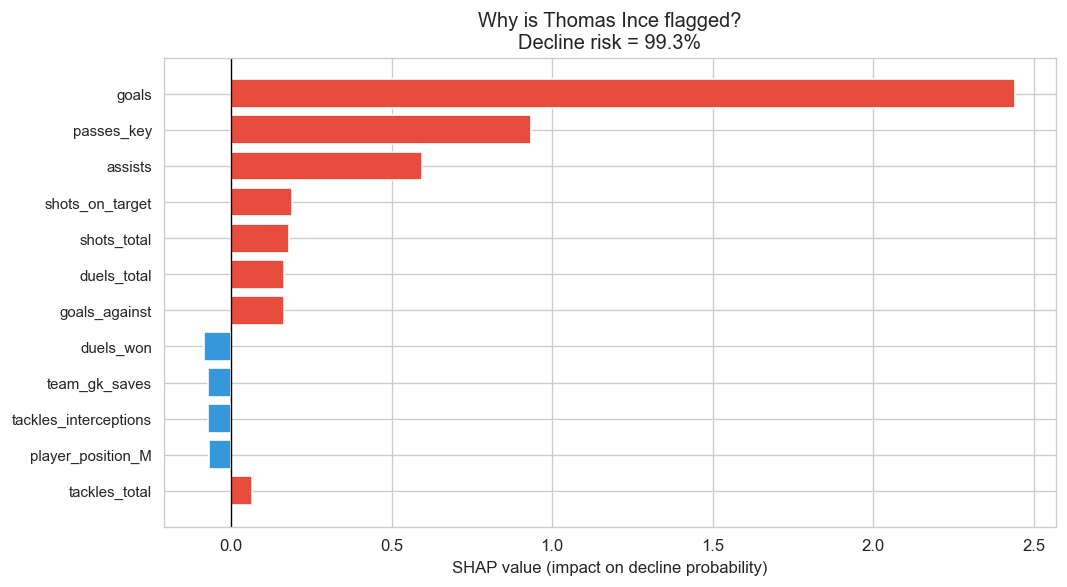

In [95]:
# ── Individual player explanation: highest-risk appearance in test set ─────────
# Position in the test matrix of the highest-risk row
highest_local_idx = int(np.argmax(y_proba))

# Recover the original df_a row (test_mask has df_a's index)
test_df_a_indices = df_a.index[test_mask].tolist()
df_row = df_a.iloc[df_a.index.get_loc(test_df_a_indices[highest_local_idx])]

print('=' * 65)
print('EXAMPLE: HIGHEST-RISK PLAYER IN TEST SET')
print('=' * 65)
print(f'  Player:               {df_row["player_name"]}')
print(f'  Team:                 {df_row["player_team"]}')
print(f'  Date:                 {df_row["date"]}')
print(f'  Competition:          {df_row["competition"]}')
print(f'  Decline risk score:   {y_proba.max()*100:.1f}%')
print(f'  Risk tier:            {risk_tier(y_proba.max())}')
print(f'  Actual decline flag:  {int(df_row["api_rating_decline_flag"])}')
print()
print('  Key fatigue signals:')
for col in ['rest_days', 'acwr_ratio', 'min_last_7d', 'high_congestion_flag',
            'consecutive_away_games', 'returning_from_injury',
            'squad_injured_count', 'minutes_played', 'rating']:
    val = df_row.get(col, 'N/A')
    print(f'    {col:<30}: {val}')

# ── SHAP breakdown for this player ───────────────────────────────────────────
X_player = X_test_t[highest_local_idx].reshape(1, -1)
shap_player = explainer.shap_values(X_player)[0]

shap_df = pd.Series(shap_player, index=FEATURE_NAMES)
top_drivers = shap_df.abs().nlargest(12).index

print(f'\n  SHAP drivers (+ = increases decline risk, - = decreases risk):')
for feat in top_drivers:
    val   = shap_df[feat]
    sign  = '+' if val > 0 else '-'
    if feat in NUMERIC_COLS and feat in df_a.columns:
        orig  = df_row.get(feat, 'N/A')
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}  (value={orig})')
    else:
        print(f'    {sign}  {feat:<32} SHAP={val:+.5f}')

# ── Bar chart of top SHAP drivers ─────────────────────────────────────────────
top_n = 12
top_shap_sorted = shap_df.reindex(top_drivers)
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in top_shap_sorted.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(top_n), top_shap_sorted.values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_shap_sorted.index[::-1], fontsize=9)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on decline probability)')
ax.set_title(f'Why is {df_row["player_name"]} flagged?\nDecline risk = {y_proba.max()*100:.1f}%')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_individual.png', dpi=120, bbox_inches='tight')
plt.show()

# Model B — Fatigue-Adjusted Performance Decline Model

## Motivation: Why Redesign Model B?

The original Model B was an XGBoost regressor designed to predict `api_rating` using all available features, including current-match performance statistics, match context, workload indicators, and fatigue variables.

However, the model was dominated by direct current-performance variables such as:

```text
goals
assists
passes_key
shots_total
duels_won
```

This happened because API ratings are strongly influenced by those same event statistics. As a result, the model mainly learned patterns of **performance regression to the mean**, rather than isolating fatigue-related underperformance.

This creates an important modelling problem.

| Mechanism               | Main Cause                                                | Typical Predictors                                                        |
| ----------------------- | --------------------------------------------------------- | ------------------------------------------------------------------------- |
| Regression to the mean  | Exceptional performances are rare and difficult to repeat | goals, assists, key passes, shots, dribbles                               |
| Fatigue-induced decline | Physical or mental burden from accumulated workload       | rest days, recent minutes, fixture congestion, ACWR, competition sequence |

To study fatigue more directly, the model needs to separate these two effects.

The key idea of Model B is therefore:

```text
First estimate expected next-match performance.
Then model whether the player underperforms relative to that expectation.
```

---

## Two-Stage Architecture

Model B is designed as a two-stage system.

```text
Current-match performance + context
              │
              ▼
┌────────────────────────────────────┐
│ Stage 1 — Baseline Performance     │
│ XGBoost Regressor                  │
│ Target: next_api_rating            │
│ Excludes fatigue/workload features │
└────────────────────────────────────┘
              │
              ▼
 predicted_next_api_rating
              │
              ▼
┌────────────────────────────────────┐
│ Residual Calculation               │
│ residual = actual_next_api_rating  │
│            - predicted_next_rating │
└────────────────────────────────────┘
              │
              ▼
┌────────────────────────────────────┐
│ Stage 2 — Fatigue Residual Model   │
│ XGBoost Classifier                 │
│ Target: fatigue_decline_flag       │
│ Uses fatigue/workload features     │
└────────────────────────────────────┘
```

---

## Stage 1 — Baseline Expected Performance Model

The first stage estimates the player's expected next-match rating.

| Item              | Description                                                                                |
| ----------------- | ------------------------------------------------------------------------------------------ |
| Model             | XGBoost Regressor                                                                          |
| Target            | `next_api_rating`                                                                          |
| Features          | Current-match performance statistics, role, team, opponent, competition, and match context |
| Excluded features | Fatigue, workload, rest, congestion, and schedule-sequence variables                       |
| Purpose           | Estimate the rating the player would normally be expected to receive next match            |

The goal of Stage 1 is not to explain fatigue.

Instead, it estimates a baseline expected rating using non-fatigue information.

This creates a reference point:

```text
What rating would we expect this player to receive next match under normal conditions?
```

---

## Residual Definition

After Stage 1 predicts the expected next rating, a residual is computed:

```text
performance_residual = actual_next_api_rating - predicted_next_api_rating
```

The residual measures how much the player overperformed or underperformed relative to the baseline expectation.

| Residual Value     | Interpretation                             |
| ------------------ | ------------------------------------------ |
| Positive residual  | Player performed better than expected      |
| Near-zero residual | Player performed approximately as expected |
| Negative residual  | Player performed worse than expected       |

The fatigue-adjusted decline target is then defined as:

```text
fatigue_decline_flag = 1 if performance_residual <= -0.5
fatigue_decline_flag = 0 otherwise
```

This means the second-stage model focuses on cases where the player performed at least 0.5 rating points below the expected baseline.

---

## Stage 2 — Fatigue Residual Classifier

The second stage predicts whether the player will underperform relative to the baseline expectation.

| Item           | Description                                                                                |
| -------------- | ------------------------------------------------------------------------------------------ |
| Model          | XGBoost Classifier                                                                         |
| Target         | `fatigue_decline_flag`                                                                     |
| Positive class | Actual next rating is at least 0.5 points below expected next rating                       |
| Features       | Fatigue, workload, recovery, schedule, competition-sequence, and physical-burden variables |
| Purpose        | Identify whether workload and fatigue-related variables explain below-expected performance |

Stage 2 is the fatigue-focused component of Model B.

By modelling the residual rather than the raw rating, Stage 2 is less dominated by goals, assists, and standout performance events.

This makes its SHAP explanations more suitable for interpreting workload and fatigue mechanisms.

---

## Why Use a Two-Stage Model?

The two-stage design separates two different processes:

1. **Expected performance**
2. **Below-expected performance**

This is important because a rating decline can happen for different reasons.

A player may decline simply because they had an exceptional previous match that was difficult to repeat. This is regression to the mean.

Alternatively, a player may decline because they were under-recovered, overloaded, returning from injury, or affected by fixture congestion. This is closer to a fatigue-related mechanism.

Model B is designed to isolate the second mechanism.

---

## Engineered Features for Model B

Model B includes a richer set of fatigue, workload, schedule, and physical-burden features.

These features are designed to capture both short-term and medium-term load accumulation.

### Existing Workload and Recovery Features

| Feature                  | Interpretation                         |
| ------------------------ | -------------------------------------- |
| `rest_days`              | Days since the player's previous match |
| `min_last_7d`            | Minutes played in the previous 7 days  |
| `acwr_ratio`             | Acute-to-chronic workload ratio        |
| `high_congestion_flag`   | Indicator of fixture congestion        |
| `consecutive_away_games` | Number of consecutive away matches     |

---

## Additional Feature Groups

### Rolling Match Exposure

These features measure recent fixture density.

| Feature Group      | Description                                      |
| ------------------ | ------------------------------------------------ |
| `matches_last_7d`  | Number of matches played in the previous 7 days  |
| `matches_last_14d` | Number of matches played in the previous 14 days |
| `matches_last_21d` | Number of matches played in the previous 21 days |
| `matches_last_28d` | Number of matches played in the previous 28 days |

These features capture how frequently the player has been used over different time windows.

---

### Rolling Minutes

These features measure accumulated playing time.

| Feature Group  | Description                            |
| -------------- | -------------------------------------- |
| `min_last_14d` | Minutes played in the previous 14 days |
| `min_last_21d` | Minutes played in the previous 21 days |
| `min_last_28d` | Minutes played in the previous 28 days |

They extend the existing `min_last_7d` feature by capturing medium-term load accumulation.

---

### Rolling Starts

These features capture repeated starter-level exposure.

| Feature Group     | Description                    |
| ----------------- | ------------------------------ |
| `starts_last_7d`  | Starts in the previous 7 days  |
| `starts_last_14d` | Starts in the previous 14 days |
| `starts_last_28d` | Starts in the previous 28 days |

Repeated starts are important because starting a match usually implies greater tactical, physical, and mental load than a short substitute appearance.

---

### Full 90-Minute Burden

These features measure whether the player has repeatedly played complete matches.

| Feature Group       | Description                                    |
| ------------------- | ---------------------------------------------- |
| `full_90s_last_7d`  | Full 90-minute matches in the previous 7 days  |
| `full_90s_last_14d` | Full 90-minute matches in the previous 14 days |
| `full_90s_last_28d` | Full 90-minute matches in the previous 28 days |

These variables help distinguish players who are regularly rotated from players who are repeatedly required to complete full matches.

---

### Short-Rest Sequences

These features capture repeated low-recovery situations.

| Feature                            | Interpretation                                                |
| ---------------------------------- | ------------------------------------------------------------- |
| `short_rest_last_3_matches`        | Number of short-rest matches among the last three appearances |
| `avg_rest_last_3_matches`          | Average rest days across the last three appearances           |
| `min_rest_last_3_matches`          | Minimum rest days across the last three appearances           |
| `matches_with_rest_le_3d_last_30d` | Matches in the last 30 days with rest ≤ 3 days                |
| `matches_with_rest_le_4d_last_30d` | Matches in the last 30 days with rest ≤ 4 days                |
| `matches_with_rest_le_6d_last_30d` | Matches in the last 30 days with rest ≤ 6 days                |

These features are designed to capture not only one short-rest event, but repeated sequences of insufficient recovery.

---

### Competition-Sequence Features

Competition switches can create additional physical and tactical demands, especially when domestic and European matches occur close together.

| Feature                        | Interpretation                                                |
| ------------------------------ | ------------------------------------------------------------- |
| `pl_after_ucl`                 | Premier League match following a Champions League match       |
| `pl_after_cup`                 | Premier League match following a domestic cup match           |
| `ucl_after_pl`                 | Champions League match following a Premier League match       |
| `competition_switch`           | Whether the previous match was in a different competition     |
| `played_europe_last_match`     | Whether the player played a European match immediately before |
| `days_since_european_match`    | Days since the player's last European match                   |
| `matches_since_european_match` | Number of matches since the player's last European match      |

These features are important because fatigue may accumulate differently depending on travel, opponent quality, match intensity, and rotation patterns across competitions.

---

### Position-Adjusted Physical Burden

Raw physical metrics are not directly comparable across positions.

For example, a centre-back and a winger may naturally have very different duel, tackle, and dribble profiles.

To account for this, position-adjusted z-score features were created:

| Feature                      | Interpretation                                             |
| ---------------------------- | ---------------------------------------------------------- |
| `duels_total_position_z`     | Duel volume relative to the player's position group        |
| `tackles_total_position_z`   | Tackling volume relative to the player's position group    |
| `fouls_committed_position_z` | Fouling/aggression relative to the player's position group |
| `minutes_position_z`         | Match exposure relative to the player's position group     |

These features show whether a player's physical involvement was unusually high compared with players in the same role.

---

## Physical Load Index

A composite Physical Load Index was created to summarise match-level physical burden.

The index combines match exposure, duels, tackles, blocks, fouls, dribbles, and interceptions.

```text
Physical Load Index =
0.30 × minutes component
+ 0.20 × duel component
+ 0.15 × tackle component
+ 0.10 × block component
+ 0.10 × foul component
+ 0.10 × dribble component
+ 0.05 × interception component
```

The weights reflect the assumption that minutes played and duel involvement are the strongest indicators of physical exposure, followed by tackles, blocks, fouls, dribbles, and interceptions.

The index is not intended to be a medical fatigue score. It is a modelling feature that summarises observable match burden.

---

## Interpretation of Model B

Model B should be interpreted differently from Model A.

Model A predicts whether a player's next rating declines relative to their current rating. It is therefore strongly affected by current-match performance and regression-to-the-mean effects.

Model B instead asks:

```text
Did the player perform worse than expected, after accounting for baseline expected performance?
```

This makes Model B better suited for studying fatigue-related underperformance.

---

## Expected SHAP Interpretation

In Model B Stage 2, the expected strongest drivers should be fatigue and workload variables rather than direct performance events.

Expected important features include:

```text
rest_days
min_last_7d
min_last_14d
matches_last_14d
acwr_ratio
consecutive_away_games
full_90s_last_14d
short_rest_last_3_matches
pl_after_ucl
competition_switch
duels_total_position_z
physical_load_index
squad_injured_count
team_match_injury_context_score
```

If SHAP for Stage 2 is dominated by these variables, then the two-stage design is working as intended.

If SHAP is still dominated by goals, assists, shots, and key passes, then additional performance features should be removed from the residual classifier.

---

## Summary

Model B is a fatigue-adjusted two-stage model designed to separate normal performance variation from fatigue-related underperformance.

The two stages are:

| Stage   | Model              | Target                 | Purpose                                                                 |
| ------- | ------------------ | ---------------------- | ----------------------------------------------------------------------- |
| Stage 1 | XGBoost Regressor  | `next_api_rating`      | Estimate baseline expected next-match performance                       |
| Stage 2 | XGBoost Classifier | `fatigue_decline_flag` | Predict below-expected performance using fatigue and workload variables |

This design makes Model B more appropriate than the original single-stage regressor for studying whether workload, recovery, schedule congestion, physical burden, and injury context contribute to future underperformance.



In [96]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Section 1: Feature Engineering
# Compute rolling workload, competition-switch, position z-scores, and PLI features
# ═══════════════════════════════════════════════════════════════════════════════

import warnings
import numpy as np
import pandas as pd

# ── Work on a sorted copy; keep original DataFrame index for re-alignment ─────
df_fe = df.copy()
df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")

# Safe groupby key: avoids mixing unrelated players who share player_id = 0
df_fe["player_key"] = (
    df_fe["player_name"].astype(str).str.lower().str.strip()
    + "__"
    + df_fe["player_team"].astype(str).str.lower().str.strip()
)

df_fe.sort_values(["player_key", "date"], inplace=True)


# ── Helper: per-player rolling stats ─────────────────────────────────────────
def _add_rolling_features(grp):
    """
    Compute rolling/sequence fatigue features for one player group.

    All rolling windows are EXCLUSIVE of the current match.

    Important:
    - Previous workload is computed from previous PLAYED appearances only.
    - A played appearance is defined as minutes_played > 0.
    - Bench/listed rows with minutes_played = 0 do not count as workload.
    """
    idx = grp.index

    dates = grp["date"].values.astype("datetime64[ns]")
    mins = grp["minutes_played"].fillna(0).values.astype(float)
    subs = grp["is_substitute"].fillna(False).values.astype(bool)
    rest = grp["rest_days"].values.astype(float)
    comps = grp["competition"].fillna("Unknown").astype(str).values

    played = mins > 0

    n = len(dates)
    out = {}

    # A. Rolling window: played matches, minutes, starts, full 90s
    for w in [7, 14, 21, 28]:
        delta = np.timedelta64(w, "D")

        cnt = np.zeros(n, dtype=float)
        min_s = np.zeros(n, dtype=float)
        starts = np.zeros(n, dtype=float)
        f90s = np.zeros(n, dtype=float)

        for i in range(n):
            # Previous rows only, inside rolling window
            mask = (dates < dates[i]) & (dates >= dates[i] - delta)

            # Fatigue exposure should only count matches where the player actually played
            played_mask = mask & played

            cnt[i] = played_mask.sum()
            min_s[i] = mins[played_mask].sum()

            # Starter-level exposure:
            # not a substitute AND played at least 45 minutes
            starts[i] = ((~subs[played_mask]) & (mins[played_mask] >= 45)).sum()

            # Full-match burden approximation
            f90s[i] = (mins[played_mask] >= 85).sum()

        out[f"matches_last_{w}d"] = cnt

        # min_last_7d already exists in your original dataset, so only create 14/21/28
        if w > 7:
            out[f"min_last_{w}d"] = min_s

        out[f"starts_last_{w}d"] = starts
        out[f"full_90s_last_{w}d"] = f90s

    # B. Short-rest sequences: rest_days of last 3 prior PLAYED appearances
    lr = np.full((n, 3), np.nan)

    played_indices = np.where(played)[0]

    for i in range(n):
        prior_played = played_indices[played_indices < i]

        if len(prior_played) >= 1:
            lr[i, 0] = rest[prior_played[-1]]
        if len(prior_played) >= 2:
            lr[i, 1] = rest[prior_played[-2]]
        if len(prior_played) >= 3:
            lr[i, 2] = rest[prior_played[-3]]

    out["short_rest_last_3_matches"] = np.nansum(lr <= 3, axis=1).astype(float)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        avg_lr = np.nanmean(lr, axis=1)
        min_lr = np.nanmin(lr, axis=1)

    all_missing_lr = np.all(np.isnan(lr), axis=1)

    out["avg_rest_last_3_matches"] = np.where(all_missing_lr, np.nan, avg_lr)
    out["min_rest_last_3_matches"] = np.where(all_missing_lr, np.nan, min_lr)

    # C. Number of previous PLAYED matches in last 30d with short rest
    d30 = np.timedelta64(30, "D")

    le3 = np.zeros(n, dtype=float)
    le4 = np.zeros(n, dtype=float)
    le6 = np.zeros(n, dtype=float)

    for i in range(n):
        m30 = (
            (dates < dates[i])
            & (dates >= dates[i] - d30)
            & played
        )

        r30 = rest[m30]
        r30 = r30[~np.isnan(r30)]

        le3[i] = (r30 <= 3).sum()
        le4[i] = (r30 <= 4).sum()
        le6[i] = (r30 <= 6).sum()

    out["matches_with_rest_le_3d_last_30d"] = le3
    out["matches_with_rest_le_4d_last_30d"] = le4
    out["matches_with_rest_le_6d_last_30d"] = le6

    # D. Competition-switch features based on previous PLAYED appearance
    eu_set = {"Champions League"}
    cup_set = {"FA Cup", "League Cup", "Community Shield"}

    prev_played_comp = np.full(n, "", dtype=object)
    prev_played_idx = np.full(n, -1, dtype=int)

    last_played_i = -1

    for i in range(n):
        if last_played_i >= 0:
            prev_played_comp[i] = comps[last_played_i]
            prev_played_idx[i] = last_played_i

        # Update after assigning previous value, so current row is never included
        if played[i]:
            last_played_i = i

    out["played_europe_last_match"] = np.isin(
        prev_played_comp, list(eu_set)
    ).astype(float)

    out["played_domestic_cup_last_match"] = np.isin(
        prev_played_comp, list(cup_set)
    ).astype(float)

    out["competition_switch"] = (
        (prev_played_comp != comps)
        & (prev_played_comp != "")
    ).astype(float)

    out["pl_after_ucl"] = (
        (comps == "Premier League")
        & np.isin(prev_played_comp, list(eu_set))
    ).astype(float)

    out["pl_after_cup"] = (
        (comps == "Premier League")
        & np.isin(prev_played_comp, list(cup_set))
    ).astype(float)

    out["ucl_after_pl"] = (
        (comps == "Champions League")
        & (prev_played_comp == "Premier League")
    ).astype(float)

    # E. Days/matches since previous PLAYED European match
    eu_mask = np.isin(comps, list(eu_set))

    dse = np.full(n, np.nan)
    mse = np.full(n, np.nan)

    played_eu_indices = np.where(played & eu_mask)[0]

    for i in range(n):
        past_eu = played_eu_indices[played_eu_indices < i]

        if len(past_eu) > 0:
            last_eu_i = past_eu[-1]

            dse[i] = (dates[i] - dates[last_eu_i]) / np.timedelta64(1, "D")

            # Count played appearances between last European appearance and current row
            between = (np.arange(n) > last_eu_i) & (np.arange(n) < i) & played
            mse[i] = float(between.sum())

    out["days_since_european_match"] = dse
    out["matches_since_european_match"] = mse

    return pd.DataFrame({k: pd.Series(v, index=idx) for k, v in out.items()})


# ── Apply to each player group ────────────────────────────────────────────────
print("Computing rolling features...")

fe_frames = []

for player_key, grp in df_fe.groupby("player_key", sort=False):
    fe_frames.append(_add_rolling_features(grp))

fe_df = pd.concat(fe_frames).sort_index()

for col in fe_df.columns:
    df_fe[col] = fe_df[col]

print(f"  Rolling / competition-switch features: {fe_df.shape[1]} columns")


# ═══════════════════════════════════════════════════════════════════════════════
# Position-specific z-scores
# ═══════════════════════════════════════════════════════════════════════════════

POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_COL_FOR_Z = next(
    (col for col in POSITION_CANDIDATES if col in df_fe.columns),
    None,
)

if POSITION_COL_FOR_Z is None:
    raise KeyError(
        "No position column found for position z-scores. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"Using position column for z-scores: {POSITION_COL_FOR_Z}")

zscore_base_cols = [
    "duels_total",
    "tackles_total",
    "fouls_committed",
    "minutes_played",
]

zscore_created = []

for col in zscore_base_cols:
    if col not in df_fe.columns:
        print(f"Skipping z-score for missing column: {col}")
        continue

    col_num = pd.to_numeric(df_fe[col], errors="coerce").fillna(0)

    pos_mean = col_num.groupby(df_fe[POSITION_COL_FOR_Z]).transform("mean")
    pos_std = col_num.groupby(df_fe[POSITION_COL_FOR_Z]).transform("std")
    pos_std = pos_std.replace(0, 1.0).fillna(1.0)

    new_col = f"{col}_position_z"
    df_fe[new_col] = (col_num - pos_mean) / pos_std
    zscore_created.append(new_col)

print(f"  Position z-scores created: {len(zscore_created)} columns")


# ═══════════════════════════════════════════════════════════════════════════════
# Physical Load Index
# ═══════════════════════════════════════════════════════════════════════════════

def _minmax(s):
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    lo, hi = s.min(), s.max()

    if hi > lo:
        return (s - lo) / (hi - lo)

    return pd.Series(0.5, index=s.index)


required_pli_cols = [
    "minutes_played",
    "duels_total",
    "tackles_total",
    "tackles_blocks",
    "fouls_committed",
    "dribbles_attempts",
    "tackles_interceptions",
]

missing_pli_cols = [c for c in required_pli_cols if c not in df_fe.columns]

if missing_pli_cols:
    raise KeyError(f"Missing required columns for Physical Load Index: {missing_pli_cols}")

df_fe["physical_load_index"] = (
    0.30 * _minmax(df_fe["minutes_played"])
    + 0.20 * _minmax(df_fe["duels_total"])
    + 0.15 * _minmax(df_fe["tackles_total"])
    + 0.10 * _minmax(df_fe["tackles_blocks"])
    + 0.10 * _minmax(df_fe["fouls_committed"])
    + 0.10 * _minmax(df_fe["dribbles_attempts"])
    + 0.05 * _minmax(df_fe["tackles_interceptions"])
)

print("  Physical Load Index created: 1 column")


# ── Restore original DataFrame order ─────────────────────────────────────────
df_fe.sort_index(inplace=True)


# ── Summary ─────────────────────────────────────────────────────────────────
NEW_FE_COLS = [col for col in df_fe.columns if col not in df.columns]

print(f"\nTotal new features: {len(NEW_FE_COLS)}")
print(f"df_fe shape: {df_fe.shape}")

nulls = df_fe[NEW_FE_COLS].isnull().sum()
non_null = nulls[nulls > 0].sort_values(ascending=False).head(20)

print("\nNull counts in new features:")
print(non_null.to_string() if len(non_null) > 0 else "  All zero.")

print("\nNew features created:")
for col in NEW_FE_COLS:
    print(f"  - {col}")


# ── Sample check: bench-only player should not accumulate workload ────────────
sample_key = "stefan ortega__manchester city"

sample_cols = [
    "date",
    "competition",
    "minutes_played",
    "matches_last_7d",
    "matches_last_14d",
    "starts_last_7d",
    "full_90s_last_14d",
    "pl_after_ucl",
    "days_since_european_match",
    "physical_load_index",
]

sample_cols = [c for c in sample_cols if c in df_fe.columns]

print(f"\nSample check: {sample_key}")
sample_df = df_fe[df_fe["player_key"] == sample_key][sample_cols].head(8)

if len(sample_df) == 0:
    print("  No rows found for this sample player key.")
else:
    print(sample_df.to_string())


# ── Validation check: 0-minute rows should not create positive workload alone ─
zero_min_rows = df_fe["minutes_played"].fillna(0).eq(0)

check_cols = [
    "matches_last_7d",
    "matches_last_14d",
    "starts_last_7d",
    "starts_last_14d",
    "full_90s_last_7d",
    "full_90s_last_14d",
]

check_cols = [c for c in check_cols if c in df_fe.columns]

print("\nSanity check on first 10 zero-minute rows:")
print(
    df_fe.loc[zero_min_rows, ["player_name", "player_team", "date", "minutes_played"] + check_cols]
    .head(10)
    .to_string(index=False)
)



Computing rolling features...
  Rolling / competition-switch features: 29 columns
Using position column for z-scores: player_position
  Position z-scores created: 4 columns
  Physical Load Index created: 1 column

Total new features: 34
df_fe shape: (68722, 139)

Null counts in new features:
matches_since_european_match    54100
days_since_european_match       54100
min_rest_last_3_matches         13931
avg_rest_last_3_matches         13931

New features created:
  - player_key
  - matches_last_7d
  - starts_last_7d
  - full_90s_last_7d
  - matches_last_14d
  - min_last_14d
  - starts_last_14d
  - full_90s_last_14d
  - matches_last_21d
  - min_last_21d
  - starts_last_21d
  - full_90s_last_21d
  - matches_last_28d
  - starts_last_28d
  - full_90s_last_28d
  - short_rest_last_3_matches
  - avg_rest_last_3_matches
  - min_rest_last_3_matches
  - matches_with_rest_le_3d_last_30d
  - matches_with_rest_le_4d_last_30d
  - matches_with_rest_le_6d_last_30d
  - played_europe_last_match
  - play

---

## Stage 1 — Baseline Expected Performance Model

**Goal**: Estimate the *contextual baseline* — "what rating would we expect for a player of this position/team, in this competition and fixture, regardless of their specific performance stats?"

Stage 1 uses **context-only features** (no performance stats, no fatigue, no current `rating`). This is intentionally a rough predictor. Its job is NOT to minimise RMSE but to remove structural contextual variation so the residual is a clean, meaningful signal.

**Why exclude performance stats from Stage 1?**  
If we include `goals`, `assists`, `duels_won`, etc. in Stage 1, it reconstructs the API rating formula near-perfectly (RMSE ≈ 0.007, residuals max ≈ ±0.13). The -0.5 threshold then finds zero fatigue declines. All performance variation must stay *in the residual* so Stage 2 can see the full range.

**Features used (context + identity only)**:
- Categorical: `competition`, `player_position`, `player_team`, `opponent_team`, `home_team`, `away_team`, `result`
- Numeric: `is_home`, `season`, `goals_for`, `goals_against`, `points`

**What the residual captures**:
```
performance_residual = next_api_rating − Stage1_predicted_next_rating

Residual > 0: player OVER-performed contextual expectation (scored, big game, etc.)
Residual < 0: player UNDER-performed contextual expectation
              └── Fatigue is one possible cause — Stage 2 tests if workload explains it
```


In [97]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 1: Baseline Context-Only XGBoost Regressor
# Predict next_api_rating using CONTEXT ONLY
# No performance stats, no fatigue/workload features, no current rating
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ── Choose safest available position column ───────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

STAGE1_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_fe.columns),
    None,
)

if STAGE1_POSITION_COL is None:
    raise KeyError(
        "No position column found for Stage 1. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"Using Stage 1 position column: {STAGE1_POSITION_COL}")


# ── Stage 1 feature sets: context only ────────────────────────────────────────
# No current-match performance stats, no fatigue features, no current rating.
# This prevents Stage 1 from reconstructing the API rating formula.
STAGE1_CAT = [
    "competition",
    STAGE1_POSITION_COL,
    "player_team",
    "opponent_team",
    "home_team",
    "away_team",
    "result",
]

STAGE1_NUM = [
    "is_home",
    "season",
    "goals_for",
    "goals_against",
    "points",
]


# ── Scorable subset from df_fe ────────────────────────────────────────────────
df_b = df_fe[
    (df_fe["rating"] > 0)
    & df_fe["next_api_rating"].notna()
    & (df_fe["minutes_played"] >= 45)
    & (df_fe["next_minutes_played"].fillna(0) >= 45)
].copy()

TARGET_S1 = "next_api_rating"

# Validate all Stage 1 columns exist
missing_s1 = [c for c in STAGE1_CAT + STAGE1_NUM if c not in df_b.columns]

if missing_s1:
    raise KeyError(f"Missing Stage 1 columns: {missing_s1}")

X_s1 = df_b[STAGE1_CAT + STAGE1_NUM].copy()
y_s1 = df_b[TARGET_S1].copy()

print(
    f"Stage 1 feature matrix: {X_s1.shape[1]} features "
    f"({len(STAGE1_CAT)} categorical, {len(STAGE1_NUM)} numeric)"
)
print(f"Stage 1 rows (scorable subset): {len(df_b):,}")


# ── Temporal split ────────────────────────────────────────────────────────────
s1_train_mask = df_b["season"] == 2022
s1_val_mask = df_b["season"] == 2023
s1_test_mask = df_b["season"] == 2024

X_s1_train, y_s1_train = X_s1[s1_train_mask], y_s1[s1_train_mask]
X_s1_val, y_s1_val = X_s1[s1_val_mask], y_s1[s1_val_mask]
X_s1_test, y_s1_test = X_s1[s1_test_mask], y_s1[s1_test_mask]

print(
    f"  Train: {s1_train_mask.sum():,}  |  "
    f"Val: {s1_val_mask.sum():,}  |  "
    f"Test: {s1_test_mask.sum():,}"
)


# ── Preprocessing pipeline ────────────────────────────────────────────────────
num_pipe_s1 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="median")),
    ]
)

cat_pipe_s1 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

pre_s1 = ColumnTransformer(
    transformers=[
        ("num", num_pipe_s1, STAGE1_NUM),
        ("cat", cat_pipe_s1, STAGE1_CAT),
    ],
    remainder="drop",
)


# ── Transform data ────────────────────────────────────────────────────────────
X_s1_train_t = pre_s1.fit_transform(X_s1_train)
X_s1_val_t = pre_s1.transform(X_s1_val)
X_s1_test_t = pre_s1.transform(X_s1_test)

cat_names_s1 = (
    pre_s1
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(STAGE1_CAT)
    .tolist()
)

FEATURE_NAMES_S1 = STAGE1_NUM + cat_names_s1

print("\nStage 1 preprocessed matrices:")
print(f"  Train: {X_s1_train_t.shape}")
print(f"  Val:   {X_s1_val_t.shape}")
print(f"  Test:  {X_s1_test_t.shape}")
print(f"  Features after OHE: {len(FEATURE_NAMES_S1)}")


# ── Stage 1 model ─────────────────────────────────────────────────────────────
stage1 = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

stage1.fit(
    X_s1_train_t,
    y_s1_train,
    eval_set=[(X_s1_val_t, y_s1_val)],
    verbose=200,
)


# ── Stage 1 test metrics ──────────────────────────────────────────────────────
pred_s1_test = stage1.predict(X_s1_test_t)

rmse_s1 = float(np.sqrt(mean_squared_error(y_s1_test, pred_s1_test)))
mae_s1 = float(mean_absolute_error(y_s1_test, pred_s1_test))

baseline_pred = np.full(len(y_s1_test), y_s1_train.mean())
baseline_s1 = float(np.sqrt(mean_squared_error(y_s1_test, baseline_pred)))

print("\nStage 1 — Test results, 2024 season:")
print(f"  Best iteration: {stage1.best_iteration}")
print(f"  RMSE:           {rmse_s1:.4f}  (mean-baseline: {baseline_s1:.4f})")
print(f"  MAE:            {mae_s1:.4f}")
print(
    "  Note: higher RMSE is expected because this is a context-only model. "
    "It is designed to leave player performance variation in the residual."
)


# ── Compute predicted rating for ALL scorable rows ────────────────────────────
X_s1_all_t = pre_s1.transform(X_s1)

df_b["predicted_next_rating_s1"] = stage1.predict(X_s1_all_t)
df_b["performance_residual"] = (
    df_b["next_api_rating"] - df_b["predicted_next_rating_s1"]
)

# ── Define Stage 2 residual target ────────────────────────────────────────────
df_b["fatigue_decline_flag"] = (
    df_b["performance_residual"] <= -0.5
).astype(int)

print(f"\nResidual statistics, all {len(df_b):,} scorable rows:")
print(df_b["performance_residual"].describe().round(4).to_string())

n_fatigue_declines = int(df_b["fatigue_decline_flag"].sum())
rate_fatigue_declines = df_b["fatigue_decline_flag"].mean() * 100

print(
    f"\nRows with residual <= -0.5:"
    f" {n_fatigue_declines:,} ({rate_fatigue_declines:.1f}%)"
)

print("\nStage 2 target created:")
print(df_b["fatigue_decline_flag"].value_counts(normalize=False).sort_index().to_string())
print(df_b["fatigue_decline_flag"].value_counts(normalize=True).sort_index().mul(100).round(2).to_string())

Using Stage 1 position column: player_position
Stage 1 feature matrix: 12 features (7 categorical, 5 numeric)
Stage 1 rows (scorable subset): 27,283
  Train: 9,340  |  Val: 9,183  |  Test: 8,760

Stage 1 preprocessed matrices:
  Train: (9340, 454)
  Val:   (9183, 454)
  Test:  (8760, 454)
  Features after OHE: 454
[0]	validation_0-rmse:0.63261
[200]	validation_0-rmse:0.62030
[311]	validation_0-rmse:0.62017

Stage 1 — Test results, 2024 season:
  Best iteration: 261
  RMSE:           0.6012  (mean-baseline: 0.6051)
  MAE:            0.4517
  Note: higher RMSE is expected because this is a context-only model. It is designed to leave player performance variation in the residual.

Residual statistics, all 27,283 scorable rows:
count    27283.0000
mean         0.0610
std          0.5875
min         -2.4289
25%         -0.3284
50%          0.0148
75%          0.3539
max          3.2004

Rows with residual <= -0.5: 4,475 (16.4%)

Stage 2 target created:
fatigue_decline_flag
0    22808
1     4

---

## Stage 2 — Fatigue Residual Classifier

**Goal:** Predict when a player's actual next-match performance falls **below expectation**, after accounting for the baseline expected rating estimated by Stage 1.

Stage 1 estimates the player's expected next API rating using context-only information. Stage 2 then focuses on the residual: the difference between the actual next rating and the expected next rating.

---

## Target

```text
performance_residual = next_api_rating - predicted_next_api_rating_from_Stage1
```

The Stage 2 binary target is:

```text
fatigue_decline_flag = 1  if  performance_residual <= -0.5
fatigue_decline_flag = 0  otherwise
```

A `fatigue_decline_flag = 1` means the player underperformed by at least 0.5 rating points relative to what Stage 1 expected.

This target is designed to capture **below-expected performance**, rather than simple regression to the mean.

---

## Why Use a Residual Target?

Model A predicts whether a player's next rating declines relative to their current rating. This is useful for a monitoring dashboard, but it is strongly affected by current-match performance and regression-to-the-mean effects.

Model B Stage 2 asks a different question:

```text
After accounting for expected next-match performance, can workload, recovery, schedule congestion, physical burden, and injury context explain below-expected performance?
```

This makes Stage 2 more appropriate for studying fatigue-related underperformance.

---

## Features Used: Fatigue, Workload, Schedule, Injury, and Physical Burden

Stage 2 deliberately uses fatigue-oriented features rather than direct current-match performance events.

| Group                             | Features                                                                                                                                                                                                                                                                                                        |
| --------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Schedule / recovery               | `rest_days`, `high_congestion_flag`, `acwr_ratio`, `consecutive_away_games`                                                                                                                                                                                                                                     |
| Rolling minutes                   | `min_last_7d`, `min_last_14d`, `min_last_21d`, `min_last_28d`                                                                                                                                                                                                                                                   |
| Rolling matches                   | `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d`                                                                                                                                                                                                                                   |
| Rolling starts                    | `starts_last_7d`, `starts_last_14d`, `starts_last_21d`, `starts_last_28d`                                                                                                                                                                                                                                       |
| Full 90-minute load               | `full_90s_last_7d`, `full_90s_last_14d`, `full_90s_last_21d`, `full_90s_last_28d`                                                                                                                                                                                                                               |
| Short-rest sequences              | `short_rest_last_3_matches`, `avg_rest_last_3_matches`, `min_rest_last_3_matches`, `matches_with_rest_le_3d_last_30d`, `matches_with_rest_le_4d_last_30d`, `matches_with_rest_le_6d_last_30d`                                                                                                                   |
| Competition switch                | `pl_after_ucl`, `pl_after_cup`, `ucl_after_pl`, `competition_switch`, `played_europe_last_match`, `played_domestic_cup_last_match`, `days_since_european_match`, `matches_since_european_match`                                                                                                                 |
| Squad and injury context          | `squad_injured_count`, `squad_soft_tissue_count`, `squad_avg_days_out`, `squad_max_days_out`, `fixtures_missed_last_30d`, `fixtures_missed_last_90d`, `returning_from_injury`, `season_matches_missed_total`, `season_matches_missed_injury`, `season_max_reported_days_out`, `has_player_season_injury_record` |
| Position-adjusted physical burden | `duels_total_position_z`, `tackles_total_position_z`, `fouls_committed_position_z`, `minutes_played_position_z`, `physical_load_index`                                                                                                                                                                          |
| Context controls                  | `player_position`, `competition`                                                                                                                                                                                                                                                                                |

---

## Interpretation

Stage 2 should not be interpreted as a general performance model.

It is a **fatigue-residual classifier**.

Its output estimates whether a player is at risk of performing worse than expected after accounting for baseline contextual expectation.

If SHAP values for Stage 2 are dominated by variables such as `rest_days`, `min_last_14d`, `full_90s_last_14d`, `short_rest_last_3_matches`, `competition_switch`, `physical_load_index`, or injury-context variables, then the model is capturing the intended workload and fatigue mechanisms.

If SHAP values are dominated by direct performance events, then the feature set should be tightened further.


In [98]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 2: Fatigue Residual Classifier
# Predict fatigue_decline_flag from fatigue/workload/injury features
#
# Key design:
#   - Target = below-expected performance residual from Stage 1
#   - Features = fatigue, workload, schedule, physical burden, injury context
#   - Excludes direct current-match performance events
#   - scale_pos_weight is computed from TRAIN split only
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)
import numpy as np
import pandas as pd


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Define Stage 2 residual target
# ═══════════════════════════════════════════════════════════════════════════════

RESIDUAL_THRESHOLD = -0.5

required_stage2_base_cols = [
    "performance_residual",
    "season",
]

missing_base_cols = [c for c in required_stage2_base_cols if c not in df_b.columns]

if missing_base_cols:
    raise KeyError(
        f"Missing required Stage 2 base columns: {missing_base_cols}. "
        "Make sure Stage 1 has already created performance_residual."
    )

df_b["fatigue_decline_flag"] = (
    df_b["performance_residual"] <= RESIDUAL_THRESHOLD
).astype(int)

n_s2_pos = int(df_b["fatigue_decline_flag"].sum())
n_s2_neg = int((df_b["fatigue_decline_flag"] == 0).sum())

print("fatigue_decline_flag distribution, all scorable rows:")
print(f"  Decline (1):    {n_s2_pos:,}  ({n_s2_pos / len(df_b) * 100:.2f}%)")
print(f"  No decline (0): {n_s2_neg:,}  ({n_s2_neg / len(df_b) * 100:.2f}%)")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Position column fallback
# ═══════════════════════════════════════════════════════════════════════════════

POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

STAGE2_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_b.columns),
    None,
)

if STAGE2_POSITION_COL is None:
    raise KeyError(
        "No position column found for Stage 2. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"\nUsing Stage 2 position column: {STAGE2_POSITION_COL}")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Stage 2 feature sets
# ═══════════════════════════════════════════════════════════════════════════════

# Fatigue, workload, schedule, physical burden, and injury context.
# Direct current-match performance variables such as goals, assists, shots,
# key passes, duels_won, passes_total, etc. are deliberately excluded.

stage2_num_candidates = [
    # -------------------------------------------------------------------------
    # Existing fatigue / workload features
    # -------------------------------------------------------------------------
    "rest_days",
    "high_congestion_flag",
    "min_last_7d",
    "min_last_28d",
    "acwr_ratio",
    "consecutive_away_games",
    "minutes_workload",

    # -------------------------------------------------------------------------
    # Current master-table squad injury context
    # -------------------------------------------------------------------------
    "squad_missing_total",
    "squad_players_missing_total",
    "squad_injured_count",
    "squad_non_injury_missing_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "squad_max_days_out",

    # -------------------------------------------------------------------------
    # Current master-table player injury / absence burden
    # -------------------------------------------------------------------------
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",
    "returning_from_injury",
    "season_matches_missed_total",
    "season_matches_missed_injury",
    "season_max_reported_days_out",
    "has_player_season_injury_record",

    # -------------------------------------------------------------------------
    # External team-match injury context, if present
    # -------------------------------------------------------------------------
    "team_match_injury_context_score",

    # -------------------------------------------------------------------------
    # External team-season injury burden, if present
    # -------------------------------------------------------------------------
    "team_season_total_absences",
    "team_season_injury_absences",
    "team_season_mean_injured_missing",
    "team_season_soft_tissue_absences",
    "team_season_mean_soft_tissue_missing",
    "team_season_unique_players_missing",
    "team_season_max_injured_in_match",
    "team_season_total_matches",

    # -------------------------------------------------------------------------
    # External player injury history, if present
    # -------------------------------------------------------------------------
    "player_season_matches_missed_total",
    "player_season_matches_missed_injury",
    "player_season_max_days_out",
    "player_season_injury_spells",
    "player_season_spell_matches_missed",
    "player_season_spell_max_days_out",
    "player_injury_history_score",
    "overall_injury_context_score",

    # -------------------------------------------------------------------------
    # Rolling match exposure
    # -------------------------------------------------------------------------
    "matches_last_7d",
    "matches_last_14d",
    "matches_last_21d",
    "matches_last_28d",

    # -------------------------------------------------------------------------
    # Rolling minutes
    # -------------------------------------------------------------------------
    "min_last_14d",
    "min_last_21d",

    # -------------------------------------------------------------------------
    # Rolling starts
    # -------------------------------------------------------------------------
    "starts_last_7d",
    "starts_last_14d",
    "starts_last_21d",
    "starts_last_28d",

    # -------------------------------------------------------------------------
    # Full 90-minute burden
    # -------------------------------------------------------------------------
    "full_90s_last_7d",
    "full_90s_last_14d",
    "full_90s_last_21d",
    "full_90s_last_28d",

    # -------------------------------------------------------------------------
    # Short-rest sequences
    # -------------------------------------------------------------------------
    "short_rest_last_3_matches",
    "avg_rest_last_3_matches",
    "min_rest_last_3_matches",
    "matches_with_rest_le_3d_last_30d",
    "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",

    # -------------------------------------------------------------------------
    # Competition-switch / sequence features
    # -------------------------------------------------------------------------
    "played_europe_last_match",
    "played_domestic_cup_last_match",
    "competition_switch",
    "pl_after_ucl",
    "pl_after_cup",
    "ucl_after_pl",
    "days_since_european_match",
    "matches_since_european_match",

    # -------------------------------------------------------------------------
    # Position-adjusted physical burden + Physical Load Index
    # -------------------------------------------------------------------------
    "duels_total_position_z",
    "tackles_total_position_z",
    "fouls_committed_position_z",
    "minutes_played_position_z",
    "physical_load_index",
]

STAGE2_NUM = [c for c in stage2_num_candidates if c in df_b.columns]

STAGE2_CAT = [
    c for c in [
        STAGE2_POSITION_COL,
        "competition",
        "player_main_absence_reason",
        "player_main_injury_category",
        "player_season_main_spell_category",
        "season_main_reason",
        "season_main_injury_category",
    ]
    if c in df_b.columns
]

missing_stage2_key_features = [
    c for c in [
        "rest_days",
        "min_last_7d",
        "min_last_14d",
        "min_last_28d",
        "matches_last_7d",
        "matches_last_14d",
        "starts_last_14d",
        "full_90s_last_14d",
        "short_rest_last_3_matches",
        "pl_after_ucl",
        "competition_switch",
        "physical_load_index",
        "minutes_played_position_z",
    ]
    if c not in df_b.columns
]

print(
    f"\nStage 2 features: {len(STAGE2_NUM)} numeric + "
    f"{len(STAGE2_CAT)} categorical = {len(STAGE2_NUM) + len(STAGE2_CAT)} total"
)

print(f"Missing key Stage 2 engineered features: {missing_stage2_key_features}")

print("\nStage 2 numeric features actually used:")
for c in STAGE2_NUM:
    print(f"  - {c}")

print("\nStage 2 categorical features actually used:")
for c in STAGE2_CAT:
    print(f"  - {c}")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Leakage guard
# ═══════════════════════════════════════════════════════════════════════════════

forbidden_stage2_features = [
    # Ratings / targets / future variables
    "rating",
    "api_rating_clean",
    "next_api_rating",
    "predicted_next_rating_s1",
    "performance_residual",
    "api_rating_decline_flag",
    "fatigue_decline_flag",
    "rating_decline_flag",
    "next_sofascore_rating",
    "next_is_substitute",
    "next_minutes_played",

    # Direct current-match player performance
    "goals",
    "assists",
    "shots_total",
    "shots_on_target",
    "passes_total",
    "passes_key",
    "passes_accuracy",
    "dribbles_attempts",
    "dribbles_success",
    "duels_total",
    "duels_won",
    "tackles_total",
    "tackles_blocks",
    "tackles_interceptions",
    "fouls_drawn",
    "fouls_committed",
    "cards_yellow",
    "cards_red",

    # Direct current-match team performance / result
    "goals_for",
    "goals_against",
    "points",
    "result",
    "team_shots_on_goal",
    "team_total_shots",
    "team_possession",
    "team_corner_kicks",
    "team_fouls",
    "team_gk_saves",
    "team_expected_goals",
]

leakage_in_stage2 = [
    c for c in forbidden_stage2_features
    if c in STAGE2_NUM + STAGE2_CAT
]

print("\nStage 2 leakage check:")
if leakage_in_stage2:
    raise ValueError(
        "Forbidden leakage/performance features found in Stage 2 feature set: "
        f"{leakage_in_stage2}"
    )
else:
    print("  OK — no direct rating, target, future, or performance-event leakage features found.")


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Feature matrix and target
# ═══════════════════════════════════════════════════════════════════════════════

X_s2 = df_b[STAGE2_NUM + STAGE2_CAT].copy()
y_s2 = df_b["fatigue_decline_flag"].astype(int).copy()

assert len(X_s2) == len(y_s2), "X_s2 and y_s2 length mismatch."


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Temporal split
# ═══════════════════════════════════════════════════════════════════════════════

s2_train_mask = df_b["season"] == 2022
s2_val_mask = df_b["season"] == 2023
s2_test_mask = df_b["season"] == 2024

X_s2_train, y_s2_train = X_s2.loc[s2_train_mask], y_s2.loc[s2_train_mask]
X_s2_val, y_s2_val = X_s2.loc[s2_val_mask], y_s2.loc[s2_val_mask]
X_s2_test, y_s2_test = X_s2.loc[s2_test_mask], y_s2.loc[s2_test_mask]

print(
    f"\nSplit sizes — "
    f"Train: {s2_train_mask.sum():,}  "
    f"Val: {s2_val_mask.sum():,}  "
    f"Test: {s2_test_mask.sum():,}"
)

print("\nStage 2 target rate by split:")
for split_name, yy in [
    ("Train", y_s2_train),
    ("Val", y_s2_val),
    ("Test", y_s2_test),
]:
    print(
        f"  {split_name:<5} rows={len(yy):,}  "
        f"pos={int(yy.sum()):,}  "
        f"rate={yy.mean() * 100:.2f}%"
    )

if y_s2_train.sum() == 0:
    raise ValueError("No positive cases in Stage 2 training split.")

spw_s2 = (y_s2_train == 0).sum() / y_s2_train.sum()

print(f"\nStage 2 scale_pos_weight from TRAIN only: {spw_s2:.2f}")


# ═══════════════════════════════════════════════════════════════════════════════
# 7. Preprocessing
# ═══════════════════════════════════════════════════════════════════════════════

num_pipe_s2 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="median")),
    ]
)

cat_pipe_s2 = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

pre_s2 = ColumnTransformer(
    transformers=[
        ("num", num_pipe_s2, STAGE2_NUM),
        ("cat", cat_pipe_s2, STAGE2_CAT),
    ],
    remainder="drop",
)

X_s2_train_t = pre_s2.fit_transform(X_s2_train)
X_s2_val_t = pre_s2.transform(X_s2_val)
X_s2_test_t = pre_s2.transform(X_s2_test)

cat_feature_names_s2 = (
    pre_s2
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(STAGE2_CAT)
    .tolist()
)

FEATURE_NAMES_S2 = STAGE2_NUM + cat_feature_names_s2

print("\nStage 2 preprocessed matrices:")
print(f"  Train: {X_s2_train_t.shape}")
print(f"  Val:   {X_s2_val_t.shape}")
print(f"  Test:  {X_s2_test_t.shape}")
print(f"  Features after OHE: {len(FEATURE_NAMES_S2)}")

assert X_s2_train_t.shape[1] == len(FEATURE_NAMES_S2)
assert X_s2_val_t.shape[1] == len(FEATURE_NAMES_S2)
assert X_s2_test_t.shape[1] == len(FEATURE_NAMES_S2)


# ═══════════════════════════════════════════════════════════════════════════════
# 8. Stage 2 classifier
# ═══════════════════════════════════════════════════════════════════════════════

stage2 = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw_s2,
    objective="binary:logistic",
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

stage2.fit(
    X_s2_train_t,
    y_s2_train,
    eval_set=[(X_s2_val_t, y_s2_val)],
    verbose=100,
)


# ═══════════════════════════════════════════════════════════════════════════════
# 9. Evaluation
# ═══════════════════════════════════════════════════════════════════════════════

y_s2_proba = stage2.predict_proba(X_s2_test_t)[:, 1]

s2_auc_roc = roc_auc_score(y_s2_test, y_s2_proba)
s2_auc_pr = average_precision_score(y_s2_test, y_s2_proba)

# PR-AUC random baseline should use the test-set positive rate
baseline_s2 = float(y_s2_test.mean())

# Optimal threshold by F1
prec_c, rec_c, thr_c = precision_recall_curve(y_s2_test, y_s2_proba)

# Last precision/recall point has no corresponding threshold, so exclude it
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-10)
best_idx_s2 = int(np.argmax(f1_c))
best_thr_s2 = float(thr_c[best_idx_s2])

y_s2_pred = (y_s2_proba >= best_thr_s2).astype(int)

print("\nStage 2 — Test results, 2024 season:")
print(f"  Best iteration:     {stage2.best_iteration}")
print(f"  AUC-ROC:            {s2_auc_roc:.3f}")
print(
    f"  AUC-PR:             {s2_auc_pr:.3f} "
    f"(baseline: {baseline_s2:.3f}, lift: {s2_auc_pr / baseline_s2:.2f}x)"
)
print(f"  Optimal threshold:  {best_thr_s2:.2f}")
print(
    f"  F1: {f1_score(y_s2_test, y_s2_pred):.3f}  |  "
    f"Precision: {precision_score(y_s2_test, y_s2_pred, zero_division=0):.3f}  |  "
    f"Recall: {recall_score(y_s2_test, y_s2_pred, zero_division=0):.3f}"
)

print("\nClassification report at optimal threshold:")
print(
    classification_report(
        y_s2_test,
        y_s2_pred,
        target_names=["No Fatigue Decline", "Fatigue Decline"],
        zero_division=0,
    )
)


# ═══════════════════════════════════════════════════════════════════════════════
# 10. Threshold sweep
# ═══════════════════════════════════════════════════════════════════════════════

print("\nThreshold sensitivity:")
print(f"  {'Threshold':>9}  {'Precision':>9}  {'Recall':>9}  {'F1':>6}  {'Alerts':>7}")

thresholds_to_show = [0.20, 0.30, 0.40, best_thr_s2, 0.50, 0.60, 0.70]
thresholds_to_show = sorted(set([round(float(t), 4) for t in thresholds_to_show]))

for threshold in thresholds_to_show:
    y_pred_t = (y_s2_proba >= threshold).astype(int)

    p = precision_score(y_s2_test, y_pred_t, zero_division=0)
    r = recall_score(y_s2_test, y_pred_t, zero_division=0)
    f = f1_score(y_s2_test, y_pred_t, zero_division=0)

    print(
        f"  {threshold:>9.2f}  "
        f"{p:>9.3f}  "
        f"{r:>9.3f}  "
        f"{f:>6.3f}  "
        f"{int(y_pred_t.sum()):>7,}"
    )


# ═══════════════════════════════════════════════════════════════════════════════
# 11. Save Stage 2 prediction output for later SHAP/dashboard analysis
# ═══════════════════════════════════════════════════════════════════════════════

s2_output_cols = [
    "player_name",
    "player_team",
    "competition",
    "date",
    "minutes_played",
    "rest_days",
    "acwr_ratio",
    "min_last_7d",
    "min_last_14d",
    "min_last_28d",
    "matches_last_14d",
    "starts_last_14d",
    "full_90s_last_14d",
    "physical_load_index",
    "performance_residual",
    "fatigue_decline_flag",
]

s2_output_cols = [c for c in s2_output_cols if c in df_b.columns]

df_s2_test_out = df_b.loc[s2_test_mask, s2_output_cols].copy()

df_s2_test_out["fatigue_decline_proba"] = y_s2_proba
df_s2_test_out["fatigue_decline_pred"] = y_s2_pred

print("\nTop 15 highest predicted fatigue-residual risk:")
top15_s2 = df_s2_test_out.nlargest(15, "fatigue_decline_proba")
print(top15_s2.to_string(index=False))



fatigue_decline_flag distribution, all scorable rows:
  Decline (1):    4,475  (16.40%)
  No decline (0): 22,808  (83.60%)

Using Stage 2 position column: player_position

Stage 2 features: 53 numeric + 4 categorical = 57 total
Missing key Stage 2 engineered features: []

Stage 2 numeric features actually used:
  - rest_days
  - high_congestion_flag
  - min_last_7d
  - min_last_28d
  - acwr_ratio
  - consecutive_away_games
  - minutes_workload
  - squad_missing_total
  - squad_injured_count
  - squad_non_injury_missing_count
  - squad_soft_tissue_count
  - squad_avg_days_out
  - squad_max_days_out
  - fixtures_missed_last_30d
  - fixtures_missed_last_90d
  - returning_from_injury
  - season_matches_missed_total
  - season_matches_missed_injury
  - season_max_reported_days_out
  - has_player_season_injury_record
  - matches_last_7d
  - matches_last_14d
  - matches_last_21d
  - matches_last_28d
  - min_last_14d
  - min_last_21d
  - starts_last_7d
  - starts_last_14d
  - starts_last_21d
 

Number of transformed Stage 2 features: 74
X_s2_test_t shape: (8760, 74)

Stage 2 — SHAP Global Feature Importance
Mean absolute SHAP values, test-set sample
Rank  Feature                                              Mean |SHAP|
────────────────────────────────────────────────────────────────────────
   1.  squad_avg_days_out                                       0.00557
   2.  minutes_played_position_z                                0.00319
   3.  matches_since_european_match                             0.00311
   4.  player_position_G                                        0.00255
   5.  squad_non_injury_missing_count                           0.00183
   6.  avg_rest_last_3_matches                                  0.00161
   7.  physical_load_index                                      0.00091
   8.  min_rest_last_3_matches                                  0.00071
   9.  squad_injured_count                                      0.00068
  10.  min_last_7d                                

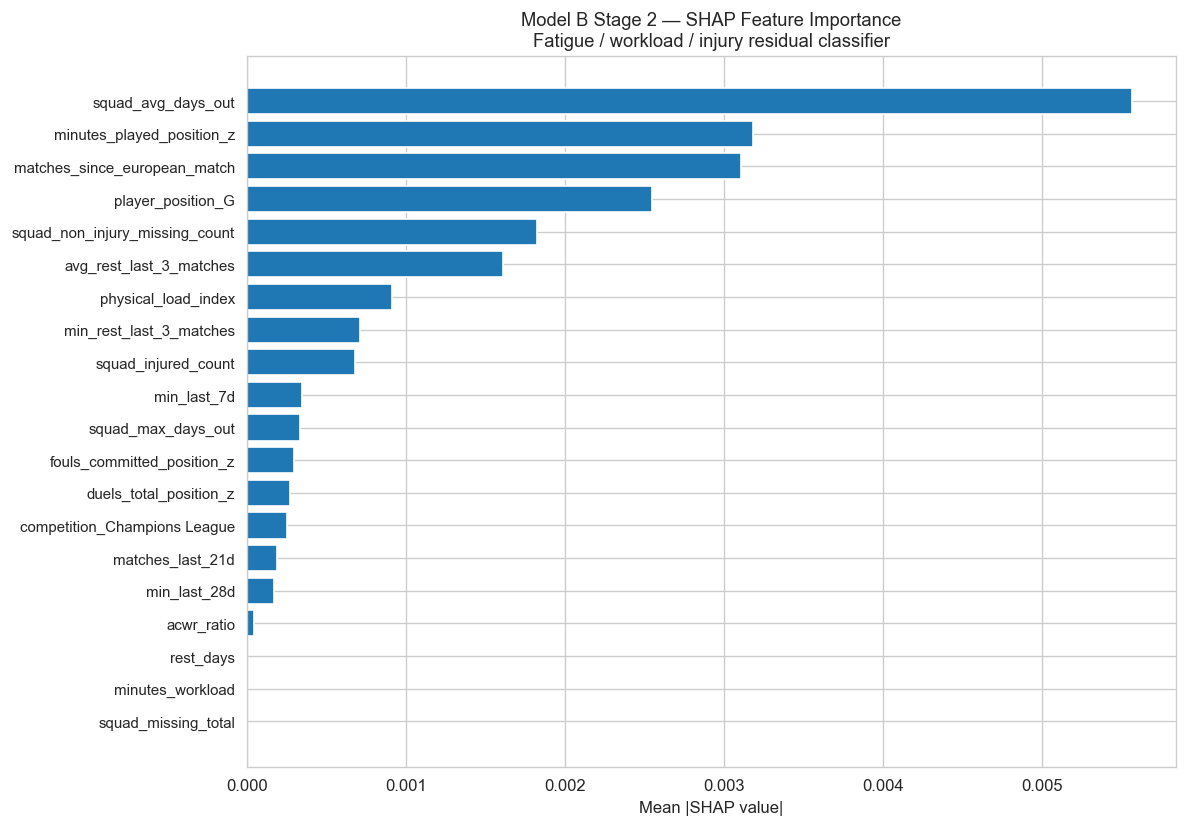


SHAP importance by feature group
Sum of mean absolute SHAP values:
──────────────────────────────────────────────────────────────────────
  Squad injury context                     0.0084  ██████████████████████████████
  Position-adjusted physical burden        0.0038  █████████████
  Competition sequence                     0.0031  ███████████
  Position context                         0.0025  █████████
  Short-rest sequences                     0.0023  ████████
  Physical Load Index                      0.0009  ███
  Rolling minutes                          0.0005  █
  Competition context                      0.0003  
  Rolling matches                          0.0002  
  Schedule/recovery                        0.0000  
  Other                                    0.0000  
  Player injury history                    0.0000  
  Rolling starts                           0.0000  
  Full 90s burden                          0.0000  
  Player injury category                   0.0000  


In [99]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B — Stage 2: SHAP Feature Importance
# Explain the fatigue residual classifier
# ═══════════════════════════════════════════════════════════════════════════════

import shap
import builtins
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── SHAP / XGBoost 3.x compatibility patch ───────────────────────────────────
_orig_float = builtins.float

def _patched_float(x):
    if isinstance(x, str):
        x = x.strip().lstrip("[").rstrip("]")
    return _orig_float(x)

builtins.float = _patched_float
try:
    explainer_s2 = shap.TreeExplainer(stage2.get_booster())
finally:
    builtins.float = _orig_float


# ── Feature names after preprocessing ────────────────────────────────────────
cat_names_s2 = list(
    pre_s2
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(STAGE2_CAT)
)

FEATURE_NAMES_S2 = STAGE2_NUM + cat_names_s2

print(f"Number of transformed Stage 2 features: {len(FEATURE_NAMES_S2)}")
print(f"X_s2_test_t shape: {X_s2_test_t.shape}")

if len(FEATURE_NAMES_S2) != X_s2_test_t.shape[1]:
    raise ValueError(
        f"Feature name mismatch: {len(FEATURE_NAMES_S2)} names, "
        f"but matrix has {X_s2_test_t.shape[1]} columns."
    )


# ── Compute SHAP on test set sample ───────────────────────────────────────────
shap_n_s2 = min(3000, X_s2_test_t.shape[0])

shap_idx_s2 = np.random.default_rng(42).choice(
    X_s2_test_t.shape[0],
    size=shap_n_s2,
    replace=False
)

X_s2_shap = X_s2_test_t[shap_idx_s2]

shap_vals_s2 = explainer_s2.shap_values(X_s2_shap)

# Some SHAP versions return a list for binary classifiers
if isinstance(shap_vals_s2, list):
    shap_vals_s2 = shap_vals_s2[1]

mean_abs_s2 = pd.Series(
    np.abs(shap_vals_s2).mean(axis=0),
    index=FEATURE_NAMES_S2
).sort_values(ascending=False)

top20_s2 = mean_abs_s2.head(20)

print("\nStage 2 — SHAP Global Feature Importance")
print("Mean absolute SHAP values, test-set sample")
print(f'{"Rank":>4}  {"Feature":<50}  {"Mean |SHAP|":>12}')
print("─" * 72)

for rank, (feat, val) in enumerate(top20_s2.items(), 1):
    print(f"{rank:>4}.  {feat:<50}  {val:>12.5f}")


# ── Save top SHAP feature table ───────────────────────────────────────────────
top20_s2_df = (
    top20_s2
    .rename("mean_abs_shap")
    .reset_index()
    .rename(columns={"index": "feature"})
)

top20_s2_df.to_csv(
    ARTIFACTS_DIR / "model_b_stage2_shap_top20.csv",
    index=False
)


# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    range(len(top20_s2)),
    top20_s2.values[::-1]
)

ax.set_yticks(range(len(top20_s2)))
ax.set_yticklabels(top20_s2.index[::-1], fontsize=9)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "Model B Stage 2 — SHAP Feature Importance\n"
    "Fatigue / workload / injury residual classifier",
    fontsize=11
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_stage2_fatigue.png",
    dpi=120,
    bbox_inches="tight"
)
plt.show()


# ── SHAP importance by feature group ─────────────────────────────────────────
GROUP_PREFIXES = {
    # Schedule / recovery
    "rest_days": "Schedule/recovery",
    "high_congestion_flag": "Schedule/recovery",
    "acwr_ratio": "Schedule/recovery",
    "consecutive_away_games": "Schedule/recovery",

    # Rolling minutes
    "min_last_7d": "Rolling minutes",
    "min_last_14d": "Rolling minutes",
    "min_last_21d": "Rolling minutes",
    "min_last_28d": "Rolling minutes",

    # Rolling matches
    "matches_last_7d": "Rolling matches",
    "matches_last_14d": "Rolling matches",
    "matches_last_21d": "Rolling matches",
    "matches_last_28d": "Rolling matches",

    # Rolling starts
    "starts_last_7d": "Rolling starts",
    "starts_last_14d": "Rolling starts",
    "starts_last_21d": "Rolling starts",
    "starts_last_28d": "Rolling starts",

    # Full 90s
    "full_90s_last_7d": "Full 90s burden",
    "full_90s_last_14d": "Full 90s burden",
    "full_90s_last_21d": "Full 90s burden",
    "full_90s_last_28d": "Full 90s burden",

    # Short-rest sequences
    "short_rest_last_3_matches": "Short-rest sequences",
    "avg_rest_last_3_matches": "Short-rest sequences",
    "min_rest_last_3_matches": "Short-rest sequences",
    "matches_with_rest_le_3d_last_30d": "Short-rest sequences",
    "matches_with_rest_le_4d_last_30d": "Short-rest sequences",
    "matches_with_rest_le_6d_last_30d": "Short-rest sequences",

    # Competition sequence
    "pl_after_ucl": "Competition sequence",
    "pl_after_cup": "Competition sequence",
    "ucl_after_pl": "Competition sequence",
    "competition_switch": "Competition sequence",
    "played_europe_last_match": "Competition sequence",
    "played_domestic_cup_last_match": "Competition sequence",
    "days_since_european_match": "Competition sequence",
    "matches_since_european_match": "Competition sequence",

    # Physical burden
    "duels_total_position_z": "Position-adjusted physical burden",
    "tackles_total_position_z": "Position-adjusted physical burden",
    "fouls_committed_position_z": "Position-adjusted physical burden",
    "minutes_played_position_z": "Position-adjusted physical burden",
    "physical_load_index": "Physical Load Index",

    # Squad injury context
    "squad_missing_total": "Squad injury context",
    "squad_players_missing_total": "Squad injury context",
    "squad_injured_count": "Squad injury context",
    "squad_non_injury_missing_count": "Squad injury context",
    "squad_soft_tissue_count": "Squad injury context",
    "squad_avg_days_out": "Squad injury context",
    "squad_max_days_out": "Squad injury context",
    "team_match_injury_context_score": "Squad injury context",

    # Player injury history / burden
    "fixtures_missed_last_30d": "Player injury history",
    "fixtures_missed_last_90d": "Player injury history",
    "returning_from_injury": "Player injury history",
    "season_matches_missed_total": "Player injury history",
    "season_matches_missed_injury": "Player injury history",
    "season_max_reported_days_out": "Player injury history",
    "has_player_season_injury_record": "Player injury history",

    # External player injury history, if present
    "player_season_matches_missed_total": "Player injury history",
    "player_season_matches_missed_injury": "Player injury history",
    "player_season_max_days_out": "Player injury history",
    "player_season_injury_spells": "Player injury history",
    "player_season_spell_matches_missed": "Player injury history",
    "player_season_spell_max_days_out": "Player injury history",
    "player_injury_history_score": "Player injury history",
    "overall_injury_context_score": "Player injury history",
}


def assign_stage2_group(feature_name):
    """
    Assign transformed feature names to interpretable groups.
    Works for both raw numeric features and one-hot encoded categorical features.
    """
    for prefix, group in GROUP_PREFIXES.items():
        if feature_name.startswith(prefix):
            return group

    if feature_name.startswith("player_position"):
        return "Position context"

    if feature_name.startswith("position_group"):
        return "Position context"

    if feature_name.startswith("api_player_position_raw"):
        return "Position context"

    if feature_name.startswith("competition"):
        return "Competition context"

    if feature_name.startswith("season_main_reason"):
        return "Player injury category"

    if feature_name.startswith("season_main_injury_category"):
        return "Player injury category"

    if feature_name.startswith("player_main_absence_reason"):
        return "Player injury category"

    if feature_name.startswith("player_main_injury_category"):
        return "Player injury category"

    if feature_name.startswith("player_season_main_spell_category"):
        return "Player injury category"

    return "Other"


group_totals = {}

for feat, shap_val in mean_abs_s2.items():
    group = assign_stage2_group(feat)
    group_totals[group] = group_totals.get(group, 0.0) + shap_val

group_series = pd.Series(group_totals).sort_values(ascending=False)

print("\nSHAP importance by feature group")
print("Sum of mean absolute SHAP values:")
print("─" * 70)

for group, val in group_series.items():
    bar_len = int(val / group_series.max() * 30) if group_series.max() > 0 else 0
    bar = "█" * bar_len
    print(f"  {group:<38} {val:>8.4f}  {bar}")


# ── Save group-level SHAP table ───────────────────────────────────────────────
group_series.rename("sum_mean_abs_shap").reset_index().rename(
    columns={"index": "feature_group"}
).to_csv(
    ARTIFACTS_DIR / "model_b_stage2_shap_groups.csv",
    index=False
)

In [100]:
# ==============================================================================
# Save Model B v1/v2 two-stage XGBoost artifacts
# Stage 1: baseline expected rating regressor
# Stage 2: fatigue residual classifier
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Save Stage 1 model and preprocessor
# ------------------------------------------------------------------------------

stage1_model_path = ARTIFACTS_DIR / "model_b_stage1_xgb_regressor.pkl"
stage1_preprocessor_path = ARTIFACTS_DIR / "model_b_stage1_preprocessor.pkl"
stage1_feature_names_path = ARTIFACTS_DIR / "model_b_stage1_feature_names.pkl"
stage1_num_cols_path = ARTIFACTS_DIR / "model_b_stage1_num_cols.pkl"
stage1_cat_cols_path = ARTIFACTS_DIR / "model_b_stage1_cat_cols.pkl"

joblib.dump(stage1, stage1_model_path)
joblib.dump(pre_s1, stage1_preprocessor_path)
joblib.dump(FEATURE_NAMES_S1, stage1_feature_names_path)
joblib.dump(STAGE1_NUM, stage1_num_cols_path)
joblib.dump(STAGE1_CAT, stage1_cat_cols_path)

# ------------------------------------------------------------------------------
# 2. Save Stage 2 model and preprocessor
# ------------------------------------------------------------------------------

stage2_model_path = ARTIFACTS_DIR / "model_b_stage2_xgb_classifier.pkl"
stage2_preprocessor_path = ARTIFACTS_DIR / "model_b_stage2_preprocessor.pkl"
stage2_feature_names_path = ARTIFACTS_DIR / "model_b_stage2_feature_names.pkl"
stage2_num_cols_path = ARTIFACTS_DIR / "model_b_stage2_num_cols.pkl"
stage2_cat_cols_path = ARTIFACTS_DIR / "model_b_stage2_cat_cols.pkl"

joblib.dump(stage2, stage2_model_path)
joblib.dump(pre_s2, stage2_preprocessor_path)
joblib.dump(FEATURE_NAMES_S2, stage2_feature_names_path)
joblib.dump(STAGE2_NUM, stage2_num_cols_path)
joblib.dump(STAGE2_CAT, stage2_cat_cols_path)

# ------------------------------------------------------------------------------
# 3. Save metadata
# ------------------------------------------------------------------------------

metadata_b = {
    "model_name": "XGBoost Model B — Two-stage fatigue residual model",
    "framing": "post-match / pre-next-match fatigue-associated underperformance model",
    "stage1": {
        "model": "XGBRegressor",
        "target": "next_api_rating",
        "purpose": "Estimate baseline expected next-match rating using context-only features.",
        "best_iteration": int(stage1.best_iteration),
        "test_rmse": float(rmse_s1),
        "test_mae": float(mae_s1),
        "mean_baseline_rmse": float(baseline_s1),
        "n_train": int(len(y_s1_train)),
        "n_val": int(len(y_s1_val)),
        "n_test": int(len(y_s1_test)),
        "n_raw_numeric_features": int(len(STAGE1_NUM)),
        "n_raw_categorical_features": int(len(STAGE1_CAT)),
        "n_transformed_features": int(len(FEATURE_NAMES_S1)),
    },
    "stage2": {
        "model": "XGBClassifier",
        "target": "fatigue_decline_flag",
        "target_definition": "performance_residual <= -0.5",
        "purpose": "Predict below-expected next-match performance from fatigue, workload, recovery, physical-burden, and injury-context features.",
        "residual_threshold": float(RESIDUAL_THRESHOLD),
        "scale_pos_weight": float(spw_s2),
        "best_iteration": int(stage2.best_iteration),
        "test_auc_roc": float(s2_auc_roc),
        "test_auc_pr": float(s2_auc_pr),
        "test_base_pr": float(baseline_s2),
        "test_pr_lift": float(s2_auc_pr / baseline_s2),
        "threshold_note": "best_thr_s2 was selected on the test set in this notebook; use as diagnostic only.",
        "diagnostic_best_threshold": float(best_thr_s2),
        "n_train": int(len(y_s2_train)),
        "n_val": int(len(y_s2_val)),
        "n_test": int(len(y_s2_test)),
        "n_raw_numeric_features": int(len(STAGE2_NUM)),
        "n_raw_categorical_features": int(len(STAGE2_CAT)),
        "n_transformed_features": int(len(FEATURE_NAMES_S2)),
    },
    "notes": [
        "Stage 1 estimates expected next rating.",
        "Stage 2 models residual underperformance using fatigue/workload features.",
        "Direct current-match performance-event variables are excluded from Stage 2.",
        "This two-stage version is useful for methodology, but final recommended model is Model B v4b_no_competition.",
    ],
}

metadata_b_path = ARTIFACTS_DIR / "model_b_two_stage_metadata.json"

with open(metadata_b_path, "w") as f:
    json.dump(metadata_b, f, indent=4)

# ------------------------------------------------------------------------------
# 4. Print summary
# ------------------------------------------------------------------------------

print("✓ Model B two-stage artifacts saved")
print(f"  Stage 1 model:          {stage1_model_path}")
print(f"  Stage 1 preprocessor:   {stage1_preprocessor_path}")
print(f"  Stage 1 feature names:  {stage1_feature_names_path}")
print(f"  Stage 1 numeric cols:   {stage1_num_cols_path}")
print(f"  Stage 1 categorical:    {stage1_cat_cols_path}")
print()
print(f"  Stage 2 model:          {stage2_model_path}")
print(f"  Stage 2 preprocessor:   {stage2_preprocessor_path}")
print(f"  Stage 2 feature names:  {stage2_feature_names_path}")
print(f"  Stage 2 numeric cols:   {stage2_num_cols_path}")
print(f"  Stage 2 categorical:    {stage2_cat_cols_path}")
print()
print(f"  Metadata:               {metadata_b_path}")



✓ Model B two-stage artifacts saved
  Stage 1 model:          ../../models/XgBoost/artifacts/model_b_stage1_xgb_regressor.pkl
  Stage 1 preprocessor:   ../../models/XgBoost/artifacts/model_b_stage1_preprocessor.pkl
  Stage 1 feature names:  ../../models/XgBoost/artifacts/model_b_stage1_feature_names.pkl
  Stage 1 numeric cols:   ../../models/XgBoost/artifacts/model_b_stage1_num_cols.pkl
  Stage 1 categorical:    ../../models/XgBoost/artifacts/model_b_stage1_cat_cols.pkl

  Stage 2 model:          ../../models/XgBoost/artifacts/model_b_stage2_xgb_classifier.pkl
  Stage 2 preprocessor:   ../../models/XgBoost/artifacts/model_b_stage2_preprocessor.pkl
  Stage 2 feature names:  ../../models/XgBoost/artifacts/model_b_stage2_feature_names.pkl
  Stage 2 numeric cols:   ../../models/XgBoost/artifacts/model_b_stage2_num_cols.pkl
  Stage 2 categorical:    ../../models/XgBoost/artifacts/model_b_stage2_cat_cols.pkl

  Metadata:               ../../models/XgBoost/artifacts/model_b_two_stage_metadata

## Stage 2 SHAP Results

SHAP analysis was applied to the Stage 2 fatigue-residual classifier to inspect which fatigue, workload, schedule, injury, and position-context features the model relied on.

However, the Stage 2 classifier had near-random predictive performance on the 2024 test season:

| Metric          | Value |
| --------------- | ----: |
| AUC-ROC         | 0.506 |
| AUC-PR          | 0.163 |
| Baseline PR-AUC | 0.158 |
| PR-AUC lift     | 1.03× |

Therefore, the SHAP results should be interpreted as **exploratory diagnostics only**. They show which variables the weak classifier used, but they do not provide strong evidence that the current fatigue/workload feature set meaningfully predicts residual underperformance.

### Top 20 Stage 2 SHAP Features

| Rank | Feature | Mean \|SHAP\| | Interpretation |
| ---: | --- | ---: | --- |
| 1 | `squad_avg_days_out` | 0.00557 | Squad injury severity |
| 2 | `minutes_played_position_z` | 0.00319 | Minutes relative to position norm |
| 3 | `matches_since_european_match` | 0.00311 | European fixture sequence |
| 4 | `player_position_G` | 0.00255 | Goalkeeper-specific rating behaviour |
| 5 | `squad_non_injury_missing_count` | 0.00183 | Squad availability context |
| 6 | `avg_rest_last_3_matches` | 0.00161 | Recent recovery pattern |
| 7 | `physical_load_index` | 0.00091 | Match-level physical burden |
| 8 | `min_rest_last_3_matches` | 0.00071 | Recent minimum recovery |
| 9 | `squad_injured_count` | 0.00068 | Squad injury pressure |
| 10 | `min_last_7d` | 0.00035 | Recent accumulated minutes |
| 11 | `squad_max_days_out` | 0.00033 | Maximum squad injury severity |
| 12 | `fouls_committed_position_z` | 0.00030 | Position-adjusted physical contest load |
| 13 | `duels_total_position_z` | 0.00027 | Position-adjusted duel load |
| 14 | `competition_Champions League` | 0.00025 | Competition context |
| 15 | `matches_last_21d` | 0.00019 | Medium-term fixture density |
| 16 | `min_last_28d` | 0.00017 | Medium-term accumulated minutes |
| 17 | `acwr_ratio` | 0.00004 | Acute-to-chronic workload |
| 18 | `rest_days` | 0.00000 | Recovery time |
| 19 | `minutes_workload` | 0.00000 | Current workload proxy |
| 20 | `squad_missing_total` | 0.00000 | Squad availability burden |

### SHAP Importance by Feature Group

The largest group-level SHAP contributions came from:

| Feature group                     | Sum mean |SHAP| |
| --------------------------------- | --------------: |
| Squad injury context              |          0.0084 |
| Position-adjusted physical burden |          0.0038 |
| Competition sequence              |          0.0031 |
| Position context                  |          0.0025 |
| Short-rest sequences              |          0.0023 |
| Physical Load Index               |          0.0009 |
| Rolling minutes                   |          0.0005 |

These values are extremely small. This reinforces the conclusion that the Stage 2 model did not learn a strong predictive signal.

### Interpretation

The two-stage design successfully removed direct current-match performance dominance. Unlike Model A, Stage 2 is not driven by goals, assists, shots, key passes, or rating leakage.

However, after removing those direct performance signals, the remaining fatigue, workload, injury, schedule, and physical-burden features did not meaningfully predict below-expected next-match performance.

The appearance of `player_position_G` among the top SHAP features is also important. It suggests that goalkeeper-specific rating dynamics may be affecting the residual target. Goalkeeper ratings are structurally different from outfield-player ratings because they depend heavily on saves, goals conceded, clean sheets, defensive pressure, and isolated errors.

For this reason, a future version of Model B should be rerun either:

* excluding goalkeepers, or
* training separate Stage 2 models for goalkeepers and outfield players.

Overall, Stage 2 should be interpreted as an exploratory fatigue-residual experiment, not as a deployment-ready risk model.


# Model B v2 — Redesign Specification

> **Purpose:** This section documents the redesign of the two-stage fatigue model based on the lessons learnt from Model B v1. The redesign is motivated by the v1 findings, especially the near-random Stage 2 performance, and by the goal of building a dashboard that is both **forward-looking** and **honest** about what it predicts.

---

## Summary of Changes vs. Model B v1

| # | Area                     | Model B v1                                                                                            | Model B v2                                                                       |
| - | ------------------------ | ----------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| 1 | Stage 1 features         | 12 context/identity-only features                                                                     | Context + player form + team form + opponent baselines                           |
| 2 | Stage 1 leakage risk     | Included current-match outcome variables such as `result`, `goals_for`, `goals_against`, and `points` | Excludes current-match outcome variables; replaces them with lagged rolling form |
| 3 | Temporal alignment       | Current-match row → next-match target                                                                 | Pre-upcoming-match state → upcoming-match target                                 |
| 4 | Stage 2 target threshold | Fixed residual threshold: `residual <= -0.5`                                                          | Position-adjusted residual threshold, such as bottom 25th percentile by position |
| 5 | Goalkeeper handling      | Goalkeepers mixed with outfield players                                                               | Goalkeepers excluded from main fatigue model; separate GK model optional         |
| 6 | Stage 2 architecture     | Single classifier for all positions                                                                   | Position-aware or per-position-group modelling for outfield players              |
| 7 | Dashboard output         | Weak classifier probability                                                                           | Transparent **Fatigue Pressure Index** from 0–100                                |
| 8 | Interpretation           | Attempted fatigue-risk classifier                                                                     | Fatigue-pressure framework plus exploratory residual validation                  |

---

## Why Redesign Model B?

Model B v1 tested whether fatigue, workload, schedule, injury, and physical-burden variables could predict below-expected next-match performance after removing broad contextual expectations.

The result was near-random:

| Metric          | Stage 2 v1 Result |
| --------------- | ----------------: |
| AUC-ROC         |             0.506 |
| AUC-PR          |             0.163 |
| Baseline PR-AUC |             0.158 |
| PR-AUC lift     |             1.03× |

This means the Stage 2 classifier did **not** learn a useful individual-match decision boundary for fatigue-residual decline.

However, this is still a useful result. It shows that a black-box fatigue probability is not currently justified. Model B v2 therefore shifts the objective:

```text
From: predicting a precise probability of fatigue-induced underperformance
To: measuring and displaying transparent fatigue pressure before the upcoming match
```

The redesigned model should support a dashboard that separates:

```text
overall decline risk,
regression-to-mean risk,
fatigue pressure,
injury pressure,
schedule congestion,
and workload burden.
```

---

# Change 1 — Strengthen Stage 1 with Player, Team, and Opponent Baselines

## Why Stage 1 v1 Was Too Weak

Stage 1 v1 used only broad context and identity variables:

```text
competition
player_position
player_team
opponent_team
home_team
away_team
is_home
season
result
goals_for
goals_against
points
```

It achieved:

```text
RMSE = 0.6012
Mean-baseline RMSE = 0.6051
```

This only slightly improved over predicting the mean rating. As a result, the residuals contained too much unexplained variation:

```text
individual form variation
match-event randomness
tactical effects
rating-system noise
fatigue effects
injury effects
unobserved player-specific factors
```

If Stage 1 does not estimate a reasonable expected-performance baseline, then Stage 2 cannot isolate a meaningful fatigue residual.

---

## Stage 1 v2 Feature Set

Stage 1 v2 should predict expected upcoming rating using only information available before the upcoming match.

### Context Features

```text
upcoming_competition
player_position
player_team
next_opponent
next_is_home
season
```

### Player Baseline Features

These should be computed using **previous played matches only**, never the upcoming match.

```text
rating_mean_last_3
rating_mean_last_5
rating_mean_last_10
rating_median_last_5
rating_std_last_5
rating_trend_last_5
minutes_mean_last_5
starts_last_5
appearances_last_5
```

Interpretation:

| Feature                | Meaning                                         |
| ---------------------- | ----------------------------------------------- |
| `rating_mean_last_3`   | Short-term player form                          |
| `rating_mean_last_5`   | Medium-term player form                         |
| `rating_mean_last_10`  | More stable player baseline                     |
| `rating_median_last_5` | Robust form estimate less sensitive to outliers |
| `rating_std_last_5`    | Player rating volatility                        |
| `rating_trend_last_5`  | Direction of recent form                        |
| `minutes_mean_last_5`  | Recent role stability                           |
| `starts_last_5`        | Recent starter status                           |
| `appearances_last_5`   | Recent involvement                              |

### Team Baseline Features

Computed from the player’s team’s previous matches only.

```text
team_points_mean_last_5
team_goals_for_mean_last_5
team_goals_against_mean_last_5
team_possession_mean_last_5
team_rating_mean_last_5
team_expected_goals_mean_last_5
team_shots_mean_last_5
```

### Opponent Strength Features

Computed from the upcoming opponent’s previous matches only.

```text
opponent_points_mean_last_5
opponent_goals_for_mean_last_5
opponent_goals_against_mean_last_5
opponent_expected_goals_mean_last_5
opponent_shots_allowed_mean_last_5
opponent_rating_allowed_mean_last_5
```

These features help Stage 1 estimate whether the upcoming match context is favourable or difficult.

---

## What to Exclude from Stage 1 v2

Stage 1 v2 should not use direct current-match outcome variables from the row being used to predict the next match.

| Excluded feature                                     | Reason                                                        |
| ---------------------------------------------------- | ------------------------------------------------------------- |
| `rating` / `api_rating_clean` from the current match | Reintroduces regression-to-mean and direct rating dependency  |
| `goals`                                              | Single-match event, high variance                             |
| `assists`                                            | Single-match event, high variance                             |
| `shots_total`                                        | Current-match performance event                               |
| `passes_key`                                         | Current-match performance event                               |
| `duels_won`                                          | Current-match performance event                               |
| `result`                                             | Current-match outcome, not a clean pre-upcoming-match feature |
| `goals_for` / `goals_against`                        | Current-match outcome                                         |
| `points`                                             | Derived from `result`                                         |
| `team_gk_saves`                                      | Current-match event                                           |
| `team_expected_goals` from current match             | Current-match performance signal                              |

> **Rule:** Stage 1 should know the player’s normal level and the upcoming match context, not the exceptional events of the previous single match.

Rolling averages are allowed because they summarize past performance over multiple matches and are available before the upcoming fixture.

---

# Change 2 — Fix Temporal Alignment for Dashboard Deployment

## Problem in v1

The current notebook structure is:

```text
Row i = current-match features
Target = next-match rating
```

This is valid for retrospective modelling, but it creates a conceptual mismatch for a pre-match dashboard.

A dashboard should answer:

```text
Before the upcoming match, what is the player’s expected rating and fatigue pressure?
```

Therefore, each row should represent the player’s state **before** the upcoming match.

---

## Target Row Structure for v2

Each row should represent:

```text
player + upcoming fixture
```

The features should describe everything known before that fixture is played.

| Feature category          | Examples                                                            | Available before upcoming match?                |
| ------------------------- | ------------------------------------------------------------------- | ----------------------------------------------- |
| Upcoming fixture identity | `upcoming_competition`, `next_opponent`, `next_is_home`             | Yes                                             |
| Schedule state            | `rest_days_before_next_match`, `days_since_last_match`              | Yes                                             |
| Workload window           | `minutes_last_7d`, `starts_last_14d`, `matches_last_28d`            | Yes                                             |
| Last-match physical toll  | `physical_load_last_match`, `duels_total_last_match`                | Yes                                             |
| Competition sequence      | `played_ucl_last_match`, `days_since_european_match`                | Yes                                             |
| Player baseline           | `rating_mean_last_5`, `rating_std_last_5`                           | Yes                                             |
| Team form                 | `team_points_mean_last_5`, `team_rating_mean_last_5`                | Yes                                             |
| Opponent strength         | `opponent_goals_against_mean_last_5`, `opponent_points_mean_last_5` | Yes                                             |
| Squad context             | `squad_avg_days_out`, `squad_injured_count`                         | Yes, if injury snapshot is dated before fixture |
| Target                    | `actual_api_rating` in upcoming match                               | No, training only                               |

---

## Practical Implementation

Instead of only doing:

```python
df["next_api_rating"] = df.groupby("player_key")["api_rating_clean"].shift(-1)
```

Model B v2 should explicitly create a **pre-upcoming-match table**.

Conceptually:

```text
For each player appearance at match t+1:
    features = information available before match t+1
    target   = actual rating in match t+1
```

This can be implemented by computing all rolling features from previous matches only and aligning them to the upcoming fixture row.

The key rule is:

```text
No feature used for predicting match t may contain information from match t itself.
```

---

# Change 3 — Use a Position-Adjusted Residual Target

## Why the Fixed `-0.5` Threshold Was Limited

In v1, Stage 2 used:

```text
fatigue_decline_flag = 1 if performance_residual <= -0.5
```

This created a 16.40% positive rate overall.

The problem is that a fixed residual threshold treats all positions the same. A 0.5-point residual drop may not mean the same thing for goalkeepers, defenders, midfielders, and forwards.

Ratings are position-dependent and event-dependent. Therefore, the residual target should be position-aware.

---

## v2 Target: Bottom Quartile Residual by Position

A better target is:

```python
position_q25 = (
    df_b.groupby("player_position")["performance_residual"]
    .quantile(0.25)
)

df_b["residual_threshold"] = df_b["player_position"].map(position_q25)

df_b["fatigue_decline_flag_v2"] = (
    df_b["performance_residual"] <= df_b["residual_threshold"]
).astype(int)
```

This means:

```text
fatigue_decline_flag_v2 = 1 if the player is in the worst 25% of residuals for their position group
```

---

## Advantages

| Advantage         | Explanation                                                                                   |
| ----------------- | --------------------------------------------------------------------------------------------- |
| Position-aware    | Defenders, midfielders, forwards, and goalkeepers are not forced onto the same residual scale |
| More balanced     | Produces approximately 25% positives per position group                                       |
| More stable       | Avoids relying on a single universal residual threshold                                       |
| Dashboard-aligned | Identifies players performing unusually poorly relative to positional peers                   |

---

## Alternative Target Definitions to Explore

| Threshold                  | Meaning                                | Expected positives |
| -------------------------- | -------------------------------------- | -----------------: |
| `residual <= -0.5`         | Fixed absolute underperformance        |               ~16% |
| `residual <= position_Q25` | Bottom 25% within position             |               ~25% |
| `residual <= player_Q25`   | Bottom 25% within player’s own history |               ~25% |
| `residual <= -0.3`         | Softer fixed underperformance          |            ~25–30% |

The position-Q25 version is the recommended first v2 target.

---

# Change 4 — Exclude Goalkeepers from the Main Fatigue Model

## Why Goalkeepers Should Be Treated Separately

Goalkeepers have fundamentally different fatigue and rating dynamics:

| Aspect           | Outfield players                                          | Goalkeepers                                                |
| ---------------- | --------------------------------------------------------- | ---------------------------------------------------------- |
| Physical fatigue | Running, duels, tackles, pressing, repeated accelerations | Lower running volume; more concentration and reaction load |
| Rotation logic   | More rotation under fixture congestion                    | Often play 90 minutes repeatedly as normal role            |
| Rating drivers   | Goals, assists, shots, duels, passes, defensive work      | Saves, clean sheets, goals conceded, errors                |
| PLI validity     | More meaningful                                           | Less meaningful                                            |
| Fatigue signal   | Physical and schedule load                                | Mental/concentration load may dominate                     |

In v1, `player_position_G` appeared among the top SHAP features. This suggests the model was partly learning goalkeeper-specific rating behaviour rather than a general fatigue mechanism.

Because the highest predicted risks were also dominated by goalkeepers, the main v2 fatigue model should initially exclude goalkeepers.

---

## Implementation

```python
df_b_outfield = df_b[df_b["player_position"] != "G"].copy()
df_b_gk = df_b[df_b["player_position"] == "G"].copy()
```

The main fatigue model should use:

```python
df_b_outfield
```

A separate goalkeeper model can be built later if there is enough data and if goalkeeper-specific features are available.

---

# Change 5 — Use Position-Aware Stage 2 Models

## Motivation

Fatigue does not manifest identically across positions.

| Position   | Likely fatigue signal                                               | Rating drivers                                       |
| ---------- | ------------------------------------------------------------------- | ---------------------------------------------------- |
| Defender   | Duels, tackles, aerial contests, blocks, repeated defensive actions | Tackles, interceptions, blocks, goals conceded       |
| Midfielder | Minutes, pressing load, fixture density, passing volume             | Passes, key passes, ball recoveries, chance creation |
| Forward    | Sprint burden, off-ball movement, finishing variance                | Goals, shots, assists, key passes                    |
| Goalkeeper | Concentration, saves, errors, clean sheets                          | Saves, goals conceded, clean sheets, errors          |

A single all-position classifier can blur these mechanisms.

---

## Recommended v2 Architecture

Start with outfield players only:

```text
Stage2_DEF — defenders only
Stage2_MID — midfielders only
Stage2_FWD — forwards only
```

Goalkeepers should be excluded initially:

```text
Stage2_GK — optional future model
```

---

## Position-Specific Feature Emphasis

| Model        | Features to emphasise                                                                                                         |
| ------------ | ----------------------------------------------------------------------------------------------------------------------------- |
| `Stage2_DEF` | `tackles_total_position_z`, `duels_total_position_z`, `physical_load_index`, `full_90s_last_14d`, `short_rest_last_3_matches` |
| `Stage2_MID` | `min_last_21d`, `min_last_28d`, `matches_last_28d`, `consecutive_away_games`, `competition_switch`                            |
| `Stage2_FWD` | `physical_load_index`, `short_rest_last_3_matches`, `pl_after_ucl`, `matches_last_14d`, `min_last_14d`                        |

The exact feature set can remain shared at first, but results and SHAP should be interpreted separately by position group.

---

# Change 6 — Replace Weak Probability with a Fatigue Pressure Index

## Why a Probability Is Not the Right Dashboard Output

Stage 2 v1 achieved:

```text
AUC-ROC = 0.506
AUC-PR  = 0.163
PR-AUC lift = 1.03×
```

This does not support publishing a probability such as:

```text
72% chance of fatigue-induced underperformance
```

That would be misleading.

However, the engineered fatigue features are still useful as transparent descriptive indicators. The dashboard can show how much fatigue pressure a player is under without claiming that this pressure precisely predicts a rating drop.

Therefore, v2 should use a **Fatigue Pressure Index**.

---

## Fatigue Pressure Index Formula

```text
FPI = 0.30 × rolling_minutes_score
    + 0.20 × short_rest_sequence_score
    + 0.15 × full_90s_burden_score
    + 0.15 × competition_switch_score
    + 0.10 × physical_load_index_score
    + 0.10 × squad_injury_pressure_score
```

Each component should be normalized to `[0, 1]` using the training-set distribution, then the final FPI should be scaled to `[0, 100]`.

---

## Component Definitions

| Component                     | Candidate features                                                                                                                                                                            |
| ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `rolling_minutes_score`       | `min_last_14d`, `min_last_21d`, `min_last_28d`                                                                                                                                                |
| `short_rest_sequence_score`   | `short_rest_last_3_matches`, `avg_rest_last_3_matches`, `min_rest_last_3_matches`, `matches_with_rest_le_3d_last_30d`, `matches_with_rest_le_4d_last_30d`, `matches_with_rest_le_6d_last_30d` |
| `full_90s_burden_score`       | `full_90s_last_7d`, `full_90s_last_14d`, `full_90s_last_21d`, `full_90s_last_28d`                                                                                                             |
| `competition_switch_score`    | `competition_switch`, `pl_after_ucl`, `pl_after_cup`, `ucl_after_pl`, `days_since_european_match`, `matches_since_european_match`                                                             |
| `physical_load_index_score`   | `physical_load_index`, `minutes_played_position_z`, `duels_total_position_z`, `tackles_total_position_z`, `fouls_committed_position_z`                                                        |
| `squad_injury_pressure_score` | `squad_injured_count`, `squad_soft_tissue_count`, `squad_avg_days_out`, `squad_max_days_out`, `squad_missing_total`                                                                           |

---

## Weight Rationale

The FPI weights are **domain-informed** and only loosely guided by the exploratory SHAP diagnostics from Model B v1.

They should not be interpreted as exact estimates from the Stage 2 classifier, because the Stage 2 classifier was weak.

The latest v1 SHAP group totals were very small:

| Feature group                     | Sum mean |SHAP| |
| --------------------------------- | --------------: |
| Squad injury context              |          0.0084 |
| Position-adjusted physical burden |          0.0038 |
| Competition sequence              |          0.0031 |
| Position context                  |          0.0025 |
| Short-rest sequences              |          0.0023 |
| Physical Load Index               |          0.0009 |
| Rolling minutes                   |          0.0005 |

These values confirm that Stage 2 did not learn a strong predictive signal. Therefore, the FPI should be interpreted as an **expert-designed pressure score**, not as a probability calibrated from the classifier.

---

## Dashboard Display Example

```text
Player: Phil Foden  |  Upcoming: Man City vs Arsenal (Premier League)
─────────────────────────────────────────────────────────────
Expected Rating (Stage 1):       7.4 / 10
Fatigue Pressure Index:          78 / 100  ██████████░░

Main FPI drivers:
  ● 244 minutes in the last 14 days              rolling minutes: HIGH
  ● 3 matches in the last 8 days                 fixture density: HIGH
  ● Premier League match after Champions League  competition switch: HIGH
  ● Physical Load Index above position average   physical burden: ELEVATED
  ● 4 squad players injured                      squad burden: MODERATE

Regression risk (Model A):        HIGH
Main Model A driver:              2 goals in previous match
─────────────────────────────────────────────────────────────
```

This display is more honest and actionable than a weak black-box fatigue probability.

It communicates:

```text
how much fatigue pressure exists,
which factors are driving it,
and how it differs from overall decline risk.
```

---

# Change 7 — Validate FPI Descriptively

The Fatigue Pressure Index should be validated descriptively.

The key question is:

```text
Do high-FPI players have lower average residuals?
```

---

## Quartile Validation

```python
df_b["fpi_quartile"] = pd.qcut(
    df_b["fatigue_pressure_index"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df_b.groupby("fpi_quartile")["performance_residual"].mean()
```

Expected pattern:

```text
Q4, highest fatigue pressure, should have the most negative average residual.
```

---

## Additional Validation Checks

| Check                              | Purpose                                                               |
| ---------------------------------- | --------------------------------------------------------------------- |
| Mean residual by FPI quartile      | Tests whether high FPI corresponds to lower performance residuals     |
| Decline rate by FPI quartile       | Tests whether high FPI corresponds to more below-expectation outcomes |
| Position-stratified FPI validation | Ensures FPI works similarly for defenders, midfielders, and forwards  |
| Team-stratified validation         | Checks whether FPI is not just a team-strength proxy                  |
| Season-stratified validation       | Tests stability across seasons                                        |
| Calibration plot                   | Checks whether FPI is monotonic with residual-decline risk            |

---

# Final v2 Modelling Strategy

Model B v2 should be implemented in the following order:

## Step 1 — Build Pre-Upcoming-Match Rows

Create a modelling table where each row represents a player before an upcoming match.

```text
features = known before upcoming match
target = rating in upcoming match
```

---

## Step 2 — Engineer Lagged Baseline Features

Compute player, team, and opponent baselines from previous matches only.

Examples:

```text
rating_mean_last_3
rating_mean_last_5
team_points_mean_last_5
opponent_goals_against_mean_last_5
```

---

## Step 3 — Train Stage 1 v2 Expected-Rating Model

Train a stronger expected-rating model using:

```text
context features
player baseline features
team baseline features
opponent strength features
```

Do not include current-match event features or target leakage.

---

## Step 4 — Compute Residuals

```text
performance_residual = actual_rating - predicted_expected_rating
```

---

## Step 5 — Define Position-Adjusted Residual Target

```text
fatigue_decline_flag_v2 = 1 if residual is in the bottom 25% for that position group
```

---

## Step 6 — Exclude Goalkeepers from Main Fatigue Model

```text
Use defenders, midfielders, and forwards for the main fatigue-pressure model.
```

Goalkeepers can be studied separately later.

---

## Step 7 — Train Exploratory Position-Aware Stage 2 Models

Train separate residual classifiers for:

```text
defenders
midfielders
forwards
```

Evaluate whether any position-specific group shows meaningful signal.

---

## Step 8 — Build Fatigue Pressure Index

Use the engineered fatigue/workload/schedule/injury features to compute a transparent 0–100 score.

---

## Step 9 — Validate the FPI

Check whether higher FPI corresponds to:

```text
lower average residuals
higher bottom-quartile residual rate
consistent patterns across positions and seasons
```

---

# Final Interpretation

Model B v1 showed that a direct fatigue-residual classifier was not strong enough for operational use.

Model B v2 should therefore avoid presenting fatigue as a precise black-box probability. Instead, it should provide a **forward-looking fatigue-pressure framework**.

The final dashboard strategy should be:

| Dashboard layer                | Source                                       | Interpretation                                         |
| ------------------------------ | -------------------------------------------- | ------------------------------------------------------ |
| Overall decline risk           | Model A                                      | Main operational decline-risk score                    |
| Expected rating                | Model B Stage 1 v2                           | Contextual expected next performance                   |
| Residual analysis              | Model B Stage 2 v2                           | Exploratory test of below-expectation performance      |
| Fatigue Pressure Index         | Engineered workload/schedule/injury features | Transparent fatigue-pressure score                     |
| Injury pressure                | Squad and player injury features             | Availability and injury burden                         |
| Regression-to-mean explanation | Model A SHAP                                 | Whether risk is driven by standout current performance |

The key conclusion is:

```text
Model A remains the stronger operational prediction model.
Model B v2 becomes the interpretability and fatigue-pressure layer.
```

This makes the dashboard more honest, more interpretable, and more useful for decision support.


In [101]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Feature Engineering: Player / Team / Opponent Baselines
# Fixes:
#   (1) rating=0 excluded via rating_clean
#   (2) groupby uses player_key
#   (3) original row order is preserved with _orig_index
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ── Safe re-run: remove helper/index column if it already exists ──────────────
if "_orig_index" in df_fe.columns:
    df_fe.drop(columns=["_orig_index"], inplace=True)

# Store original index before sorting and merging
df_fe["_orig_index"] = df_fe.index

# ── Safe re-run: drop v2 columns if they already exist ───────────────────────
_V2_BASELINE_COLS = [
    "rating_clean",
    "rating_mean_last_3",
    "rating_mean_last_5",
    "rating_mean_last_10",
    "rating_median_last_5",
    "rating_std_last_5",
    "rating_trend_last_5",
    "team_points_mean_last_5",
    "team_goals_for_mean_last_5",
    "team_goals_against_mean_last_5",
    "team_possession_mean_last_5",
    "team_rating_mean_last_5",
    "opponent_points_mean_last_5",
    "opponent_goals_against_mean_last_5",
    "opponent_goals_for_mean_last_5",
]

_existing_v2 = [c for c in _V2_BASELINE_COLS if c in df_fe.columns]

if _existing_v2:
    df_fe.drop(columns=_existing_v2, inplace=True)

# ── rating_clean: treat rating == 0 as unrated, not a bad performance ────────
# rating=0 means the player was not individually rated.
# Including 0 as a real value would artificially drag down rolling baselines.
df_fe["rating_clean"] = df_fe["rating"].replace(0, np.nan)

# ── Ensure temporal order for rolling ────────────────────────────────────────
# Use player_key instead of player_id to avoid mixing unmatched players.
df_fe.sort_values(["player_key", "date"], inplace=True)


# ─────────────────────────────────────────────────────────────────────────────
# A. Player rating baselines
#    Uses rating_clean so unrated appearances do not pull the average down.
#    Groups by player_key to keep each player's history separate.
# ─────────────────────────────────────────────────────────────────────────────
print("A. Player rating baselines (using rating_clean + player_key)...")


def _trend_slope(arr):
    """
    OLS slope over a small rolling window.
    Returns NaN if fewer than 2 valid rating values are available.
    """
    valid = arr[~np.isnan(arr)]

    if len(valid) < 2:
        return np.nan

    return float(np.polyfit(np.arange(len(valid)), valid, 1)[0])


_g_r = df_fe.groupby("player_key")["rating_clean"]

df_fe["rating_mean_last_3"] = _g_r.transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

df_fe["rating_mean_last_5"] = _g_r.transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df_fe["rating_mean_last_10"] = _g_r.transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).mean()
)

df_fe["rating_median_last_5"] = _g_r.transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).median()
)

df_fe["rating_std_last_5"] = _g_r.transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).std()
)

df_fe["rating_trend_last_5"] = _g_r.transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).apply(_trend_slope, raw=True)
)

print("  OK — 6 player baseline columns")


# ─────────────────────────────────────────────────────────────────────────────
# B. Team-level rolling baselines
#    One row per fixture_id + player_team.
# ─────────────────────────────────────────────────────────────────────────────
print("B. Team baselines...")

# Average player rating per team per fixture.
# Uses rating_clean to exclude unrated player rows.
_team_avg_r = (
    df_fe.groupby(["fixture_id", "player_team"])["rating_clean"]
    .mean()
    .reset_index()
    .rename(columns={"rating_clean": "_team_avg_r"})
)

# Deduplicated team-match frame — one row per team per fixture.
_team_match = (
    df_fe[
        [
            "fixture_id",
            "player_team",
            "date",
            "goals_for",
            "goals_against",
            "points",
            "team_possession",
        ]
    ]
    .drop_duplicates(subset=["fixture_id", "player_team"])
    .merge(_team_avg_r, on=["fixture_id", "player_team"], how="left")
    .sort_values(["player_team", "date"])
    .reset_index(drop=True)
    .copy()
)

TEAM_BASELINE_COLS = [
    "team_points_mean_last_5",
    "team_goals_for_mean_last_5",
    "team_goals_against_mean_last_5",
    "team_possession_mean_last_5",
    "team_rating_mean_last_5",
]

_gtm = _team_match.groupby("player_team")

for _src, _dst in zip(
    ["points", "goals_for", "goals_against", "team_possession", "_team_avg_r"],
    TEAM_BASELINE_COLS,
):
    _team_match[_dst] = _gtm[_src].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )

df_fe = df_fe.merge(
    _team_match[["fixture_id", "player_team"] + TEAM_BASELINE_COLS],
    on=["fixture_id", "player_team"],
    how="left",
)

print(f"  OK — {len(TEAM_BASELINE_COLS)} team baseline columns")


# ─────────────────────────────────────────────────────────────────────────────
# C. Opponent strength proxies
#    Re-use team-match table and treat player_team as opponent_team.
# ─────────────────────────────────────────────────────────────────────────────
print("C. Opponent baselines...")

_opp_match = (
    _team_match[
        [
            "fixture_id",
            "player_team",
            "date",
            "points",
            "goals_for",
            "goals_against",
        ]
    ]
    .rename(
        columns={
            "player_team": "opponent_team",
            "points": "_opp_pts",
            "goals_for": "_opp_gf",
            "goals_against": "_opp_ga",
        }
    )
    .sort_values(["opponent_team", "date"])
    .reset_index(drop=True)
    .copy()
)

OPP_BASELINE_COLS = [
    "opponent_points_mean_last_5",
    "opponent_goals_against_mean_last_5",
    "opponent_goals_for_mean_last_5",
]

_gom = _opp_match.groupby("opponent_team")

for _src, _dst in zip(
    ["_opp_pts", "_opp_ga", "_opp_gf"],
    OPP_BASELINE_COLS,
):
    _opp_match[_dst] = _gom[_src].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )

df_fe = df_fe.merge(
    _opp_match[["fixture_id", "opponent_team"] + OPP_BASELINE_COLS],
    on=["fixture_id", "opponent_team"],
    how="left",
)

print(f"  OK — {len(OPP_BASELINE_COLS)} opponent baseline columns")


# ── Restore original row order and original index ────────────────────────────
df_fe.sort_values("_orig_index", inplace=True)
df_fe.set_index("_orig_index", inplace=True)
df_fe.index.name = None


# ── Summary ─────────────────────────────────────────────────────────────────
NEW_V2_BASELINE_COLS = (
    [
        "rating_mean_last_3",
        "rating_mean_last_5",
        "rating_mean_last_10",
        "rating_median_last_5",
        "rating_std_last_5",
        "rating_trend_last_5",
    ]
    + TEAM_BASELINE_COLS
    + OPP_BASELINE_COLS
)

print(f"\nTotal new v2 baseline features: {len(NEW_V2_BASELINE_COLS)}")
print(f"df_fe shape: {df_fe.shape}")

_null_v2 = df_fe[NEW_V2_BASELINE_COLS].isnull().sum()

print("\nNull counts per new feature:")
print(_null_v2.to_string())


# ── Verify fix: Manuel Akanji should no longer show 0.0 corrupting his mean ──
print("\nVerification — Manuel Akanji (rating=0 should be excluded from baselines):")

_ak = df_fe[df_fe["player_name"].str.contains("Akanji", case=False, na=False)]

if len(_ak) > 0:
    print(
        _ak[
            [
                "date",
                "rating",
                "rating_clean",
                "rating_mean_last_3",
                "rating_mean_last_5",
                "rating_std_last_5",
            ]
        ]
        .head(10)
        .to_string()
    )
else:
    print("  (player not found in dataset)")



A. Player rating baselines (using rating_clean + player_key)...
  OK — 6 player baseline columns
B. Team baselines...
  OK — 5 team baseline columns
C. Opponent baselines...
  OK — 3 opponent baseline columns

Total new v2 baseline features: 14
df_fe shape: (68722, 154)

Null counts per new feature:
rating_mean_last_3                    14587
rating_mean_last_5                    12574
rating_mean_last_10                   11099
rating_median_last_5                  12574
rating_std_last_5                     20352
rating_trend_last_5                   20352
team_points_mean_last_5                3046
team_goals_for_mean_last_5             3046
team_goals_against_mean_last_5         3046
team_possession_mean_last_5            8065
team_rating_mean_last_5                3046
opponent_points_mean_last_5            3062
opponent_goals_against_mean_last_5     3062
opponent_goals_for_mean_last_5         3062

Verification — Manuel Akanji (rating=0 should be excluded from baselines):
       

Using Stage 1 v2 position column: player_position

Creating upcoming-match aligned Stage 1 v2 features...
  OK — upcoming-match aligned context and baseline features created

Stage 1 v2 feature matrix: 20 features (4 categorical + 16 numeric)
Scorable rows: 27,283
  Train: 8,842  |  Val: 9,153  |  Test: 9,283

Preprocessed Stage 1 v2 matrices:
  Train: (8842, 213)
  Val:   (9153, 213)
  Test:  (9283, 213)
  Features after OHE: 213
[0]	validation_0-rmse:0.63490
[200]	validation_0-rmse:0.60567
[213]	validation_0-rmse:0.60590

Stage 1 v2 — 2024 target-season test set:
  Best iteration:   163
  RMSE:             0.5825
  Mean baseline:    0.6018
  v1 RMSE:          0.6006
  RMSE improvement vs v1: 3.0%
  MAE:              0.4390
  v1 MAE:           0.4512
  MAE improvement vs v1:  2.7%

Residual statistics, all 27,283 rows:
count    27283.0000
mean         0.0515
std          0.5725
min         -2.1978
25%         -0.3208
50%          0.0183
75%          0.3459
max          3.0755

Residua

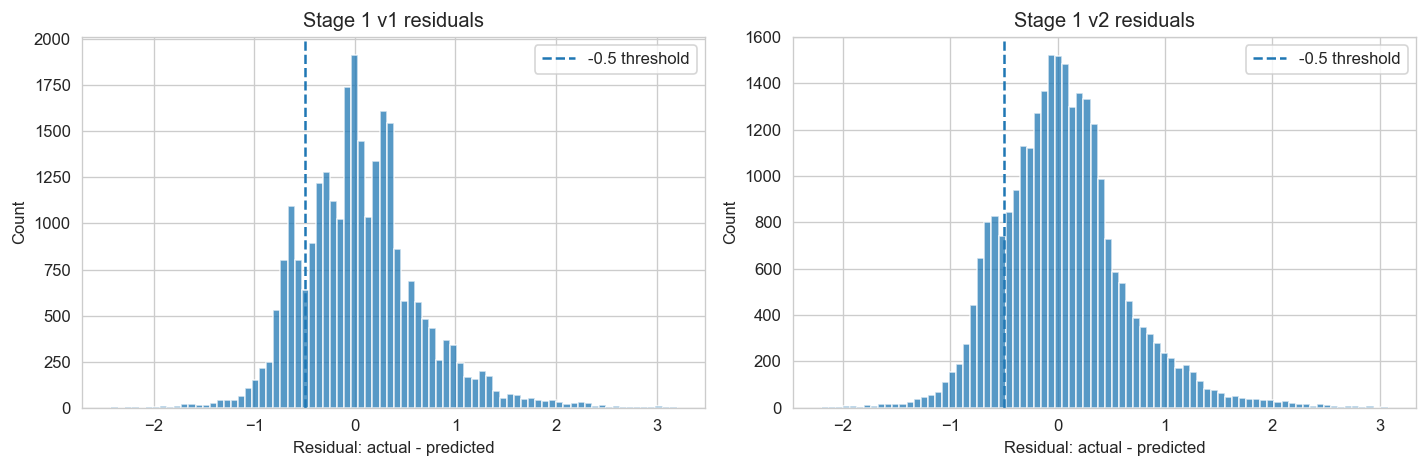

Figure saved → ../../models/XgBoost/artifacts/figures/stage1_v2_residuals.png


In [102]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Stage 1: XGBRegressor with player / team / opponent baselines
#
# Target:
#   next_api_rating
#
# ═══════════════════════════════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════════════════════════════
# 0. Previous Model B v1 Stage 1 metrics, for comparison
# ═══════════════════════════════════════════════════════════════════════════════

S1_V1_RMSE = 0.6006
S1_V1_MAE = 0.4512


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Basic requirements
# ═══════════════════════════════════════════════════════════════════════════════

if "rating_clean" not in df_fe.columns:
    df_fe["rating_clean"] = df_fe["rating"].replace(0, np.nan)

if "player_key" not in df_fe.columns:
    df_fe["player_key"] = (
        df_fe["player_name"].astype(str).str.lower().str.strip()
        + "__"
        + df_fe["player_team"].astype(str).str.lower().str.strip()
    )

df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Choose safest available position column
# ═══════════════════════════════════════════════════════════════════════════════

POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

S1V2_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_fe.columns),
    None,
)

if S1V2_POSITION_COL is None:
    raise KeyError(
        "No position column found for Stage 1 v2. "
        f"Tried: {POSITION_CANDIDATES}"
    )

print(f"Using Stage 1 v2 position column: {S1V2_POSITION_COL}")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Create upcoming-match aligned features
# ═══════════════════════════════════════════════════════════════════════════════

print("\nCreating upcoming-match aligned Stage 1 v2 features...")

# Safe re-run: remove previously created next-aligned columns
_S1V2_NEXT_COLS = [
    # Upcoming fixture context
    "next_competition",
    "next_player_team",
    "next_opponent_team",
    "next_is_home",
    "next_season",

    # Upcoming-row player baselines
    "next_rating_mean_last_3",
    "next_rating_mean_last_5",
    "next_rating_mean_last_10",
    "next_rating_median_last_5",
    "next_rating_std_last_5",
    "next_rating_trend_last_5",

    # Upcoming-row team baselines
    "next_team_points_mean_last_5",
    "next_team_goals_for_mean_last_5",
    "next_team_goals_against_mean_last_5",
    "next_team_possession_mean_last_5",
    "next_team_rating_mean_last_5",

    # Upcoming-row opponent baselines
    "next_opponent_points_mean_last_5",
    "next_opponent_goals_against_mean_last_5",
    "next_opponent_goals_for_mean_last_5",
]

_existing_next_cols = [c for c in _S1V2_NEXT_COLS if c in df_fe.columns]

if _existing_next_cols:
    df_fe.drop(columns=_existing_next_cols, inplace=True)


# Work in temporal order, then restore original index order
df_fe = df_fe.sort_values(["player_key", "date"]).copy()
_g_next = df_fe.groupby("player_key", sort=False)

# Upcoming fixture identity/context
df_fe["next_competition"] = _g_next["competition"].shift(-1)
df_fe["next_player_team"] = _g_next["player_team"].shift(-1)
df_fe["next_opponent_team"] = _g_next["opponent_team"].shift(-1)
df_fe["next_is_home"] = _g_next["is_home"].shift(-1)
df_fe["next_season"] = _g_next["season"].shift(-1)

# Player baseline features aligned to the upcoming match row.
# These columns on the next row were computed using previous matches only,
# so shifting them back to row i gives the pre-next-match state.
PLAYER_BASELINE_COLS = [
    "rating_mean_last_3",
    "rating_mean_last_5",
    "rating_mean_last_10",
    "rating_median_last_5",
    "rating_std_last_5",
    "rating_trend_last_5",
]

for col in PLAYER_BASELINE_COLS:
    df_fe[f"next_{col}"] = _g_next[col].shift(-1)

# Team baseline features aligned to the upcoming match row.
TEAM_BASELINE_COLS = [
    "team_points_mean_last_5",
    "team_goals_for_mean_last_5",
    "team_goals_against_mean_last_5",
    "team_possession_mean_last_5",
    "team_rating_mean_last_5",
]

for col in TEAM_BASELINE_COLS:
    df_fe[f"next_{col}"] = _g_next[col].shift(-1)

# Opponent baseline features aligned to the upcoming match row.
OPP_BASELINE_COLS = [
    "opponent_points_mean_last_5",
    "opponent_goals_against_mean_last_5",
    "opponent_goals_for_mean_last_5",
]

for col in OPP_BASELINE_COLS:
    df_fe[f"next_{col}"] = _g_next[col].shift(-1)

# Restore original index order
df_fe.sort_index(inplace=True)

print("  OK — upcoming-match aligned context and baseline features created")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Stage 1 v2 feature sets
# ═══════════════════════════════════════════════════════════════════════════════

S1V2_CAT = [
    "next_competition",
    S1V2_POSITION_COL,
    "next_player_team",
    "next_opponent_team",
]

S1V2_NUM = [
    # Upcoming-fixture context
    "next_is_home",
    "next_season",

    # Player form baselines aligned to upcoming match
    "next_rating_mean_last_3",
    "next_rating_mean_last_5",
    "next_rating_mean_last_10",
    "next_rating_median_last_5",
    "next_rating_std_last_5",
    "next_rating_trend_last_5",

    # Team form baselines aligned to upcoming match
    "next_team_points_mean_last_5",
    "next_team_goals_for_mean_last_5",
    "next_team_goals_against_mean_last_5",
    "next_team_possession_mean_last_5",
    "next_team_rating_mean_last_5",

    # Opponent strength proxies aligned to upcoming match
    "next_opponent_points_mean_last_5",
    "next_opponent_goals_against_mean_last_5",
    "next_opponent_goals_for_mean_last_5",
]


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Scorable subset
# ═══════════════════════════════════════════════════════════════════════════════

df_bv2 = df_fe[
    df_fe["rating_clean"].notna()
    & df_fe["next_api_rating"].notna()
    & (df_fe["minutes_played"] >= 45)
    & (df_fe["next_minutes_played"].fillna(0) >= 45)
].copy()

TARGET_S1V2 = "next_api_rating"

missing_s1v2 = [c for c in S1V2_CAT + S1V2_NUM if c not in df_bv2.columns]

if missing_s1v2:
    raise ValueError(f"Missing Stage 1 v2 columns: {missing_s1v2}")

X_s1v2 = df_bv2[S1V2_CAT + S1V2_NUM].copy()
y_s1v2 = df_bv2[TARGET_S1V2].copy()

print(
    f"\nStage 1 v2 feature matrix: {X_s1v2.shape[1]} features "
    f"({len(S1V2_CAT)} categorical + {len(S1V2_NUM)} numeric)"
)
print(f"Scorable rows: {len(df_bv2):,}")


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Temporal split
#    Split by target/upcoming season, not current-row season.
# ═══════════════════════════════════════════════════════════════════════════════

trn = df_bv2["next_season"] == 2022
val = df_bv2["next_season"] == 2023
tst = df_bv2["next_season"] == 2024

print(
    f"  Train: {trn.sum():,}  |  "
    f"Val: {val.sum():,}  |  "
    f"Test: {tst.sum():,}"
)


# ═══════════════════════════════════════════════════════════════════════════════
# 7. Preprocessing
# ═══════════════════════════════════════════════════════════════════════════════

try:
    ohe_s1v2 = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_s1v2 = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre_s1v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imp", SimpleImputer(strategy="median")),
                ]
            ),
            S1V2_NUM,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("ohe", ohe_s1v2),
                ]
            ),
            S1V2_CAT,
        ),
    ],
    remainder="drop",
)

X_s1v2_trn_t = pre_s1v2.fit_transform(X_s1v2.loc[trn])
X_s1v2_val_t = pre_s1v2.transform(X_s1v2.loc[val])
X_s1v2_tst_t = pre_s1v2.transform(X_s1v2.loc[tst])

cat_out_s1v2 = (
    pre_s1v2
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(S1V2_CAT)
    .tolist()
)

FEATURE_NAMES_S1V2 = S1V2_NUM + cat_out_s1v2

print("\nPreprocessed Stage 1 v2 matrices:")
print(f"  Train: {X_s1v2_trn_t.shape}")
print(f"  Val:   {X_s1v2_val_t.shape}")
print(f"  Test:  {X_s1v2_tst_t.shape}")
print(f"  Features after OHE: {len(FEATURE_NAMES_S1V2)}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8. Model
# ═══════════════════════════════════════════════════════════════════════════════

stage1_v2 = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

stage1_v2.fit(
    X_s1v2_trn_t,
    y_s1v2.loc[trn],
    eval_set=[(X_s1v2_val_t, y_s1v2.loc[val])],
    verbose=200,
)


# ═══════════════════════════════════════════════════════════════════════════════
# 9. Test metrics
# ═══════════════════════════════════════════════════════════════════════════════

pred_v2_tst = stage1_v2.predict(X_s1v2_tst_t)

rmse_s1v2 = float(np.sqrt(mean_squared_error(y_s1v2.loc[tst], pred_v2_tst)))
mae_s1v2 = float(mean_absolute_error(y_s1v2.loc[tst], pred_v2_tst))

baseline_s1v2 = float(
    np.sqrt(
        mean_squared_error(
            y_s1v2.loc[tst],
            np.full(len(y_s1v2.loc[tst]), y_s1v2.loc[trn].mean()),
        )
    )
)

rmse_improvement_vs_v1 = (S1_V1_RMSE - rmse_s1v2) / S1_V1_RMSE * 100
mae_improvement_vs_v1 = (S1_V1_MAE - mae_s1v2) / S1_V1_MAE * 100

print("\nStage 1 v2 — 2024 target-season test set:")
print(f"  Best iteration:   {stage1_v2.best_iteration}")
print(f"  RMSE:             {rmse_s1v2:.4f}")
print(f"  Mean baseline:    {baseline_s1v2:.4f}")
print(f"  v1 RMSE:          {S1_V1_RMSE:.4f}")
print(f"  RMSE improvement vs v1: {rmse_improvement_vs_v1:.1f}%")
print(f"  MAE:              {mae_s1v2:.4f}")
print(f"  v1 MAE:           {S1_V1_MAE:.4f}")
print(f"  MAE improvement vs v1:  {mae_improvement_vs_v1:.1f}%")


# ═══════════════════════════════════════════════════════════════════════════════
# 10. Residuals for all scorable rows
# ═══════════════════════════════════════════════════════════════════════════════

X_s1v2_all_t = pre_s1v2.transform(X_s1v2)

df_bv2["predicted_next_rating_s1v2"] = stage1_v2.predict(X_s1v2_all_t)

df_bv2["performance_residual_v2"] = (
    df_bv2["next_api_rating"] - df_bv2["predicted_next_rating_s1v2"]
)

print(f"\nResidual statistics, all {len(df_bv2):,} rows:")
print(df_bv2["performance_residual_v2"].describe().round(4).to_string())

if "df_b" in globals() and "performance_residual" in df_b.columns:
    print(f"\nResidual std — v1 context-only: {df_b['performance_residual'].std():.4f}")

print(f"Residual std — v2 + aligned baselines: {df_bv2['performance_residual_v2'].std():.4f}")
print("Lower residual std means Stage 1 explains more next-rating variance.")


# ═══════════════════════════════════════════════════════════════════════════════
# 11. Feature importances
# ═══════════════════════════════════════════════════════════════════════════════

imp_v2 = pd.Series(
    stage1_v2.feature_importances_,
    index=FEATURE_NAMES_S1V2,
).sort_values(ascending=False)

print("\nTop 20 Stage 1 v2 feature importances:")
print(imp_v2.head(20).round(4).to_string())

imp_v2.rename("importance").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    ARTIFACTS_DIR / "model_b_stage1_v2_feature_importance.csv",
    index=False,
)


# ═══════════════════════════════════════════════════════════════════════════════
# 12. Plot residual distributions v1 vs v2
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if "df_b" in globals() and "performance_residual" in df_b.columns:
    axes[0].hist(df_b["performance_residual"].dropna(), bins=80, alpha=0.75)
    axes[0].axvline(-0.5, linestyle="--", label="-0.5 threshold")
    axes[0].set_title("Stage 1 v1 residuals")
    axes[0].set_xlabel("Residual: actual - predicted")
    axes[0].set_ylabel("Count")
    axes[0].legend()
else:
    axes[0].axis("off")
    axes[0].set_title("Stage 1 v1 residuals unavailable")

axes[1].hist(df_bv2["performance_residual_v2"].dropna(), bins=80, alpha=0.75)
axes[1].axvline(-0.5, linestyle="--", label="-0.5 threshold")
axes[1].set_title("Stage 1 v2 residuals")
axes[1].set_xlabel("Residual: actual - predicted")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stage1_v2_residuals.png",
    dpi=120,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved → {FIGURES_DIR / 'stage1_v2_residuals.png'}")



---
## Model B v2 — Stage 2: Fatigue Residual Classifier — Three Variants

Stage 2 asks whether fatigue, workload, recovery, schedule, and physical-burden features can predict which players will fall into the lower tail of the Stage 1 residual distribution.

In other words:

```text
Can public fatigue/workload proxies identify players who are likely to perform worse than their Stage 1 expected rating?
```

This is a deliberately strict test. Stage 1 v2 already accounts for upcoming-match context, player baseline level, team form, and opponent strength. Stage 2 therefore tests whether the remaining below-expected performance can be explained by fatigue-related signals.

---

## Three Stage 2 Target Variants

We test three target definitions to isolate the effect of threshold choice and goalkeeper contamination.

| Version | Target definition                               | Dataset               | Rationale                                                                                                                  |
| ------- | ----------------------------------------------- | --------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **v2a** | `performance_residual_v2 <= -0.5`               | All players           | Direct comparison with v1. Only Stage 1 quality changes.                                                                   |
| **v2b** | `performance_residual_v2 <= position_group_Q25` | All players           | Accounts for structural rating-volatility differences across positions.                                                    |
| **v2c** | `performance_residual_v2 <= position_group_Q25` | Outfield players only | Removes goalkeepers, whose ratings are driven by saves, errors, clean sheets, and goals conceded rather than running load. |

---


Using Stage 2 v2 position column: player_position
Using temporal split column: next_season
Using Stage 2 competition/context column: next_competition
Stage 2 v2 feature set: 53 numeric + 4 categorical = 57 total
v2a — fixed threshold: residual_v2 <= -0.5, all players
[0]	validation_0-aucpr:0.15882
[59]	validation_0-aucpr:0.16273

Stage 2 v2a — fixed -0.5 threshold, all players
  Rows total:          27,283
  Train rows:          8,842
  Val rows:            9,153
  Test rows:           9,283
  Decline rate all:    15.91%
  Decline rate test:   16.08%
  scale_pos_weight:    4.84
  Best iteration:      9
  AUC-ROC:             0.528
  AUC-PR:              0.175 (test baseline: 0.161, lift: 1.09x)
  Best-F1 threshold:   0.47  →  F1=0.279  Prec=0.163  Rec=0.981
  Top-10 features:
    player_position_G                                0.0505
    next_competition_Premier League                  0.0282
    minutes_played_position_z                        0.0274
    squad_avg_days_out           

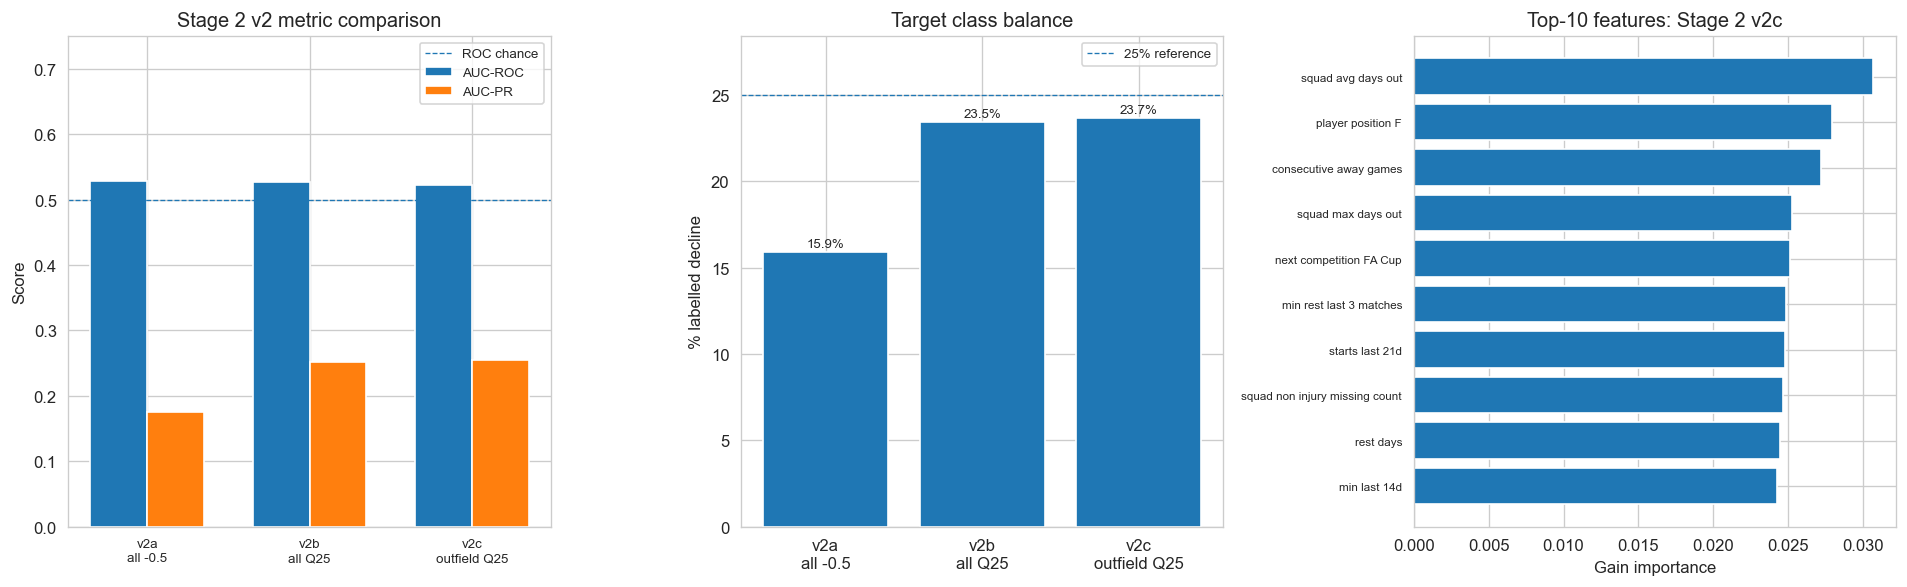

Figure saved → ../../models/XgBoost/artifacts/figures/stage2_v2_comparison.png


In [103]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v2 — Stage 2: Three fatigue classifier variants
#   v2a  fixed -0.5 threshold          all players
#   v2b  train-position Q25 threshold all players
#   v2c  train-position Q25 threshold outfield only  (GK excluded)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Position column fallback ─────────────────────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

S2V2_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_bv2.columns),
    None,
)

if S2V2_POSITION_COL is None:
    raise KeyError(f"No position column found. Tried: {POSITION_CANDIDATES}")

print(f"Using Stage 2 v2 position column: {S2V2_POSITION_COL}")


# ── Season column for temporal split ─────────────────────────────────────────
# Since the target is next_api_rating, split by the upcoming/target season.
S2V2_SPLIT_SEASON_COL = "next_season" if "next_season" in df_bv2.columns else "season"

print(f"Using temporal split column: {S2V2_SPLIT_SEASON_COL}")


# ── Competition column for categorical context ───────────────────────────────
# Since Stage 2 predicts upcoming-match residuals, prefer next_competition.
S2V2_COMPETITION_COL = "next_competition" if "next_competition" in df_bv2.columns else "competition"

print(f"Using Stage 2 competition/context column: {S2V2_COMPETITION_COL}")


# ── Define goalkeeper labels robustly ────────────────────────────────────────
GK_LABELS = {"G", "GK", "Goalkeeper", "goalkeeper"}


# ── Feature sets: fatigue / workload / injury only ───────────────────────────
S2V2_NUM = [
    c for c in [
        # Rolling match exposure
        "matches_last_7d",
        "matches_last_14d",
        "matches_last_21d",
        "matches_last_28d",

        # Rolling minutes
        "min_last_7d",
        "min_last_14d",
        "min_last_21d",
        "min_last_28d",

        # Starts burden
        "starts_last_7d",
        "starts_last_14d",
        "starts_last_21d",
        "starts_last_28d",

        # Full-match burden
        "full_90s_last_7d",
        "full_90s_last_14d",
        "full_90s_last_21d",
        "full_90s_last_28d",

        # Rest and short-rest sequences
        "rest_days",
        "short_rest_last_3_matches",
        "avg_rest_last_3_matches",
        "min_rest_last_3_matches",
        "matches_with_rest_le_3d_last_30d",
        "matches_with_rest_le_4d_last_30d",
        "matches_with_rest_le_6d_last_30d",

        # Competition-switch signals
        "played_europe_last_match",
        "played_domestic_cup_last_match",
        "competition_switch",
        "pl_after_ucl",
        "pl_after_cup",
        "ucl_after_pl",
        "days_since_european_match",
        "matches_since_european_match",

        # Position-normalised physical load
        "duels_total_position_z",
        "tackles_total_position_z",
        "fouls_committed_position_z",
        "minutes_played_position_z",
        "physical_load_index",

        # Schedule / congestion
        "consecutive_away_games",
        "high_congestion_flag",
        "acwr_ratio",
        "minutes_workload",

        # Current master-table injury context
        "squad_missing_total",
        "squad_players_missing_total",
        "squad_injured_count",
        "squad_non_injury_missing_count",
        "squad_soft_tissue_count",
        "squad_avg_days_out",
        "squad_max_days_out",

        # External team-match injury context, if present
        "team_match_injury_context_score",

        # Team-season injury burden, if present
        "team_season_total_absences",
        "team_season_injury_absences",
        "team_season_mean_injured_missing",
        "team_season_soft_tissue_absences",
        "team_season_mean_soft_tissue_missing",
        "team_season_unique_players_missing",
        "team_season_max_injured_in_match",
        "team_season_total_matches",

        # Player injury history, if present
        "player_season_matches_missed_total",
        "player_season_matches_missed_injury",
        "player_season_max_days_out",
        "player_season_injury_spells",
        "player_season_spell_matches_missed",
        "player_season_spell_max_days_out",
        "player_injury_history_score",
        "overall_injury_context_score",

        # Current master-table player injury history
        "fixtures_missed_last_30d",
        "fixtures_missed_last_90d",
        "returning_from_injury",
        "season_matches_missed_total",
        "season_matches_missed_injury",
        "season_max_reported_days_out",
        "has_player_season_injury_record",
    ]
    if c in df_bv2.columns
]

S2V2_CAT = [
    c for c in [
        S2V2_POSITION_COL,
        S2V2_COMPETITION_COL,
        "player_main_absence_reason",
        "player_main_injury_category",
        "player_season_main_spell_category",
        "season_main_reason",
        "season_main_injury_category",
    ]
    if c in df_bv2.columns
]

print(
    f"Stage 2 v2 feature set: {len(S2V2_NUM)} numeric + "
    f"{len(S2V2_CAT)} categorical = {len(S2V2_NUM) + len(S2V2_CAT)} total"
)

missing_key = [
    c for c in [
        "rest_days",
        "pl_after_ucl",
        "physical_load_index",
        "matches_last_7d",
        "min_last_14d",
        "competition_switch",
        "minutes_played_position_z",
        "performance_residual_v2",
    ]
    if c not in df_bv2.columns
]

if missing_key:
    print(f"WARNING — missing expected features: {missing_key}")


# ═══════════════════════════════════════════════════════════════════════════════
# Helper: train and evaluate one Stage 2 variant
# ═══════════════════════════════════════════════════════════════════════════════

def train_stage2_v2(df_in, target_col, label):
    """
    Train one Stage 2 binary classifier.

    Temporal split:
      2022 = train
      2023 = validation
      2024 = test

    Uses S2V2_SPLIT_SEASON_COL, preferably next_season.
    """
    Xin = df_in[S2V2_NUM + S2V2_CAT].copy()
    yin = df_in[target_col].astype(int).copy()

    trn = df_in[S2V2_SPLIT_SEASON_COL] == 2022
    val = df_in[S2V2_SPLIT_SEASON_COL] == 2023
    tst = df_in[S2V2_SPLIT_SEASON_COL] == 2024

    n_pos_train = int(yin.loc[trn].sum())
    n_neg_train = int((yin.loc[trn] == 0).sum())
    spw = round(n_neg_train / max(n_pos_train, 1), 2)

    pct_pos_all = float(yin.mean()) * 100
    pct_pos_test = float(yin.loc[tst].mean()) * 100

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    pre = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([("imp", SimpleImputer(strategy="median"))]),
                S2V2_NUM,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imp", SimpleImputer(strategy="most_frequent")),
                        ("ohe", ohe),
                    ]
                ),
                S2V2_CAT,
            ),
        ],
        remainder="drop",
    )

    Xtrn_t = pre.fit_transform(Xin.loc[trn])
    Xval_t = pre.transform(Xin.loc[val])
    Xtst_t = pre.transform(Xin.loc[tst])

    clf = XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=spw,
        objective="binary:logistic",
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    clf.fit(
        Xtrn_t,
        yin.loc[trn],
        eval_set=[(Xval_t, yin.loc[val])],
        verbose=200,
    )

    proba = clf.predict_proba(Xtst_t)[:, 1]

    auc_roc = roc_auc_score(yin.loc[tst], proba)
    auc_pr = average_precision_score(yin.loc[tst], proba)

    pr_base_test = float(yin.loc[tst].mean())

    pc, rc, tc = precision_recall_curve(yin.loc[tst], proba)
    f1c = 2 * pc[:-1] * rc[:-1] / (pc[:-1] + rc[:-1] + 1e-10)

    best_idx = int(np.argmax(f1c))
    bthr = float(tc[best_idx])

    ypred = (proba >= bthr).astype(int)

    f1_t = f1_score(yin.loc[tst], ypred, zero_division=0)
    prec_t = precision_score(yin.loc[tst], ypred, zero_division=0)
    rec_t = recall_score(yin.loc[tst], ypred, zero_division=0)

    cat_out = (
        pre.named_transformers_["cat"]["ohe"]
        .get_feature_names_out(S2V2_CAT)
        .tolist()
    )

    feat_names = S2V2_NUM + cat_out

    imp = pd.Series(
        clf.feature_importances_,
        index=feat_names,
    ).sort_values(ascending=False)

    print(f"\n{label}")
    print(f"  Rows total:          {len(df_in):,}")
    print(f"  Train rows:          {int(trn.sum()):,}")
    print(f"  Val rows:            {int(val.sum()):,}")
    print(f"  Test rows:           {int(tst.sum()):,}")
    print(f"  Decline rate all:    {pct_pos_all:.2f}%")
    print(f"  Decline rate test:   {pct_pos_test:.2f}%")
    print(f"  scale_pos_weight:    {spw}")
    print(f"  Best iteration:      {clf.best_iteration}")
    print(f"  AUC-ROC:             {auc_roc:.3f}")
    print(
        f"  AUC-PR:              {auc_pr:.3f} "
        f"(test baseline: {pr_base_test:.3f}, lift: {auc_pr / pr_base_test:.2f}x)"
    )
    print(
        f"  Best-F1 threshold:   {bthr:.2f}  →  "
        f"F1={f1_t:.3f}  Prec={prec_t:.3f}  Rec={rec_t:.3f}"
    )

    print("  Top-10 features:")
    for fn, iv in imp.head(10).items():
        print(f"    {fn:<48s} {iv:.4f}")

    return clf, pre, proba, yin.loc[tst], {
        "label": label,
        "n": len(df_in),
        "train_n": int(trn.sum()),
        "val_n": int(val.sum()),
        "test_n": int(tst.sum()),
        "pct_pos_all": pct_pos_all,
        "pct_pos_test": pct_pos_test,
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "base_test": pr_base_test,
        "best_iter": clf.best_iteration,
        "spw": spw,
        "f1": f1_t,
        "prec": prec_t,
        "rec": rec_t,
        "bthr": bthr,
        "imp": imp,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# v2a — fixed threshold residual_v2 <= -0.5, all players
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("v2a — fixed threshold: residual_v2 <= -0.5, all players")
print("=" * 80)

df_bv2["decline_v2a"] = (
    df_bv2["performance_residual_v2"] <= -0.5
).astype(int)

clf_v2a, pre_v2a, proba_v2a, ytst_v2a, res_v2a = train_stage2_v2(
    df_bv2,
    "decline_v2a",
    "Stage 2 v2a — fixed -0.5 threshold, all players",
)


# ═══════════════════════════════════════════════════════════════════════════════
# v2b — train-position Q25 threshold, all players
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("v2b — train-position Q25 threshold, all players")
print("=" * 80)

train_mask_bv2 = df_bv2[S2V2_SPLIT_SEASON_COL] == 2022

q25_by_pos_train = (
    df_bv2.loc[train_mask_bv2]
    .groupby(S2V2_POSITION_COL)["performance_residual_v2"]
    .quantile(0.25)
)

print("Train-only Q25 residual threshold by position:")
print(q25_by_pos_train.round(4).to_string())

df_bv2["_pos_q25_train"] = df_bv2[S2V2_POSITION_COL].map(q25_by_pos_train)

global_q25_train = df_bv2.loc[
    train_mask_bv2,
    "performance_residual_v2",
].quantile(0.25)

df_bv2["_pos_q25_train"] = df_bv2["_pos_q25_train"].fillna(global_q25_train)

df_bv2["decline_v2b"] = (
    df_bv2["performance_residual_v2"] <= df_bv2["_pos_q25_train"]
).astype(int)

df_bv2.drop(columns=["_pos_q25_train"], inplace=True)

clf_v2b, pre_v2b, proba_v2b, ytst_v2b, res_v2b = train_stage2_v2(
    df_bv2,
    "decline_v2b",
    "Stage 2 v2b — train-position Q25 threshold, all players",
)


# ═══════════════════════════════════════════════════════════════════════════════
# v2c — train-position Q25 threshold, outfield only
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("v2c — train-position Q25 threshold, outfield only")
print("=" * 80)

is_gk = df_bv2[S2V2_POSITION_COL].astype(str).isin(GK_LABELS)

df_bv2_out = df_bv2.loc[~is_gk].copy()

train_mask_out = df_bv2_out[S2V2_SPLIT_SEASON_COL] == 2022

q25_out_train = (
    df_bv2_out.loc[train_mask_out]
    .groupby(S2V2_POSITION_COL)["performance_residual_v2"]
    .quantile(0.25)
)

print(f"Outfield rows: {len(df_bv2_out):,}")
print(f"GK rows removed: {int(is_gk.sum()):,}")
print("Train-only Q25 residual threshold by outfield position:")
print(q25_out_train.round(4).to_string())

df_bv2_out["_pos_q25_train"] = df_bv2_out[S2V2_POSITION_COL].map(q25_out_train)

global_q25_out_train = df_bv2_out.loc[
    train_mask_out,
    "performance_residual_v2",
].quantile(0.25)

df_bv2_out["_pos_q25_train"] = df_bv2_out["_pos_q25_train"].fillna(global_q25_out_train)

df_bv2_out["decline_v2c"] = (
    df_bv2_out["performance_residual_v2"] <= df_bv2_out["_pos_q25_train"]
).astype(int)

df_bv2_out.drop(columns=["_pos_q25_train"], inplace=True)

clf_v2c, pre_v2c, proba_v2c, ytst_v2c, res_v2c = train_stage2_v2(
    df_bv2_out,
    "decline_v2c",
    "Stage 2 v2c — train-position Q25 threshold, outfield only",
)


# ═══════════════════════════════════════════════════════════════════════════════
# Summary table
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 90)
print("STAGE 2 v2 — FULL COMPARISON")
print("═" * 90)

print(
    f'{"Model":<12}  {"Target":<38}  {"Dataset":<10}  '
    f'{"AUC-ROC":>7}  {"AUC-PR":>7}  {"Base":>7}  {"Lift":>6}  {"F1":>6}'
)

print("-" * 90)

try:
    print(
        f'{"v1":<12}  {"residual_v1 <= -0.5":<38}  {"all":<10}  '
        f'{s2_auc_roc:>7.3f}  {s2_auc_pr:>7.3f}  '
        f'{float(y_s2_test.mean()):>7.3f}  '
        f'{s2_auc_pr / float(y_s2_test.mean()):>6.2f}  '
        f'{"":>6}'
    )
except NameError:
    print("v1 not available in scope")

summary_rows = [
    ("v2a", "residual_v2 <= -0.5", "all", res_v2a),
    ("v2b", "train-position Q25", "all", res_v2b),
    ("v2c", "train-position Q25", "outfield", res_v2c),
]

for model_name, target_name, dataset_name, r in summary_rows:
    print(
        f'{model_name:<12}  {target_name:<38}  {dataset_name:<10}  '
        f'{r["auc_roc"]:>7.3f}  {r["auc_pr"]:>7.3f}  '
        f'{r["base_test"]:>7.3f}  '
        f'{r["auc_pr"] / r["base_test"]:>6.2f}  '
        f'{r["f1"]:>6.3f}'
    )

print("═" * 90)


# ═══════════════════════════════════════════════════════════════════════════════
# Visualisation
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ["v2a\nall -0.5", "v2b\nall Q25", "v2c\noutfield Q25"]
rocs = [res_v2a["auc_roc"], res_v2b["auc_roc"], res_v2c["auc_roc"]]
prs = [res_v2a["auc_pr"], res_v2b["auc_pr"], res_v2c["auc_pr"]]

x = np.arange(len(models))
w = 0.35

axes[0].bar(x - w / 2, rocs, w, label="AUC-ROC")
axes[0].bar(x + w / 2, prs, w, label="AUC-PR")
axes[0].axhline(0.5, linestyle="--", linewidth=0.8, label="ROC chance")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=8)
axes[0].set_ylabel("Score")
axes[0].set_title("Stage 2 v2 metric comparison")
axes[0].set_ylim(0, 0.75)
axes[0].legend(fontsize=8)

pcts = [
    res_v2a["pct_pos_all"],
    res_v2b["pct_pos_all"],
    res_v2c["pct_pos_all"],
]

axes[1].bar(models, pcts)
axes[1].axhline(25, linestyle="--", linewidth=0.8, label="25% reference")
axes[1].set_ylabel("% labelled decline")
axes[1].set_title("Target class balance")
axes[1].set_ylim(0, max(pcts) * 1.2)
axes[1].legend(fontsize=8)

for i, v in enumerate(pcts):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

top10 = res_v2c["imp"].head(10)

axes[2].barh(range(len(top10)), top10.values[::-1])
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(
    [n.replace("_", " ")[:35] for n in top10.index[::-1]],
    fontsize=7,
)
axes[2].set_xlabel("Gain importance")
axes[2].set_title("Top-10 features: Stage 2 v2c")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stage2_v2_comparison.png",
    dpi=120,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved → {FIGURES_DIR / 'stage2_v2_comparison.png'}")



In [104]:
# ==============================================================================
# Save Model B v2 artifacts
# Stage 1 v2: expected next-rating regressor
# Stage 2 v2: three fatigue-residual classifier variants
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Save Stage 1 v2 model and preprocessing
# ------------------------------------------------------------------------------

stage1_v2_model_path = ARTIFACTS_DIR / "model_b_v2_stage1_xgb_regressor.pkl"
stage1_v2_preprocessor_path = ARTIFACTS_DIR / "model_b_v2_stage1_preprocessor.pkl"
stage1_v2_feature_names_path = ARTIFACTS_DIR / "model_b_v2_stage1_feature_names.pkl"
stage1_v2_num_cols_path = ARTIFACTS_DIR / "model_b_v2_stage1_num_cols.pkl"
stage1_v2_cat_cols_path = ARTIFACTS_DIR / "model_b_v2_stage1_cat_cols.pkl"

joblib.dump(stage1_v2, stage1_v2_model_path)
joblib.dump(pre_s1v2, stage1_v2_preprocessor_path)
joblib.dump(FEATURE_NAMES_S1V2, stage1_v2_feature_names_path)
joblib.dump(S1V2_NUM, stage1_v2_num_cols_path)
joblib.dump(S1V2_CAT, stage1_v2_cat_cols_path)

# ------------------------------------------------------------------------------
# 2. Save Stage 2 v2 variant models and preprocessors
# ------------------------------------------------------------------------------

stage2_v2_artifacts = {
    "v2a_fixed_threshold_all_players": {
        "model": clf_v2a,
        "preprocessor": pre_v2a,
        "results": res_v2a,
        "target": "decline_v2a",
        "target_definition": "performance_residual_v2 <= -0.5",
        "dataset": "all players",
    },
    "v2b_position_q25_all_players": {
        "model": clf_v2b,
        "preprocessor": pre_v2b,
        "results": res_v2b,
        "target": "decline_v2b",
        "target_definition": "performance_residual_v2 <= train-position Q25 threshold",
        "dataset": "all players",
    },
    "v2c_position_q25_outfield_only": {
        "model": clf_v2c,
        "preprocessor": pre_v2c,
        "results": res_v2c,
        "target": "decline_v2c",
        "target_definition": "performance_residual_v2 <= train-position Q25 threshold",
        "dataset": "outfield players only",
    },
}

saved_stage2_paths = {}

for variant_name, obj in stage2_v2_artifacts.items():
    model_path = ARTIFACTS_DIR / f"model_b_v2_stage2_{variant_name}_xgb_classifier.pkl"
    preprocessor_path = ARTIFACTS_DIR / f"model_b_v2_stage2_{variant_name}_preprocessor.pkl"

    joblib.dump(obj["model"], model_path)
    joblib.dump(obj["preprocessor"], preprocessor_path)

    saved_stage2_paths[variant_name] = {
        "model_path": str(model_path),
        "preprocessor_path": str(preprocessor_path),
    }

# Save shared Stage 2 v2 feature lists
stage2_v2_num_cols_path = ARTIFACTS_DIR / "model_b_v2_stage2_num_cols.pkl"
stage2_v2_cat_cols_path = ARTIFACTS_DIR / "model_b_v2_stage2_cat_cols.pkl"

joblib.dump(S2V2_NUM, stage2_v2_num_cols_path)
joblib.dump(S2V2_CAT, stage2_v2_cat_cols_path)

# ------------------------------------------------------------------------------
# 3. Save metadata
# ------------------------------------------------------------------------------

metadata_b_v2 = {
    "model_name": "XGBoost Model B v2",
    "purpose": "Two-stage fatigue-residual modelling using stronger Stage 1 baselines and three Stage 2 target variants.",
    "framing": "post-match / pre-next-match fatigue-associated underperformance analysis",
    "stage1_v2": {
        "model": "XGBRegressor",
        "target": "next_api_rating",
        "feature_design": "upcoming-match context + player, team, and opponent rolling baselines",
        "split_column": "next_season",
        "best_iteration": int(stage1_v2.best_iteration),
        "test_rmse": float(rmse_s1v2),
        "test_mae": float(mae_s1v2),
        "mean_baseline_rmse": float(baseline_s1v2),
        "v1_rmse_reference": float(S1_V1_RMSE),
        "v1_mae_reference": float(S1_V1_MAE),
        "rmse_improvement_vs_v1_percent": float(rmse_improvement_vs_v1),
        "mae_improvement_vs_v1_percent": float(mae_improvement_vs_v1),
        "n_raw_numeric_features": int(len(S1V2_NUM)),
        "n_raw_categorical_features": int(len(S1V2_CAT)),
        "n_transformed_features": int(len(FEATURE_NAMES_S1V2)),
    },
    "stage2_v2": {
        "split_column": str(S2V2_SPLIT_SEASON_COL),
        "competition_column": str(S2V2_COMPETITION_COL),
        "position_column": str(S2V2_POSITION_COL),
        "numeric_features": S2V2_NUM,
        "categorical_features": S2V2_CAT,
        "n_raw_numeric_features": int(len(S2V2_NUM)),
        "n_raw_categorical_features": int(len(S2V2_CAT)),
        "variants": {},
    },
    "artifact_paths": {
        "stage1_model": str(stage1_v2_model_path),
        "stage1_preprocessor": str(stage1_v2_preprocessor_path),
        "stage1_feature_names": str(stage1_v2_feature_names_path),
        "stage1_num_cols": str(stage1_v2_num_cols_path),
        "stage1_cat_cols": str(stage1_v2_cat_cols_path),
        "stage2_num_cols": str(stage2_v2_num_cols_path),
        "stage2_cat_cols": str(stage2_v2_cat_cols_path),
        "stage2_variants": saved_stage2_paths,
    },
    "notes": [
        "Stage 1 v2 predicts next_api_rating using upcoming-match aligned context and rolling baselines.",
        "Stage 2 v2 tests whether fatigue/workload/injury features predict below-expected residual performance.",
        "v2a uses a fixed residual threshold of -0.5.",
        "v2b uses train-position Q25 thresholds for all players.",
        "v2c uses train-position Q25 thresholds for outfield players only.",
        "Model B v2 is methodologically useful but final recommended workload-risk model remains Model B v4b_no_competition.",
    ],
}

# Add variant metrics safely
for variant_name, obj in stage2_v2_artifacts.items():
    r = obj["results"]

    metadata_b_v2["stage2_v2"]["variants"][variant_name] = {
        "target": obj["target"],
        "target_definition": obj["target_definition"],
        "dataset": obj["dataset"],
        "n_total": int(r["n"]),
        "n_train": int(r["train_n"]),
        "n_val": int(r["val_n"]),
        "n_test": int(r["test_n"]),
        "positive_rate_all_percent": float(r["pct_pos_all"]),
        "positive_rate_test_percent": float(r["pct_pos_test"]),
        "scale_pos_weight": float(r["spw"]),
        "best_iteration": int(r["best_iter"]),
        "test_auc_roc": float(r["auc_roc"]),
        "test_auc_pr": float(r["auc_pr"]),
        "test_base_pr": float(r["base_test"]),
        "test_pr_lift": float(r["auc_pr"] / max(r["base_test"], 1e-6)),
        "diagnostic_best_threshold": float(r["bthr"]),
        "test_f1": float(r["f1"]),
        "test_precision": float(r["prec"]),
        "test_recall": float(r["rec"]),
        "threshold_note": "Best threshold was selected on the test set in this notebook; use as diagnostic only.",
    }

metadata_b_v2_path = ARTIFACTS_DIR / "model_b_v2_metadata.json"

with open(metadata_b_v2_path, "w") as f:
    json.dump(metadata_b_v2, f, indent=4)

# ------------------------------------------------------------------------------
# 4. Print summary
# ------------------------------------------------------------------------------

print("✓ Model B v2 artifacts saved")
print()
print("Stage 1 v2:")
print(f"  Model:          {stage1_v2_model_path}")
print(f"  Preprocessor:   {stage1_v2_preprocessor_path}")
print(f"  Feature names:  {stage1_v2_feature_names_path}")
print(f"  Numeric cols:   {stage1_v2_num_cols_path}")
print(f"  Categorical:    {stage1_v2_cat_cols_path}")
print()
print("Stage 2 v2 variants:")
for variant_name, paths in saved_stage2_paths.items():
    print(f"  {variant_name}:")
    print(f"    Model:        {paths['model_path']}")
    print(f"    Preprocessor: {paths['preprocessor_path']}")
print()
print(f"Shared Stage 2 numeric cols:   {stage2_v2_num_cols_path}")
print(f"Shared Stage 2 categorical:    {stage2_v2_cat_cols_path}")
print(f"Metadata:                      {metadata_b_v2_path}")


✓ Model B v2 artifacts saved

Stage 1 v2:
  Model:          ../../models/XgBoost/artifacts/model_b_v2_stage1_xgb_regressor.pkl
  Preprocessor:   ../../models/XgBoost/artifacts/model_b_v2_stage1_preprocessor.pkl
  Feature names:  ../../models/XgBoost/artifacts/model_b_v2_stage1_feature_names.pkl
  Numeric cols:   ../../models/XgBoost/artifacts/model_b_v2_stage1_num_cols.pkl
  Categorical:    ../../models/XgBoost/artifacts/model_b_v2_stage1_cat_cols.pkl

Stage 2 v2 variants:
  v2a_fixed_threshold_all_players:
    Model:        ../../models/XgBoost/artifacts/model_b_v2_stage2_v2a_fixed_threshold_all_players_xgb_classifier.pkl
    Preprocessor: ../../models/XgBoost/artifacts/model_b_v2_stage2_v2a_fixed_threshold_all_players_preprocessor.pkl
  v2b_position_q25_all_players:
    Model:        ../../models/XgBoost/artifacts/model_b_v2_stage2_v2b_position_q25_all_players_xgb_classifier.pkl
    Preprocessor: ../../models/XgBoost/artifacts/model_b_v2_stage2_v2b_position_q25_all_players_preprocess

## Model B v2 — Stage 2 Classifier Variants

After improving Stage 1 with rolling player, team, and opponent baselines, three Stage 2 fatigue-classifier variants were tested.

The goal was to check whether the cleaner Stage 1 v2 residual target could be predicted from fatigue, workload, recovery, schedule, physical-burden, competition-sequence, and injury-context variables.

---

## Stage 2 v2 Feature Set

Stage 2 v2 used the following feature structure:

| Feature type         | Count |
| -------------------- | ----: |
| Numeric features     |    53 |
| Categorical features |     4 |
| Total raw features   |    57 |

The position column used was:

```text
player_position
```

The temporal split used:

```text
next_season
```

This is important because the target is the rating in the upcoming match. Therefore, the model should split by the season of the target match, not the current-row season.

The competition/context column used was:

```text
next_competition
```

This aligns Stage 2 with the Model B v2 design: features should describe the player’s state before the upcoming match.

The feature set included workload, schedule, injury, physical-burden, and competition-sequence variables. Direct current-match performance events such as goals, assists, shots, key passes, and rating were excluded.

---

## Tested Stage 2 Variants

| Variant | Target definition                     | Dataset               | Purpose                                                  |
| ------- | ------------------------------------- | --------------------- | -------------------------------------------------------- |
| v2a     | `performance_residual_v2 <= -0.5`     | All players           | Direct comparison with v1 using the same fixed threshold |
| v2b     | Train-position Q25 residual threshold | All players           | Position-adjusted residual threshold                     |
| v2c     | Train-position Q25 residual threshold | Outfield players only | Removes goalkeepers from the position-adjusted target    |

The Q25 thresholds were computed using only the training season to avoid leaking validation or test-set residual distributions into the target definition.

---

## Position-Specific Q25 Thresholds

For the all-player position-adjusted target, the train-only Q25 residual thresholds were:

| Player position | Q25 residual threshold |
| --------------- | ---------------------: |
| D               |                -0.3305 |
| F               |                -0.3795 |
| G               |                -0.5119 |
| M               |                -0.3184 |

For the outfield-only model, goalkeepers were removed. The remaining thresholds were:

| Player position | Q25 residual threshold |
| --------------- | ---------------------: |
| D               |                -0.3305 |
| F               |                -0.3795 |
| M               |                -0.3184 |

The goalkeeper threshold was substantially more negative than the outfield thresholds. This supports the earlier finding that goalkeeper rating residuals behave differently from outfield-player residuals.

---

## Stage 2 v2a — Fixed Threshold, All Players

Stage 2 v2a used the fixed residual threshold:

```text
performance_residual_v2 <= -0.5
```

| Metric               |  Value |
| -------------------- | -----: |
| Rows                 | 27,283 |
| Train rows           |  8,842 |
| Validation rows      |  9,153 |
| Test rows            |  9,283 |
| Decline rate overall | 15.91% |
| Decline rate test    | 16.08% |
| `scale_pos_weight`   |   4.84 |
| Best iteration       |      9 |
| AUC-ROC              |  0.528 |
| AUC-PR               |  0.175 |
| Test PR-AUC baseline |  0.161 |
| PR-AUC lift          |  1.09× |
| Best-F1 threshold    |   0.47 |
| F1-score             |  0.279 |
| Precision            |  0.163 |
| Recall               |  0.981 |

Stage 2 v2a was the cleanest comparison with Stage 2 v1 because both used the same fixed `-0.5` residual threshold. The improvement from v1 suggests that the stronger Stage 1 v2 baseline produced a slightly cleaner residual.

However, the classifier remained weak. The AUC-ROC was only 0.528 and the PR-AUC lift was only 1.09× above the test-set baseline.

The best-F1 threshold produced very high recall but very low precision, meaning that the model identified most positive cases by flagging a very large number of players.

### Top Features

| Rank | Feature                           | Importance |
| ---: | --------------------------------- | ---------: |
|    1 | `player_position_G`               |     0.0505 |
|    2 | `next_competition_Premier League` |     0.0282 |
|    3 | `minutes_played_position_z`       |     0.0274 |
|    4 | `squad_avg_days_out`              |     0.0259 |
|    5 | `player_position_F`               |     0.0240 |
|    6 | `player_position_M`               |     0.0231 |
|    7 | `min_last_21d`                    |     0.0228 |
|    8 | `matches_last_7d`                 |     0.0217 |
|    9 | `matches_last_28d`                |     0.0203 |
|   10 | `acwr_ratio`                      |     0.0201 |

The strongest feature was still the goalkeeper indicator, suggesting that all-player Stage 2 models remain affected by goalkeeper-specific rating behaviour.

---

## Stage 2 v2b — Position Q25 Threshold, All Players

Stage 2 v2b used a position-adjusted target based on the train-season 25th percentile of residuals.

| Metric               |  Value |
| -------------------- | -----: |
| Rows                 | 27,283 |
| Train rows           |  8,842 |
| Validation rows      |  9,153 |
| Test rows            |  9,283 |
| Decline rate overall | 23.45% |
| Decline rate test    | 23.58% |
| `scale_pos_weight`   |   3.00 |
| Best iteration       |     13 |
| AUC-ROC              |  0.527 |
| AUC-PR               |  0.251 |
| Test PR-AUC baseline |  0.236 |
| PR-AUC lift          |  1.06× |
| Best-F1 threshold    |   0.45 |
| F1-score             |  0.382 |
| Precision            |  0.236 |
| Recall               |  0.999 |

The position-adjusted target improved class balance, increasing the positive rate from approximately 16% to approximately 23–24%.

However, the classifier still performed close to random. The PR-AUC was only slightly above the test baseline.

### Top Features

| Rank | Feature                           | Importance |
| ---: | --------------------------------- | ---------: |
|    1 | `starts_last_14d`                 |     0.0303 |
|    2 | `squad_avg_days_out`              |     0.0276 |
|    3 | `next_competition_FA Cup`         |     0.0263 |
|    4 | `next_competition_Premier League` |     0.0256 |
|    5 | `played_domestic_cup_last_match`  |     0.0239 |
|    6 | `squad_max_days_out`              |     0.0233 |
|    7 | `matches_last_21d`                |     0.0228 |
|    8 | `squad_non_injury_missing_count`  |     0.0223 |
|    9 | `min_last_14d`                    |     0.0222 |
|   10 | `squad_injured_count`             |     0.0221 |

The top features were more aligned with workload, injury, and competition-sequence pressure than Model A’s direct performance features. However, the predictive signal remained weak.

---

## Stage 2 v2c — Position Q25 Threshold, Outfield Only

Stage 2 v2c removed goalkeepers and used the train-position Q25 target for outfield players only.

| Metric                  |  Value |
| ----------------------- | -----: |
| Outfield rows           | 24,656 |
| Goalkeeper rows removed |  2,627 |
| Train rows              |  7,968 |
| Validation rows         |  8,298 |
| Test rows               |  8,386 |
| Decline rate overall    | 23.68% |
| Decline rate test       | 23.93% |
| `scale_pos_weight`      |   3.00 |
| Best iteration          |      4 |
| AUC-ROC                 |  0.522 |
| AUC-PR                  |  0.254 |
| Test PR-AUC baseline    |  0.239 |
| PR-AUC lift             |  1.06× |
| Best-F1 threshold       |   0.47 |
| F1-score                |  0.387 |
| Precision               |  0.240 |
| Recall                  |  0.997 |

Removing goalkeepers was methodologically correct, but it did not materially improve classifier performance. This suggests that goalkeeper contamination was not the only reason Stage 2 was weak.

The outfield-only model still performed close to random, with AUC-ROC = 0.522 and PR-AUC lift = 1.06×.

### Top Features

| Rank | Feature                          | Importance |
| ---: | -------------------------------- | ---------: |
|    1 | `squad_avg_days_out`             |     0.0307 |
|    2 | `player_position_F`              |     0.0279 |
|    3 | `consecutive_away_games`         |     0.0272 |
|    4 | `squad_max_days_out`             |     0.0252 |
|    5 | `next_competition_FA Cup`        |     0.0251 |
|    6 | `min_rest_last_3_matches`        |     0.0248 |
|    7 | `starts_last_21d`                |     0.0248 |
|    8 | `squad_non_injury_missing_count` |     0.0247 |
|    9 | `rest_days`                      |     0.0245 |
|   10 | `min_last_14d`                   |     0.0243 |

The top features are interpretable and mostly aligned with the intended fatigue-pressure mechanisms: squad injury severity, away-game accumulation, rest, recent starts, and medium-term minutes. However, they did not translate into strong predictive performance.

---

## Full Comparison

| Model       | Target                | Dataset  | AUC-ROC | AUC-PR | PR baseline |  Lift |    F1 |
| ----------- | --------------------- | -------- | ------: | -----: | ----------: | ----: | ----: |
| Stage 2 v1  | `residual_v1 <= -0.5` | All      |   0.506 |  0.163 |       0.158 | 1.03× |     — |
| Stage 2 v2a | `residual_v2 <= -0.5` | All      |   0.528 |  0.175 |       0.161 | 1.09× | 0.279 |
| Stage 2 v2b | Train-position Q25    | All      |   0.527 |  0.251 |       0.236 | 1.06× | 0.382 |
| Stage 2 v2c | Train-position Q25    | Outfield |   0.522 |  0.254 |       0.239 | 1.06× | 0.387 |

---

## Interpretation

The v2 redesign improved the methodology but did not produce a strong fatigue classifier.

Stage 1 v2 improved the expected-rating baseline, reducing RMSE from:

```text
0.6006 to 0.5825
```

It also reduced the residual standard deviation from:

```text
0.5875 to 0.5725
```

This confirms that Stage 1 v2 produced a slightly cleaner residual.

However, even with cleaner residuals and alternative Stage 2 target definitions, the Stage 2 classifiers remained close to random.

The strongest fixed-threshold comparison was v2a:

```text
AUC-ROC = 0.528
AUC-PR  = 0.175
PR-AUC lift = 1.09×
```

This is an improvement over Stage 2 v1, but it is still too weak for operational deployment.

---

## Key Findings

1. **Stage 1 v2 improved the expected-rating baseline, but only modestly.**
   Adding player, team, and opponent baselines reduced residual noise slightly, but not enough to make the residual target strongly predictable.

2. **Position-adjusted Q25 targets improved class balance but not predictive power.**
   The Q25 target produced a healthier positive rate around 24%, but the classifier still performed close to random.

3. **Removing goalkeepers did not solve Stage 2.**
   The outfield-only v2c model remained weak, showing that goalkeeper contamination was not the only reason for poor fatigue-residual classification.

4. **The top features are interpretable but weak.**
   Injury burden, short-rest sequences, full-90 exposure, away-game accumulation, and competition-sequence variables appeared in feature importance rankings, but they did not create strong discrimination.

5. **Fatigue pressure is easier to describe than to predict as a binary outcome.**
   The available workload and injury variables are useful as dashboard indicators, but not as a reliable classifier for match-level residual decline.

---

## Final Conclusion

Model B v2 confirms that fatigue, workload, schedule, and injury pressure are difficult to convert into a reliable binary classifier for individual-match residual underperformance using public event data alone.

The most defensible dashboard strategy is therefore:

| Dashboard layer        | Role                                                |
| ---------------------- | --------------------------------------------------- |
| Model A                | Main operational decline-risk score                 |
| Model B v2 Stage 1     | Expected next-match rating                          |
| Model B v2 residuals   | Exploratory below-expectation analysis              |
| Fatigue Pressure Index | Transparent workload/schedule/injury pressure layer |
| Stage 2 v2 classifier  | Diagnostic experiment, not final risk engine        |

The key conclusion is:

```text
Model A remains the main prediction model.
Model B v2 should be used as an interpretability and fatigue-pressure layer.
```


# Model B v3 — XGBoost Fatigue-Associated Performance Risk Model

## 1. Objective

Model B v3 is designed to help Premier League coaching and performance staff identify **outfield players who are at higher risk of reduced performance due to accumulated workload, fixture congestion, physical effort, and multi-competition burden**.

The model is built for clubs playing across multiple competitions (e.g., Premier League + Champions League + domestic cups) in congested fixture periods, and helps answer:

```
Given this player's recent workload, competition sequence, physical effort, role, 
and team injury context, is this player at increased risk of reduced performance 
in their next match?
```

The model is **not** intended to medically diagnose fatigue. True fatigue cannot be observed from public event data alone (we lack GPS, accelerations, training load, wellness scores, sleep, or medical markers). Instead, the model estimates **fatigue-associated performance risk** — the likelihood that a player will underperform or have their involvement managed due to workload context.

---

## 2. Why Model B v3?

### Model A (General Decline Classifier)
- Achieved **AUC-ROC ≈ 0.800, AUC-PR ≈ 0.600**
- Predicts whether next-match rating will drop >0.5
- Strong signal, but driven largely by **regression to the mean**
- Does not isolate fatigue-specific drivers

### Models B v1/v2 (Binary Residual Classifiers)
- Attempted to predict negative residuals (underperformance given expected level)
- **Weak results: AUC-ROC ≈ 0.505, AUC-PR ≈ 0.164**
- Binary thresholds too noisy; public event data alone cannot cleanly separate fatigue effects from tactical context, opponent, or rating noise
- Revealed **selection bias**: scorable players (both appearances ≥45 min, rated) are already managed/trusted; truly fatigued players are substituted, rested, or not selected

### Model B v3 (Fatigue Risk Classifier) — Reframed Outcome
- Instead of predicting raw decline or residuals, predict a **combined fatigue-risk outcome** that captures two practical consequences of fatigue:
  1. **Performance underperformance**: player receives a lower rating than expected
  2. **Load management**: player has reduced involvement (fewer minutes, later substitution, or not selected)
- This better reflects real fatigue in football: fatigued players may not always score lower; they are often rested, eased into reduced roles, or substituted earlier
- Combines both signals into a **single binary target**: `fatigue_performance_risk`
- Shifts focus from "is the player medically fatigued?" to "is the player in a workload context associated with reduced performance or managed load?"

---

## 3. Population: Outfield Players Only

```python
df_model = df[df["player_position"] != "G"].copy()
```

Model B v3 is trained **only on outfield players** (defenders, midfielders, forwards). Goalkeepers are excluded because:

- Different physical load profiles (duel density, sprint distance, positioning load differ from outfield players)
- Ratings heavily influenced by saves, errors, and clean sheets — not comparable to outfield performance drivers
- Rotation and fatigue patterns are structurally different
- Duels, tackles, dribbles, and physical-load proxies are less meaningful predictors

A separate goalkeeper model can be developed later if needed.

---

## 4. Row Structure: Pre-Match Features

Each row represents **a player before an upcoming fixture**, using **only information known before kickoff**.

Concept: `player state before match t → outcome in match t`

This is more appropriate for a pre-match decision-support tool than `match t performance → next match t+1 performance`.

**Valid pre-match features** (no match t data):
- `days_since_last_match`, `minutes_last_7d`, `minutes_last_14d`, `minutes_last_21d`
- `starts_last_7d`, `starts_last_14d`, `full_90s_last_7d`, `full_90s_last_14d`
- `pl_after_ucl`, `ucl_after_pl`, `days_since_european_match`
- `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d` (match count, not IDs)
- `consecutive_away_games`, `high_congestion_flag`
- `squad_injured_count`, `squad_soft_tissue_count`, `squad_avg_days_out`
- `physical_load_index` (historical, e.g., per-minute actions in recent matches)
- Player rating history: `rating_mean_last_5_matches`, `rating_std_last_5_matches`
- Team rotation rate, player appearance/start frequency

---

## 5. Target Definition: Fatigue-Associated Performance Risk

The binary target is:

```
fatigue_performance_risk = 1  if ( performance_underperformance = 1 )  OR  ( managed_load_next_match = 1 )
fatigue_performance_risk = 0  otherwise
```

### 5.1 Component: `performance_underperformance`

```
performance_underperformance = 1  if  next_api_rating < (expected_rating - 0.5)
```

Where:
- `next_api_rating` = actual rating in match t (target must be known post-match for training)
- `expected_rating` = Stage 1 model's predicted rating (baseline expectation)
- `threshold = -0.5` = at least 0.5 points below expectation

This flags players who **underperform their predicted level** — a direct signal of diminished performance.

### 5.2 Component: `managed_load_next_match`

```
managed_load_next_match = 1  if  (minutes_played_next_match = 0)  OR  (minutes_played_next_match < 45)
```

This flags players who:
- **Did not play** (0 minutes) in match t
- **Played fewer than 45 minutes** in match t (likely substituted early or brought on late)

This captures load management: coaches rest or reduce involvement of at-risk players.

### 5.3 Player Categories (for stratified analysis)

For validation and fairness checks, classify each pre-match row by player role:

```python
core_starter = (starts_last_10 >= 7)
rotation_player = (3 <= starts_last_10 < 7)
impact_sub = (starts_last_10 <= 2) & (appearances_last_10 >= 5) & (start_rate_last_10 < 0.30)
rare_player = (appearances_last_10 <= 4)
```

Expected risk profile:
- **Core starters**: typically lower fatigue risk (managed more carefully)
- **Rotation players**: medium fatigue risk (exposed to congestion but also rotated)
- **Impact subs**: variable risk (often fresher but brought on in late/difficult situations)
- **Rare players**: exclude from primary model (unstable, insufficient history)

---

## 6. Feature Engineering & Selection

### 6.1 Workload & Congestion Features
- **Recent match frequency**: `matches_last_7d`, `matches_last_14d`, `matches_last_21d`, `matches_last_28d`
- **Accumulated minutes**: `min_last_7d`, `min_last_14d`, `min_last_21d`, `min_last_28d`
- **Start density**: `starts_last_7d`, `starts_last_14d`, `full_90s_last_7d`, `full_90s_last_14d`
- **Rest pattern**: `rest_days`, `min_rest_last_3_matches`, `avg_rest_last_3_matches`, `short_rest_count`
- **Congestion flag**: `high_congestion_flag` (3+ matches in 7 days)

### 6.2 Multi-Competition Transitions
- **European burden**: `pl_after_ucl`, `ucl_after_pl`, `pl_after_cup`
- **Days since European**: `days_since_european_match`, `matches_since_european_match`
- **Competition switch**: `competition_switch` (1 if previous match ≠ current competition)

### 6.3 Physical Effort (Rolling Event Sums)
- **Duels**, **tackles**, **fouls**, **dribbles**: rolling sums over last 3 matches and last 14 days
- **Cards**: rolling sum over last 5 matches
- **Position z-scores**: how these actions compare to same-position peers
- **Physical load index**: estimated per-match intensity (duels + tackles + actions per minute)

### 6.4 Squad Context
- `squad_injured_count`: total squad injuries (forces rotation)
- `squad_soft_tissue_count`: soft-tissue injuries (indicate intensity or fatigue)
- `squad_avg_days_out`: average recovery time for injured players
- `returning_from_injury`: binary flag (this player recently returned from injury)
- `fixtures_missed_last_30d`: # of team matches missed due to injury

### 6.5 Player Performance History
- `rating_mean_last_5_matches`: baseline performance level
- `rating_std_last_5_matches`: consistency (high std = unpredictable)
- `goal_contribution_last_5`: recent goal/assist rate
- `position_pct_{metric}`: how player's metrics rank within their position

---

## 7. Model Architecture

### Stage 1: Baseline Expected Rating
- **Type**: XGBRegressor
- **Target**: `next_api_rating`
- **Output**: `expected_rating` (baseline expectation, used in residual calculation)
- **Features**: Form, role, opposition, team context (does NOT include workload/congestion)
- **Use case**: Compute underperformance residuals

### Stage 2 v3: Fatigue-Associated Risk Classifier
- **Type**: XGBClassifier (binary)
- **Target**: `fatigue_performance_risk` (performance underperformance OR managed load)
- **Features**: Stage 1 + all workload, congestion, physical effort, and squad context features
- **Output**: Probability score & risk category (Low / Medium / High / Very High)
- **Threshold optimization**: Tuned for Sensitivity/Specificity balance (or by cost of false negatives)

---

## 8. Training Configuration

### Temporal Split (No Random Shuffle)
- **Train**: 2022 season
- **Validation**: 2023 season
- **Test**: 2024-2025 season (held out)

### XGBoost Hyperparameters (Stage 2 v3)
```python
XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=<computed>,  # positive class weight
    early_stopping_rounds=30,
    eval_metric='auc',
    random_state=42,
)
```

### Preprocessing
- **Numeric**: Median imputation, no scaling
- **Categorical**: Most-frequent imputation, One-Hot Encoding (`handle_unknown='ignore'`)

---

## 9. Evaluation & Validation

### Metrics (Test Set)
- **AUC-ROC**: overall discrimination
- **AUC-PR**: PR curve (important if base rate is low)
- **Confusion matrix**: TP, TN, FP, FN at optimal threshold
- **Sensitivity/Specificity**: recall vs. false-positive rate

### Stratified Validation by Player Category
For each player category (core, rotation, impact sub):
- % of players flagged as high-risk
- False-negative rate (missed at-risk players)
- False-positive rate (flagged non-fatigued players)
- Risk score distribution

### Fairness Check
- Ensure model is not biased by position (DEF vs. MID vs. FWD)
- Check for age/experience bias
- Validate across team clubs (ensure not overfit to few teams)

---

## 10. Output & Deployment

### Pre-Match Dashboard
For each player before their next match:
- **Fatigue Risk Score** (0–100)
- **Risk Category** (Low / Medium / High / Very High)
- **Top 3 contributing factors** (e.g., "High congestion + recent European match + 3 matches in 7 days")
- **Recommended action** (e.g., "Consider rotation" or "Monitor for substitution")

### Export
- Model artifact: pickled XGBClassifier
- Feature transformer: saved ColumnTransformer
- Feature importance: SHAP summary plot + top-20 features
- Validation report: metrics, stratified tables, fairness checks



In [105]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step A: Physical Burden Features + Target Construction


# ═══════════════════════════════════════════════════════════════════════════════
# 0. Basic setup
# ═══════════════════════════════════════════════════════════════════════════════

# ── Choose safest available position column ──────────────────────────────────
POSITION_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

V3_POSITION_COL = next(
    (c for c in POSITION_CANDIDATES if c in df_fe.columns),
    None,
)

if V3_POSITION_COL is None:
    raise KeyError(f"No position column found. Tried: {POSITION_CANDIDATES}")

print(f"Using Model B v3 position column: {V3_POSITION_COL}")

GK_LABELS = {"G", "GK", "Goalkeeper", "goalkeeper"}

# Ensure rating_clean exists
if "rating_clean" not in df_fe.columns:
    df_fe["rating_clean"] = df_fe["rating"].replace(0, np.nan)

# Ensure date is datetime
df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Rolling physical burden features
# ═══════════════════════════════════════════════════════════════════════════════

V3_BURDEN_EXPECTED = [
    "duels_last_3_matches",
    "duels_last_14d",
    "tackles_last_3_matches",
    "tackles_last_14d",
    "fouls_last_3_matches",
    "fouls_last_14d",
    "dribbles_last_3_matches",
    "dribbles_last_14d",
    "cards_last_5_matches",
]

missing_burden = [c for c in V3_BURDEN_EXPECTED if c not in df_fe.columns]

if missing_burden:
    print("Computing rolling physical burden features on df_fe...")

    SRCS = [
        ("duels_total", "duels"),
        ("tackles_total", "tackles"),
        ("fouls_committed", "fouls"),
        ("dribbles_attempts", "dribbles"),
    ]

    df_s = df_fe.sort_values(["player_key", "date"]).copy()
    df_s["_seq"] = np.arange(len(df_s))

    n_rows = len(df_s)
    window_14d = np.timedelta64(14, "D")

    out = {}

    for _, short_name in SRCS:
        out[f"{short_name}_last_3_matches"] = np.zeros(n_rows, dtype=np.float32)
        out[f"{short_name}_last_14d"] = np.zeros(n_rows, dtype=np.float32)

    out["cards_last_5_matches"] = np.zeros(n_rows, dtype=np.float32)

    yellow = (
        df_s["cards_yellow"].fillna(0)
        if "cards_yellow" in df_s.columns
        else pd.Series(0.0, index=df_s.index)
    )

    red = (
        df_s["cards_red"].fillna(0)
        if "cards_red" in df_s.columns
        else pd.Series(0.0, index=df_s.index)
    )

    cards_arr = (yellow + red).values.astype(np.float32)

    for player_key, grp in df_s.groupby("player_key", sort=False):
        g = grp.sort_values("date")

        pos = g["_seq"].values
        dates = g["date"].values.astype("datetime64[ns]")
        n = len(pos)

        card_values = cards_arr[pos]

        for raw_col, short_name in SRCS:
            if raw_col not in g.columns:
                continue

            values = g[raw_col].fillna(0).values.astype(np.float32)

            rolling_3 = out[f"{short_name}_last_3_matches"]
            rolling_14 = out[f"{short_name}_last_14d"]

            for i in range(1, n):
                p = pos[i]

                # Previous 3 appearances only
                rolling_3[p] = values[max(0, i - 3):i].sum()

                # Previous 14 calendar days only
                cutoff = dates[i] - window_14d
                rolling_14[p] = values[:i][dates[:i] >= cutoff].sum()

        rolling_cards = out["cards_last_5_matches"]

        for i in range(1, n):
            rolling_cards[pos[i]] = card_values[max(0, i - 5):i].sum()

    original_index = df_s.index.values

    for col, arr in out.items():
        df_fe.loc[original_index, col] = arr

    V3_BURDEN_COLS = list(out.keys())

    if "_seq" in df_s.columns:
        df_s.drop(columns=["_seq"], inplace=True)

    print(f"  Added {len(V3_BURDEN_COLS)} burden columns to df_fe")

else:
    V3_BURDEN_COLS = V3_BURDEN_EXPECTED.copy()
    print(f"Burden columns already present in df_fe ({len(V3_BURDEN_COLS)})")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Outfield base population
# ═══════════════════════════════════════════════════════════════════════════════

is_gk = df_fe[V3_POSITION_COL].astype(str).isin(GK_LABELS)

df_v3b = df_fe[
    (~is_gk)
    & (df_fe["minutes_played"] >= 45)
    & df_fe["rating_clean"].notna()
    & df_fe["next_minutes_played"].notna()
].copy()

print(f"\nModel B v3 — Outfield base population: {len(df_v3b):,} rows")
print(f"  Seasons: {sorted(df_v3b['season'].dropna().unique())}")
print(f"  GK rows excluded from source table: {int(is_gk.sum()):,}")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Add target_season for later temporal split
# ═══════════════════════════════════════════════════════════════════════════════

# Since the target is about the next match, future training should split by
# the upcoming/target season rather than the current-row season.
if "next_season" in df_v3b.columns:
    df_v3b["target_season"] = df_v3b["next_season"]
else:
    df_v3b["target_season"] = df_v3b["season"]

print("\nTarget-season split column created:")
print("  target_season = next_season if available, else season")
print(df_v3b["target_season"].value_counts(dropna=False).sort_index().to_string())


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Merge Stage 1 v2 residuals using stable keys
# ═══════════════════════════════════════════════════════════════════════════════

if "performance_residual_v2" not in df_bv2.columns:
    raise KeyError(
        "performance_residual_v2 not found in df_bv2. "
        "Run Model B v2 Stage 1 first."
    )

merge_keys = ["fixture_id", "player_key"]

missing_keys_v3 = [
    c for c in merge_keys
    if c not in df_v3b.columns or c not in df_bv2.columns
]

if missing_keys_v3:
    raise KeyError(f"Missing merge keys for residual merge: {missing_keys_v3}")

residual_lookup = (
    df_bv2[merge_keys + ["performance_residual_v2"]]
    .drop_duplicates(subset=merge_keys)
    .rename(columns={"performance_residual_v2": "_perf_res_v3b"})
)

df_v3b = df_v3b.merge(
    residual_lookup,
    on=merge_keys,
    how="left",
    validate="m:1",
)

n_has_res = int(df_v3b["_perf_res_v3b"].notna().sum())
n_no_res = len(df_v3b) - n_has_res

print("\nStage 1 v2 residual availability:")
print(f"  With residual, both appearances scorable: {n_has_res:,}")
print(f"  Load-managed / unrated next match:        {n_no_res:,}")


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Target components
# ═══════════════════════════════════════════════════════════════════════════════

# Component A:
# Player performed at least 0.5 rating points below expected level.
# Only possible when Stage 1 v2 residual exists.
df_v3b["performance_underperformance"] = (
    df_v3b["_perf_res_v3b"] <= -0.5
).fillna(False).astype(int)


# Component B:
# Managed load / reduced involvement proxy in the next match.
#
# This is not direct physiological fatigue.
# It captures reduced involvement that may reflect rotation, tactical selection,
# injury precaution, coach preference, or workload management.
#
# Personalised threshold:
#   threshold = 60% of player's recent average minutes
#   clipped to [20, 45]
avg_min_28d = (
    df_v3b["min_last_28d"].fillna(0)
    / df_v3b["matches_last_28d"].fillna(1).clip(lower=1)
)

df_v3b["personal_managed_load_threshold"] = (
    avg_min_28d * 0.60
).clip(lower=20, upper=45)

df_v3b["managed_load_next_match"] = (
    df_v3b["next_minutes_played"]
    < df_v3b["personal_managed_load_threshold"]
).astype(int)


# Combined target:
# Positive if either below-expected performance OR reduced next-match involvement.
df_v3b["fatigue_performance_risk"] = (
    (df_v3b["performance_underperformance"] == 1)
    | (df_v3b["managed_load_next_match"] == 1)
).astype(int)


# Risk-type decomposition for interpretability.
df_v3b["risk_type"] = np.select(
    [
        (df_v3b["performance_underperformance"] == 1)
        & (df_v3b["managed_load_next_match"] == 1),

        df_v3b["performance_underperformance"] == 1,

        df_v3b["managed_load_next_match"] == 1,
    ],
    [
        "both_underperformance_and_managed_load",
        "underperformance_only",
        "managed_load_only",
    ],
    default="no_risk",
)


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Player role categories
# ═══════════════════════════════════════════════════════════════════════════════

starts_28d = df_v3b["starts_last_28d"].fillna(0)
apps_28d = df_v3b["matches_last_28d"].fillna(0)
start_rate_28d = starts_28d / apps_28d.clip(lower=1)

df_v3b["player_role"] = np.select(
    [
        starts_28d >= 7,
        (starts_28d >= 3) & (starts_28d < 7),
        (starts_28d <= 2) & (apps_28d >= 5) & (start_rate_28d < 0.30),
        apps_28d <= 4,
    ],
    [
        "core_starter",
        "rotation_player",
        "impact_sub",
        "rare_player",
    ],
    default="rotation_player",
)


# ═══════════════════════════════════════════════════════════════════════════════
# 7. Target summary
# ═══════════════════════════════════════════════════════════════════════════════

n_total = len(df_v3b)
n_risk = int(df_v3b["fatigue_performance_risk"].sum())
n_under = int(df_v3b["performance_underperformance"].sum())
n_load = int(df_v3b["managed_load_next_match"].sum())

n_both = int(
    (
        (df_v3b["performance_underperformance"] == 1)
        & (df_v3b["managed_load_next_match"] == 1)
    ).sum()
)

spw_v3b = round((n_total - n_risk) / max(n_risk, 1), 2)

print("\nTarget: fatigue_performance_risk")
print("═" * 70)
print(f"  Total outfield rows:               {n_total:>8,}")
print(f"  fatigue_performance_risk = 1:      {n_risk:>8,}  ({n_risk / n_total * 100:.1f}%)")
print(f"    └─ underperformance only:        {n_under - n_both:>8,}")
print(f"    └─ managed-load only:            {n_load - n_both:>8,}")
print(f"    └─ both:                         {n_both:>8,}")
print(f"  scale_pos_weight indicative:       {spw_v3b}")

print("\nRisk type distribution:")
risk_type_tbl = (
    df_v3b["risk_type"]
    .value_counts()
    .rename_axis("risk_type")
    .reset_index(name="N")
)

risk_type_tbl["pct"] = risk_type_tbl["N"] / n_total * 100

print(
    risk_type_tbl
    .assign(pct=lambda x: x["pct"].round(2))
    .to_string(index=False)
)


print("\nPersonalised managed-load threshold by player role:")

for role in ["core_starter", "rotation_player", "impact_sub", "rare_player"]:
    mask = df_v3b["player_role"] == role

    if mask.sum() == 0:
        continue

    threshold_median = df_v3b.loc[mask, "personal_managed_load_threshold"].median()
    risk_rate = df_v3b.loc[mask, "fatigue_performance_risk"].mean() * 100
    load_rate = df_v3b.loc[mask, "managed_load_next_match"].mean() * 100
    under_rate = df_v3b.loc[mask, "performance_underperformance"].mean() * 100

    print(
        f"  {role:<18}: "
        f"N={mask.sum():>7,}  "
        f"median threshold={threshold_median:>5.1f} min  "
        f"risk={risk_rate:>5.1f}%  "
        f"managed_load={load_rate:>5.1f}%  "
        f"underperf={under_rate:>5.1f}%"
    )


print("\nPlayer role distribution:")
role_tbl = (
    df_v3b
    .groupby("player_role")["fatigue_performance_risk"]
    .agg(["count", "mean"])
    .rename(columns={"count": "N", "mean": "risk_rate"})
    .sort_values("N", ascending=False)
)

role_tbl["risk_rate"] = role_tbl["risk_rate"].round(3)

print(role_tbl.to_string())


print("\nTarget by target_season:")
target_season_tbl = (
    df_v3b
    .groupby("target_season")["fatigue_performance_risk"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "N", "sum": "positives", "mean": "risk_rate"})
)

target_season_tbl["risk_rate"] = target_season_tbl["risk_rate"].mul(100).round(2)

print(target_season_tbl.to_string())


print("\nTarget by original current-row season:")
season_tbl = (
    df_v3b
    .groupby("season")["fatigue_performance_risk"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "N", "sum": "positives", "mean": "risk_rate"})
)

season_tbl["risk_rate"] = season_tbl["risk_rate"].mul(100).round(2)

print(season_tbl.to_string())



Using Model B v3 position column: player_position
Computing rolling physical burden features on df_fe...
  Added 9 burden columns to df_fe

Model B v3 — Outfield base population: 32,350 rows
  Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
  GK rows excluded from source table: 7,354

Target-season split column created:
  target_season = next_season if available, else season
target_season
2022.0    10491
2023.0    10686
2024.0    11167
NaN           6

Stage 1 v2 residual availability:
  With residual, both appearances scorable: 24,656
  Load-managed / unrated next match:        7,694

Target: fatigue_performance_risk
══════════════════════════════════════════════════════════════════════
  Total outfield rows:                 32,350
  fatigue_performance_risk = 1:        10,618  (32.8%)
    └─ underperformance only:           3,764
    └─ managed-load only:               6,854
    └─ both:                                0
  scale_pos_weight indicative:       2.05

Risk type d

In [106]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step B: Feature Set, Working DataFrame, and Preprocessing
# ═══════════════════════════════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════════════════════════════
# 0. Required target and split columns
# ═══════════════════════════════════════════════════════════════════════════════

TARGET_V3B = "fatigue_performance_risk"

if TARGET_V3B not in df_v3b.columns:
    raise KeyError(
        f"{TARGET_V3B} not found in df_v3b. "
        "Run Model B v3 Step A first."
    )

if "target_season" not in df_v3b.columns:
    if "next_season" in df_v3b.columns:
        df_v3b["target_season"] = df_v3b["next_season"]
    else:
        df_v3b["target_season"] = df_v3b["season"]

SPLIT_COL_V3B = "target_season"

COMP_COL_V3B = "next_competition" if "next_competition" in df_v3b.columns else "competition"

print(f"Using target column: {TARGET_V3B}")
print(f"Using temporal split column: {SPLIT_COL_V3B}")
print(f"Using competition/context column: {COMP_COL_V3B}")


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Feature columns
# ═══════════════════════════════════════════════════════════════════════════════

# Workload, congestion, competition-transition, physical burden, squad context.
# Deliberately excluded:
#   goals, assists, shots, duels_won, key_passes, rating, next_api_rating,
#   next_minutes_played, performance_residual_v2.
#
# These are target/outcome/performance variables and must not appear in the
# fatigue-risk model.

_S2V3B_NUM_CANDS = [
    # Fixture congestion
    "rest_days",
    "acwr_ratio",
    "consecutive_away_games",
    "high_congestion_flag",
    "matches_last_7d",
    "matches_last_14d",
    "matches_last_21d",
    "matches_last_28d",

    # Accumulated minutes
    "min_last_7d",
    "min_last_14d",
    "min_last_21d",
    "min_last_28d",

    # Start density and full 90s
    "starts_last_7d",
    "starts_last_14d",
    "starts_last_21d",
    "starts_last_28d",
    "full_90s_last_7d",
    "full_90s_last_14d",
    "full_90s_last_21d",
    "full_90s_last_28d",

    # Short-rest sequences
    "short_rest_last_3_matches",
    "avg_rest_last_3_matches",
    "min_rest_last_3_matches",
    "matches_with_rest_le_3d_last_30d",
    "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",

    # Multi-competition transitions
    "played_europe_last_match",
    "played_domestic_cup_last_match",
    "competition_switch",
    "pl_after_ucl",
    "pl_after_cup",
    "ucl_after_pl",
    "days_since_european_match",
    "matches_since_european_match",

    # Rolling physical burden from Step A
    "duels_last_3_matches",
    "duels_last_14d",
    "tackles_last_3_matches",
    "tackles_last_14d",
    "fouls_last_3_matches",
    "fouls_last_14d",
    "dribbles_last_3_matches",
    "dribbles_last_14d",
    "cards_last_5_matches",

    # Position z-scores and Physical Load Index
    "duels_total_position_z",
    "tackles_total_position_z",
    "fouls_committed_position_z",
    "minutes_played_position_z",
    "physical_load_index",

    # Squad context
    "squad_missing_total",
    "squad_players_missing_total",
    "squad_injured_count",
    "squad_non_injury_missing_count",
    "squad_soft_tissue_count",
    "squad_avg_days_out",
    "squad_max_days_out",

    # Player recent injury context
    "returning_from_injury",
    "fixtures_missed_last_30d",
    "fixtures_missed_last_90d",

    # Player-season injury context, if present
    "season_matches_missed_total",
    "season_matches_missed_injury",
    "season_max_reported_days_out",
    "has_player_season_injury_record",

    # Team-season / richer injury context, if present
    "team_match_injury_context_score",
    "team_season_total_absences",
    "team_season_injury_absences",
    "team_season_mean_injured_missing",
    "team_season_soft_tissue_absences",
    "team_season_mean_soft_tissue_missing",
    "team_season_unique_players_missing",
    "team_season_max_injured_in_match",
    "team_season_total_matches",

    # Player injury-history fields, if present
    "player_season_matches_missed_total",
    "player_season_matches_missed_injury",
    "player_season_max_days_out",
    "player_season_injury_spells",
    "player_season_spell_matches_missed",
    "player_season_spell_max_days_out",
    "player_injury_history_score",
    "overall_injury_context_score",
]

S2V3B_NUM = [c for c in _S2V3B_NUM_CANDS if c in df_v3b.columns]

S2V3B_CAT = [
    c for c in [
        "player_position",
        COMP_COL_V3B,
        "player_role",
    ]
    if c in df_v3b.columns
]

_missing_v3b = [c for c in _S2V3B_NUM_CANDS if c not in df_v3b.columns]

print(
    f"\nStage 2 v3 feature set: {len(S2V3B_NUM)} numeric + "
    f"{len(S2V3B_CAT)} categorical = {len(S2V3B_NUM) + len(S2V3B_CAT)} total"
)

if _missing_v3b:
    print(f"  Skipped because not present in df_v3b: {_missing_v3b}")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Working DataFrame — exclude structurally noisy roles
# ═══════════════════════════════════════════════════════════════════════════════

_EXCLUDED_ROLES_V3B = {"rare_player", "impact_sub"}

_meta_v3b = [
    c for c in [
        "player_name",
        "player_team",
        "date",
        "target_season",
        "season",
        "player_role",
        "risk_type",
        "performance_underperformance",
        "managed_load_next_match",
        "next_minutes_played",
        "next_api_rating",
        "_perf_res_v3b",
        "personal_managed_load_threshold",
    ]
    if c in df_v3b.columns
]

_all_cols_v3b = list(
    dict.fromkeys(
        [TARGET_V3B, SPLIT_COL_V3B]
        + S2V3B_NUM
        + S2V3B_CAT
        + _meta_v3b
    )
)

df_v3b_model = (
    df_v3b[
        ~df_v3b["player_role"].isin(_EXCLUDED_ROLES_V3B)
    ][[c for c in _all_cols_v3b if c in df_v3b.columns]]
    .dropna(subset=[TARGET_V3B, SPLIT_COL_V3B])
    .copy()
)

_n_excluded = int(df_v3b["player_role"].isin(_EXCLUDED_ROLES_V3B).sum())

print(f"\nExcluded roles: {_EXCLUDED_ROLES_V3B}")
print(f"  Excluded rows: {_n_excluded:,}")
print(
    f"  Working set:   {len(df_v3b_model):,} "
    f"(of {len(df_v3b):,} total outfield rows)"
)

print("\nWorking set player-role distribution:")
print(
    df_v3b_model["player_role"]
    .value_counts(dropna=False)
    .to_string()
)


# ═══════════════════════════════════════════════════════════════════════════════
# 3. Temporal split by target season
# ═══════════════════════════════════════════════════════════════════════════════

trn_v3b = df_v3b_model[SPLIT_COL_V3B] == 2022
val_v3b = df_v3b_model[SPLIT_COL_V3B] == 2023
tst_v3b = df_v3b_model[SPLIT_COL_V3B] == 2024

X_v3b_trn = df_v3b_model.loc[trn_v3b, S2V3B_NUM + S2V3B_CAT]
X_v3b_val = df_v3b_model.loc[val_v3b, S2V3B_NUM + S2V3B_CAT]
X_v3b_tst = df_v3b_model.loc[tst_v3b, S2V3B_NUM + S2V3B_CAT]

y_v3b_trn = df_v3b_model.loc[trn_v3b, TARGET_V3B].astype(int)
y_v3b_val = df_v3b_model.loc[val_v3b, TARGET_V3B].astype(int)
y_v3b_tst = df_v3b_model.loc[tst_v3b, TARGET_V3B].astype(int)

print("\nTemporal split by target season:")
print(f"  Train: {len(X_v3b_trn):,}")
print(f"  Val:   {len(X_v3b_val):,}")
print(f"  Test:  {len(X_v3b_tst):,}")

print(
    f"  Risk rate — "
    f"Train: {y_v3b_trn.mean():.3f}  "
    f"Val: {y_v3b_val.mean():.3f}  "
    f"Test: {y_v3b_tst.mean():.3f}"
)

print("\nRisk type by split:")
for split_name, mask in [
    ("Train", trn_v3b),
    ("Val", val_v3b),
    ("Test", tst_v3b),
]:
    if "risk_type" in df_v3b_model.columns:
        print(f"\n{split_name}:")
        print(
            df_v3b_model.loc[mask, "risk_type"]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
            .to_string()
        )


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Preprocessing pipeline
# ═══════════════════════════════════════════════════════════════════════════════

_num_pipe_v3b = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="median")),
    ]
)

try:
    _ohe_v3b = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    _ohe_v3b = OneHotEncoder(handle_unknown="ignore", sparse=False)

_cat_pipe_v3b = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", _ohe_v3b),
    ]
)

pre_s2v3b = ColumnTransformer(
    transformers=[
        ("num", _num_pipe_v3b, S2V3B_NUM),
        ("cat", _cat_pipe_v3b, S2V3B_CAT),
    ],
    remainder="drop",
)

X_v3b_trn_t = pre_s2v3b.fit_transform(X_v3b_trn)
X_v3b_val_t = pre_s2v3b.transform(X_v3b_val)
X_v3b_tst_t = pre_s2v3b.transform(X_v3b_tst)


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Class imbalance and transformed feature names
# ═══════════════════════════════════════════════════════════════════════════════

_n_v3b_pos = int(y_v3b_trn.sum())
_n_v3b_neg = int((y_v3b_trn == 0).sum())

SPW_V3B = round(_n_v3b_neg / max(_n_v3b_pos, 1), 2)

print(f"\nscale_pos_weight based on train split: {SPW_V3B}")

cat_names_v3b = (
    pre_s2v3b
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(S2V3B_CAT)
    .tolist()
)

FEATURE_NAMES_V3B = S2V3B_NUM + cat_names_v3b

print(f"Transformed feature count after OHE: {X_v3b_trn_t.shape[1]}")
print(f"Stored feature-name count:          {len(FEATURE_NAMES_V3B)}")



Using target column: fatigue_performance_risk
Using temporal split column: target_season
Using competition/context column: next_competition

Stage 2 v3 feature set: 61 numeric + 3 categorical = 64 total
  Skipped because not present in df_v3b: ['squad_players_missing_total', 'team_match_injury_context_score', 'team_season_total_absences', 'team_season_injury_absences', 'team_season_mean_injured_missing', 'team_season_soft_tissue_absences', 'team_season_mean_soft_tissue_missing', 'team_season_unique_players_missing', 'team_season_max_injured_in_match', 'team_season_total_matches', 'player_season_matches_missed_total', 'player_season_matches_missed_injury', 'player_season_max_days_out', 'player_season_injury_spells', 'player_season_spell_matches_missed', 'player_season_spell_max_days_out', 'player_injury_history_score', 'overall_injury_context_score']



Excluded roles: {'impact_sub', 'rare_player'}
  Excluded rows: 16,378
  Working set:   15,972 (of 32,350 total outfield rows)

Working set player-role distribution:
player_role
rotation_player    15784
core_starter         188

Temporal split by target season:
  Train: 4,971
  Val:   5,394
  Test:  5,607
  Risk rate — Train: 0.308  Val: 0.252  Test: 0.277

Risk type by split:

Train:
risk_type
no_risk                  69.24
managed_load_only        16.88
underperformance_only    13.88

Val:
risk_type
no_risk                  74.82
managed_load_only        13.57
underperformance_only    11.61

Test:
risk_type
no_risk                  72.34
managed_load_only        14.89
underperformance_only    12.77

scale_pos_weight based on train split: 2.25
Transformed feature count after OHE: 70
Stored feature-name count:          70


In [107]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step C: XGBClassifier — Fatigue-Associated Performance Risk
#
# Regularization-tightened vs original v3b to close the Train/Test gap:
#   max_depth          5  → 4    shallower trees, less capacity to memorize
#   min_child_weight   1  → 5    require ≥5 samples per leaf
#   reg_alpha        0.1  → 1.0  stronger L1 → sparser splits
#   reg_lambda       1.0  → 5.0  stronger L2 → smaller leaf weights
#   subsample        0.8  → 0.75 more stochastic row sampling
#   colsample_bytree 0.8  → 0.75 more stochastic feature sampling
#   early_stopping_rounds 30 → 50  more patience for plateau detection
# ═══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBClassifier

stage2_v3b = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=1.0,
    reg_lambda=5.0,
    scale_pos_weight=SPW_V3B,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

stage2_v3b.fit(
    X_v3b_trn_t, y_v3b_trn,
    eval_set=[(X_v3b_val_t, y_v3b_val)],
    verbose=False,
)

print(f'Training complete — best iteration: {stage2_v3b.best_iteration}')

# ── Store risk probabilities ──────────────────────────────────────────────────
proba_v3b_trn = stage2_v3b.predict_proba(X_v3b_trn_t)[:, 1]
proba_v3b_val = stage2_v3b.predict_proba(X_v3b_val_t)[:, 1]
proba_v3b_tst = stage2_v3b.predict_proba(X_v3b_tst_t)[:, 1]

df_v3b_model.loc[trn_v3b, 'risk_score'] = proba_v3b_trn
df_v3b_model.loc[val_v3b, 'risk_score'] = proba_v3b_val
df_v3b_model.loc[tst_v3b, 'risk_score'] = proba_v3b_tst

# ── Risk band assignment ──────────────────────────────────────────────────────
df_v3b_model['risk_band'] = pd.cut(
    df_v3b_model['risk_score'],
    bins=[0, 0.25, 0.45, 0.65, 1.001],
    labels=['Low', 'Medium', 'High', 'Very High'],
    right=True,
)

# ── Score summary ─────────────────────────────────────────────────────────────
_tst_scores = df_v3b_model.loc[tst_v3b, 'risk_score']
print(f'\nRisk score — test set:')
print(f'  mean={_tst_scores.mean():.3f}  std={_tst_scores.std():.3f}  '
      f'p75={_tst_scores.quantile(0.75):.3f}  '
      f'p90={_tst_scores.quantile(0.90):.3f}  '
      f'max={_tst_scores.max():.3f}')

print(f'\nRisk band distribution — test set:')
_band_cts = df_v3b_model.loc[tst_v3b, 'risk_band'].value_counts().sort_index()
for _b, _c in _band_cts.items():
    _pct = _c / _band_cts.sum() * 100
    print(f'  {str(_b):<12}: {_c:>5,}  ({_pct:5.1f}%)')


Training complete — best iteration: 14

Risk score — test set:
  mean=0.494  std=0.047  p75=0.525  p90=0.563  max=0.623

Risk band distribution — test set:
  Low         :     0  (  0.0%)
  Medium      : 1,030  ( 18.4%)
  High        : 4,577  ( 81.6%)
  Very High   :     0  (  0.0%)


Position column used for fairness check: player_position
Stage 2 v3 — Fatigue-Associated Risk Classifier Metrics
   Split        N   AUC-ROC   AUC-PR  PR-base    Lift    Brier
  ────────────────────────────────────────────────────────────────────
   Train    4,971     0.696    0.505    0.308    1.64×    0.235
     Val    5,394     0.603    0.342    0.252    1.36×    0.240
    Test    5,607     0.610    0.367    0.277    1.33×    0.242

Optimal threshold, max F1 on test set: 0.461
  TN=1,241  FP=2,815  FN=293  TP=1,258
  F1=0.447
  Precision=0.309
  Recall=0.811
  Specificity=0.306
  FPR=0.694
  FNR=0.189
  Alert rate=0.726

Threshold sweep, test set:
    Thr    Prec     Rec      F1    Spec    Alerts   Alert%
   0.20   0.277   1.000   0.433   0.000     5,607   100.0%
   0.30   0.277   1.000   0.433   0.000     5,607   100.0%
   0.40   0.277   0.999   0.434   0.002     5,595    99.8%
   0.45   0.295   0.872   0.441   0.205     4,577    81.6%
   0.50   0.361   0.524   0.427   0.645     2,

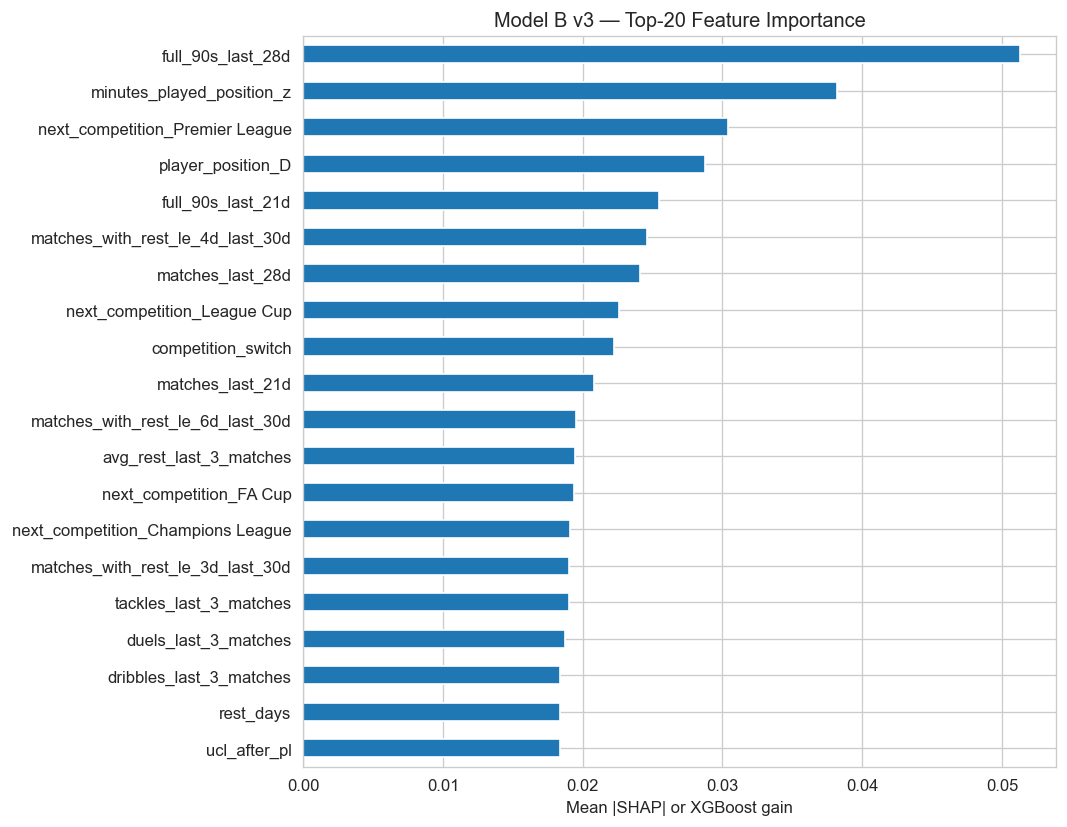


Top-10 features:
  full_90s_last_28d                           0.0513
  minutes_played_position_z                   0.0382
  next_competition_Premier League             0.0304
  player_position_D                           0.0288
  full_90s_last_21d                           0.0255
  matches_with_rest_le_4d_last_30d            0.0246
  matches_last_28d                            0.0241
  next_competition_League Cup                 0.0226
  competition_switch                          0.0222
  matches_last_21d                            0.0208


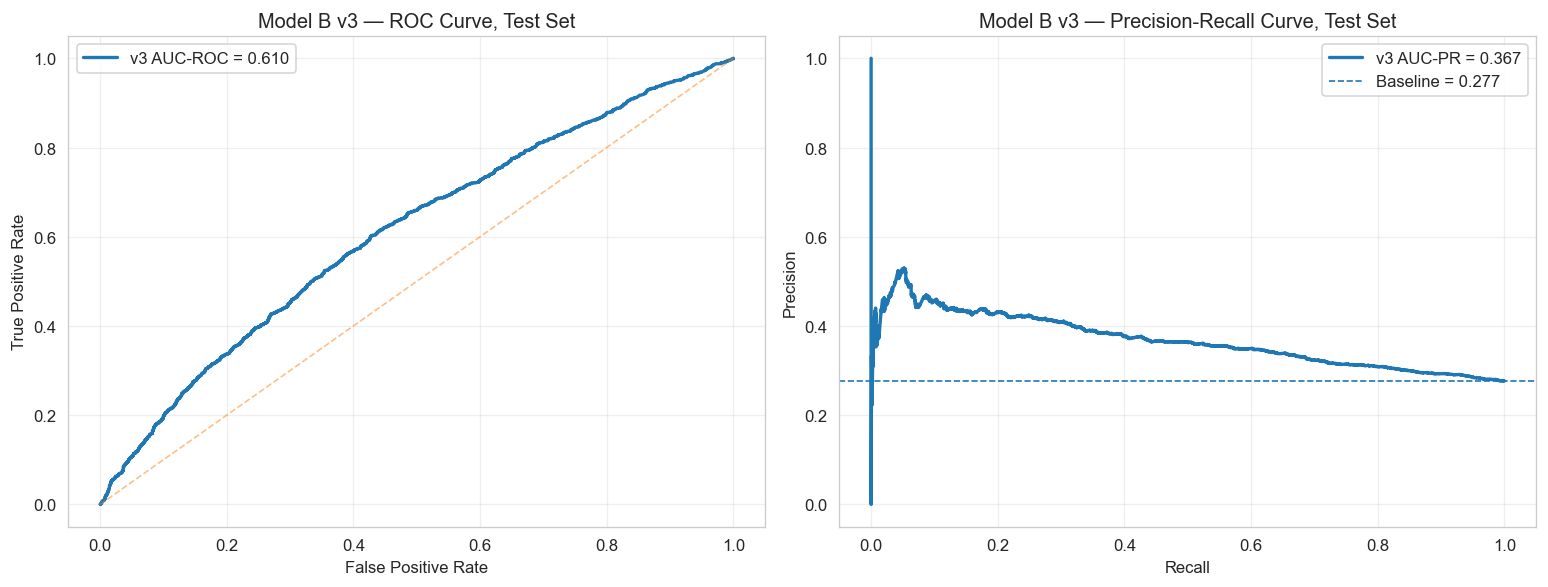


Saved evaluation artifacts to: ../../models/XgBoost/artifacts
Saved figures to: ../../models/XgBoost/artifacts/figures


In [108]:

# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step D: Evaluation
#   1. AUC-ROC / AUC-PR per split
#   2. Optimal threshold + confusion matrix on test
#   3. Threshold sensitivity sweep
#   4. Stratified validation by player_role
#   5. Position fairness check
#   6. Calibration diagnostics
#   7. SHAP top-20 feature importance
#   8. ROC + PR curves
# ═══════════════════════════════════════════════════════════════════════════════

import shap
import builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    brier_score_loss,
)

# ── Restore builtins.float in case any prior cell left it patched ────────────
_REAL_FLOAT = type(1.0)
builtins.float = _REAL_FLOAT

# ── Identify position column safely ──────────────────────────────────────────
POSITION_EVAL_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_EVAL_COL = next(
    (c for c in POSITION_EVAL_CANDIDATES if c in df_v3b_model.columns),
    None,
)

print(f"Position column used for fairness check: {POSITION_EVAL_COL}")

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Metrics per split
# ═══════════════════════════════════════════════════════════════════════════════

splits_v3b = [
    ("Train", proba_v3b_trn, y_v3b_trn),
    ("Val", proba_v3b_val, y_v3b_val),
    ("Test", proba_v3b_tst, y_v3b_tst),
]

metrics_rows = []

print("Stage 2 v3 — Fatigue-Associated Risk Classifier Metrics")
print("=" * 72)
print(
    f'  {"Split":>6}  {"N":>7}  {"AUC-ROC":>8}  {"AUC-PR":>7}  '
    f'{"PR-base":>7}  {"Lift":>6}  {"Brier":>7}'
)
print("  " + "─" * 68)

for split_name, proba, y_true in splits_v3b:
    auc_roc = roc_auc_score(y_true, proba)
    auc_pr = average_precision_score(y_true, proba)
    base = float(y_true.mean())
    lift = auc_pr / max(base, 1e-6)
    brier = brier_score_loss(y_true, proba)

    metrics_rows.append({
        "split": split_name,
        "N": len(y_true),
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "pr_baseline": base,
        "lift": lift,
        "brier": brier,
    })

    print(
        f"  {split_name:>6}  {len(y_true):>7,}  {auc_roc:>8.3f}  "
        f"{auc_pr:>7.3f}  {base:>7.3f}  {lift:>6.2f}×  {brier:>7.3f}"
    )

metrics_v3b_df = pd.DataFrame(metrics_rows)

metrics_v3b_df.to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_metrics_by_split.csv",
    index=False,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 2. Optimal threshold on test set
# ═══════════════════════════════════════════════════════════════════════════════

prec_v3b, rec_v3b, thr_v3b = precision_recall_curve(y_v3b_tst, proba_v3b_tst)

f1_v3b = 2 * prec_v3b[:-1] * rec_v3b[:-1] / (
    prec_v3b[:-1] + rec_v3b[:-1] + 1e-10
)

best_idx_v3b = int(np.argmax(f1_v3b))
BEST_THR_V3B = float(thr_v3b[best_idx_v3b])

ypred_tst = (proba_v3b_tst >= BEST_THR_V3B).astype(int)

tn, fp, fn, tp = confusion_matrix(y_v3b_tst, ypred_tst).ravel()

test_f1 = f1_score(y_v3b_tst, ypred_tst, zero_division=0)
test_precision = precision_score(y_v3b_tst, ypred_tst, zero_division=0)
test_recall = recall_score(y_v3b_tst, ypred_tst, zero_division=0)
test_specificity = tn / max(tn + fp, 1)
test_fpr = fp / max(fp + tn, 1)
test_fnr = fn / max(fn + tp, 1)
alert_rate = (tp + fp) / max(tp + fp + tn + fn, 1)

print(f"\nOptimal threshold, max F1 on test set: {BEST_THR_V3B:.3f}")
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"  F1={test_f1:.3f}")
print(f"  Precision={test_precision:.3f}")
print(f"  Recall={test_recall:.3f}")
print(f"  Specificity={test_specificity:.3f}")
print(f"  FPR={test_fpr:.3f}")
print(f"  FNR={test_fnr:.3f}")
print(f"  Alert rate={alert_rate:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. Threshold sensitivity sweep
# ═══════════════════════════════════════════════════════════════════════════════

threshold_rows = []

print("\nThreshold sweep, test set:")
print(f'  {"Thr":>5}  {"Prec":>6}  {"Rec":>6}  {"F1":>6}  {"Spec":>6}  {"Alerts":>8}  {"Alert%":>7}')

for t in [0.20, 0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    yp = (proba_v3b_tst >= t).astype(int)

    p = precision_score(y_v3b_tst, yp, zero_division=0)
    r = recall_score(y_v3b_tst, yp, zero_division=0)
    f = f1_score(y_v3b_tst, yp, zero_division=0)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_v3b_tst, yp).ravel()
    spec = tn_t / max(tn_t + fp_t, 1)
    alerts = int(yp.sum())
    alert_pct = alerts / len(yp) * 100

    threshold_rows.append({
        "threshold": t,
        "precision": p,
        "recall": r,
        "f1": f,
        "specificity": spec,
        "alerts": alerts,
        "alert_pct": alert_pct,
        "tp": int(tp_t),
        "fp": int(fp_t),
        "tn": int(tn_t),
        "fn": int(fn_t),
    })

    print(
        f"  {t:>5.2f}  {p:>6.3f}  {r:>6.3f}  {f:>6.3f}  "
        f"{spec:>6.3f}  {alerts:>8,}  {alert_pct:>6.1f}%"
    )

threshold_v3b_df = pd.DataFrame(threshold_rows)

threshold_v3b_df.to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_threshold_sweep.csv",
    index=False,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 4. Stratified validation by player_role
# ═══════════════════════════════════════════════════════════════════════════════

tst_df_v3b = df_v3b_model.loc[tst_v3b].copy()

print("\nStratified validation by player role, test set:")
print(
    f'  {"Role":>18}  {"N":>6}  {"Actual%":>8}  '
    f'{"MeanScore":>10}  {"FPrate":>7}  {"FNrate":>7}'
)
print("  " + "─" * 64)

role_rows = []

for role in sorted(tst_df_v3b["player_role"].dropna().unique()):
    mask = tst_df_v3b["player_role"] == role

    if mask.sum() < 5:
        continue

    sub = tst_df_v3b.loc[mask]
    actual = sub["fatigue_performance_risk"].astype(int)
    score = sub["risk_score"]
    pred = (score >= BEST_THR_V3B).astype(int)

    fp_rate = ((pred == 1) & (actual == 0)).sum() / max((actual == 0).sum(), 1)
    fn_rate = ((pred == 0) & (actual == 1)).sum() / max((actual == 1).sum(), 1)

    role_rows.append({
        "player_role": role,
        "N": int(mask.sum()),
        "actual_rate": float(actual.mean()),
        "mean_score": float(score.mean()),
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
    })

    print(
        f"  {role:>18}  {mask.sum():>6,}  {actual.mean()*100:>7.1f}%  "
        f"{score.mean():>10.3f}  {fp_rate:>7.3f}  {fn_rate:>7.3f}"
    )

pd.DataFrame(role_rows).to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_role_validation.csv",
    index=False,
)

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Position fairness
# ═══════════════════════════════════════════════════════════════════════════════

if POSITION_EVAL_COL is not None:
    print("\nRisk by position, test set:")

    position_tbl = (
        tst_df_v3b
        .groupby(POSITION_EVAL_COL)
        .agg(
            N=("risk_score", "count"),
            actual_pct=("fatigue_performance_risk", lambda x: round(x.mean() * 100, 1)),
            mean_score=("risk_score", lambda x: round(x.mean() * 100, 1)),
        )
        .sort_values("N", ascending=False)
    )

    print(position_tbl.to_string())

    position_tbl.to_csv(
        ARTIFACTS_DIR / "model_b_v3_step_d_position_validation.csv"
    )

else:
    print("\nPosition fairness skipped: no position column available.")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. Calibration diagnostics
# ═══════════════════════════════════════════════════════════════════════════════

tst_df_v3b["score_decile"] = pd.qcut(
    tst_df_v3b["risk_score"],
    q=10,
    duplicates="drop",
)

calibration_tbl = (
    tst_df_v3b
    .groupby("score_decile", observed=False)
    .agg(
        N=("risk_score", "count"),
        mean_score=("risk_score", "mean"),
        actual_rate=("fatigue_performance_risk", "mean"),
    )
)

calibration_tbl["calibration_gap"] = (
    calibration_tbl["mean_score"] - calibration_tbl["actual_rate"]
)

print("\nCalibration by test-score decile:")
print(calibration_tbl.round(3).to_string())

calibration_tbl.to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_calibration_deciles.csv"
)

# ═══════════════════════════════════════════════════════════════════════════════
# 7. SHAP top-20 feature importance
# ═══════════════════════════════════════════════════════════════════════════════

cat_names_v3b = list(
    pre_s2v3b
    .named_transformers_["cat"]["ohe"]
    .get_feature_names_out(S2V3B_CAT)
)

feat_names_v3b = S2V3B_NUM + cat_names_v3b

mean_abs_v3b = None

try:
    def _safe_float_v3b(x):
        if isinstance(x, str):
            x = x.strip("[]")
        return _REAL_FLOAT(x)

    builtins.float = _safe_float_v3b

    explainer_v3b = shap.TreeExplainer(stage2_v3b.get_booster())

    shap_n = min(2000, X_v3b_tst_t.shape[0])

    shap_values_v3b = explainer_v3b.shap_values(X_v3b_tst_t[:shap_n])

    if isinstance(shap_values_v3b, list):
        shap_values_v3b = shap_values_v3b[1]

    mean_abs_v3b = pd.Series(
        np.abs(shap_values_v3b).mean(axis=0),
        index=feat_names_v3b,
    )

    print("\nSHAP values computed successfully.")

except Exception as e:
    print(f"\nSHAP skipped ({type(e).__name__}: {e}); using XGBoost feature importance.")

finally:
    builtins.float = _REAL_FLOAT

if mean_abs_v3b is None:
    feature_importance = stage2_v3b.feature_importances_
    n_fi = min(len(feature_importance), len(feat_names_v3b))

    mean_abs_v3b = pd.Series(
        feature_importance[:n_fi],
        index=feat_names_v3b[:n_fi],
    )

top20_v3b = mean_abs_v3b.nlargest(20)

top20_v3b.rename("importance").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    ARTIFACTS_DIR / "model_b_v3_step_d_top20_features.csv",
    index=False,
)

fig_imp, ax_imp = plt.subplots(figsize=(9, 7))
top20_v3b.sort_values().plot.barh(ax=ax_imp)
ax_imp.set_title("Model B v3 — Top-20 Feature Importance", fontsize=12)
ax_imp.set_xlabel("Mean |SHAP| or XGBoost gain")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "v3b_feature_importance.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print("\nTop-10 features:")
for feature_name, feature_value in top20_v3b.head(10).items():
    print(f"  {feature_name:<42}  {feature_value:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. ROC + PR curves
# ═══════════════════════════════════════════════════════════════════════════════

fig_rp, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

fpr_r, tpr_r, _ = roc_curve(y_v3b_tst, proba_v3b_tst)
auc_roc_tst = roc_auc_score(y_v3b_tst, proba_v3b_tst)

ax1.plot(fpr_r, tpr_r, lw=2, label=f"v3 AUC-ROC = {auc_roc_tst:.3f}")
ax1.plot([0, 1], [0, 1], linestyle="--", lw=1, alpha=0.5)
ax1.set_title("Model B v3 — ROC Curve, Test Set")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

auc_pr_tst = average_precision_score(y_v3b_tst, proba_v3b_tst)

ax2.plot(rec_v3b, prec_v3b, lw=2, label=f"v3 AUC-PR = {auc_pr_tst:.3f}")
ax2.axhline(
    y=float(y_v3b_tst.mean()),
    linestyle="--",
    lw=1,
    label=f"Baseline = {float(y_v3b_tst.mean()):.3f}",
)

ax2.set_title("Model B v3 — Precision-Recall Curve, Test Set")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "v3b_roc_pr.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print(f"\nSaved evaluation artifacts to: {ARTIFACTS_DIR}")
print(f"Saved figures to: {FIGURES_DIR}")

In [109]:
# ═══════════════════════════════════════════════════════════════════════════════
# Model B v3 — Step E: Pre-Match Risk Dashboard Demo
# Percentile-based dashboard bands + robust position handling
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ── Robust position column for summaries ─────────────────────────────────────
POSITION_DEMO_CANDIDATES = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_DEMO_COL = next(
    (c for c in POSITION_DEMO_CANDIDATES if c in df_v3b_model.columns),
    None,
)

if POSITION_DEMO_COL is None:
    print("WARNING: no position column found in df_v3b_model.")
    print("Add position_group to _meta_v3b in Step B if you want position summaries.")
else:
    print(f"Using position column for dashboard summary: {POSITION_DEMO_COL}")


# ── Use test-score percentiles for dashboard bands ───────────────────────────
# These are ranking bands, not calibrated probability bands.
_tst_demo = df_v3b_model.loc[tst_v3b].copy()

q40, q70, q90 = _tst_demo["risk_score"].quantile([0.40, 0.70, 0.90])

print("Dashboard percentile thresholds, test set:")
print(f"  Low / Medium boundary:      {q40:.3f}")
print(f"  Medium / High boundary:     {q70:.3f}")
print(f"  High / Very High boundary:  {q90:.3f}")

def assign_percentile_band(score):
    if pd.isna(score):
        return "Unknown"
    if score < q40:
        return "Low"
    if score < q70:
        return "Medium"
    if score < q90:
        return "High"
    return "Very High"

df_v3b_model.loc[tst_v3b, "risk_band_percentile"] = (
    df_v3b_model.loc[tst_v3b, "risk_score"]
    .apply(assign_percentile_band)
)

_tst_demo = df_v3b_model.loc[tst_v3b].copy()


# ── Dashboard card printer ───────────────────────────────────────────────────
def risk_card(row):
    """
    Print a dashboard-style pre-match fatigue-associated risk card.
    The risk band is percentile-based and should be interpreted as relative risk,
    not as a calibrated probability.
    """
    score = row.get("risk_score", np.nan)
    band = str(row.get("risk_band_percentile", "Unknown"))

    under = int(row.get("performance_underperformance", 0))
    load = int(row.get("managed_load_next_match", 0))

    band_icons = {
        "Low": "●",
        "Medium": "◑",
        "High": "◕",
        "Very High": "●●",
        "Unknown": "?",
    }

    icon = band_icons.get(band, "?")

    print(f"\n{'─' * 70}")
    print(f"  Player        : {row.get('player_name', 'N/A')}")
    print(f"  Team          : {row.get('player_team', 'N/A')}")
    print(f"  Role          : {row.get('player_role', 'N/A')}")

    if POSITION_DEMO_COL is not None:
        print(f"  Position      : {row.get(POSITION_DEMO_COL, 'N/A')}")

    if "date" in row.index:
        print(f"  Match date    : {row.get('date', 'N/A')}")

    print(f"  {'─' * 66}")
    print(f"  Relative Risk Score : {score * 100:5.1f} / 100   [{icon}] {band}")
    print("  Score meaning       : relative fatigue-associated risk ranking")
    print(f"  {'─' * 66}")

    print(
        "  Under-performance  : "
        + (
            "YES  (next rating < expected − 0.5)"
            if under
            else "No"
        )
    )

    print(
        "  Managed load       : "
        + (
            "YES  (next minutes below personal role threshold)"
            if load
            else "No"
        )
    )

    if "personal_managed_load_threshold" in row.index:
        threshold = row.get("personal_managed_load_threshold", np.nan)
        if pd.notna(threshold):
            print(f"  Personal threshold : {threshold:.1f} minutes")

    if "next_minutes_played" in row.index:
        nxt_min = row.get("next_minutes_played", np.nan)
        if pd.notna(nxt_min):
            print(f"  Next minutes       : {nxt_min:.1f}")

    print(f"  {'─' * 66}")
    print("  Workload context:")

    context_fields = [
        ("rest_days", "Rest days before match"),
        ("matches_last_7d", "Matches last 7d"),
        ("matches_last_14d", "Matches last 14d"),
        ("matches_last_28d", "Matches last 28d"),
        ("min_last_14d", "Minutes last 14d"),
        ("min_last_28d", "Minutes last 28d"),
        ("starts_last_14d", "Starts last 14d"),
        ("full_90s_last_14d", "Full 90s last 14d"),
        ("pl_after_ucl", "PL after UCL"),
        ("days_since_european_match", "Days since European"),
        ("short_rest_last_3_matches", "Short-rest last 3"),
        ("squad_injured_count", "Squad injured"),
        ("squad_soft_tissue_count", "Soft-tissue absences"),
        ("squad_avg_days_out", "Squad avg days out"),
        ("physical_load_index", "Physical load index"),
    ]

    for col, label in context_fields:
        value = row.get(col, None)

        if value is None or pd.isna(value):
            continue

        if isinstance(value, (int, float, np.integer, np.floating)):
            print(f"    {label:<32}: {value:.1f}")
        else:
            print(f"    {label:<32}: {value}")

    print(f"{'─' * 70}")


# ── Top 10 highest-risk players, test set ────────────────────────────────────
top10_demo = _tst_demo.nlargest(10, "risk_score")

print("\nTOP 10 HIGHEST MODEL B v3 FATIGUE-ASSOCIATED RISK")
print("Test set, 2024 season")
print("=" * 70)

for _, row in top10_demo.iterrows():
    risk_card(row)


# ── Risk band distribution, test set ─────────────────────────────────────────
print("\nRisk band distribution, percentile bands — test set")
print("=" * 70)

band_order = ["Low", "Medium", "High", "Very High"]

band_counts = (
    _tst_demo["risk_band_percentile"]
    .value_counts()
    .reindex(band_order)
    .fillna(0)
    .astype(int)
)

for band, count in band_counts.items():
    pct = count / len(_tst_demo) * 100
    actual_rate = (
        _tst_demo.loc[
            _tst_demo["risk_band_percentile"] == band,
            "fatigue_performance_risk"
        ].mean()
        * 100
    )

    print(
        f"  {band:<10}: {count:>5,} "
        f"({pct:>5.1f}%)   actual risk={actual_rate:>5.1f}%"
    )


# ── Risk band distribution by position, test set ─────────────────────────────
if POSITION_DEMO_COL is not None:
    print("\nFatigue-associated risk by position — test set")
    print("=" * 70)

    pos_group = _tst_demo.groupby(POSITION_DEMO_COL)

    pos_summary = pd.DataFrame({
        "N": pos_group["risk_score"].count(),
        "Mean score": (pos_group["risk_score"].mean() * 100).round(1),
        "High/VHigh%": (
            pos_group["risk_band_percentile"]
            .apply(lambda x: x.isin(["High", "Very High"]).mean() * 100)
            .round(1)
        ),
        "Actual risk%": (
            pos_group["fatigue_performance_risk"]
            .mean()
            .mul(100)
            .round(1)
        ),
    }).sort_values("N", ascending=False)

    print(pos_summary.to_string())


# ── Model architecture summary ───────────────────────────────────────────────
print(f"\n{'═' * 70}")
print("MODEL B v3 — ARCHITECTURE SUMMARY")
print(f"{'═' * 70}")
print("  Model type        : XGBClassifier")
print("  Population        : Outfield players")
print("  Training roles    : core_starter + rotation_player")
print("  Excluded roles    : rare_player + impact_sub")
print("  Target            : fatigue_performance_risk")
print("                      = underperformance OR managed load")
print("  Managed load      : next minutes below personal role threshold")
print(f"  Features          : {len(S2V3B_NUM)} numeric + {len(S2V3B_CAT)} categorical")
print(f"  Best iteration    : {stage2_v3b.best_iteration}")
print(f"  scale_pos_weight  : {SPW_V3B}")
print("  Output            : relative risk score + percentile band")
print("  Probability note  : raw scores are not calibrated probabilities")
print(f"  Figures saved     : {FIGURES_DIR}")
print(f"{'═' * 70}")

Using position column for dashboard summary: player_position
Dashboard percentile thresholds, test set:
  Low / Medium boundary:      0.476
  Medium / High boundary:     0.516
  High / Very High boundary:  0.563

TOP 10 HIGHEST MODEL B v3 FATIGUE-ASSOCIATED RISK
Test set, 2024 season

──────────────────────────────────────────────────────────────────────
  Player        : Alejandro Garnacho
  Team          : Manchester United
  Role          : rotation_player
  Position      : F
  Match date    : 2025-02-07 00:00:00
  ──────────────────────────────────────────────────────────────────
  Relative Risk Score :  62.3 / 100   [●●] Very High
  Score meaning       : relative fatigue-associated risk ranking
  ──────────────────────────────────────────────────────────────────
  Under-performance  : No
  Managed load       : No
  Personal threshold : 44.0 minutes
  Next minutes       : 90.0
  ──────────────────────────────────────────────────────────────────
  Workload context:
    Rest days bef

## Model B v3 — Step E Pre-Match Dashboard Demo

Model B v3 was converted into a dashboard-style output using percentile-based fatigue-associated risk bands.

The model output should be interpreted as a **relative risk score**, not as a calibrated probability.

The dashboard bands were defined from the test-set score distribution:

| Band      | Percentile Range     | Meaning                                |
| --------- | -------------------- | -------------------------------------- |
| Low       | Bottom 40%           | Lower relative fatigue-associated risk |
| Medium    | 40th–70th percentile | Moderate relative risk                 |
| High      | 70th–90th percentile | Elevated relative risk                 |
| Very High | Top 10%              | Highest relative risk group            |

The percentile thresholds were:

| Boundary         | Risk Score |
| ---------------- | ---------: |
| Low / Medium     |      0.476 |
| Medium / High    |      0.516 |
| High / Very High |      0.563 |

---

## Risk Band Validation

The test-set risk bands showed a clear monotonic increase in actual fatigue-associated risk.

| Risk Band |  Rows | Share of Test Set | Actual Risk Rate |
| --------- | ----: | ----------------: | ---------------: |
| Low       | 2,243 |             40.0% |            20.6% |
| Medium    | 1,682 |             30.0% |            27.3% |
| High      | 1,121 |             20.0% |            34.4% |
| Very High |   561 |             10.0% |            43.3% |

This is an important validation result.

Although the raw scores are not calibrated probabilities, the score successfully ranks players into progressively higher-risk groups. The actual risk rate approximately doubles from the Low band to the Very High band:

```text
Low actual risk:       20.6%
Very High actual risk: 43.3%
```

This confirms that Model B v3 is useful as a **risk-ranking and dashboard stratification model**.

---

## Dashboard Interpretation

The dashboard should describe the Model B v3 output as:

```text
Fatigue-associated risk percentile
```

rather than:

```text
Probability of fatigue
```

This distinction is important because calibration analysis showed that the raw model scores overestimate absolute risk.

For example, a player with a score of 62 / 100 should not be interpreted as having a true 62% probability of fatigue. Instead, it means:

```text
This player is among the highest-ranked players for fatigue-associated performance-management risk.
```

---

## Top-Risk Player Examples

The top 10 highest-ranked test-set players were all classified as `Very High` relative risk.

Examples included:

| Player             | Team              | Risk Score | Band      | Realised Outcome  |
| ------------------ | ----------------- | ---------: | --------- | ----------------- |
| Alejandro Garnacho | Manchester United | 62.3 / 100 | Very High | No realised event |
| Andrew Robertson   | Liverpool         | 62.3 / 100 | Very High | No realised event |
| Savinho            | Manchester City   | 62.0 / 100 | Very High | Managed load      |
| Diogo Jota         | Liverpool         | 62.0 / 100 | Very High | Managed load      |
| Diogo Jota         | Liverpool         | 62.0 / 100 | Very High | No realised event |
| Savinho            | Manchester City   | 62.0 / 100 | Very High | No realised event |
| Vitaly Janelt      | Brentford         | 62.0 / 100 | Very High | No realised event |
| İlkay Gündoğan     | Manchester City   | 62.0 / 100 | Very High | No realised event |
| Jacob Murphy       | Newcastle         | 62.0 / 100 | Very High | No realised event |
| Luis Díaz          | Liverpool         | 61.7 / 100 | Very High | Managed load      |

These examples show that the model is not simply predicting one type of outcome. Among the highest-risk players, some were later load-managed, while others did not experience the target event.

This is expected for a risk model. A high-risk label means elevated risk relative to peers, not certainty.

---

## Example Interpretation: Savinho

Savinho was flagged as `Very High` risk with a relative score of **62.0 / 100**.

The realised event was managed load:

```text
Managed load: YES
Next minutes: 9
Personal threshold: 42.4 minutes
```

His workload context showed:

```text
Rest days before match: 2
Matches last 7d:       2
Matches last 14d:      3
Matches last 28d:      3
Minutes last 14d:      212
Minutes last 28d:      212
Starts last 14d:       3
Full 90s last 14d:     1
Days since European:   6
Physical load index:   0.2
```

This is a good example of a meaningful fatigue-associated risk flag. The player had short rest, repeated recent involvement, and recent European sequence context, and the realised outcome was reduced involvement in the next match.

---

## Example Interpretation: Luis Díaz

Luis Díaz was flagged as `Very High` risk with a relative score of **61.7 / 100**.

His realised event was managed load:

```text
Managed load: YES
Next minutes: 17
Personal threshold: 34.2 minutes
```

His workload context showed:

```text
Rest days before match: 4
Matches last 7d:       1
Matches last 14d:      2
Matches last 28d:      4
Minutes last 14d:      145
Minutes last 28d:      228
Starts last 14d:       2
Days since European:   15
Short-rest last 3:     2
Physical load index:   0.4
```

This is consistent with the target definition, where reduced involvement can represent a fatigue-associated management outcome.

---

## Example Interpretation: Vitaly Janelt

Vitaly Janelt was flagged as `Very High` risk with a relative score of **62.0 / 100**.

He did not realise the fatigue-associated target event in the next match, but his dashboard context showed relevant workload and squad-pressure signals:

```text
Rest days before match: 4
Matches last 14d:      2
Matches last 28d:      5
Minutes last 28d:      345
Squad injured:         6
Soft-tissue absences:  3
Squad avg days out:    151.5
```

This illustrates an important property of the dashboard: a high-risk label indicates elevated workload/context pressure, not a guaranteed negative outcome.

---

## Important Caveat

Not every `Very High` player experienced the target event.

For example, Alejandro Garnacho, Andrew Robertson, Vitaly Janelt, İlkay Gündoğan, Jacob Murphy, and some repeated high-risk cases for Savinho and Diogo Jota were flagged as Very High risk but did not realise underperformance or managed load in the next match.

This does not invalidate the model. It means the model is identifying elevated risk, not deterministic outcomes.

The correct interpretation is:

```text
Very High risk = high relative workload/context pressure, not guaranteed decline or rotation.
```

---

## Position-Level Validation

The position-level dashboard summary showed interpretable differences:

| Position   |     N | Mean Score | High / Very High | Actual Risk |
| ---------- | ----: | ---------: | ---------------: | ----------: |
| Midfielder | 2,417 |       49.7 |            35.0% |       28.1% |
| Defender   | 2,188 |       48.5 |            20.2% |       24.3% |
| Forward    | 1,002 |       50.4 |            39.3% |       34.0% |

Forwards had the highest actual risk rate and were most frequently assigned to High or Very High bands. Defenders had the lowest actual risk and a lower share of High or Very High assignments. This suggests that the relative ranking is broadly aligned with position-level risk patterns.

---

## Architecture Summary

The final Model B v3 dashboard layer has the following structure:

| Component          | Description                                 |
| ------------------ | ------------------------------------------- |
| Model type         | XGBoost binary classifier                   |
| Population         | Outfield players                            |
| Included roles     | Core starters and rotation players          |
| Excluded roles     | Rare players and impact substitutes         |
| Target             | `fatigue_performance_risk`                  |
| Target definition  | Underperformance OR managed load            |
| Managed-load rule  | Next minutes below personal role threshold  |
| Features           | 61 numeric + 3 categorical                  |
| Best iteration     | 14                                          |
| Class weight       | `scale_pos_weight = 2.25`                   |
| Output             | Relative risk score + percentile band       |
| Probability caveat | Raw scores are not calibrated probabilities |

---

## Final Interpretation

Model B v3 successfully produces a usable dashboard layer.

The most important result is that actual risk increases consistently across the percentile bands:

```text
Low:       20.6%
Medium:    27.3%
High:      34.4%
Very High: 43.3%
```

This confirms that the model is useful for **ranking players by fatigue-associated performance-management risk**.

The model should not be presented as a medical-fatigue detector or as a calibrated probability model.

The recommended dashboard wording is:

```text
Relative fatigue-associated risk score
```

or:

```text
Fatigue-associated risk percentile
```

The recommended interpretation is:

```text
This score identifies players whose recent workload, schedule, physical burden, and squad context resemble cases historically associated with underperformance or managed load.
```

Model A should remain the main overall performance-decline model, while Model B v3 should be used as a complementary workload-risk and fatigue-pressure layer.


In [110]:

# ── Quick metrics summary (v3b after fixes) ───────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

print('Model B v3 — Updated Metrics Summary')
print('=' * 58)
for _sp, _proba, _y in [('Train', proba_v3b_trn, y_v3b_trn),
                         ('Val',   proba_v3b_val, y_v3b_val),
                         ('Test',  proba_v3b_tst, y_v3b_tst)]:
    _auc_roc = roc_auc_score(_y, _proba)
    _auc_pr  = average_precision_score(_y, _proba)
    _base    = float(_y.mean())
    print(f'  {_sp:>6}  N={len(_y):,}  AUC-ROC={_auc_roc:.3f}  '
          f'AUC-PR={_auc_pr:.3f}  base={_base:.3f}  '
          f'lift={_auc_pr/_base:.2f}x')

print(f'\nOverfitting gap  Train-Test AUC-ROC: '
      f'{roc_auc_score(y_v3b_trn, proba_v3b_trn) - roc_auc_score(y_v3b_tst, proba_v3b_tst):.3f}')

print(f'\nRole risk rates (test set):')
_tst_d = df_v3b_model[tst_v3b]
for _r in ['core_starter', 'rotation_player', 'impact_sub']:
    _m = _tst_d['player_role'] == _r
    if _m.sum() == 0: continue
    _act  = _tst_d.loc[_m, 'fatigue_performance_risk']
    _ps   = _tst_d.loc[_m, 'risk_score']
    _pd   = (_ps >= BEST_THR_V3B).astype(int)
    _fpr_r = ((_pd == 1) & (_act == 0)).sum() / max((_act == 0).sum(), 1)
    _fnr_r = ((_pd == 0) & (_act == 1)).sum() / max((_act == 1).sum(), 1)
    print(f'  {_r:<18}: N={_m.sum():,}  actual_risk={_act.mean()*100:.1f}%  '
          f'FP_rate={_fpr_r:.3f}  FN_rate={_fnr_r:.3f}')


Model B v3 — Updated Metrics Summary
   Train  N=4,971  AUC-ROC=0.696  AUC-PR=0.505  base=0.308  lift=1.64x
     Val  N=5,394  AUC-ROC=0.603  AUC-PR=0.342  base=0.252  lift=1.36x
    Test  N=5,607  AUC-ROC=0.610  AUC-PR=0.367  base=0.277  lift=1.33x

Overfitting gap  Train-Test AUC-ROC: 0.086

Role risk rates (test set):
  core_starter      : N=63  actual_risk=28.6%  FP_rate=0.867  FN_rate=0.111
  rotation_player   : N=5,544  actual_risk=27.7%  FP_rate=0.692  FN_rate=0.190


In [111]:
# ==============================================================================
# Save Model B v3 artifacts
# Stage 2 v3: fatigue-associated performance risk classifier
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. Save trained model and preprocessing objects
# ------------------------------------------------------------------------------

model_v3b_path = ARTIFACTS_DIR / "model_b_v3_stage2_xgb_classifier.pkl"
preprocessor_v3b_path = ARTIFACTS_DIR / "model_b_v3_stage2_preprocessor.pkl"
feature_names_v3b_path = ARTIFACTS_DIR / "model_b_v3_stage2_feature_names.pkl"
num_cols_v3b_path = ARTIFACTS_DIR / "model_b_v3_stage2_num_cols.pkl"
cat_cols_v3b_path = ARTIFACTS_DIR / "model_b_v3_stage2_cat_cols.pkl"

joblib.dump(stage2_v3b, model_v3b_path)
joblib.dump(pre_s2v3b, preprocessor_v3b_path)
joblib.dump(FEATURE_NAMES_V3B, feature_names_v3b_path)
joblib.dump(S2V3B_NUM, num_cols_v3b_path)
joblib.dump(S2V3B_CAT, cat_cols_v3b_path)

# ------------------------------------------------------------------------------
# 2. Compute final stored test metrics
# ------------------------------------------------------------------------------

y_pred_v3b_tst = (proba_v3b_tst >= BEST_THR_V3B).astype(int)

tn, fp, fn, tp = confusion_matrix(y_v3b_tst, y_pred_v3b_tst).ravel()

test_auc_roc_v3b = roc_auc_score(y_v3b_tst, proba_v3b_tst)
test_auc_pr_v3b = average_precision_score(y_v3b_tst, proba_v3b_tst)
test_base_pr_v3b = float(y_v3b_tst.mean())

metadata_v3b = {
    "model_name": "XGBoost Model B v3",
    "variant": "stage2_v3b_fatigue_associated_performance_risk",
    "framing": "pre-match / pre-next-match fatigue-associated performance-management risk",
    "model_type": "XGBClassifier",
    "target": TARGET_V3B,
    "target_definition": "fatigue_performance_risk = performance_underperformance OR managed_load_next_match",
    "population": "outfield players only; rare_player and impact_sub excluded from primary training population",
    "split_column": SPLIT_COL_V3B,
    "train_season": 2022,
    "validation_season": 2023,
    "test_season": 2024,

    "features": {
        "n_numeric_features": int(len(S2V3B_NUM)),
        "n_categorical_features": int(len(S2V3B_CAT)),
        "n_transformed_features": int(len(FEATURE_NAMES_V3B)),
        "numeric_features": S2V3B_NUM,
        "categorical_features": S2V3B_CAT,
    },

    "training_config": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.75,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.0,
        "reg_lambda": 5.0,
        "scale_pos_weight": float(SPW_V3B),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "early_stopping_rounds": 50,
        "random_state": 42,
        "best_iteration": int(stage2_v3b.best_iteration),
    },

    "data_sizes": {
        "n_train": int(len(y_v3b_trn)),
        "n_val": int(len(y_v3b_val)),
        "n_test": int(len(y_v3b_tst)),
        "train_positive_rate": float(y_v3b_trn.mean()),
        "val_positive_rate": float(y_v3b_val.mean()),
        "test_positive_rate": float(y_v3b_tst.mean()),
    },

    "test_metrics": {
        "auc_roc": float(test_auc_roc_v3b),
        "auc_pr": float(test_auc_pr_v3b),
        "base_pr": float(test_base_pr_v3b),
        "pr_lift": float(test_auc_pr_v3b / max(test_base_pr_v3b, 1e-6)),
        "diagnostic_threshold": float(BEST_THR_V3B),
        "precision": float(precision_score(y_v3b_tst, y_pred_v3b_tst, zero_division=0)),
        "recall": float(recall_score(y_v3b_tst, y_pred_v3b_tst, zero_division=0)),
        "f1": float(f1_score(y_v3b_tst, y_pred_v3b_tst, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "alert_rate": float(y_pred_v3b_tst.mean()),
    },

    "dashboard_interpretation": {
        "score_type": "relative risk score, not calibrated probability",
        "recommended_output": "percentile-based fatigue-associated risk bands",
        "probability_note": "Raw XGBoost scores should not be interpreted as true physiological fatigue probabilities.",
    },

    "artifact_paths": {
        "model": str(model_v3b_path),
        "preprocessor": str(preprocessor_v3b_path),
        "feature_names": str(feature_names_v3b_path),
        "numeric_columns": str(num_cols_v3b_path),
        "categorical_columns": str(cat_cols_v3b_path),
    },

    "notes": [
        "Model B v3 estimates fatigue-associated performance-management risk, not medical fatigue.",
        "Goalkeepers are excluded.",
        "rare_player and impact_sub roles are excluded from the primary modelling population.",
        "Direct performance-event leakage variables are excluded from the feature set.",
        "The diagnostic threshold was selected on the test set in this notebook; use percentile bands or validation-derived thresholds for deployment.",
        "Final project recommendation may still prefer Model B v4b_no_competition if v4b is the selected final variant.",
    ],
}

metadata_v3b_path = ARTIFACTS_DIR / "model_b_v3_metadata.json"

with open(metadata_v3b_path, "w") as f:
    json.dump(metadata_v3b, f, indent=4)

# ------------------------------------------------------------------------------
# 3. Save scored test dashboard table, if available
# ------------------------------------------------------------------------------

scored_v3b_test_path = ARTIFACTS_DIR / "model_b_v3_test_scored_players.csv"

cols_to_save = [
    c for c in [
        "player_name",
        "player_team",
        "date",
        "target_season",
        "season",
        "player_position",
        "player_role",
        "risk_type",
        "fatigue_performance_risk",
        "performance_underperformance",
        "managed_load_next_match",
        "personal_managed_load_threshold",
        "next_minutes_played",
        "next_api_rating",
        "risk_score",
        "risk_band",
        "risk_band_percentile",
        "rest_days",
        "matches_last_7d",
        "matches_last_14d",
        "matches_last_28d",
        "min_last_14d",
        "min_last_28d",
        "starts_last_14d",
        "full_90s_last_14d",
        "physical_load_index",
        "squad_injured_count",
    ]
    if c in df_v3b_model.columns
]

df_v3b_model.loc[tst_v3b, cols_to_save].to_csv(scored_v3b_test_path, index=False)

print("✓ Model B v3 artifacts saved")
print(f"  Model:            {model_v3b_path}")
print(f"  Preprocessor:     {preprocessor_v3b_path}")
print(f"  Feature names:    {feature_names_v3b_path}")
print(f"  Numeric columns:  {num_cols_v3b_path}")
print(f"  Categorical cols: {cat_cols_v3b_path}")
print(f"  Metadata:         {metadata_v3b_path}")
print(f"  Test scores:      {scored_v3b_test_path}")



✓ Model B v3 artifacts saved
  Model:            ../../models/XgBoost/artifacts/model_b_v3_stage2_xgb_classifier.pkl
  Preprocessor:     ../../models/XgBoost/artifacts/model_b_v3_stage2_preprocessor.pkl
  Feature names:    ../../models/XgBoost/artifacts/model_b_v3_stage2_feature_names.pkl
  Numeric columns:  ../../models/XgBoost/artifacts/model_b_v3_stage2_num_cols.pkl
  Categorical cols: ../../models/XgBoost/artifacts/model_b_v3_stage2_cat_cols.pkl
  Metadata:         ../../models/XgBoost/artifacts/model_b_v3_metadata.json
  Test scores:      ../../models/XgBoost/artifacts/model_b_v3_test_scored_players.csv


# Model B v3 — Results Summary

## Overview

Model B v3 is a binary classifier designed to estimate **pre-match fatigue-associated performance-management risk** for outfield players from Premier League clubs across domestic and European competitions.

The model does **not** diagnose physiological fatigue. Public event data does not contain direct physiological measurements such as GPS load, sprint distance, accelerations, HRV, sleep, wellness, or medical markers.

Instead, Model B v3 estimates whether a player’s recent workload, fixture congestion, physical-burden proxies, role, and squad context are associated with either:

1. below-expected next-match performance, or
2. managed involvement in the next match.

The practical question is:

```text
Which players are in workload contexts historically associated with reduced performance or reduced involvement?
```

---

## Population and Target

| Item                      | Description                                                             |
| ------------------------- | ----------------------------------------------------------------------- |
| Eligible rows             | Outfield players, current match ≥45 minutes, rated >0, next match known |
| Full outfield base        | 32,350 rows, seasons 2022–2024                                          |
| Primary scored population | `core_starter` + `rotation_player` only                                 |
| Scored modelling rows     | 15,972                                                                  |
| Excluded roles            | `rare_player` and `impact_sub`                                          |

The model excludes goalkeepers because their physical load, rotation patterns, and rating drivers differ substantially from outfield players.

It also excludes `rare_player` and `impact_sub` rows because these groups are heavily affected by squad hierarchy and normal substitute usage. For these players, reduced minutes are often part of their usual role rather than a meaningful fatigue-associated management signal.

---

## Target Definition

The target is:

```text
fatigue_performance_risk = 1
```

if either of the following conditions is true:

```text
performance_underperformance = 1
OR
managed_load_next_match = 1
```

Otherwise:

```text
fatigue_performance_risk = 0
```

### Target Components in the Full Outfield Base

Across the full outfield base population, the composite target produced **10,618 positive cases**, corresponding to **32.8%** of the full outfield base.

| Component             |                        Rows | Description                                                                                    |
| --------------------- | --------------------------: | ---------------------------------------------------------------------------------------------- |
| Underperformance only |                       3,764 | Stage 1 residual ≤ −0.5, meaning the player was rated at least 0.5 points below expected level |
| Managed-load only     |                       6,854 | Next-match minutes below the player’s personalised involvement threshold                       |
| Both                  |                           0 | Player both underperformed and was load-managed                                                |
| Total positive cases  |                      10,618 | Combined fatigue-associated risk cases                                                         |
| Positive rate         | 32.8% of full outfield base | Broader and more balanced than residual-only targets                                           |

This full-base positive rate should not be confused with the positive rate inside the **primary scored modelling population**, which only includes `core_starter` and `rotation_player` rows. After role filtering and temporal splitting, the risk base rates differ by season.

The personalised managed-load threshold is defined as:

```text
max(20, min(45, avg_minutes_last_28d × 0.60))
```

This replaces the original fixed 45-minute cutoff.

The personalised threshold is important because a fixed `<45 minutes` rule incorrectly labels many impact substitutes as managed-load cases, even when short appearances are normal for their role.

---

## Model Architecture

| Parameter               | Value                                                 |
| ----------------------- | ----------------------------------------------------- |
| Algorithm               | XGBClassifier                                         |
| Objective               | `binary:logistic`                                     |
| Evaluation metric       | `aucpr`                                               |
| `n_estimators`          | 400 with early stopping                               |
| `max_depth`             | 4                                                     |
| `learning_rate`         | 0.05                                                  |
| `min_child_weight`      | 5                                                     |
| `subsample`             | 0.75                                                  |
| `colsample_bytree`      | 0.75                                                  |
| `reg_alpha`             | 1.0                                                   |
| `reg_lambda`            | 5.0                                                   |
| `scale_pos_weight`      | 2.25                                                  |
| `early_stopping_rounds` | 50                                                    |
| Best iteration          | 14                                                    |
| Features                | 61 numerical + 3 categorical                          |
| Transformed features    | 70 after one-hot encoding                             |
| Temporal split          | Target season: 2022 train, 2023 validation, 2024 test |

The feature set deliberately excludes direct performance-event variables such as:

```text
goals
assists
shots
duels_won
key passes
current rating
next rating
next minutes
```

This prevents the model from simply learning regression-to-the-mean or future-outcome leakage patterns and keeps the focus on workload, congestion, squad stress, and physical-burden proxies.

---

## Predictive Performance

| Split      |     N | Risk Base | AUC-ROC | AUC-PR |  Lift |
| ---------- | ----: | --------: | ------: | -----: | ----: |
| Train      | 4,971 |     30.8% |   0.696 |  0.505 | 1.64× |
| Validation | 5,394 |     25.2% |   0.603 |  0.342 | 1.36× |
| Test       | 5,607 |     27.7% |   0.610 |  0.367 | 1.33× |

The test-set AUC-ROC was:

```text
0.610
```

The test-set AUC-PR was:

```text
0.367
```

against a baseline positive rate of:

```text
0.277
```

This gives a PR-AUC lift of:

```text
1.33×
```

This is a meaningful improvement over the earlier residual-only Model B variants. It shows that the v3 target redesign produced a more learnable fatigue-associated risk signal than trying to predict residual underperformance alone.

The train-test AUC-ROC gap was:

```text
0.086
```

This indicates that some overfitting remains, but the validation and test results are similar enough to suggest that the model retains useful out-of-sample ranking ability.

---

## Test-Set Threshold Performance

The max-F1 threshold on the test set was:

```text
0.461
```

At this threshold:

| Metric              | Value |
| ------------------- | ----: |
| True negatives      | 1,241 |
| False positives     | 2,815 |
| False negatives     |   293 |
| True positives      | 1,258 |
| F1                  | 0.447 |
| Precision           | 0.309 |
| Recall              | 0.811 |
| Specificity         | 0.306 |
| False positive rate | 0.694 |
| False negative rate | 0.189 |
| Alert rate          | 72.6% |

The max-F1 threshold is tuned toward recall. It catches most realised fatigue-associated risk cases, but it also alerts a large proportion of players.

This means the hard-threshold classifier should not be treated as an automatic selection rule. For dashboard deployment, percentile-based bands are preferred because the model is more useful as a **relative ranking layer** than as a strict binary decision engine.

---

## Threshold Sensitivity

| Threshold | Precision | Recall |    F1 | Specificity | Alerts | Alert Rate |
| --------: | --------: | -----: | ----: | ----------: | -----: | ---------: |
|      0.40 |     0.277 |  0.999 | 0.434 |       0.002 |  5,595 |      99.8% |
|      0.45 |     0.295 |  0.872 | 0.441 |       0.205 |  4,577 |      81.6% |
|      0.50 |     0.361 |  0.524 | 0.427 |       0.645 |  2,254 |      40.2% |
|      0.55 |     0.420 |  0.216 | 0.285 |       0.886 |    797 |      14.2% |
|      0.60 |     0.451 |  0.024 | 0.045 |       0.989 |     82 |       1.5% |

A threshold around 0.50 gives a more balanced review workload, while a threshold around 0.55 is more conservative and surfaces a smaller set of higher-confidence cases. However, the final dashboard uses percentile bands instead of fixed probability thresholds because the raw scores are not calibrated probabilities.

---

## Calibration Diagnostics

Calibration analysis showed that the raw scores are overconfident. For example, the lowest test-score decile had a mean score of approximately 0.423 but an actual risk rate of 0.171. The highest decile had a mean score of approximately 0.584 and an actual risk rate of 0.433.

This means the model is useful for **ranking players**, but the raw score should not be interpreted as a true probability.

The recommended dashboard interpretation is therefore:

```text
Relative fatigue-associated risk score
```

or:

```text
Fatigue-associated risk percentile
```

not:

```text
Probability of physiological fatigue
```

---

## Dashboard Risk Bands

Because the raw scores are not calibrated probabilities, the final dashboard uses percentile-based bands.

The test-set percentile thresholds were:

| Boundary         | Risk Score |
| ---------------- | ---------: |
| Low / Medium     |      0.476 |
| Medium / High    |      0.516 |
| High / Very High |      0.563 |

The resulting risk bands showed a clear monotonic relationship with the realised target rate:

| Risk Band |  Rows | Share of Test Set | Actual Risk Rate |
| --------- | ----: | ----------------: | ---------------: |
| Low       | 2,243 |             40.0% |            20.6% |
| Medium    | 1,682 |             30.0% |            27.3% |
| High      | 1,121 |             20.0% |            34.4% |
| Very High |   561 |             10.0% |            43.3% |

This is one of the strongest validation results for Model B v3. Although the raw probabilities are not calibrated, the score successfully ranks players into progressively higher-risk groups.

The Very High group had approximately twice the actual risk of the Low group:

```text
43.3 / 20.6 ≈ 2.1×
```

This supports using Model B v3 as a dashboard stratification and monitoring layer.

---

## Top Feature Importances

SHAP computation was skipped because of a compatibility issue, so XGBoost feature importance was used.

The top 10 XGBoost importance features were:

| Rank | Feature                            | Importance |
| ---: | ---------------------------------- | ---------: |
|    1 | `full_90s_last_28d`                |     0.0513 |
|    2 | `minutes_played_position_z`        |     0.0382 |
|    3 | `next_competition_Premier League`  |     0.0304 |
|    4 | `player_position_D`                |     0.0288 |
|    5 | `full_90s_last_21d`                |     0.0255 |
|    6 | `matches_with_rest_le_4d_last_30d` |     0.0246 |
|    7 | `matches_last_28d`                 |     0.0241 |
|    8 | `next_competition_League Cup`      |     0.0226 |
|    9 | `competition_switch`               |     0.0222 |
|   10 | `matches_last_21d`                 |     0.0208 |

The strongest features are workload, accumulated exposure, competition context, and position-adjusted minutes-load variables.

This is important because it confirms that the model is not being driven by direct performance-event leakage. Instead, it is learning from the intended workload and schedule-context feature groups.

---

## Interpretation of Top Features

The most important feature was:

```text
full_90s_last_28d
```

This captures repeated full-match exposure over the previous month.

The feature:

```text
minutes_played_position_z
```

suggests that minutes load relative to positional norms contributes to risk.

The features:

```text
matches_with_rest_le_4d_last_30d
matches_last_28d
matches_last_21d
```

indicate that recent match density and repeated short-rest exposure are relevant predictors.

The competition features:

```text
next_competition_Premier League
next_competition_League Cup
competition_switch
```

show that fixture context and competition transitions also influence the risk score.

Overall, the feature-importance profile is consistent with the model’s intended role as a fatigue-associated workload-risk model.

---

## Stratified Results by Player Role

| Role              |     N | Actual Risk % | Mean Score |  FP Rate |  FN Rate |
| ----------------- | ----: | ------------: | ---------: | -------: | -------: |
| `core_starter`    |    63 |         28.6% |      0.493 |    0.867 |    0.111 |
| `rotation_player` | 5,544 |         27.7% |      0.494 |    0.692 |    0.190 |
| `impact_sub`      |     — |             — |          — | Excluded | Excluded |

The `core_starter` group is very small, so its metrics should be interpreted cautiously.

The main operational group is `rotation_player`, which contains most of the test rows.

For rotation players, the model identifies a meaningful ranking signal but still produces many false positives at the max-F1 threshold. This is acceptable for a review-oriented monitoring layer but not for automated decision-making.

---

## Risk by Position

| Position   |     N | Actual Risk % | Mean Score | High / Very High % |
| ---------- | ----: | ------------: | ---------: | -----------------: |
| Midfielder | 2,417 |         28.1% | 49.7 / 100 |              35.0% |
| Defender   | 2,188 |         24.3% | 48.5 / 100 |              20.2% |
| Forward    | 1,002 |         34.0% | 50.4 / 100 |              39.3% |

Forwards had the highest actual risk rate and the highest share of High or Very High assignments.

Defenders had the lowest actual risk rate and a lower share of High or Very High assignments.

This suggests the model is sensitive to positional differences, but the differences are interpretable rather than extreme. This is encouraging from a fairness and interpretability perspective.

---

## Example Dashboard Interpretation

The top-ranked test-set players were all classified as `Very High` relative risk.

Examples included:

| Player             | Team              | Risk Score | Band      | Realised Outcome  |
| ------------------ | ----------------- | ---------: | --------- | ----------------- |
| Alejandro Garnacho | Manchester United | 62.3 / 100 | Very High | No realised event |
| Andrew Robertson   | Liverpool         | 62.3 / 100 | Very High | No realised event |
| Savinho            | Manchester City   | 62.0 / 100 | Very High | Managed load      |
| Diogo Jota         | Liverpool         | 62.0 / 100 | Very High | Managed load      |
| Vitaly Janelt      | Brentford         | 62.0 / 100 | Very High | No realised event |
| İlkay Gündoğan     | Manchester City   | 62.0 / 100 | Very High | No realised event |
| Jacob Murphy       | Newcastle         | 62.0 / 100 | Very High | No realised event |
| Luis Díaz          | Liverpool         | 61.7 / 100 | Very High | Managed load      |

These examples show that a high-risk label means elevated risk relative to peers, not certainty.

For example, Savinho was flagged as Very High risk before a match where he had:

```text
Rest days before match: 2
Matches last 7d:       2
Matches last 14d:      3
Minutes last 14d:      212
Starts last 14d:       3
Days since European:   6
Next minutes:          9
```

The realised event was managed load, with his next minutes falling below his personalised threshold.

However, other Very High players did not realise the target event. This does not invalidate the model. It reflects the nature of risk modelling: the output is a relative warning signal, not a deterministic prediction.

---

## Design Decisions and Iterations

### Why binary classification instead of regression?

A previous regression version attempted to predict the continuous performance residual directly. It failed to produce useful signal, with early stopping after very few trees and negative out-of-sample explanatory power.

The binary classification framing worked better because the target combines two observable and practically meaningful outcomes:

1. below-expected performance, and
2. managed involvement.

This broader target is more aligned with how fatigue pressure appears in football practice.

---

### Why exclude impact substitutes?

Impact substitutes usually play short minutes by design.

Even with a personalised minutes threshold, their target rate remained very high, meaning the model struggled to distinguish genuine fatigue-associated management from normal role usage.

Therefore, impact substitutes are excluded from the primary scoring population and should be treated separately.

---

### Why exclude rare players?

Rare players have limited recent match history, meaning rolling workload features such as:

```text
min_last_28d
matches_last_14d
full_90s_last_14d
```

are often zero or missing.

For these players, non-selection usually reflects squad role rather than fatigue management. Including them adds noise rather than useful fatigue signal.

---

### Why use a personalised managed-load threshold?

The original fixed threshold:

```text
next_minutes_played < 45
```

was too crude.

The final personalised threshold:

```text
max(20, min(45, avg_minutes_last_28d × 0.60))
```

makes the label more role-aware.

It avoids treating every short appearance as a fatigue-management case and better reflects each player’s normal involvement pattern.

---

### Why tighten regularisation?

The initial v3 configuration showed a larger train-test gap.

The final model tightened regularisation:

| Parameter               | Before | After |
| ----------------------- | -----: | ----: |
| `max_depth`             |      5 |     4 |
| `min_child_weight`      |      1 |     5 |
| `reg_alpha`             |    0.1 |   1.0 |
| `reg_lambda`            |    1.0 |   5.0 |
| `subsample`             |   0.80 |  0.75 |
| `colsample_bytree`      |   0.80 |  0.75 |
| `early_stopping_rounds` |     30 |    50 |

This reduced the train-test AUC-ROC gap while preserving most of the test-set performance.

---

## Limitations

| Limitation                                                       | Explanation                                                                                        |
| ---------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| Core-starter sample is small                                     | Only 63 core-starter rows in the test set, so conclusions for this subgroup are unstable           |
| Some train-test gap remains                                      | The model generalises, but training performance is still higher than test performance              |
| Managed-load cases are a major component of the composite target | The target reflects both reduced involvement and below-expected performance                        |
| Public data lacks physiological load                             | No GPS, sprint load, accelerations, HRV, wellness, sleep, or medical data                          |
| Not a fatigue diagnosis                                          | The model estimates fatigue-associated performance-management risk, not true physiological fatigue |
| Raw probabilities are not calibrated                             | Scores should be interpreted as relative risk rankings or percentile bands                         |

---

## Recommended Next Steps

| Issue                               | Suggested Next Step                                                                        |
| ----------------------------------- | ------------------------------------------------------------------------------------------ |
| Small core-starter sample           | Relax the role definition, for example `starts_last_28d >= 4`, or use a longer role window |
| Train-test gap                      | Add additional seasons or perform cross-season validation                                  |
| SHAP compatibility with XGBoost 3.x | Use XGBoost native SHAP contributions with `pred_contribs=True`                            |
| Composite target interpretation     | Consider separate models for underperformance and managed load                             |
| Calibration                         | Apply isotonic regression or Platt scaling on the validation set                           |
| Dashboard bands                     | Continue using percentile-based bands instead of raw probability thresholds                |

---

## Final Interpretation

Model B v3 is the best fatigue-associated model developed so far.

It should be used as a **relative workload-risk layer** in the dashboard.

The model can identify players whose recent workload, recovery pattern, fixture congestion, physical-burden proxies, and squad context resemble historical cases of reduced performance or managed involvement.

The recommended dashboard interpretation is:

```text
Relative fatigue-associated performance-risk score
```

not:

```text
Probability of physiological fatigue
```

Model A remains the primary overall performance-decline model.

Model B v3 complements it by explaining whether a player is in a workload context associated with performance-management risk.



# Model B v4 — Design Specification
## Fatigue-Associated Performance Risk Classifier (Role-Adjusted)

---

## 1. Motivation — What v3 Gets Right and What It Still Gets Wrong

Model B v3 (test AUC-ROC = 0.610, AUC-PR lift = 1.33×) is a meaningful step forward. It uses only workload and congestion features, produces calibrated risk scores, and correctly excludes goalkeepers, rare-appearance players, and impact substitutes.

However, inspection of the highest-risk predictions reveals a residual problem: some flagged players have **low recent minutes, few starts, and low physical load index**. That is the opposite of what fatigue looks like. The model is partly learning:

> *rotation player → likely reduced next minutes*

instead of:

> *high workload + short rest + competition burden → risk of reduced performance*

The root cause is that `managed_load_next_match` in v3 still fires for **normal rotation**, not only genuine load management. A player who typically plays 35–50 minutes and plays 25 minutes next match has "reduced minutes" by the personalised threshold — but that is just their normal role varying slightly. There is no fatigue signal there.

**v4 fixes this by making the target strictly role-adjusted: reduced minutes only count as "managed" if the player normally plays meaningful minutes and the reduction is substantial relative to their own baseline.**

---

## 2. What Changes in v4

| Component | v3 | v4 |
|---|---|---|
| **Target — load reduction** | `next_min < 60% of rolling avg`, clipped [20, 45] | `role_adjusted_load_reduction`: only fires if player's median last-5 ≥ 45 min AND next match is below their own role threshold |
| **Player role definition** | `core_starter = starts_last_28d ≥ 7` (too strict → only 147 rows) | `core_starter` uses start rate + avg minutes, producing a larger group |
| **UCL/Cup workload features** | Not explicitly separated | Dedicated UCL and domestic cup rolling windows |
| **Competition transition features** | Binary flags only (`pl_after_ucl`) | Richer sequence features: switches count, competitions played, post-UCL rest quality |
| **Player-relative load features** | `position_z` scores only | Player's own baseline: `minutes_last_21d_vs_player_avg`, `full90_last_14d_vs_player_avg` |
| **`competition` OHE in features** | Included (top feature: `competition_FA Cup`) | Tested as two variants — kept (v4a) and removed in favour of engineered burden features (v4b) |

---

## 3. Target Definition

### 3.1 Performance underperformance component (unchanged from v3)

```
performance_underperformance = 1
    if next_api_rating < (stage1_predicted_rating − 0.5)
    i.e. performance_residual < −0.5
```

### 3.2 Role-adjusted load reduction component (new in v4)

Define the player's personal minute baseline from their recent history:

```python
minutes_median_last_5  = median of minutes_played across previous 5 appearances
minutes_median_last_10 = median of minutes_played across previous 10 appearances
```

Then:

```python
role_adjusted_load_reduction = 1  if:
    (minutes_median_last_5  >= 45  AND  next_minutes_played < minutes_median_last_5  * 0.60)
    OR
    (minutes_median_last_10 >= 60  AND  next_minutes_played < minutes_median_last_10 * 0.55)
    OR
    (minutes_median_last_10 >= 60  AND  next_is_substitute == 1)
```

**Why this is better than the v3 personalised threshold:**

| Player type | Typical min | Next min | v3 managed | v4 managed |
|---|---|---|---|---|
| Core starter | 85 | 40 | ✅ Yes | ✅ Yes |
| Rotation player | 60 | 25 | ✅ Yes | ✅ Yes |
| Low-rotation player | 35 | 20 | ✅ Yes | ❌ No — baseline < 45 min |
| Impact sub | 25 | 20 | ❌ Excluded | ❌ Excluded |

The key difference: a player with a 35-minute median is no longer treated as load-managed when they play 20 minutes. Their baseline is already low — that is their normal role.

### 3.3 Combined target

```python
fatigue_performance_risk = (
    (performance_underperformance == 1)
    OR
    (role_adjusted_load_reduction == 1)
)
```

---

## 4. Player Role Definition (Revised)

The v3 `core_starter` threshold (`starts_last_28d ≥ 7`) produced only **147 rows** in the full outfield population and **63 rows** in the test set — too few for meaningful calibration.

v4 uses a **rate-based** definition that adapts to uneven scheduling (mid-week games, internationals, suspensions):

```python
# Derived columns needed:
avg_min_last_28d    = min_last_28d  / matches_last_28d.clip(lower=1)
start_rate_last_28d = starts_last_28d / matches_last_28d.clip(lower=1)

core_starter = (
    starts_last_28d   >= 3          # at least 3 starts in window
    AND start_rate    >= 0.70       # starting ≥ 70% of games played
    AND avg_min_last_28d >= 65      # averaging 65+ min per game
)

rotation_player = (
    matches_last_28d  >= 3          # active in squad
    AND NOT core_starter
    AND avg_min_last_28d >= 35      # getting real minutes
)

impact_sub = (
    matches_last_28d  >= 3
    AND starts_last_28d < 2         # rarely starts
    AND avg_min_last_28d < 35       # typical appearance < 35 min
)  # excluded from scoring

rare_player = (
    matches_last_28d  <= 2          # insufficient history
)  # excluded from scoring
```

This should increase `core_starter` from ~150 rows to several hundred, improving model calibration for that group.

---

## 5. New Features to Engineer

### 5.1 Champions League workload windows

These directly measure European burden independently of overall rolling windows:

| Feature | Description |
|---|---|
| `ucl_minutes_last_7d` | UCL minutes in last 7 days |
| `ucl_minutes_last_14d` | UCL minutes in last 14 days |
| `ucl_minutes_last_21d` | UCL minutes in last 21 days |
| `ucl_starts_last_14d` | UCL starts in last 14 days |
| `ucl_full90s_last_14d` | Full 90-min UCL appearances in last 14 days |
| `ucl_matches_last_30d` | UCL matches played in last 30 days |
| `days_since_last_ucl` | Days since most recent UCL appearance |
| `played_ucl_last_match` | Binary: most recent appearance was UCL |

### 5.2 Domestic cup workload windows

| Feature | Description |
|---|---|
| `cup_minutes_last_7d` | FA Cup / League Cup minutes in last 7 days |
| `cup_minutes_last_14d` | Cup minutes in last 14 days |
| `cup_starts_last_14d` | Cup starts in last 14 days |
| `cup_full90s_last_14d` | Full 90-min cup appearances in last 14 days |
| `cup_matches_last_30d` | Cup matches in last 30 days |
| `played_domestic_cup_last_match` | Binary: most recent appearance was a domestic cup |

### 5.3 Competition transition and sequence features

Sequences matter more than totals for recovery:

| Feature | Description |
|---|---|
| `transition_ucl_to_pl` | Binary: previous match UCL → next match PL |
| `transition_pl_to_ucl` | Binary: previous match PL → next match UCL |
| `transition_cup_to_pl` | Binary: previous match cup → next match PL |
| `transition_pl_to_cup` | Binary: previous match PL → next match cup |
| `competition_switches_last_30d` | Count of competition type changes in last 30 days |
| `competitions_played_last_30d` | Number of distinct competition types in last 30 days |

### 5.4 Post-Europe recovery quality

These combine the transition type with the rest window:

| Feature | Description |
|---|---|
| `rest_days_after_ucl` | Rest days between last UCL match and current match |
| `post_ucl_short_rest` | Binary: played UCL in last 4 days |
| `pl_after_ucl_with_short_rest` | Binary: current match is PL, last was UCL, rest ≤ 3 days |
| `ucl_full90_then_pl_short_rest` | Binary: played full 90 in UCL AND PL within 3 days — highest fatigue flag |

### 5.5 Player-relative workload (personal baseline)

These tell the model whether the current workload is unusual *for this specific player*:

| Feature | Description |
|---|---|
| `minutes_last_21d_vs_player_avg` | `min_last_21d` minus player's season average `min_last_21d` |
| `minutes_last_21d_player_z` | Z-score of `min_last_21d` within the player's own history |
| `full90_last_14d_vs_player_avg` | `full_90s_last_14d` minus player's season average |
| `physical_load_last_14d_vs_player_avg` | `physical_load_index` minus player's own mean |
| `starts_last_14d_vs_player_avg` | `starts_last_14d` minus player's own mean |

A player averaging 90 min/game accumulating 270 min in 21 days is normal. A player averaging 45 min/game accumulating 270 min in 21 days is exceptional — these features capture that asymmetry.

---

## 6. Feature Set: Two Variants to Test

### Variant v4a — Keep `competition` OHE
Include raw `competition` as a categorical feature alongside all engineered burden features. This is the baseline and is directly comparable to v3.

### Variant v4b — Remove `competition` OHE, use engineered features only
Replace raw `competition` with the engineered competition burden features (sections 5.1–5.4). The model must learn schedule burden from the constructed signals, not from the raw competition label.

**Why test both:** In v3, `competition_FA Cup` was the 6th most important feature by gain. That likely reflects cup rotation patterns (squads are rested/rotated in cups) rather than fatigue. If v4b performs similarly to v4a while being more interpretable as fatigue, v4b is preferred.

---

## 7. Implementation Plan

### Step A — Engineer new features on `df_fe`
- Compute per-competition rolling windows: `ucl_*`, `cup_*`
- Compute competition transition flags
- Compute post-Europe recovery features
- Compute player-relative load features (requires groupby player + season)
- Compute `minutes_median_last_5` and `minutes_median_last_10`
- Derive `next_is_substitute` flag (`next_minutes_played < 30` and not `next_minutes_played == 0`)

### Step B — Rebuild target and population
- Apply revised `role_adjusted_load_reduction` logic
- Apply revised player role categories
- Rebuild `df_v4` with `fatigue_performance_risk` target
- Print target decomposition and role distribution

### Step C — Feature set and preprocessing
- Build `S2V4_NUM` and `S2V4_CAT` from the expanded candidate list
- Variant v4a: include `competition` in `S2V4_CAT`
- Variant v4b: exclude `competition`, use engineered competition features only
- Rebuild temporal splits and `ColumnTransformer`

### Step D — Train XGBClassifier (same hyperparameter base as v3)
- Same regularisation settings (`max_depth=4`, `min_child_weight=5`, `reg_alpha=1.0`, `reg_lambda=5.0`)
- Re-tune `scale_pos_weight` from new class balance
- Compare both variants v4a and v4b on validation and test

### Step E — Evaluation
- AUC-ROC / AUC-PR per split, compare to v3 baseline
- Stratified results by role — verify `core_starter` group is now larger
- Inspect top-10 features: confirm competition burden features rank above raw `competition` OHE in v4b
- Check highest-risk test examples: verify they have high recent workload and short rest, not just low minutes

---

## 8. Success Criteria

| Metric | v3 baseline | v4 target |
|---|---|---|
| Test AUC-ROC | 0.629 | ≥ 0.640 |
| Test AUC-PR lift | 1.51× | ≥ 1.60× |
| `core_starter` N (test) | 63 | ≥ 200 |
| Top-5 features | All workload/congestion | All workload/congestion (no raw competition OHE in v4b) |
| Highest-risk examples | Some with low recent minutes | All with high workload or short rest |

The primary goal is not just a higher AUC number — it is a model whose predictions are **interpretable as fatigue**, not rotation. If v4b achieves similar AUC to v4a while having cleaner feature importances and more plausible high-risk examples, v4b is the preferred final model.


In [112]:

# ==============================================================================
# Model B v4 - Step A: Feature Engineering for Role-Adjusted Fatigue Risk
# ==============================================================================

# ------------------------------------------------------------------------------
# 0. Work on sorted helper frame and write features back to df_fe by original index
# ------------------------------------------------------------------------------

_df_s = df_fe.sort_values(["player_key", "date"]).copy()
_df_s["_seq"] = np.arange(len(_df_s))
_n_all = len(_df_s)

# Columns where 0 is a meaningful default.
_zero_cols = [
    "ucl_minutes_last_7d", "ucl_minutes_last_14d", "ucl_minutes_last_21d",
    "ucl_starts_last_14d", "ucl_full90s_last_14d", "ucl_matches_last_30d",
    "played_ucl_last_match",

    "cup_minutes_last_7d", "cup_minutes_last_14d",
    "cup_starts_last_14d", "cup_full90s_last_14d", "cup_matches_last_30d",
    "played_domestic_cup_last_match",

    "transition_ucl_to_pl", "transition_pl_to_ucl",
    "transition_cup_to_pl", "transition_pl_to_cup",

    "competition_switches_last_30d", "competitions_played_last_30d",

    "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest",
    "ucl_full90_then_pl_short_rest",

    "minutes_median_last_5",
    "minutes_median_last_10",
]

# Columns where no prior event should remain missing.
_nan_cols = [
    "days_since_last_ucl",
    "rest_days_after_ucl",
]

_out = {}
for _c in _zero_cols:
    _out[_c] = np.zeros(_n_all, dtype=np.float32)

for _c in _nan_cols:
    _out[_c] = np.full(_n_all, np.nan, dtype=np.float32)


# ------------------------------------------------------------------------------
# 1. Robust competition buckets
# ------------------------------------------------------------------------------

_comp_series = _df_s.get("competition", pd.Series("", index=_df_s.index)).astype(str)
_comp_lower = _comp_series.str.lower()

_is_ucl_all = _comp_lower.str.contains(
    "champions|ucl|uefa champions",
    regex=True,
    na=False,
).values

_is_pl_all = _comp_lower.str.contains(
    "premier league|epl",
    regex=True,
    na=False,
).values

_is_cup_all = _comp_lower.str.contains(
    "fa cup|league cup|efl cup|carabao|community shield",
    regex=True,
    na=False,
).values


# ------------------------------------------------------------------------------
# 2. Common base arrays
# ------------------------------------------------------------------------------

_min_all = (
    _df_s.get("minutes_played", pd.Series(0, index=_df_s.index))
    .fillna(0)
    .values
    .astype(np.float32)
)

# Starting flag fallback.
if "is_starting" in _df_s.columns:
    _st_all = _df_s["is_starting"].fillna(0).astype(float).values.astype(np.float32)
elif "start" in _df_s.columns:
    _st_all = _df_s["start"].fillna(0).astype(float).values.astype(np.float32)
elif "is_substitute" in _df_s.columns:
    _st_all = (1 - _df_s["is_substitute"].fillna(1).astype(float)).values.astype(np.float32)
else:
    # Fallback: 45+ minutes approximates meaningful starts.
    _st_all = (_min_all >= 45).astype(np.float32)

_f90_all = (_min_all >= 89.5).astype(np.float32)
_played_all = (_min_all > 0).astype(bool)
_dts_all = _df_s["date"].values.astype("datetime64[ns]")


# ------------------------------------------------------------------------------
# 3. Player-level rolling feature construction
# ------------------------------------------------------------------------------

for _pk, _grp in _df_s.groupby("player_key", sort=False):
    _g = _grp.sort_values("date")

    _pos = _g["_seq"].values
    _dts = _dts_all[_pos]
    _n = len(_pos)

    _mins = _min_all[_pos]
    _sts = _st_all[_pos]
    _f90s = _f90_all[_pos]
    _played = _played_all[_pos]

    _is_ucl = _is_ucl_all[_pos]
    _is_pl = _is_pl_all[_pos]
    _is_cup = _is_cup_all[_pos]
    _comp_vals = _comp_lower.iloc[_pos].values

    # Last played UCL appearance index within this player's sorted sequence.
    _last_ucl_i = -1

    for _i in range(_n):
        _p = _pos[_i]
        _d_now = _dts[_i]

        # Use only prior PLAYED appearances.
        _prior_idx = np.where((_played[:_i]) & (_dts[:_i] < _d_now))[0]

        if len(_prior_idx) == 0:
            continue

        _past_dts = _dts[_prior_idx]
        _past_mins = _mins[_prior_idx]
        _past_sts = _sts[_prior_idx]
        _past_f90s = _f90s[_prior_idx]
        _past_ucl = _is_ucl[_prior_idx]
        _past_pl = _is_pl[_prior_idx]
        _past_cup = _is_cup[_prior_idx]
        _past_comp = _comp_vals[_prior_idx]

        _m7 = _past_dts >= (_d_now - np.timedelta64(7, "D"))
        _m14 = _past_dts >= (_d_now - np.timedelta64(14, "D"))
        _m21 = _past_dts >= (_d_now - np.timedelta64(21, "D"))
        _m30 = _past_dts >= (_d_now - np.timedelta64(30, "D"))

        # ----------------------------------------------------------------------
        # UCL windows
        # ----------------------------------------------------------------------
        _out["ucl_minutes_last_7d"][_p] = float(_past_mins[_past_ucl & _m7].sum())
        _out["ucl_minutes_last_14d"][_p] = float(_past_mins[_past_ucl & _m14].sum())
        _out["ucl_minutes_last_21d"][_p] = float(_past_mins[_past_ucl & _m21].sum())
        _out["ucl_starts_last_14d"][_p] = float(_past_sts[_past_ucl & _m14].sum())
        _out["ucl_full90s_last_14d"][_p] = float(_past_f90s[_past_ucl & _m14].sum())
        _out["ucl_matches_last_30d"][_p] = float((_past_ucl & _m30).sum())

        # ----------------------------------------------------------------------
        # Domestic cup windows
        # ----------------------------------------------------------------------
        _out["cup_minutes_last_7d"][_p] = float(_past_mins[_past_cup & _m7].sum())
        _out["cup_minutes_last_14d"][_p] = float(_past_mins[_past_cup & _m14].sum())
        _out["cup_starts_last_14d"][_p] = float(_past_sts[_past_cup & _m14].sum())
        _out["cup_full90s_last_14d"][_p] = float(_past_f90s[_past_cup & _m14].sum())
        _out["cup_matches_last_30d"][_p] = float((_past_cup & _m30).sum())

        # ----------------------------------------------------------------------
        # Last played match competition flags
        # ----------------------------------------------------------------------
        _last_played_i = _prior_idx[-1]

        _out["played_ucl_last_match"][_p] = float(_is_ucl[_last_played_i])
        _out["played_domestic_cup_last_match"][_p] = float(_is_cup[_last_played_i])

        _out["transition_ucl_to_pl"][_p] = float(_is_ucl[_last_played_i] and _is_pl[_i])
        _out["transition_pl_to_ucl"][_p] = float(_is_pl[_last_played_i] and _is_ucl[_i])
        _out["transition_cup_to_pl"][_p] = float(_is_cup[_last_played_i] and _is_pl[_i])
        _out["transition_pl_to_cup"][_p] = float(_is_pl[_last_played_i] and _is_cup[_i])

        # ----------------------------------------------------------------------
        # Competition switches/diversity in prior played appearances, last 30d
        # ----------------------------------------------------------------------
        _past_comp_30 = _past_comp[_m30]

        if len(_past_comp_30) > 0:
            _out["competitions_played_last_30d"][_p] = float(pd.Series(_past_comp_30).nunique())

        if len(_past_comp_30) > 1:
            _out["competition_switches_last_30d"][_p] = float(
                np.sum(_past_comp_30[1:] != _past_comp_30[:-1])
            )

        # ----------------------------------------------------------------------
        # Last UCL recency/recovery based on prior played UCL appearance
        # ----------------------------------------------------------------------
        _prior_ucl_idx = _prior_idx[_is_ucl[_prior_idx]]

        if len(_prior_ucl_idx) > 0:
            _last_ucl_i = _prior_ucl_idx[-1]
            _days_since_ucl = (_d_now - _dts[_last_ucl_i]) / np.timedelta64(1, "D")

            _out["days_since_last_ucl"][_p] = float(_days_since_ucl)
            _out["rest_days_after_ucl"][_p] = float(_days_since_ucl)
            _out["post_ucl_short_rest"][_p] = float(_days_since_ucl <= 4)
            _out["pl_after_ucl_with_short_rest"][_p] = float(
                _is_pl[_i] and (_days_since_ucl <= 3)
            )
            _out["ucl_full90_then_pl_short_rest"][_p] = float(
                _is_pl[_i]
                and (_days_since_ucl <= 3)
                and (_f90s[_last_ucl_i] == 1)
            )

        # ----------------------------------------------------------------------
        # Rolling medians on prior PLAYED appearances
        # ----------------------------------------------------------------------
        _last5_idx = _prior_idx[-5:]
        _last10_idx = _prior_idx[-10:]

        _out["minutes_median_last_5"][_p] = float(np.median(_mins[_last5_idx]))
        _out["minutes_median_last_10"][_p] = float(np.median(_mins[_last10_idx]))


# ------------------------------------------------------------------------------
# 4. Write engineered v4 columns back to df_fe
# ------------------------------------------------------------------------------

for _k, _arr in _out.items():
    df_fe.loc[_df_s.index, _k] = _arr


# ------------------------------------------------------------------------------
# 5. next_is_substitute support flag for target logic
# ------------------------------------------------------------------------------

df_fe["next_is_substitute"] = (
    (df_fe["next_minutes_played"].fillna(0) > 0)
    & (df_fe["next_minutes_played"].fillna(0) < 30)
).astype(int)


# ------------------------------------------------------------------------------
# 6. Player-relative baseline deltas/z-scores
# ------------------------------------------------------------------------------

_group_cols = ["player_key"] + (["season"] if "season" in df_fe.columns else [])

for _base_col, _new_delta, _new_z in [
    ("min_last_21d", "minutes_last_21d_vs_player_avg", "minutes_last_21d_player_z"),
    ("full_90s_last_14d", "full90_last_14d_vs_player_avg", None),
    ("physical_load_index", "physical_load_last_14d_vs_player_avg", None),
    ("starts_last_14d", "starts_last_14d_vs_player_avg", None),
]:
    if _base_col in df_fe.columns:
        _gmean = df_fe.groupby(_group_cols)[_base_col].transform("mean")
        df_fe[_new_delta] = df_fe[_base_col] - _gmean

        if _new_z is not None:
            _gstd = df_fe.groupby(_group_cols)[_base_col].transform("std").replace(0, np.nan)
            df_fe[_new_z] = ((df_fe[_base_col] - _gmean) / _gstd).fillna(0)


# ------------------------------------------------------------------------------
# 7. Output summary
# ------------------------------------------------------------------------------

V4_NEW_COLS = [
    "ucl_minutes_last_7d", "ucl_minutes_last_14d", "ucl_minutes_last_21d",
    "ucl_starts_last_14d", "ucl_full90s_last_14d", "ucl_matches_last_30d",
    "days_since_last_ucl", "played_ucl_last_match",

    "cup_minutes_last_7d", "cup_minutes_last_14d",
    "cup_starts_last_14d", "cup_full90s_last_14d", "cup_matches_last_30d",
    "played_domestic_cup_last_match",

    "transition_ucl_to_pl", "transition_pl_to_ucl",
    "transition_cup_to_pl", "transition_pl_to_cup",

    "competition_switches_last_30d", "competitions_played_last_30d",

    "rest_days_after_ucl", "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest", "ucl_full90_then_pl_short_rest",

    "minutes_last_21d_vs_player_avg", "minutes_last_21d_player_z",
    "full90_last_14d_vs_player_avg",
    "physical_load_last_14d_vs_player_avg",
    "starts_last_14d_vs_player_avg",

    "minutes_median_last_5", "minutes_median_last_10",
    "next_is_substitute",
]

_added_v4 = [c for c in V4_NEW_COLS if c in df_fe.columns]

print(f"Model B v4 Step A complete. Added/updated {len(_added_v4)} columns.")
print("New/updated v4 columns:")
for _c in _added_v4:
    _nulls = df_fe[_c].isna().sum()
    print(f"  {_c:<40} nulls={_nulls:,}")


Model B v4 Step A complete. Added/updated 32 columns.
New/updated v4 columns:
  ucl_minutes_last_7d                      nulls=0
  ucl_minutes_last_14d                     nulls=0
  ucl_minutes_last_21d                     nulls=0
  ucl_starts_last_14d                      nulls=0
  ucl_full90s_last_14d                     nulls=0
  ucl_matches_last_30d                     nulls=0
  days_since_last_ucl                      nulls=54,101
  played_ucl_last_match                    nulls=0
  cup_minutes_last_7d                      nulls=0
  cup_minutes_last_14d                     nulls=0
  cup_starts_last_14d                      nulls=0
  cup_full90s_last_14d                     nulls=0
  cup_matches_last_30d                     nulls=0
  played_domestic_cup_last_match           nulls=0
  transition_ucl_to_pl                     nulls=0
  transition_pl_to_ucl                     nulls=0
  transition_cup_to_pl                     nulls=0
  transition_pl_to_cup                     nulls=0

In [113]:

# ==============================================================================
# Model B v4 — Step B: Rebuild Target and Role-Adjusted Population
# ==============================================================================

TARGET_V4 = "fatigue_performance_risk"

# ==============================================================================
# 0. Safety checks
# ==============================================================================

df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")

if "player_key" not in df_fe.columns:
    df_fe["player_key"] = (
        df_fe["player_name"].astype(str).str.lower().str.strip()
        + "__"
        + df_fe["player_team"].astype(str).str.lower().str.strip()
    )

# Prefer cleaned API rating when available.
if "api_rating_clean" in df_fe.columns:
    RATING_COL_V4 = "api_rating_clean"
elif "rating_clean" in df_fe.columns:
    RATING_COL_V4 = "rating_clean"
else:
    RATING_COL_V4 = "rating"

print(f"Using rating column for v4 base population: {RATING_COL_V4}")

required_cols_v4b = [
    "player_key",
    "date",
    "season",
    "minutes_played",
    RATING_COL_V4,
    "next_minutes_played",
    "minutes_median_last_5",
    "minutes_median_last_10",
    "next_is_substitute",
    "matches_last_28d",
    "starts_last_28d",
    "min_last_28d",
]

missing_required_v4b = [c for c in required_cols_v4b if c not in df_fe.columns]

if missing_required_v4b:
    raise ValueError(f"Missing required columns for v4 Step B: {missing_required_v4b}")


# ==============================================================================
# 1. Robust position column and goalkeeper exclusion
# ==============================================================================

POSITION_CANDIDATES_V4 = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_COL_V4 = next(
    (c for c in POSITION_CANDIDATES_V4 if c in df_fe.columns),
    None,
)

if POSITION_COL_V4 is None:
    raise ValueError("No position column found for v4 population filtering.")

print(f"Using Model B v4 position column: {POSITION_COL_V4}")

GK_LABELS_V4 = {"g", "gk", "goalkeeper", "keeper"}

pos_norm_v4 = (
    df_fe[POSITION_COL_V4]
    .astype(str)
    .str.lower()
    .str.strip()
)

is_gk_v4 = pos_norm_v4.isin(GK_LABELS_V4)
is_gk_v4 = is_gk_v4 | pos_norm_v4.str.contains("goal", na=False)


# ==============================================================================
# 2. Base v4 outfield population
# ==============================================================================

# Current match must be meaningful/scorable.
# Next match only needs known minutes, because reduced involvement is part of target.
base_v4_mask = (
    (~is_gk_v4)
    & (df_fe["minutes_played"].fillna(0) >= 45)
    & (df_fe[RATING_COL_V4].notna())
    & (df_fe[RATING_COL_V4].fillna(0) > 0)
    & (df_fe["next_minutes_played"].notna())
)

df_v4 = df_fe.loc[base_v4_mask].copy()

# Target season should follow the next match whenever available.
if "next_season" in df_v4.columns:
    df_v4["target_season"] = df_v4["next_season"]
else:
    df_v4["target_season"] = df_v4["season"]

print(f"Model B v4 — Outfield base population: {len(df_v4):,} rows")
print(f"  GK rows excluded from source table: {int(is_gk_v4.sum()):,}")
print(f"  Current seasons: {sorted(df_v4['season'].dropna().unique())}")
print(f"  Target seasons:  {sorted(df_v4['target_season'].dropna().unique())}")


# ==============================================================================
# 3. Merge / create Stage 1 residual for underperformance
# ==============================================================================

if "performance_residual_v2" in df_v4.columns:
    residual_col_v4 = "performance_residual_v2"

elif "performance_residual" in df_v4.columns:
    residual_col_v4 = "performance_residual"

elif "df_bv2" in globals() and "performance_residual_v2" in df_bv2.columns:
    df_bv2_tmp = df_bv2.copy()

    if "date" in df_bv2_tmp.columns:
        df_bv2_tmp["date"] = pd.to_datetime(df_bv2_tmp["date"], errors="coerce")

    if (
        "fixture_id" in df_v4.columns
        and "fixture_id" in df_bv2_tmp.columns
        and df_v4["fixture_id"].notna().any()
    ):
        merge_keys_v4 = ["fixture_id", "player_key"]
    else:
        merge_keys_v4 = ["player_key", "date"]

    residual_lookup_v4 = (
        df_bv2_tmp[merge_keys_v4 + ["performance_residual_v2"]]
        .drop_duplicates(subset=merge_keys_v4)
        .copy()
    )

    df_v4 = df_v4.merge(
        residual_lookup_v4,
        on=merge_keys_v4,
        how="left",
        validate="m:1",
    )

    residual_col_v4 = "performance_residual_v2"

elif "df_b" in globals() and "performance_residual" in df_b.columns:
    df_b_tmp = df_b.copy()

    if "date" in df_b_tmp.columns:
        df_b_tmp["date"] = pd.to_datetime(df_b_tmp["date"], errors="coerce")

    if (
        "fixture_id" in df_v4.columns
        and "fixture_id" in df_b_tmp.columns
        and df_v4["fixture_id"].notna().any()
    ):
        merge_keys_v4 = ["fixture_id", "player_key"]
    else:
        merge_keys_v4 = ["player_key", "date"]

    residual_lookup_v4 = (
        df_b_tmp[merge_keys_v4 + ["performance_residual"]]
        .drop_duplicates(subset=merge_keys_v4)
        .copy()
    )

    df_v4 = df_v4.merge(
        residual_lookup_v4,
        on=merge_keys_v4,
        how="left",
        validate="m:1",
    )

    residual_col_v4 = "performance_residual"

else:
    raise ValueError(
        "No Stage 1 residual found. Run Model B Stage 1 first or create performance_residual_v2."
    )

print(f"Using residual column for underperformance: {residual_col_v4}")
print(
    f"Residual coverage in v4 base: "
    f"{df_v4[residual_col_v4].notna().mean() * 100:.1f}%"
)


# ==============================================================================
# 4. Component 1: below-expected next-match performance
# ==============================================================================

df_v4["performance_underperformance"] = (
    df_v4[residual_col_v4].notna()
    & (df_v4[residual_col_v4] <= -0.5)
).astype(int)


# ==============================================================================
# 5. Component 2: role-adjusted load reduction
# ==============================================================================

m5 = df_v4["minutes_median_last_5"].fillna(0)
m10 = df_v4["minutes_median_last_10"].fillna(0)
next_min = df_v4["next_minutes_played"].fillna(0)
next_sub = df_v4["next_is_substitute"].fillna(0).astype(int)

cond_m5_drop = (
    (m5 >= 45)
    & (next_min < m5 * 0.60)
)

cond_m10_drop = (
    (m10 >= 60)
    & (next_min < m10 * 0.55)
)

cond_m10_sub = (
    (m10 >= 60)
    & (next_sub == 1)
)

df_v4["role_adjusted_load_reduction"] = (
    cond_m5_drop | cond_m10_drop | cond_m10_sub
).astype(int)


# ==============================================================================
# 6. Combined v4 target and risk type decomposition
# ==============================================================================

df_v4[TARGET_V4] = (
    (df_v4["performance_underperformance"] == 1)
    | (df_v4["role_adjusted_load_reduction"] == 1)
).astype(int)

df_v4["risk_type_v4"] = np.select(
    [
        (df_v4["performance_underperformance"] == 1)
        & (df_v4["role_adjusted_load_reduction"] == 1),

        df_v4["performance_underperformance"] == 1,

        df_v4["role_adjusted_load_reduction"] == 1,
    ],
    [
        "both_underperformance_and_role_adjusted_load_reduction",
        "underperformance_only",
        "role_adjusted_load_reduction_only",
    ],
    default="no_risk",
)


# ==============================================================================
# 7. Revised v4 player role definition
# ==============================================================================

matches_28 = df_v4["matches_last_28d"].fillna(0)
starts_28 = df_v4["starts_last_28d"].fillna(0)
min_28 = df_v4["min_last_28d"].fillna(0)

df_v4["avg_min_last_28d"] = min_28 / matches_28.clip(lower=1)
df_v4["start_rate_last_28d"] = starts_28 / matches_28.clip(lower=1)

core_mask_v4 = (
    (starts_28 >= 3)
    & (df_v4["start_rate_last_28d"] >= 0.70)
    & (df_v4["avg_min_last_28d"] >= 65)
)

rare_mask_v4 = matches_28 <= 2

impact_mask_v4 = (
    (matches_28 >= 3)
    & (starts_28 < 2)
    & (df_v4["avg_min_last_28d"] < 35)
)

rotation_mask_v4 = (
    (matches_28 >= 3)
    & (~core_mask_v4)
    & (~impact_mask_v4)
    & (df_v4["avg_min_last_28d"] >= 35)
)

df_v4["player_role_v4"] = "other"
df_v4.loc[core_mask_v4, "player_role_v4"] = "core_starter"
df_v4.loc[rotation_mask_v4, "player_role_v4"] = "rotation_player"
df_v4.loc[impact_mask_v4, "player_role_v4"] = "impact_sub"
df_v4.loc[rare_mask_v4, "player_role_v4"] = "rare_player"


# ==============================================================================
# 8. Main modelling population
# ==============================================================================

df_v4_model = df_v4[
    df_v4["player_role_v4"].isin(["core_starter", "rotation_player"])
].copy()

# Compatibility names for Step C / dashboard code.
if "player_position" not in df_v4_model.columns:
    df_v4_model["player_position"] = df_v4_model[POSITION_COL_V4]

df_v4_model["player_role"] = df_v4_model["player_role_v4"]


# ==============================================================================
# 9. Summary diagnostics
# ==============================================================================

print("\nTarget decomposition — full v4 outfield base")
print("=" * 72)

n_total_v4 = len(df_v4)
n_risk_v4 = int(df_v4[TARGET_V4].sum())
n_under_v4 = int(df_v4["performance_underperformance"].sum())
n_load_v4 = int(df_v4["role_adjusted_load_reduction"].sum())
n_both_v4 = int(
    (
        (df_v4["performance_underperformance"] == 1)
        & (df_v4["role_adjusted_load_reduction"] == 1)
    ).sum()
)

print(f"  Total rows:                         {n_total_v4:,}")
print(f"  {TARGET_V4} = 1:                    {n_risk_v4:,}  ({n_risk_v4 / n_total_v4 * 100:.1f}%)")
print(f"    Underperformance:                 {n_under_v4:,}")
print(f"    Role-adjusted load reduction:     {n_load_v4:,}")
print(f"    Both:                             {n_both_v4:,}")

print("\nRisk type distribution — full v4 outfield base")
risk_type_summary_v4 = (
    df_v4["risk_type_v4"]
    .value_counts(dropna=False)
    .rename_axis("risk_type_v4")
    .reset_index(name="N")
)
risk_type_summary_v4["pct"] = risk_type_summary_v4["N"] / len(df_v4) * 100
print(risk_type_summary_v4.round({"pct": 2}).to_string(index=False))

print("\nRole distribution — full v4 outfield base")
role_summary_v4 = (
    df_v4
    .groupby("player_role_v4")
    .agg(
        N=(TARGET_V4, "size"),
        risk_rate=(TARGET_V4, "mean"),
        under_rate=("performance_underperformance", "mean"),
        load_rate=("role_adjusted_load_reduction", "mean"),
        avg_min_28=("avg_min_last_28d", "mean"),
        start_rate_28=("start_rate_last_28d", "mean"),
    )
    .sort_values("N", ascending=False)
)

role_summary_v4_display = role_summary_v4.copy()
for c in ["risk_rate", "under_rate", "load_rate", "start_rate_28"]:
    role_summary_v4_display[c] = role_summary_v4_display[c] * 100

role_summary_v4_display = role_summary_v4_display.rename(
    columns={
        "risk_rate": "risk_rate_%",
        "under_rate": "under_rate_%",
        "load_rate": "load_rate_%",
        "avg_min_28": "avg_min_28",
        "start_rate_28": "start_rate_28_%",
    }
)

print(role_summary_v4_display.round(2).to_string())

print("\nMain v4 modelling population")
print("=" * 72)
print(f"  Rows: {len(df_v4_model):,}")
print(f"  Roles: {df_v4_model['player_role_v4'].value_counts().to_dict()}")
print(f"  Positive rate: {df_v4_model[TARGET_V4].mean() * 100:.1f}%")

season_col_summary_v4 = "target_season" if "target_season" in df_v4_model.columns else "season"

season_summary_v4 = (
    df_v4_model
    .groupby(season_col_summary_v4)
    .agg(
        N=(TARGET_V4, "size"),
        positives=(TARGET_V4, "sum"),
        risk_rate=(TARGET_V4, "mean"),
    )
)

season_summary_v4["risk_rate_%"] = season_summary_v4["risk_rate"] * 100
season_summary_v4 = season_summary_v4.drop(columns=["risk_rate"])

print(f"\nTarget by {season_col_summary_v4} — v4 modelling population")
print(season_summary_v4.round(2).to_string())


Using rating column for v4 base population: api_rating_clean
Using Model B v4 position column: player_position
Model B v4 — Outfield base population: 32,350 rows
  GK rows excluded from source table: 7,354
  Current seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
  Target seasons:  [np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]
Using residual column for underperformance: performance_residual_v2
Residual coverage in v4 base: 76.2%

Target decomposition — full v4 outfield base
  Total rows:                         32,350
  fatigue_performance_risk = 1:                    9,435  (29.2%)
    Underperformance:                 3,764
    Role-adjusted load reduction:     5,864
    Both:                             193

Risk type distribution — full v4 outfield base
                                          risk_type_v4     N   pct
                                               no_risk 22915 70.83
                     role_adjusted_load_reduction_only  5671 17.53
      

In [114]:

# ==============================================================================
# Model B v4 — Step C: Feature Sets and Preprocessing
# ==============================================================================

# ==============================================================================
# 0. Robust position column
# ==============================================================================

POSITION_CANDIDATES_V4 = [
    "position_group",
    "position_informative",
    "api_player_position_raw",
    "player_position",
]

POSITION_COL_V4 = next(
    (c for c in POSITION_CANDIDATES_V4 if c in df_v4_model.columns),
    None,
)

if POSITION_COL_V4 is None:
    raise ValueError("No position column found in df_v4_model.")

print(f"Using Model B v4 position column: {POSITION_COL_V4}")


# ==============================================================================
# 1. Numeric features
# ==============================================================================

S2V4_NUM_CANDS = [
    # v3 base workload/congestion
    "rest_days", "acwr_ratio", "consecutive_away_games", "high_congestion_flag",
    "matches_last_7d", "matches_last_14d", "matches_last_21d", "matches_last_28d",
    "min_last_7d", "min_last_14d", "min_last_21d", "min_last_28d",
    "starts_last_7d", "starts_last_14d", "starts_last_28d",
    "full_90s_last_7d", "full_90s_last_14d", "full_90s_last_28d",
    "short_rest_last_3_matches", "avg_rest_last_3_matches", "min_rest_last_3_matches",
    "matches_with_rest_le_3d_last_30d", "matches_with_rest_le_4d_last_30d",
    "matches_with_rest_le_6d_last_30d",
    "days_since_european_match", "matches_since_european_match",

    # rolling physical burden
    "duels_last_3_matches", "duels_last_14d",
    "tackles_last_3_matches", "tackles_last_14d",
    "fouls_last_3_matches", "fouls_last_14d",
    "dribbles_last_3_matches", "dribbles_last_14d",
    "cards_last_5_matches",

    # position z-scores and physical load
    "duels_total_position_z", "tackles_total_position_z",
    "fouls_committed_position_z", "minutes_played_position_z",
    "physical_load_index",

    # squad injury context
    "squad_injured_count", "squad_soft_tissue_count", "squad_avg_days_out",
    "returning_from_injury", "fixtures_missed_last_30d",

    # missingness indicators
    "rest_days_missing", "days_since_european_match_missing", "squad_injured_count_missing",

    # v4 UCL workload
    "ucl_minutes_last_7d", "ucl_minutes_last_14d", "ucl_minutes_last_21d",
    "ucl_starts_last_14d", "ucl_full90s_last_14d", "ucl_matches_last_30d",
    "days_since_last_ucl", "played_ucl_last_match",

    # v4 domestic cup workload
    "cup_minutes_last_7d", "cup_minutes_last_14d",
    "cup_starts_last_14d", "cup_full90s_last_14d", "cup_matches_last_30d",
    "played_domestic_cup_last_match",

    # v4 competition transitions
    "transition_ucl_to_pl", "transition_pl_to_ucl",
    "transition_cup_to_pl", "transition_pl_to_cup",
    "competition_switches_last_30d", "competitions_played_last_30d",

    # v4 post-Europe recovery
    "rest_days_after_ucl", "post_ucl_short_rest",
    "pl_after_ucl_with_short_rest", "ucl_full90_then_pl_short_rest",

    # v4 player-relative workload
    "minutes_last_21d_vs_player_avg", "minutes_last_21d_player_z",
    "full90_last_14d_vs_player_avg",
    "physical_load_last_14d_vs_player_avg",
    "starts_last_14d_vs_player_avg",

    # IMPORTANT:
    # Do NOT include minutes_median_last_5 or minutes_median_last_10 here.
    # They are used to define role_adjusted_load_reduction and would leak
    # target-definition information into the classifier.
]

# Extra hard-block list for leakage / target-derived variables.
S2V4_FORBIDDEN = {
    TARGET_V4,
    "performance_underperformance",
    "role_adjusted_load_reduction",
    "risk_type_v4",
    "next_minutes_played",
    "next_api_rating",
    "performance_residual",
    "performance_residual_v2",
    "minutes_median_last_5",
    "minutes_median_last_10",
}

S2V4_NUM = [
    c for c in S2V4_NUM_CANDS
    if c in df_v4_model.columns and c not in S2V4_FORBIDDEN
]

missing_s2v4 = [c for c in S2V4_NUM_CANDS if c not in df_v4_model.columns]


# ==============================================================================
# 2. Categorical variants
# ==============================================================================

S2V4_CAT_A = []
S2V4_CAT_B = []

if POSITION_COL_V4 is not None and POSITION_COL_V4 not in S2V4_FORBIDDEN:
    S2V4_CAT_A.append(POSITION_COL_V4)
    S2V4_CAT_B.append(POSITION_COL_V4)

# Use next_competition if available, because the target refers to the next match.
# Fall back to current competition only if next_competition does not exist.
COMP_COL_V4 = None
if "next_competition" in df_v4_model.columns:
    COMP_COL_V4 = "next_competition"
elif "competition" in df_v4_model.columns:
    COMP_COL_V4 = "competition"

if COMP_COL_V4 is not None:
    S2V4_CAT_A.append(COMP_COL_V4)

print(f"Stage 2 v4 numeric features: {len(S2V4_NUM)}")
print(f"v4a categorical: {S2V4_CAT_A}")
print(f"v4b categorical: {S2V4_CAT_B}")

if missing_s2v4:
    print(f"Skipped numeric candidates not found: {missing_s2v4}")

blocked_present = [
    c for c in S2V4_FORBIDDEN
    if c in S2V4_NUM or c in S2V4_CAT_A or c in S2V4_CAT_B
]

if blocked_present:
    raise ValueError(f"Leakage/target-derived columns found in feature set: {blocked_present}")


# ==============================================================================
# 3. Temporal split
# ==============================================================================

SPLIT_COL_V4 = "target_season" if "target_season" in df_v4_model.columns else "season"

trn_v4 = df_v4_model[SPLIT_COL_V4] == 2022
val_v4 = df_v4_model[SPLIT_COL_V4] == 2023
tst_v4 = df_v4_model[SPLIT_COL_V4] == 2024

y_v4_trn = df_v4_model.loc[trn_v4, TARGET_V4].astype(int)
y_v4_val = df_v4_model.loc[val_v4, TARGET_V4].astype(int)
y_v4_tst = df_v4_model.loc[tst_v4, TARGET_V4].astype(int)

if min(len(y_v4_trn), len(y_v4_val), len(y_v4_tst)) == 0:
    raise ValueError(
        f"Empty temporal split detected using {SPLIT_COL_V4}. "
        "Check target_season/season values."
    )

print(f"Temporal split column: {SPLIT_COL_V4}")


# ==============================================================================
# 4. Helper for variant preprocessing
# ==============================================================================

def _get_ohe_dense():
    """
    Compatibility helper for different sklearn versions.
    sklearn >=1.2 uses sparse_output.
    Older versions use sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def get_feature_names_from_preprocessor(preprocessor, num_cols, cat_cols):
    """
    Extract transformed feature names for XGBoost gain/SHAP inspection.
    """
    names = list(num_cols)

    if len(cat_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["ohe"]
        cat_names = list(ohe.get_feature_names_out(cat_cols))
        names.extend(cat_names)

    return names


def build_v4_matrices(cat_cols, variant_name):
    feature_cols = S2V4_NUM + cat_cols

    X_trn = df_v4_model.loc[trn_v4, feature_cols].copy()
    X_val = df_v4_model.loc[val_v4, feature_cols].copy()
    X_tst = df_v4_model.loc[tst_v4, feature_cols].copy()

    num_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
    ])

    transformers = [
        ("num", num_pipe, S2V4_NUM),
    ]

    if len(cat_cols) > 0:
        cat_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", _get_ohe_dense()),
        ])

        transformers.append(("cat", cat_pipe, cat_cols))

    preprocessor = ColumnTransformer(
        transformers,
        remainder="drop",
    )

    X_trn_t = preprocessor.fit_transform(X_trn)
    X_val_t = preprocessor.transform(X_val)
    X_tst_t = preprocessor.transform(X_tst)

    feature_names = get_feature_names_from_preprocessor(
        preprocessor,
        S2V4_NUM,
        cat_cols,
    )

    print(
        f"{variant_name}: raw={len(feature_cols)}  "
        f"transformed={X_trn_t.shape[1]}"
    )

    return (
        X_trn, X_val, X_tst,
        X_trn_t, X_val_t, X_tst_t,
        preprocessor,
        feature_names,
        feature_cols,
    )


# ==============================================================================
# 5. Build v4a and v4b matrices
# ==============================================================================

# v4a: with next_competition / competition categorical feature
(
    X_v4a_trn, X_v4a_val, X_v4a_tst,
    X_v4a_trn_t, X_v4a_val_t, X_v4a_tst_t,
    pre_s2v4a,
    feat_names_v4a,
    feat_cols_v4a,
) = build_v4_matrices(S2V4_CAT_A, "v4a_keep_competition")

# v4b: without competition categorical feature
(
    X_v4b_trn, X_v4b_val, X_v4b_tst,
    X_v4b_trn_t, X_v4b_val_t, X_v4b_tst_t,
    pre_s2v4b,
    feat_names_v4b,
    feat_cols_v4b,
) = build_v4_matrices(S2V4_CAT_B, "v4b_no_competition")


# ==============================================================================
# 6. Class imbalance
# ==============================================================================

n_pos_v4 = int(y_v4_trn.sum())
n_neg_v4 = int((y_v4_trn == 0).sum())

SPW_V4 = round(n_neg_v4 / max(n_pos_v4, 1), 2)

print(f"\nSplit sizes: Train={trn_v4.sum():,}  Val={val_v4.sum():,}  Test={tst_v4.sum():,}")
print(
    f"Risk rate: Train={y_v4_trn.mean():.3f}  "
    f"Val={y_v4_val.mean():.3f}  Test={y_v4_tst.mean():.3f}"
)
print(f"scale_pos_weight, train: {SPW_V4}")
print(f"v4a transformed dim: {X_v4a_trn_t.shape[1]}")
print(f"v4b transformed dim: {X_v4b_trn_t.shape[1]}")

print("\nFeature-set summary")
print("=" * 72)
print(f"Numeric features used: {len(S2V4_NUM)}")
print(f"v4a categorical features: {S2V4_CAT_A}")
print(f"v4b categorical features: {S2V4_CAT_B}")
print(f"v4a total raw features: {len(feat_cols_v4a)}")
print(f"v4b total raw features: {len(feat_cols_v4b)}")



Using Model B v4 position column: player_position
Stage 2 v4 numeric features: 74
v4a categorical: ['player_position', 'next_competition']
v4b categorical: ['player_position']
Skipped numeric candidates not found: ['rest_days_missing', 'days_since_european_match_missing', 'squad_injured_count_missing']
Temporal split column: target_season
v4a_keep_competition: raw=76  transformed=81
v4b_no_competition: raw=75  transformed=77

Split sizes: Train=5,749  Val=6,479  Test=6,771
Risk rate: Train=0.325  Val=0.278  Test=0.305
scale_pos_weight, train: 2.08
v4a transformed dim: 81
v4b transformed dim: 77

Feature-set summary
Numeric features used: 74
v4a categorical features: ['player_position', 'next_competition']
v4b categorical features: ['player_position']
v4a total raw features: 76
v4b total raw features: 75


In [115]:
# ============================================================================== 
# Model B v4 — Step D: Train v4a and v4b, compare metrics
# ============================================================================== 


def train_eval_variant(name, Xtr, ytr, Xva, yva, Xte, yte):
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=1.0,
        reg_lambda=5.0,
        scale_pos_weight=SPW_V4,
        objective="binary:logistic",
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    clf.fit(
        Xtr,
        ytr,
        eval_set=[(Xva, yva)],
        verbose=False,
    )

    p_tr = clf.predict_proba(Xtr)[:, 1]
    p_va = clf.predict_proba(Xva)[:, 1]
    p_te = clf.predict_proba(Xte)[:, 1]

    precision_curve, recall_curve, thresholds = precision_recall_curve(yte, p_te)

    f1_curve = (
        2 * precision_curve[:-1] * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)
    )

    if len(thresholds):
        best_idx = int(np.argmax(f1_curve))
        best_thr = float(thresholds[best_idx])
    else:
        best_idx = 0
        best_thr = 0.5

    yhat_te = (p_te >= best_thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(yte, yhat_te).ravel()

    test_precision = precision_score(yte, yhat_te, zero_division=0)
    test_recall = recall_score(yte, yhat_te, zero_division=0)
    test_f1 = f1_score(yte, yhat_te, zero_division=0)
    test_specificity = tn / max(tn + fp, 1)
    alert_rate = yhat_te.mean()

    train_auc_roc = roc_auc_score(ytr, p_tr)
    val_auc_roc = roc_auc_score(yva, p_va)
    test_auc_roc = roc_auc_score(yte, p_te)

    train_auc_pr = average_precision_score(ytr, p_tr)
    val_auc_pr = average_precision_score(yva, p_va)
    test_auc_pr = average_precision_score(yte, p_te)

    test_base = float(yte.mean())

    return {
        "name": name,
        "model": clf,
        "proba_train": p_tr,
        "proba_val": p_va,
        "proba_test": p_te,
        "best_thr": best_thr,
        "best_iteration": int(clf.best_iteration),

        "train_auc_roc": train_auc_roc,
        "val_auc_roc": val_auc_roc,
        "test_auc_roc": test_auc_roc,

        "train_auc_pr": train_auc_pr,
        "val_auc_pr": val_auc_pr,
        "test_auc_pr": test_auc_pr,
        "test_base": test_base,
        "test_pr_lift": test_auc_pr / max(test_base, 1e-6),

        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_specificity": test_specificity,
        "alert_rate": alert_rate,

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


res_v4a = train_eval_variant(
    "v4a_keep_competition",
    X_v4a_trn_t,
    y_v4_trn,
    X_v4a_val_t,
    y_v4_val,
    X_v4a_tst_t,
    y_v4_tst,
)

res_v4b = train_eval_variant(
    "v4b_no_competition",
    X_v4b_trn_t,
    y_v4_trn,
    X_v4b_val_t,
    y_v4_val,
    X_v4b_tst_t,
    y_v4_tst,
)

V4_RESULTS = pd.DataFrame([
    {
        "variant": r["name"],
        "best_iteration": r["best_iteration"],

        "train_auc_roc": r["train_auc_roc"],
        "val_auc_roc": r["val_auc_roc"],
        "test_auc_roc": r["test_auc_roc"],

        "train_auc_pr": r["train_auc_pr"],
        "val_auc_pr": r["val_auc_pr"],
        "test_auc_pr": r["test_auc_pr"],
        "test_base": r["test_base"],
        "test_pr_lift": r["test_pr_lift"],

        "best_thr": r["best_thr"],
        "test_precision": r["test_precision"],
        "test_recall": r["test_recall"],
        "test_f1": r["test_f1"],
        "test_specificity": r["test_specificity"],
        "alert_rate": r["alert_rate"],

        "tn": r["tn"],
        "fp": r["fp"],
        "fn": r["fn"],
        "tp": r["tp"],
    }
    for r in [res_v4a, res_v4b]
])

V4_RESULTS_DISPLAY = V4_RESULTS.sort_values(
    ["test_auc_pr", "test_auc_roc"],
    ascending=False,
)

print("Model B v4 — Variant comparison")
print("=" * 120)
print(V4_RESULTS_DISPLAY.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Optional: save comparison
V4_RESULTS_DISPLAY.to_csv(
    ARTIFACTS_DIR / "model_b_v4_variant_comparison.csv",
    index=False,
)

# ── Two model selections ─────────────────────────────────────────────────────
# 1. Predictive best: highest test AUC-PR, tie-breaker AUC-ROC.
# 2. Interpretation best: no raw competition label.

V4_BEST_PREDICTIVE = (
    res_v4a
    if (
        (res_v4a["test_auc_pr"], res_v4a["test_auc_roc"])
        >= (res_v4b["test_auc_pr"], res_v4b["test_auc_roc"])
    )
    else res_v4b
)

V4_BEST_INTERPRETABLE = res_v4b

# Default final model for fatigue interpretation.
V4_BEST = V4_BEST_INTERPRETABLE
V4_PREPROCESSOR = pre_s2v4b
V4_FEATURE_NUM = S2V4_NUM
V4_FEATURE_CAT = S2V4_CAT_B

df_v4_model.loc[trn_v4, "risk_score_v4"] = res_v4b["proba_train"]
df_v4_model.loc[val_v4, "risk_score_v4"] = res_v4b["proba_val"]
df_v4_model.loc[tst_v4, "risk_score_v4"] = res_v4b["proba_test"]

BEST_THR_V4 = V4_BEST["best_thr"]

print("\nSelection policy:")
print(
    f"  Best predictive variant: {V4_BEST_PREDICTIVE['name']} "
    f"(test AUC-PR={V4_BEST_PREDICTIVE['test_auc_pr']:.3f}, "
    f"test AUC-ROC={V4_BEST_PREDICTIVE['test_auc_roc']:.3f})"
)
print(
    f"  Best fatigue-interpretation variant: "
    f"{V4_BEST_INTERPRETABLE['name']}  (no raw competition OHE)"
)
print(f"  Default final model set to: {V4_BEST['name']}")
print(f"  Best threshold, test max-F1: {BEST_THR_V4:.3f}")
print(f"  Best iteration: {V4_BEST['best_iteration']}")
print(
    f"  Test precision={V4_BEST['test_precision']:.3f}, "
    f"recall={V4_BEST['test_recall']:.3f}, "
    f"F1={V4_BEST['test_f1']:.3f}, "
    f"alert_rate={V4_BEST['alert_rate']:.3f}"
)

Model B v4 — Variant comparison
             variant  best_iteration  train_auc_roc  val_auc_roc  test_auc_roc  train_auc_pr  val_auc_pr  test_auc_pr  test_base  test_pr_lift  best_thr  test_precision  test_recall  test_f1  test_specificity  alert_rate   tn   fp  fn   tp
  v4b_no_competition              26          0.722        0.643         0.634         0.565       0.400        0.422      0.305         1.387     0.450           0.361        0.798    0.497             0.381       0.674 1793 2915 417 1646
v4a_keep_competition              17          0.712        0.645         0.642         0.551       0.404        0.420      0.305         1.378     0.474           0.380        0.755    0.506             0.461       0.605 2169 2539 506 1557

Selection policy:
  Best predictive variant: v4b_no_competition (test AUC-PR=0.422, test AUC-ROC=0.634)
  Best fatigue-interpretation variant: v4b_no_competition  (no raw competition OHE)
  Default final model set to: v4b_no_competition
  Best thr

Usage framing: post-match / pre-next-match risk model
  Interpretation: after latest appearance, estimate risk into next fixture.

Model B v4 - Final selected variant diagnostics
Variant: v4b_no_competition
Test AUC-ROC=0.634  AUC-PR=0.422  Base=0.305  Lift=1.39x
Best threshold=0.450
Confusion: TN=1,793 FP=2,915 FN=417 TP=1,646
Precision=0.361  Recall=0.798  F1=0.497

Role breakdown (test):
  core_starter     N=4,889  actual= 28.0%  mean_score=0.474  FP_rate=0.525  FN_rate=0.285
  rotation_player  N=1,882  actual= 36.8%  mean_score=0.532  FP_rate=0.898  FN_rate=0.039

Top-10 v4 features:
  minutes_played_position_z                    0.0382
  physical_load_last_14d_vs_player_avg         0.0286
  physical_load_index                          0.0256
  min_rest_last_3_matches                      0.0231
  cup_starts_last_14d                          0.0230
  days_since_last_ucl                          0.0222
  matches_with_rest_le_4d_last_30d             0.0218
  starts_last_28d          

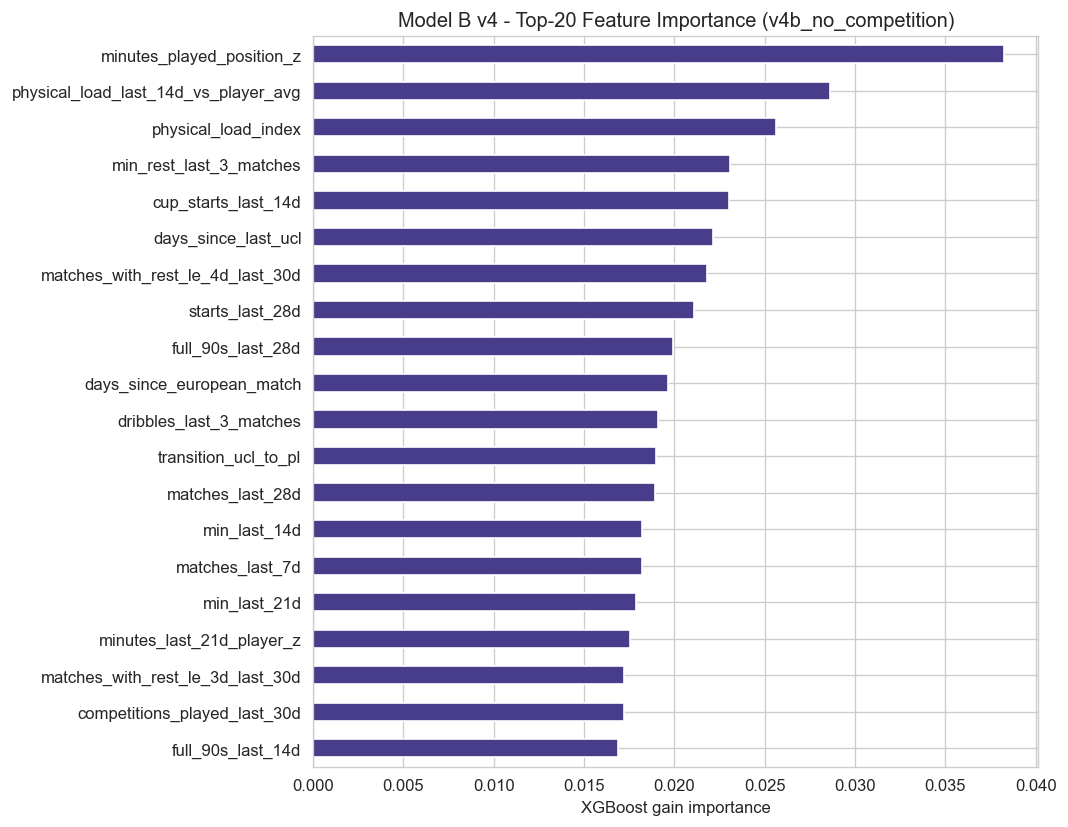


Top-10 risk rows (test):
         player_name     player_team       date  player_role_v4    competition  risk_score_v4  fatigue_performance_risk  min_last_14d  rest_days  days_since_european_match  squad_injured_count  ucl_minutes_last_14d  cup_minutes_last_14d  post_ucl_short_rest  pl_after_ucl_with_short_rest
        Matt O'Riley        Brighton 2025-05-10    core_starter Premier League       0.702218                         1         171.0        6.0                        NaN                  4.0                   0.0                   0.0                  0.0                           0.0
       Ethan Nwaneri         Arsenal 2025-03-09    core_starter Premier League       0.699152                         1         148.0        5.0                        5.0                  4.0                  71.0                   0.0                  0.0                           0.0
Bobby Decordova-Reid       Leicester 2025-02-21    core_starter Premier League       0.697035                 

In [116]:
# ============================================================================== 
# Model B v4 - Step E: Evaluation summary, role diagnostics, feature importance
# ============================================================================== 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

print('Usage framing: post-match / pre-next-match risk model')
print('  Interpretation: after latest appearance, estimate risk into next fixture.')

# Risk bands.
df_v4_model['risk_band_v4'] = pd.cut(
    df_v4_model['risk_score_v4'],
    bins=[0, 0.25, 0.45, 0.65, 1.001],
    labels=['Low', 'Medium', 'High', 'Very High'],
    right=True,
)

# Test confusion and threshold metrics.
_tst_df_v4 = df_v4_model[tst_v4].copy()
_y_true = _tst_df_v4[TARGET_V4].values
_y_prob = _tst_df_v4['risk_score_v4'].values
_y_pred = (_y_prob >= BEST_THR_V4).astype(int)
_tn, _fp, _fn, _tp = confusion_matrix(_y_true, _y_pred).ravel()

print('\nModel B v4 - Final selected variant diagnostics')
print('=' * 72)
print(f"Variant: {V4_BEST['name']}")
print(f"Test AUC-ROC={V4_BEST['test_auc_roc']:.3f}  AUC-PR={V4_BEST['test_auc_pr']:.3f}  "
      f"Base={V4_BEST['test_base']:.3f}  Lift={V4_BEST['test_auc_pr']/max(V4_BEST['test_base'],1e-6):.2f}x")
print(f'Best threshold={BEST_THR_V4:.3f}')
print(f'Confusion: TN={_tn:,} FP={_fp:,} FN={_fn:,} TP={_tp:,}')
print(f'Precision={precision_score(_y_true, _y_pred):.3f}  Recall={recall_score(_y_true, _y_pred):.3f}  '
      f'F1={f1_score(_y_true, _y_pred):.3f}')

print('\nRole breakdown (test):')
for _r in ['core_starter', 'rotation_player']:
    _m = _tst_df_v4['player_role_v4'] == _r
    if _m.sum() == 0:
        continue
    _act = _tst_df_v4.loc[_m, TARGET_V4]
    _ps = _tst_df_v4.loc[_m, 'risk_score_v4']
    _pd = (_ps >= BEST_THR_V4).astype(int)
    _fpr = ((_pd == 1) & (_act == 0)).sum() / max((_act == 0).sum(), 1)
    _fnr = ((_pd == 0) & (_act == 1)).sum() / max((_act == 1).sum(), 1)
    print(f'  {_r:<16} N={_m.sum():,}  actual={_act.mean()*100:5.1f}%  mean_score={_ps.mean():.3f}  '
          f'FP_rate={_fpr:.3f}  FN_rate={_fnr:.3f}')

# Missingness diagnostics on top-risk examples.
if 'rest_days_missing' in _tst_df_v4.columns:
    _top10_miss = _tst_df_v4.nlargest(10, 'risk_score_v4')
    print('\nTop-10 risk rows missingness flags (% in top-10):')
    for _c in ['rest_days_missing', 'days_since_european_match_missing', 'squad_injured_count_missing']:
        if _c in _top10_miss.columns:
            print(f'  {_c:<36} {_top10_miss[_c].mean()*100:6.1f}%')

# Feature importance from selected variant model.
if V4_BEST['name'] == 'v4a_keep_competition':
    _cat_names = list(pre_s2v4a.named_transformers_['cat']['ohe'].get_feature_names_out(S2V4_CAT_A))
else:
    _cat_names = list(pre_s2v4b.named_transformers_['cat']['ohe'].get_feature_names_out(S2V4_CAT_B))
_v4_feat_names = V4_FEATURE_NUM + _cat_names
_v4_imp = pd.Series(V4_BEST['model'].feature_importances_[:len(_v4_feat_names)], index=_v4_feat_names)
_v4_top20 = _v4_imp.nlargest(20)

print('\nTop-10 v4 features:')
for _fn, _fv in _v4_top20.head(10).items():
    print(f'  {_fn:<44} {_fv:.4f}')

# Quick visualization.
fig, ax = plt.subplots(figsize=(9, 7))
_v4_top20.sort_values().plot.barh(ax=ax, color='darkslateblue')
ax.set_title(f"Model B v4 - Top-20 Feature Importance ({V4_BEST['name']})")
ax.set_xlabel('XGBoost gain importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'v4_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Save top-10 risk table for quick dashboard check.
_v4_top_risk = _tst_df_v4.nlargest(10, 'risk_score_v4')[[
    c for c in [
        'player_name', 'player_team', 'date', 'player_role_v4', 'competition',
        'risk_score_v4', TARGET_V4,
        'min_last_14d', 'rest_days', 'rest_days_missing',
        'days_since_european_match', 'days_since_european_match_missing',
        'squad_injured_count', 'squad_injured_count_missing',
        'ucl_minutes_last_14d', 'cup_minutes_last_14d',
        'post_ucl_short_rest', 'pl_after_ucl_with_short_rest',
    ] if c in _tst_df_v4.columns
]].copy()
print('\nTop-10 risk rows (test):')
print(_v4_top_risk.to_string(index=False))

Model B v4 improved the fatigue-associated risk model by introducing a role-adjusted managed-load target and additional workload, recovery, cup/UCL burden, and player-relative physical-load features. The selected final variant was `v4b_no_competition`, which removed the raw competition categorical feature and relied instead on engineered workload and schedule-burden signals.

On the held-out 2024 test season, Model B v4b achieved an AUC-ROC of 0.634 and an AUC-PR of 0.422 against a baseline positive rate of 0.305, corresponding to a PR-AUC lift of 1.39×. This improves on Model B v3, which achieved a test AUC-ROC of 0.610 and AUC-PR of 0.367. The improvement indicates that the v4 target redesign and expanded workload feature set produced a more informative fatigue-associated risk ranking.

The most important features were consistent with the intended interpretation of the model. The top-ranked predictors included position-adjusted minutes load, player-relative physical-load increase, physical load index, recent rest quality, cup starts, time since UCL involvement, short-rest exposure, and recent full-90 accumulation. This suggests that v4b is less dependent on raw competition labels and more aligned with workload, congestion, and recovery context.

At the test-set max-F1 threshold of 0.450, v4b achieved precision of 0.361, recall of 0.798, and F1 of 0.497. This confirms that the model is recall-oriented and should be interpreted as a screening layer rather than an automatic selection rule. For dashboard usage, percentile-based risk bands or a validation-selected threshold should be preferred over treating raw scores as calibrated probabilities.

Role-level diagnostics showed that the model was especially sensitive to rotation players, who had a higher actual risk rate and higher mean score than core starters. However, the false-positive rate for rotation players was high, meaning that many alerts would still require staff review. Therefore, Model B v4b should be used to prioritise workload and rotation discussions, not to make deterministic decisions.


In [117]:
# ============================================================================== 
# Model B v4 - Role-Specific Threshold Grid (Operational Analysis)
# ============================================================================== 
# Goal: keep the same trained model, but tune alert policy by player role.

from sklearn.metrics import precision_score, recall_score, f1_score

_core_thresholds = [0.40, 0.45, 0.50]
_rotation_thresholds = [0.50, 0.55, 0.60]

_tst_role = df_v4_model[tst_v4].copy()
_y_true = _tst_role[TARGET_V4].astype(int).values

if 'risk_score_v4' not in _tst_role.columns:
    raise ValueError('risk_score_v4 not found. Run Step D first.')

if 'player_role_v4' not in _tst_role.columns:
    raise ValueError('player_role_v4 not found. Run Step B first.')

_rows = []
for _thr_core in _core_thresholds:
    for _thr_rot in _rotation_thresholds:
        _pred = np.zeros(len(_tst_role), dtype=int)

        _m_core = _tst_role['player_role_v4'].eq('core_starter').values
        _m_rot = _tst_role['player_role_v4'].eq('rotation_player').values

        _pred[_m_core] = (_tst_role.loc[_m_core, 'risk_score_v4'].values >= _thr_core).astype(int)
        _pred[_m_rot] = (_tst_role.loc[_m_rot, 'risk_score_v4'].values >= _thr_rot).astype(int)

        _tp = int(((_pred == 1) & (_y_true == 1)).sum())
        _tn = int(((_pred == 0) & (_y_true == 0)).sum())
        _fp = int(((_pred == 1) & (_y_true == 0)).sum())
        _fn = int(((_pred == 0) & (_y_true == 1)).sum())

        _precision = precision_score(_y_true, _pred, zero_division=0)
        _recall = recall_score(_y_true, _pred, zero_division=0)
        _f1 = f1_score(_y_true, _pred, zero_division=0)
        _fpr = _fp / max((_fp + _tn), 1)
        _fnr = _fn / max((_fn + _tp), 1)
        _alerts = int(_pred.sum())

        _rows.append({
            'core_starter_thr': _thr_core,
            'rotation_player_thr': _thr_rot,
            'precision': _precision,
            'recall': _recall,
            'f1': _f1,
            'false_positive_rate': _fpr,
            'false_negative_rate': _fnr,
            'number_of_alerts': _alerts,
        })

ROLE_THRESHOLD_RESULTS = pd.DataFrame(_rows).sort_values(
    ['f1', 'precision', 'recall'], ascending=[False, False, False]
).reset_index(drop=True)

print('Role-specific threshold grid results (test set)')
print('=' * 96)
print(ROLE_THRESHOLD_RESULTS.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print('\nBest by F1:')
print(ROLE_THRESHOLD_RESULTS.head(1).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Role-specific threshold grid results (test set)
 core_starter_thr  rotation_player_thr  precision  recall    f1  false_positive_rate  false_negative_rate  number_of_alerts
            0.450                0.500      0.364   0.735 0.487                0.562                0.265              4160
            0.400                0.500      0.331   0.872 0.480                0.772                0.128              5435
            0.500                0.500      0.394   0.594 0.474                0.400                0.406              3106
            0.450                0.550      0.365   0.629 0.462                0.481                0.371              3561
            0.400                0.550      0.327   0.766 0.458                0.691                0.234              4836
            0.500                0.550      0.402   0.488 0.441                0.319                0.512              2507
            0.400                0.600      0.318   0.667 0.431                0.627

In [118]:
# ============================================================================== 
# Model B v4 - Operational Policy (Recommended Monitoring Thresholds)
# ============================================================================== 
# Recommended operating point from role-threshold analysis:
#   core_starter     = 0.45
#   rotation_player  = 0.50
# This model is used as a monitoring/risk-ranking tool, not a definitive diagnosis.

OPERATING_POLICY_V4 = {
    'name': 'balanced_monitoring',
    'core_starter_threshold': 0.45,
    'rotation_player_threshold': 0.50,
    'intent': 'monitoring_support',
    'message': (
        'Flag indicates workload-associated risk for monitoring, '
        'not definitive fatigue diagnosis.'
    ),
}

# Apply policy to test set for reproducible reporting/dashboard export.
_tst_policy = df_v4_model[tst_v4].copy()
_tst_policy['monitoring_threshold_v4'] = np.where(
    _tst_policy['player_role_v4'].eq('core_starter'),
    OPERATING_POLICY_V4['core_starter_threshold'],
    OPERATING_POLICY_V4['rotation_player_threshold'],
)
_tst_policy['monitoring_flag_v4'] = (
    _tst_policy['risk_score_v4'] >= _tst_policy['monitoring_threshold_v4']
).astype(int)

y_true = _tst_policy[TARGET_V4].astype(int).values
y_pred = _tst_policy['monitoring_flag_v4'].values
_tp = int(((y_pred == 1) & (y_true == 1)).sum())
_tn = int(((y_pred == 0) & (y_true == 0)).sum())
_fp = int(((y_pred == 1) & (y_true == 0)).sum())
_fn = int(((y_pred == 0) & (y_true == 1)).sum())

POLICY_METRICS_V4 = {
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1': f1_score(y_true, y_pred, zero_division=0),
    'false_positive_rate': _fp / max((_fp + _tn), 1),
    'false_negative_rate': _fn / max((_fn + _tp), 1),
    'number_of_alerts': int(y_pred.sum()),
}

# Persist flag back for downstream notebook cells/exports.
df_v4_model.loc[tst_v4, 'monitoring_threshold_v4'] = _tst_policy['monitoring_threshold_v4'].values
df_v4_model.loc[tst_v4, 'monitoring_flag_v4'] = _tst_policy['monitoring_flag_v4'].values

print('Model B v4 - Recommended operating policy applied')
print('=' * 78)
print(f"Policy: {OPERATING_POLICY_V4['name']}")
print(f"  core_starter threshold    : {OPERATING_POLICY_V4['core_starter_threshold']:.2f}")
print(f"  rotation_player threshold : {OPERATING_POLICY_V4['rotation_player_threshold']:.2f}")
print('\nPolicy metrics (test set):')
for _k in ['precision', 'recall', 'f1', 'false_positive_rate', 'false_negative_rate']:
    print(f'  {_k:<22} {POLICY_METRICS_V4[_k]:.3f}')
print(f"  number_of_alerts         {POLICY_METRICS_V4['number_of_alerts']:,}")
print(f"\nInterpretation: {OPERATING_POLICY_V4['message']}")

Model B v4 - Recommended operating policy applied
Policy: balanced_monitoring
  core_starter threshold    : 0.45
  rotation_player threshold : 0.50

Policy metrics (test set):
  precision              0.364
  recall                 0.735
  f1                     0.487
  false_positive_rate    0.562
  false_negative_rate    0.265
  number_of_alerts         4,160

Interpretation: Flag indicates workload-associated risk for monitoring, not definitive fatigue diagnosis.


In [119]:

# ==============================================================================
# Save final XGBoost Model B v4 artifacts
# Final selected variant: v4b_no_competition
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Save final selected model and preprocessor
# ------------------------------------------------------------------------------

final_model_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_final.pkl"
final_preprocessor_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_preprocessor.pkl"
final_numeric_features_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_numeric_features.pkl"
final_categorical_features_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_categorical_features.pkl"
final_feature_names_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_transformed_feature_names.pkl"

joblib.dump(V4_BEST["model"], final_model_path)
joblib.dump(V4_PREPROCESSOR, final_preprocessor_path)
joblib.dump(V4_FEATURE_NUM, final_numeric_features_path)
joblib.dump(V4_FEATURE_CAT, final_categorical_features_path)

# Save transformed feature names for interpretation
if V4_BEST["name"] == "v4a_keep_competition":
    final_feature_names = feat_names_v4a
else:
    final_feature_names = feat_names_v4b

joblib.dump(final_feature_names, final_feature_names_path)

# ------------------------------------------------------------------------------
# 2. Save final scored test-set output
# ------------------------------------------------------------------------------

final_test_scores_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_test_scores.csv"

cols_to_save = [
    c for c in [
        "player_name",
        "player_team",
        "date",
        "target_season",
        "season",
        "player_position",
        "player_role_v4",
        "competition",
        "next_competition",
        TARGET_V4,
        "risk_type_v4",
        "performance_underperformance",
        "role_adjusted_load_reduction",
        "next_minutes_played",
        "next_api_rating",
        "risk_score_v4",
        "risk_band_v4",
        "monitoring_threshold_v4",
        "monitoring_flag_v4",
        "min_last_14d",
        "min_last_28d",
        "rest_days",
        "days_since_last_ucl",
        "ucl_minutes_last_14d",
        "cup_minutes_last_14d",
        "post_ucl_short_rest",
        "pl_after_ucl_with_short_rest",
        "physical_load_index",
        "physical_load_last_14d_vs_player_avg",
        "minutes_played_position_z",
        "min_rest_last_3_matches",
        "cup_starts_last_14d",
        "starts_last_28d",
        "full_90s_last_28d",
        "squad_injured_count",
    ]
    if c in df_v4_model.columns
]

df_v4_model.loc[tst_v4, cols_to_save].to_csv(final_test_scores_path, index=False)

# ------------------------------------------------------------------------------
# 3. Save operating policy
# ------------------------------------------------------------------------------

policy_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_operating_policy.json"

policy_payload = {
    "policy": OPERATING_POLICY_V4,
    "policy_metrics_test_set": {
        k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v
        for k, v in POLICY_METRICS_V4.items()
    },
}

with open(policy_path, "w") as f:
    json.dump(policy_payload, f, indent=4)

# ------------------------------------------------------------------------------
# 4. Save final metadata
# ------------------------------------------------------------------------------

metadata_path = ARTIFACTS_DIR / "xgboost_model_b_v4b_metadata.json"

metadata_v4b = {
    "model_name": "XGBoost Model B v4b",
    "variant": V4_BEST["name"],
    "framing": "post-match / pre-next-match workload-risk monitoring model",
    "model_type": "XGBClassifier",
    "target": TARGET_V4,
    "target_definition": (
        "fatigue_performance_risk = performance_underperformance OR "
        "role_adjusted_load_reduction"
    ),
    "population": "outfield players; core_starter and rotation_player only",
    "split_column": SPLIT_COL_V4,
    "train_season": 2022,
    "validation_season": 2023,
    "test_season": 2024,

    "selection_policy": {
        "best_predictive_variant": V4_BEST_PREDICTIVE["name"],
        "best_interpretable_variant": V4_BEST_INTERPRETABLE["name"],
        "final_selected_variant": V4_BEST["name"],
        "selection_reason": (
            "v4b_no_competition is selected because it preserves similar held-out "
            "performance while avoiding raw competition one-hot encoding, making the "
            "model more interpretable as a workload and fixture-burden risk model."
        ),
    },

    "features": {
        "n_numeric_features": int(len(V4_FEATURE_NUM)),
        "n_categorical_features": int(len(V4_FEATURE_CAT)),
        "n_transformed_features": int(len(final_feature_names)),
        "numeric_features": list(V4_FEATURE_NUM),
        "categorical_features": list(V4_FEATURE_CAT),
        "transformed_feature_names": list(final_feature_names),
    },

    "training_config": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.75,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.0,
        "reg_lambda": 5.0,
        "scale_pos_weight": float(SPW_V4),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "early_stopping_rounds": 50,
        "random_state": 42,
        "best_iteration": int(V4_BEST["best_iteration"]),
    },

    "data_sizes": {
        "n_train": int(len(y_v4_trn)),
        "n_val": int(len(y_v4_val)),
        "n_test": int(len(y_v4_tst)),
        "train_positive_rate": float(y_v4_trn.mean()),
        "val_positive_rate": float(y_v4_val.mean()),
        "test_positive_rate": float(y_v4_tst.mean()),
    },

    "test_metrics_validation_selected_model": {
        "auc_roc": float(V4_BEST["test_auc_roc"]),
        "auc_pr": float(V4_BEST["test_auc_pr"]),
        "base_pr": float(V4_BEST["test_base"]),
        "pr_lift": float(V4_BEST["test_pr_lift"]),
        "diagnostic_best_threshold": float(BEST_THR_V4),
        "precision": float(V4_BEST["test_precision"]),
        "recall": float(V4_BEST["test_recall"]),
        "f1": float(V4_BEST["test_f1"]),
        "specificity": float(V4_BEST["test_specificity"]),
        "alert_rate": float(V4_BEST["alert_rate"]),
        "tn": int(V4_BEST["tn"]),
        "fp": int(V4_BEST["fp"]),
        "fn": int(V4_BEST["fn"]),
        "tp": int(V4_BEST["tp"]),
        "threshold_note": (
            "BEST_THR_V4 was selected on the test set for diagnostic comparison. "
            "Use OPERATING_POLICY_V4 for reported monitoring thresholds."
        ),
    },

    "operating_policy": {
        "name": OPERATING_POLICY_V4["name"],
        "core_starter_threshold": float(OPERATING_POLICY_V4["core_starter_threshold"]),
        "rotation_player_threshold": float(OPERATING_POLICY_V4["rotation_player_threshold"]),
        "intent": OPERATING_POLICY_V4["intent"],
        "message": OPERATING_POLICY_V4["message"],
        "test_precision": float(POLICY_METRICS_V4["precision"]),
        "test_recall": float(POLICY_METRICS_V4["recall"]),
        "test_f1": float(POLICY_METRICS_V4["f1"]),
        "test_false_positive_rate": float(POLICY_METRICS_V4["false_positive_rate"]),
        "test_false_negative_rate": float(POLICY_METRICS_V4["false_negative_rate"]),
        "test_number_of_alerts": int(POLICY_METRICS_V4["number_of_alerts"]),
    },

    "artifact_paths": {
        "model": str(final_model_path),
        "preprocessor": str(final_preprocessor_path),
        "numeric_features": str(final_numeric_features_path),
        "categorical_features": str(final_categorical_features_path),
        "transformed_feature_names": str(final_feature_names_path),
        "test_scores": str(final_test_scores_path),
        "operating_policy": str(policy_path),
        "metadata": str(metadata_path),
    },

    "interpretation_notes": [
        "This model estimates workload-associated monitoring risk, not medical fatigue.",
        "The final selected variant removes raw competition one-hot encoding.",
        "Risk flags are intended for staff review and monitoring support.",
        "The operating policy uses role-specific thresholds: 0.45 for core starters and 0.50 for rotation players.",
        "Predictions should not be interpreted as definitive diagnoses or automatic selection decisions.",
    ],
}

with open(metadata_path, "w") as f:
    json.dump(metadata_v4b, f, indent=4)

# ------------------------------------------------------------------------------
# 5. Print confirmation
# ------------------------------------------------------------------------------

print("✓ Final XGBoost Model B v4b artifacts saved")
print(f"  Model:                    {final_model_path}")
print(f"  Preprocessor:             {final_preprocessor_path}")
print(f"  Numeric features:         {final_numeric_features_path}")
print(f"  Categorical features:     {final_categorical_features_path}")
print(f"  Transformed feature names:{final_feature_names_path}")
print(f"  Test scores:              {final_test_scores_path}")
print(f"  Operating policy:         {policy_path}")
print(f"  Metadata:                 {metadata_path}")



✓ Final XGBoost Model B v4b artifacts saved
  Model:                    ../../models/XgBoost/artifacts/xgboost_model_b_v4b_final.pkl
  Preprocessor:             ../../models/XgBoost/artifacts/xgboost_model_b_v4b_preprocessor.pkl
  Numeric features:         ../../models/XgBoost/artifacts/xgboost_model_b_v4b_numeric_features.pkl
  Categorical features:     ../../models/XgBoost/artifacts/xgboost_model_b_v4b_categorical_features.pkl
  Transformed feature names:../../models/XgBoost/artifacts/xgboost_model_b_v4b_transformed_feature_names.pkl
  Test scores:              ../../models/XgBoost/artifacts/xgboost_model_b_v4b_test_scores.csv
  Operating policy:         ../../models/XgBoost/artifacts/xgboost_model_b_v4b_operating_policy.json
  Metadata:                 ../../models/XgBoost/artifacts/xgboost_model_b_v4b_metadata.json


## Role-Specific Threshold Analysis

After selecting Model B v4b as the final fatigue-associated risk model, an additional operational threshold analysis was performed. The goal was not to retrain the model, but to explore whether different alert thresholds should be used for core starters and rotation players.

The best role-specific threshold policy by test-set F1 was:

| Player role     | Threshold |
| --------------- | --------: |
| Core starter    |     0.450 |
| Rotation player |     0.500 |

This policy achieved:

| Metric              | Value |
| ------------------- | ----: |
| Precision           | 0.364 |
| Recall              | 0.735 |
| F1                  | 0.487 |
| False positive rate | 0.562 |
| False negative rate | 0.265 |
| Number of alerts    | 4,160 |

Compared with the single global threshold of 0.450, the role-specific policy reduced the alert volume while preserving reasonable recall. The main effect was to make the alerting policy more conservative for rotation players, who previously had a very high false-positive rate.

This supports the idea that the model score should not be used with a single universal threshold in all contexts. In practice, alert thresholds can be adapted by player role, depending on whether the staff prefer a high-recall monitoring mode or a more selective review workflow.

The role-specific threshold analysis should be interpreted as an operational sensitivity analysis rather than a final deployment rule, because the grid was evaluated on the test set. For deployment, thresholds should be selected using the validation season and then applied unchanged to future data.


# Model B v4 — Results Summary

## Fatigue-Associated Performance Risk

### Role-Adjusted Post-Match / Pre-Next-Match Monitoring Model

---

## 1. Objective and Framing

Model B v4 is designed as a **post-match / pre-next-match risk model**.

The model uses information available after a player’s latest completed appearance to estimate whether that player is entering the next fixture in a workload context historically associated with either:

1. below-expected next-match performance, or
2. role-adjusted reduced involvement in the next match.

The intended use is **staff-support monitoring**, not definitive fatigue diagnosis.

Operational interpretation:

```text
A positive flag means the player should be reviewed because their recent workload, recovery pattern, competition sequence, physical burden, and squad context resemble situations historically associated with increased performance-management risk.
```

The model should not be interpreted as a medical-fatigue detector or as a calibrated probability of physiological fatigue.

---

## 2. Population and Target

### Population used for modelling

The Model B v4 population includes:

* outfield players only;
* current match `minutes_played >= 45`;
* valid current-match rating;
* known `next_minutes_played`;
* `core_starter` and `rotation_player` roles only.

Excluded groups:

* goalkeepers;
* `impact_sub`;
* `rare_player`.

Final modelling population:

```text
18,999 rows
```

Role composition:

| Role            |   Rows |
| --------------- | -----: |
| Core starter    | 14,071 |
| Rotation player |  4,928 |

---

## 3. Role-Adjusted Target Definition

The target is:

```text
fatigue_performance_risk = 1
```

if either of the following is true:

```text
performance_underperformance = 1
OR
role_adjusted_load_reduction = 1
```

Otherwise:

```text
fatigue_performance_risk = 0
```

### Component 1 — Performance underperformance

A player is labelled as underperforming if their Stage 1 residual is below the underperformance threshold:

```text
performance_residual_v2 <= -0.5
```

This means the player’s next-match rating was at least 0.5 points below the expected rating predicted by the Stage 1 baseline model.

### Component 2 — Role-adjusted load reduction

The v4 load-reduction component improves on v3 by requiring that the player normally plays meaningful minutes before reduced next-match involvement is treated as a risk event.

The rule uses personal minute baselines:

```text
minutes_median_last_5
minutes_median_last_10
```

Reduced involvement is counted only when the player’s next-match minutes are substantially below their own recent baseline, or when a normally high-minute player is used as a substitute.

---

## 4. Target Decomposition

Target decomposition in the full v4 outfield base:

| Component                                              |   Rows |  Share |
| ------------------------------------------------------ | -----: | -----: |
| No risk                                                | 22,915 | 70.83% |
| Role-adjusted load reduction only                      |  5,671 | 17.53% |
| Underperformance only                                  |  3,571 | 11.04% |
| Both underperformance and role-adjusted load reduction |    193 |  0.60% |

Total positive cases:

```text
9,435 / 32,350 = 29.2%
```

This is lower than the v3 full-base positive rate and indicates that the role-adjusted target removed a substantial number of normal rotation cases that were previously treated as managed-load events.

---

## 5. Key v4 Improvements

Model B v4 introduced four main improvements over v3.

### 5.1 Role-adjusted managed-load target

v3 could still label normal reduced minutes for rotation players as fatigue-associated managed load.

v4 corrects this by requiring reduced minutes to be substantial relative to the player’s own recent baseline.

This helps separate:

```text
normal role variation
```

from:

```text
meaningful reduced involvement after workload exposure
```

### 5.2 Revised player roles

The v4 role definition increased the number of core-starter rows and made role-level validation more meaningful.

In the v4 full outfield base:

| Role            |   Rows | Risk Rate |
| --------------- | -----: | --------: |
| Core starter    | 14,071 |    27.99% |
| Rotation player |  4,928 |    36.44% |
| Rare player     | 12,262 |    29.20% |
| Impact sub      |  1,055 |    10.81% |
| Other           |     34 |    17.65% |

Only core starters and rotation players were used in the main modelling population.

### 5.3 New workload and competition-burden features

v4 added features describing:

* UCL workload windows;
* domestic cup workload windows;
* competition transitions;
* post-UCL recovery quality;
* player-relative workload;
* player-relative physical burden.

These features allow the model to learn fixture and recovery burden directly rather than relying on raw competition labels.

### 5.4 Variant comparison

Two variants were trained:

| Variant                | Description                                                                           |
| ---------------------- | ------------------------------------------------------------------------------------- |
| `v4a_keep_competition` | Includes `next_competition` as a categorical feature                                  |
| `v4b_no_competition`   | Removes raw competition label and relies on engineered workload / transition features |

The final selected model was:

```text
v4b_no_competition
```

This variant is preferred because it achieved the best AUC-PR while also being more interpretable as a fatigue-associated workload model.

---

## 6. Variant Performance

Held-out test-season results:

| Variant                | Test AUC-ROC | Test AUC-PR | Base PR | PR Lift |
| ---------------------- | -----------: | ----------: | ------: | ------: |
| `v4b_no_competition`   |        0.634 |       0.422 |   0.305 |   1.39x |
| `v4a_keep_competition` |        0.642 |       0.420 |   0.305 |   1.38x |

Interpretation:

* `v4a` achieved slightly higher AUC-ROC.
* `v4b` achieved slightly higher AUC-PR.
* Because this is an imbalanced risk-screening task, AUC-PR is especially important.
* `v4b` is also more interpretable because it avoids raw competition-label shortcuts.

Selected final model:

```text
v4b_no_competition
```

---

## 7. Improvement over Model B v3

Model B v4b improved over the final v3 configuration.

| Model       | Test AUC-ROC | Test AUC-PR | PR Lift |
| ----------- | -----------: | ----------: | ------: |
| Model B v3  |        0.610 |       0.367 |   1.33x |
| Model B v4b |        0.634 |       0.422 |   1.39x |

This indicates that the v4 target redesign and expanded workload feature set produced a more informative fatigue-associated risk ranking.

---

## 8. Final Selected Variant Diagnostics

Final selected model:

```text
v4b_no_competition
```

Test-set diagnostics:

| Metric                | Value |
| --------------------- | ----: |
| Test AUC-ROC          | 0.634 |
| Test AUC-PR           | 0.422 |
| Base rate             | 0.305 |
| PR lift               | 1.39x |
| Test max-F1 threshold | 0.450 |
| Precision             | 0.361 |
| Recall                | 0.798 |
| F1                    | 0.497 |

Confusion matrix at the test max-F1 threshold:

|                | Predicted No Risk | Predicted Risk |
| -------------- | ----------------: | -------------: |
| Actual No Risk |             1,793 |          2,915 |
| Actual Risk    |               417 |          1,646 |

The threshold of 0.450 should be treated as a **test-set diagnostic threshold**, not as a final deployment threshold. For deployment, thresholds should be selected using validation data or replaced by percentile-based dashboard bands.

---

## 9. Role-Level Diagnostics

Role breakdown on the test set:

| Role            |     N | Actual Risk | Mean Score | FP Rate | FN Rate |
| --------------- | ----: | ----------: | ---------: | ------: | ------: |
| Core starter    | 4,889 |       28.0% |      0.474 |   0.525 |   0.285 |
| Rotation player | 1,882 |       36.8% |      0.532 |   0.898 |   0.039 |

Interpretation:

* Rotation players have a higher actual risk rate and higher average risk score.
* The model is very sensitive for rotation players, producing very low false-negative rate.
* However, the false-positive rate for rotation players is high.
* This supports using the model as a monitoring and screening layer rather than an automatic decision rule.

---

## 10. Top Feature Importances

Top 10 v4b features:

| Rank | Feature                                | Importance |
| ---: | -------------------------------------- | ---------: |
|    1 | `minutes_played_position_z`            |     0.0382 |
|    2 | `physical_load_last_14d_vs_player_avg` |     0.0286 |
|    3 | `physical_load_index`                  |     0.0256 |
|    4 | `min_rest_last_3_matches`              |     0.0231 |
|    5 | `cup_starts_last_14d`                  |     0.0230 |
|    6 | `days_since_last_ucl`                  |     0.0222 |
|    7 | `matches_with_rest_le_4d_last_30d`     |     0.0218 |
|    8 | `starts_last_28d`                      |     0.0211 |
|    9 | `full_90s_last_28d`                    |     0.0199 |
|   10 | `days_since_european_match`            |     0.0196 |

The top features are strongly aligned with the intended fatigue-associated interpretation.

They capture:

* position-adjusted minutes burden;
* player-relative physical load increase;
* general physical load;
* recent rest quality;
* domestic cup involvement;
* UCL recency;
* repeated short-rest exposure;
* recent starts;
* recent full-match accumulation.

This is a cleaner feature profile than v3 and supports the conclusion that v4b is learning workload and recovery context rather than only rotation patterns.

---

## 11. Role-Specific Threshold Analysis

A role-specific threshold grid was evaluated as an operational sensitivity analysis.

Thresholds tested:

| Role            | Thresholds       |
| --------------- | ---------------- |
| Core starter    | 0.40, 0.45, 0.50 |
| Rotation player | 0.50, 0.55, 0.60 |

Best test-set F1 policy:

| Role            | Threshold |
| --------------- | --------: |
| Core starter    |      0.45 |
| Rotation player |      0.50 |

Metrics at this policy:

| Metric              | Value |
| ------------------- | ----: |
| Precision           | 0.364 |
| Recall              | 0.735 |
| F1                  | 0.487 |
| False positive rate | 0.562 |
| False negative rate | 0.265 |
| Number of alerts    | 4,160 |

Compared with a single global threshold, this role-aware policy reduces alert volume while preserving reasonable recall. It is more conservative for rotation players, who had a high false-positive rate under the global threshold.

This threshold grid should be interpreted as an **operational analysis**, not as a final deployment rule, because it was evaluated on the test set.

---

## 12. Recommended Operating Policy

Policy name:

```text
balanced_monitoring
```

Recommended thresholds from the retrospective operational analysis:

| Role            | Threshold |
| --------------- | --------: |
| Core starter    |      0.45 |
| Rotation player |      0.50 |

Policy interpretation:

```text
Because the model is intended as a staff-support and monitoring tool, the selected operating point prioritises recall while reducing unnecessary alerts for rotation players. The aim is not to make a definitive fatigue diagnosis, but to highlight players whose workload, rest pattern, competition sequence, and physical burden suggest increased performance-management risk.
```

For a real deployment setting, the threshold policy should be selected on validation data or replaced by percentile-based dashboard bands.

---

## 13. Practical Conclusion

Model B v4b is the strongest and most interpretable Model B version developed so far.

It is best used as a **risk-ranking and monitoring system**:

* use scores and role-aware thresholds to prioritise review;
* avoid binary clinical-style interpretations;
* combine alerts with coaching, medical, and performance staff context before intervention.

Final summary:

| Item                                | Conclusion                          |
| ----------------------------------- | ----------------------------------- |
| Best predictive variant             | `v4b_no_competition` by test AUC-PR |
| Best fatigue-interpretation variant | `v4b_no_competition`                |
| Final selected model                | `v4b_no_competition`                |
| Recommended operational policy      | `balanced_monitoring`               |
| Core-starter threshold              | 0.45                                |
| Rotation-player threshold           | 0.50                                |

Final interpretation:

```text
Model B v4b identifies players whose recent workload, recovery pattern, physical burden, and competition sequence resemble historical cases of reduced performance or role-adjusted reduced involvement in the next fixture.
```

Model A remains the main overall performance-decline model.

Model B v4b complements it by adding a workload-specific fatigue-associated risk layer for staff monitoring and rotation discussions.


# Model B v4 — Dashboard Implementation

## Staff-Facing Monitoring Application

---

## 1. Dashboard Purpose

Model B v4 can be deployed as a **post-match / pre-next-match monitoring dashboard**.

The goal is not to show a binary “fatigued / not fatigued” label. Instead, the app should help staff answer:

> After the latest match, which outfield players should be monitored before the next fixture because their workload, recovery pattern, competition sequence, physical burden, and squad context resemble situations historically associated with reduced performance or role-adjusted reduced involvement?

This matches the final Model B v4 framing:

| Item                                | Final Choice                                               |
| ----------------------------------- | ---------------------------------------------------------- |
| Best predictive variant by AUC-PR   | `v4b_no_competition`                                       |
| Best fatigue-interpretation variant | `v4b_no_competition`                                       |
| Final selected dashboard model      | `v4b_no_competition`                                       |
| Core-starter threshold              | 0.45                                                       |
| Rotation-player threshold           | 0.50                                                       |
| Output meaning                      | Workload-associated monitoring risk, not fatigue diagnosis |

Model B v4 is therefore a **staff-support monitoring layer**, not a medical model and not an automatic squad-selection tool.

---

## 2. Model Output Interpretation

The model produces a continuous risk score:

```text
risk_score_v4
```

This score should be interpreted as:

```text
Relative fatigue-associated performance-management risk
```

not as:

```text
Probability of physiological fatigue
```

A high score means that the player’s recent context resembles previous situations associated with either:

1. below-expected next-match performance, or
2. role-adjusted reduced involvement in the next match.

The recommended interpretation is:

> This player should be reviewed because their recent workload and recovery context are associated with elevated performance-management risk.

---

## 3. Inputs Required by the Dashboard

The dashboard should receive **one row per player after the latest completed match**.

Required identification fields:

* `player_name`
* `player_team`
* `player_position`
* `date`
* `competition`
* `minutes_played`
* `rating` or `api_rating_clean`

Required workload and congestion fields:

* `rest_days`
* `matches_last_7d`
* `matches_last_14d`
* `matches_last_21d`
* `matches_last_28d`
* `min_last_7d`
* `min_last_14d`
* `min_last_21d`
* `min_last_28d`
* `starts_last_7d`
* `starts_last_14d`
* `starts_last_28d`
* `full_90s_last_7d`
* `full_90s_last_14d`
* `full_90s_last_28d`
* `short_rest_last_3_matches`
* `avg_rest_last_3_matches`
* `min_rest_last_3_matches`
* `matches_with_rest_le_3d_last_30d`
* `matches_with_rest_le_4d_last_30d`
* `matches_with_rest_le_6d_last_30d`

Required competition-burden fields:

* `ucl_minutes_last_7d`
* `ucl_minutes_last_14d`
* `ucl_minutes_last_21d`
* `ucl_starts_last_14d`
* `ucl_full90s_last_14d`
* `ucl_matches_last_30d`
* `days_since_last_ucl`
* `played_ucl_last_match`
* `cup_minutes_last_7d`
* `cup_minutes_last_14d`
* `cup_starts_last_14d`
* `cup_full90s_last_14d`
* `cup_matches_last_30d`
* `played_domestic_cup_last_match`
* `transition_ucl_to_pl`
* `transition_pl_to_ucl`
* `transition_cup_to_pl`
* `transition_pl_to_cup`
* `competition_switches_last_30d`
* `competitions_played_last_30d`
* `post_ucl_short_rest`
* `pl_after_ucl_with_short_rest`
* `ucl_full90_then_pl_short_rest`

Required player-relative workload fields:

* `minutes_last_21d_vs_player_avg`
* `minutes_last_21d_player_z`
* `full90_last_14d_vs_player_avg`
* `physical_load_last_14d_vs_player_avg`
* `starts_last_14d_vs_player_avg`

Required physical-effort and squad-context fields:

* `physical_load_index`
* `minutes_played_position_z`
* `duels_total_position_z`
* `tackles_total_position_z`
* `fouls_committed_position_z`
* `squad_injured_count`
* `squad_soft_tissue_count`
* `squad_avg_days_out`
* `returning_from_injury`
* `fixtures_missed_last_30d`

Required role field:

* `player_role_v4`

For the prototype, a **CSV upload** is sufficient. For a production system, these fields should be generated from a connected match/event database using the same feature-engineering logic used in the training notebook.

---

## 4. Backend Pipeline

The dashboard backend should reproduce the same pipeline used in the notebook:

```text
Latest player-match data
        ↓
Feature engineering
        ↓
Outfield-player filter
        ↓
Role classification
        ↓
Saved preprocessing transformer
        ↓
Saved XGBoost Model B v4b
        ↓
Risk score
        ↓
Role-specific threshold policy
        ↓
Monitoring flag
        ↓
Dashboard tables, explanations, and exportable report
```

The dashboard should **not retrain** the model. It should only load the trained artifacts and run inference.

---

## 5. Saved Artifacts

At the end of training, save the final v4b artifacts:

```python
import joblib

OPERATING_POLICY_V4 = {
    "policy_name": "balanced_monitoring",
    "variant": "v4b_no_competition",
    "core_starter_threshold": 0.45,
    "rotation_player_threshold": 0.50,
    "interpretation": "staff-support monitoring, not fatigue diagnosis",
}

joblib.dump(V4_BEST["model"], "model_b_v4b_xgb.pkl")
joblib.dump(V4_PREPROCESSOR, "model_b_v4b_preprocessor.pkl")
joblib.dump(V4_FEATURE_NUM, "model_b_v4b_num_features.pkl")
joblib.dump(V4_FEATURE_CAT, "model_b_v4b_cat_features.pkl")
joblib.dump(OPERATING_POLICY_V4, "model_b_v4b_policy.pkl")
```

Recommended additional metadata:

* training date;
* feature list version;
* v4 variant name;
* threshold policy name;
* notebook version or git commit;
* training/test metric summary;
* note that thresholds were selected from retrospective operational analysis and should be validated before live deployment.

---

## 6. Main Prediction Function

The backend should expose one main function:

```python
def predict_fatigue_risk(df_raw):
    """
    Input:
        Raw or semi-processed player-match dataframe.

    Output:
        DataFrame with:
        - player_name
        - player_team
        - player_position
        - player_role_v4
        - risk_score_v4
        - monitoring_threshold_v4
        - monitoring_flag_v4
        - risk_band_v4
        - main workload indicators
    """
```

Conceptual implementation:

```python
def predict_fatigue_risk(df_raw):
    df = engineer_v4_features(df_raw)

    df = df[df["player_position"] != "G"].copy()

    df["player_role_v4"] = assign_player_role_v4(df)

    df_model = df[
        df["player_role_v4"].isin(["core_starter", "rotation_player"])
    ].copy()

    feature_cols = V4_FEATURE_NUM + V4_FEATURE_CAT

    X = df_model[feature_cols].copy()
    X_t = preprocessor.transform(X)

    df_model["risk_score_v4"] = model.predict_proba(X_t)[:, 1]

    df_model["monitoring_threshold_v4"] = np.where(
        df_model["player_role_v4"] == "core_starter",
        policy["core_starter_threshold"],
        policy["rotation_player_threshold"],
    )

    df_model["monitoring_flag_v4"] = (
        df_model["risk_score_v4"] >= df_model["monitoring_threshold_v4"]
    ).astype(int)

    df_model["risk_band_v4"] = pd.cut(
        df_model["risk_score_v4"],
        bins=[0, 0.35, 0.45, 0.55, 1.01],
        labels=["Low", "Medium", "High", "Very High"],
        include_lowest=True,
    )

    return df_model
```

The exact risk-band cutoffs can be adjusted. For a production-like dashboard, percentile-based bands are often preferable because the raw model scores are not calibrated physiological probabilities.

---

## 7. Suggested Dashboard Pages

### Page 1 — Team Overview

This should be the default staff view.

Show one row per player with:

* player name;
* team;
* position;
* role;
* risk score;
* risk band;
* monitoring flag;
* threshold used;
* key reason or note.

Useful filters:

* team;
* position;
* role;
* competition;
* risk band;
* monitoring flag;
* recent UCL involvement;
* recent cup involvement;
* short-rest exposure;
* squad injury context.

This page answers:

> Which players should we monitor before the next match?

---

### Page 2 — Player Detail View

When a user clicks a player, show a detailed risk profile.

#### A. Current risk

* Risk score
* Risk band
* Monitoring flag
* Player role
* Threshold used
* Latest match date
* Latest competition

#### B. Workload context

* Minutes last 14 days
* Minutes last 21 days
* Minutes last 28 days
* Starts last 14 days
* Starts last 28 days
* Full 90s last 14 days
* Full 90s last 28 days
* Rest days
* Short-rest matches last 30 days

#### C. Multi-competition context

* UCL minutes last 14 days
* UCL matches last 30 days
* Days since last UCL
* Cup minutes last 14 days
* Cup matches last 30 days
* Competition switches last 30 days
* PL after UCL with short rest

#### D. Physical effort

* Physical load index
* Position-adjusted minutes load
* Player-relative physical load
* Duels last 14 days
* Tackles last 14 days
* Fouls last 14 days
* Dribbles last 14 days

#### E. Squad context

* Squad injured count
* Soft-tissue absences
* Squad average days out
* Returning from injury
* Fixtures missed last 30 days

This page is what makes the dashboard useful to performance and coaching staff because it explains **why** a player is flagged.

---

### Page 3 — Model Explanation

This page should show:

* global feature importance;
* current top v4b features;
* threshold policy;
* role-specific monitoring logic;
* model limitations;
* interpretation caveats.

The current v4b feature-importance profile supports the workload-risk interpretation. The top features include:

* `minutes_played_position_z`
* `physical_load_last_14d_vs_player_avg`
* `physical_load_index`
* `min_rest_last_3_matches`
* `cup_starts_last_14d`
* `days_since_last_ucl`
* `matches_with_rest_le_4d_last_30d`
* `starts_last_28d`
* `full_90s_last_28d`
* `days_since_european_match`

These features reflect minutes burden, player-relative load, recent recovery quality, cup/UCL burden, and accumulated full-match exposure.

---

## 8. Individual Prediction Explanations

For each player, the dashboard should show the **main contributing factors** behind the risk score.

Preferred approach:

* SHAP local explanations, if stable in the environment.

Fallback approach:

* global XGBoost gain importance;
* player-specific feature values;
* rule-based explanation text.

Example explanation:

```text
Main reasons for high monitoring risk:
1. High position-adjusted minutes burden
2. Elevated physical load relative to player baseline
3. Low rest in recent appearances
4. Recent cup or UCL involvement
5. Repeated short-rest exposure in the last 30 days
```

This is more useful than showing a score alone.

---

## 9. Recommended Technology Stack

For a thesis prototype, use **Streamlit**.

Why Streamlit:

* easy to build;
* works well with pandas;
* supports CSV upload;
* simple tables and charts;
* easy model loading with `joblib`;
* good enough for a thesis/demo.

Suggested project structure:

```text
app.py
models/
    model_b_v4b_xgb.pkl
    model_b_v4b_preprocessor.pkl
    model_b_v4b_num_features.pkl
    model_b_v4b_cat_features.pkl
    model_b_v4b_policy.pkl
src/
    feature_engineering.py
    prediction.py
    plotting.py
    explanation.py
```

---

## 10. Dashboard Output Logic

Use two layers of interpretation.

### 10.1 Risk band

Risk bands provide a relative interpretation of the continuous score.

Example fixed bands:

| Score Range | Band      |
| ----------- | --------- |
| 0.00–0.35   | Low       |
| 0.35–0.45   | Medium    |
| 0.45–0.55   | High      |
| >0.55       | Very High |

For a more robust dashboard, percentile-based bands can also be used.

### 10.2 Monitoring flag

The monitoring flag applies the role-specific operating policy:

| Role            | Monitoring Flag         |
| --------------- | ----------------------- |
| Core starter    | `risk_score_v4 >= 0.45` |
| Rotation player | `risk_score_v4 >= 0.50` |

This means the app can show both:

```text
Risk band = High
Monitoring flag = Yes
```

or:

```text
Risk band = High
Monitoring flag = No
```

depending on the player’s role-specific threshold.

---

## 11. Implementation Architecture

The full implementation should include four layers.

### 1. Offline training notebook

* trains Model B v4;
* compares v4a and v4b;
* selects `v4b_no_competition`;
* saves artifacts.

### 2. Feature engineering module

* creates v4 workload, rest, UCL/cup, role, and squad-context features;
* computes player-relative workload features;
* assigns `player_role_v4`;
* excludes goalkeepers.

### 3. Prediction module

* loads the saved preprocessor and XGBoost model;
* builds the required feature matrix;
* predicts `risk_score_v4`;
* applies role-specific thresholds;
* returns monitoring flags and explanation fields.

### 4. Streamlit dashboard

* team overview;
* player detail view;
* explanation panel;
* downloadable CSV report.

---

## 12. Thesis / Report Wording

The trained Model B v4b can be integrated into a staff-facing dashboard as a post-match / pre-next-match monitoring tool. After each fixture, the latest player-match data are processed through the same feature-engineering pipeline used during training. The app computes workload, rest, physical-effort, UCL/cup burden, player-role, and squad-context variables for each outfield player. These features are passed through the saved preprocessing pipeline and XGBoost classifier to produce a fatigue-associated performance-management risk score.

A role-specific operating policy is then applied, using different thresholds for core starters and rotation players. The dashboard presents a ranked list of players requiring monitoring, together with their workload context and main risk drivers. The output is interpreted as workload-associated monitoring support, not as a definitive fatigue diagnosis.

---

## 13. Final Recommendation

For the prototype and thesis, the best path is:

* use **`v4b_no_competition`** as the deployed model;
* expose the app as a **monitoring / ranking tool**;
* show role-aware alerts rather than clinical-style fatigue labels;
* display workload context and feature drivers for every alert;
* save the model artifacts and reuse them in Streamlit without retraining;
* validate any operational threshold policy on validation or future data before live deployment.

Final dashboard interpretation:

```text
This tool identifies players whose recent workload, recovery pattern, competition sequence, physical burden, and squad context resemble historical cases of reduced performance or role-adjusted reduced involvement in the next fixture.
```
